# SeamlessM4T v2 – Bengali-Focused Compression
## 4 Languages: Bengali, English, Hindi, Arabic
### Aggressive Pruning (Enc 24→10, Dec 24→14, T2U −1 each) + Full Fine-Tuning
> Goal: Bengali translation quality **above the teacher model**


## ⚙️ Setup — run ALL at the start of EVERY Kaggle session

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch

In [2]:
import os, sys, subprocess, pathlib, re, glob, json, gc, copy, time, math, shutil, random
import warnings; warnings.filterwarnings('ignore')
from transformers.utils import logging
logging.set_verbosity_error()

ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = not ON_KAGGLE
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'

GDRIVE_MOUNT = '/content/drive/MyDrive/seamTL_bengali'
KAGGLE_WORK  = '/kaggle/working'

WORK_DIR  = KAGGLE_WORK if ON_KAGGLE else GDRIVE_MOUNT
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR   = f'{WORK_DIR}/figures'
MODEL_DIR = f'{WORK_DIR}/models'

GDRIVE_ROOT = 'gdrive:seamTL_bengali'

for d in [WORK_DIR, CKPT_DIR, AUDIO_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Platform : {PLATFORM}')
print(f'Work dir : {WORK_DIR}')

Platform : kaggle
Work dir : /kaggle/working


In [3]:
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    subprocess.run('curl -s https://rclone.org/install.sh | sudo bash',
                   shell=True, capture_output=True)
    ver = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
    print(ver.stdout.split('\n')[0])

def _get_secret(key):
    if ON_KAGGLE:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(key)
    from google.colab import userdata
    return userdata.get(key)

if ON_KAGGLE:
    RCLONE_CONF = _get_secret('RCLONE_CONF')
    raw = RCLONE_CONF.strip()
    raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
    raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
                 r'root_folder_id|service_account_file|drive_id)\s*=\s*',
                 r'\n\1 = ', raw)
    raw = raw.strip() + '\n'
    rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
    rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
    rclone_cfg.write_text(raw)
    r = subprocess.run('rclone lsd gdrive:', shell=True, capture_output=True, text=True)
    print('Drive root:' if r.returncode == 0 else 'rclone FAILED:')
    print(r.stdout[:300] or r.stderr[:300])

try:
    HF_TOKEN = _get_secret('HF_TOKEN')
    from huggingface_hub import login
    login(HF_TOKEN)
    print('HuggingFace login: OK')
except Exception as e:
    print(f'HF login skipped: {e}')


rclone v1.74.2
Drive root:
           0 2026-04-17 11:03:10        -1 Colab Notebooks
           0 2025-11-10 11:33:43        -1 ScholarMate
           0 2026-04-05 12:59:09        -1 cse465
           0 2026-04-12 12:42:04        -1 cse465v5
           0 2026-05-14 11:16:57        -1 seamTL
           0 2026-05-17 16:27:30  
HuggingFace login: OK


In [4]:
subprocess.run([
    'pip', 'install', '-q',
    'transformers>=4.41.0', 'datasets', 'torchaudio', 'speechbrain>=1.0.0',
    'librosa', 'jiwer', 'evaluate', 'sacrebleu', 'pyarrow',
    'sentencepiece', 'accelerate', 'matplotlib', 'seaborn',
    'soundfile', 'requests', 'pandas',
], check=True)
print('All packages installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 37.3 MB/s eta 0:00:00
All packages installed.


In [5]:
import torch
import random
import numpy as np

autocast_dtype = torch.float16
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [6]:
import torch, numpy as np, random
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, matplotlib, seaborn as sns
import torchaudio
from IPython.display import Audio as IPAudio, display
matplotlib.rcParams.update({'font.size':11,'figure.dpi':120,'savefig.bbox':'tight'})
sns.set_style('whitegrid')

seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

N_GPU = torch.cuda.device_count()
print(f'PyTorch {torch.__version__} | CUDA {torch.cuda.is_available()} | GPUs {N_GPU}')
for i in range(N_GPU):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU{i}: {torch.cuda.get_device_name(i)}  {p.total_memory/1e9:.1f} GB')

def count_params(module):
    return sum(p.numel() for p in module.parameters()) / 1e6

def print_model_breakdown(model, title='Model Breakdown'):
    bd = {n: count_params(c) for n, c in model.named_children()}
    total = count_params(model)
    print(f'\n--- {title} ---')
    for name, p in sorted(bd.items(), key=lambda x: -x[1]):
        pct = p / total * 100 if total > 0 else 0
        print(f'  {name:<35} {p:>8.1f}M  ({pct:>5.1f}%)')
    print(f'  {"TOTAL":<35} {total:>8.1f}M'); print('---')
    return {**bd, 'TOTAL': total}

def gpu_mem():
    if torch.cuda.is_available():
        for i in range(N_GPU):
            a = torch.cuda.memory_allocated(i)/1e9
            r = torch.cuda.memory_reserved(i)/1e9
            print(f'  GPU{i}: {a:.2f}GB alloc / {r:.2f}GB reserved')

def play(audio, sr, label=''):
    if hasattr(audio,'numpy'): audio = audio.squeeze().numpy()
    print(f'  {label}  ({len(audio)/sr:.1f}s | sr={sr})')
    display(IPAudio(audio, rate=int(sr)))

def save_audio(audio, sr, filename):
    path = f'{AUDIO_DIR}/{filename}'
    if not isinstance(audio, torch.Tensor): audio = torch.tensor(audio)
    torchaudio.save(path, audio.squeeze().unsqueeze(0).float().cpu(), sr)
    print(f'[audio] Saved {filename}')

def save_figure(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}', dpi=150, bbox_inches='tight')
    if ON_KAGGLE: _rclone_push(f'{FIG_DIR}/{name}', 'figures')
    print(f'[fig] Saved {name}')

print('Core utilities ready.')


PyTorch 2.10.0+cu128 | CUDA True | GPUs 2
  GPU0: Tesla T4  15.6 GB
  GPU1: Tesla T4  15.6 GB
Core utilities ready.


In [7]:
import queue, threading

_CUSTOM_STATE_FILE = '_custom_state.pt'
_PRUNING_MANIFEST  = 'pruning_manifest.pt'
_upload_q       = queue.Queue()
_upload_pending = set()
_upload_lock    = threading.Lock()
_worker_started = False

def _rclone_push(local_path, remote_subpath):
    if not ON_KAGGLE: return
    r = subprocess.run(
        f'rclone copy "{local_path}" "{GDRIVE_ROOT}/{remote_subpath}/" '
        f'--transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'[rclone] WARNING: push failed for {local_path}: {r.stderr[:200]}')

def _rclone_push_blocking(local_path, remote_subpath):
    cmd = ['rclone','copy', local_path, f'{GDRIVE_ROOT}/{remote_subpath}/',
           '--transfers=8','--multi-thread-streams=4','--drive-chunk-size=64M',
           '--progress','--stats=10s','--stats-one-line-date']
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1)
    for line in p.stdout: print(f'[rclone] {line.rstrip()}')
    rc = p.wait()
    if rc != 0: print(f'[rclone] WARNING: push failed for {local_path}')

def _upload_worker_loop():
    while True:
        local_path, remote_subpath = _upload_q.get()
        try: _rclone_push_blocking(local_path, remote_subpath)
        finally:
            with _upload_lock: _upload_pending.discard(local_path)
            _upload_q.task_done()

def _start_upload_worker():
    global _worker_started
    if _worker_started or not ON_KAGGLE: return
    threading.Thread(target=_upload_worker_loop, daemon=True).start()
    _worker_started = True

def _rclone_push_async(local_path, remote_subpath):
    if not ON_KAGGLE: return
    _start_upload_worker()
    with _upload_lock: _upload_pending.add(local_path)
    _upload_q.put((local_path, remote_subpath))

def _rclone_pull_model(stage_name):
    if not ON_KAGGLE: return
    local = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(local, exist_ok=True)
    r = subprocess.run(
        f'rclone sync "{GDRIVE_ROOT}/models/{stage_name}/" "{local}/" '
        f'--transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'[rclone] model pull failed for {stage_name}: {r.stderr[:300]}')
    print(f'[rclone] Pulled {stage_name} → {local}')

def wait_for_uploads():
    if ON_KAGGLE: _upload_q.join()

def save_checkpoint(state, name, step=0, keep=1):
    fname = f'{name}_step{step:06d}.pt'
    path  = f'{CKPT_DIR}/{fname}'
    torch.save(state, path)
    mb = os.path.getsize(path) / 1e6
    print(f'[ckpt] Saved {fname} ({mb:.1f} MB)')
    if ON_KAGGLE: _rclone_push_async(path, 'checkpoints')
    old = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    for f in old[:-keep]:
        with _upload_lock: in_flight = f in _upload_pending
        if (not in_flight) and os.path.exists(f): os.remove(f)

def load_latest_checkpoint(name):
    files = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    if not files:
        print(f'[ckpt] No checkpoint for {name!r}'); return None
    state = torch.load(files[-1], map_location='cpu', weights_only=False)
    print(f'[ckpt] Loaded {os.path.basename(files[-1])}')
    return state

def sync_checkpoints_from_drive():
    if ON_KAGGLE:
        print('[ckpt] Syncing from rclone remote...')
        r = subprocess.run(
            f'rclone sync "{GDRIVE_ROOT}/checkpoints/" "{CKPT_DIR}/" '
            f'--transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0: print(f'[ckpt] WARNING: {r.stderr[:300]}')
    else:
        print(f'[ckpt] Colab: reading directly from {CKPT_DIR}')
    files = sorted(os.listdir(CKPT_DIR)) if os.path.exists(CKPT_DIR) else []
    print(f'[ckpt] {len(files)} file(s) available')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>7.1f} MB')

print('Checkpoint helpers ready.')


Checkpoint helpers ready.


In [8]:
import torch.nn as nn, torch.nn.functional as F

_CUSTOM_ATTR_NAMES = ['_vocab_remap_to_old']

def _save_custom_state(mdl, path):
    state = {a: getattr(mdl, a) for a in _CUSTOM_ATTR_NAMES if hasattr(mdl, a)}
    if state:
        torch.save(state, os.path.join(path, _CUSTOM_STATE_FILE))
        print(f'  Saved custom state: {list(state.keys())}')

def _load_custom_state(mdl, path):
    fpath = os.path.join(path, _CUSTOM_STATE_FILE)
    if not os.path.exists(fpath): return
    state = torch.load(fpath, map_location='cpu', weights_only=False)
    for k, v in state.items(): setattr(mdl, k, v)
    print(f'  Restored custom state: {list(state.keys())}')

def _find_layers(component):
    for attr in ['layers', 'inner_layers', 'layer']:
        mod = getattr(component, attr, None)
        if isinstance(mod, nn.ModuleList) and len(mod) > 0:
            return mod
    return None

def _get_t2u_encoder_decoder(mdl):
    t2u   = getattr(mdl, 't2u_model', None)
    if t2u is None: return None, None
    inner = getattr(t2u, 'model', None)
    if inner is None: return None, None
    return getattr(inner, 'encoder', None), getattr(inner, 'decoder', None)

def sync_model_config(mdl):
    """Keep config in sync with actual ModuleList depths after pruning."""    
    cfg = mdl.config
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        parent = enc.encoder if hasattr(enc, 'encoder') else enc
        if hasattr(parent, 'layers'):
            actual = len(parent.layers)
            for k in ['speech_encoder_layers']:
                if hasattr(cfg, k) and getattr(cfg, k) != actual:
                    print(f'  [config] {k}: {getattr(cfg,k)} -> {actual}')
                    setattr(cfg, k, actual)
            sc = getattr(mdl.speech_encoder, 'config', None)
            if sc and hasattr(sc, 'num_hidden_layers') and sc.num_hidden_layers != actual:
                sc.num_hidden_layers = actual
    if hasattr(mdl, 'text_decoder') and mdl.text_decoder is not None:
        layers = _find_layers(mdl.text_decoder)
        if layers is not None:
            actual = len(layers)
            if hasattr(cfg, 'decoder_layers') and cfg.decoder_layers != actual:
                print(f'  [config] decoder_layers: {cfg.decoder_layers} -> {actual}')
                cfg.decoder_layers = actual
    t2u_enc, t2u_dec = _get_t2u_encoder_decoder(mdl)
    for sub, attr in [(t2u_enc,'t2u_encoder_layers'), (t2u_dec,'t2u_decoder_layers')]:
        if sub is None: continue
        layers = _find_layers(sub)
        if layers and hasattr(cfg, attr) and getattr(cfg, attr) != len(layers):
            print(f'  [config] {attr}: {getattr(cfg,attr)} -> {len(layers)}')
            setattr(cfg, attr, len(layers))
    t2u = getattr(mdl, 't2u_model', None)
    if t2u and hasattr(t2u, 'config'):
        tc = t2u.config
        for sub, attr in [(t2u_enc,'encoder_layers'), (t2u_dec,'decoder_layers')]:
            if sub is None: continue
            layers = _find_layers(sub)
            if layers and hasattr(tc, attr) and getattr(tc, attr) != len(layers):
                print(f'  [config] t2u.config.{attr}: {getattr(tc,attr)} -> {len(layers)}')
                setattr(tc, attr, len(layers))
    print('  [config] sync done.')

def _consolidate_to_single_gpu(mdl):
    """Move model to cuda:0 if split by device_map='auto'."""    
    if not torch.cuda.is_available(): return mdl
    if not (hasattr(mdl, 'hf_device_map') and len(set(mdl.hf_device_map.values())) > 1):
        return mdl
    print('  Multi-device → consolidating to cuda:0...')
    try:
        from accelerate.hooks import remove_hook_from_submodules
        remove_hook_from_submodules(mdl)
    except Exception: pass
    mdl = mdl.to('cuda:0')
    torch.cuda.empty_cache()
    print(f'  Model now on: {next(mdl.parameters()).device}')
    return mdl

def load_hf_weights_dict(model_dir):
    from pathlib import Path
    safe = Path(model_dir) / 'model.safetensors'
    if safe.is_file():
        try:
            from safetensors.torch import load_file
            return load_file(str(safe))
        except ImportError: pass
    pt = Path(model_dir) / 'pytorch_model.bin'
    if pt.is_file():
        blob = torch.load(str(pt), map_location='cpu', weights_only=False)
        return blob.get('model', blob) if isinstance(blob, dict) else blob
    return None

def _infer_t2u_layer_counts(model_dir):
    sd = load_hf_weights_dict(model_dir)
    if not sd: return None, None
    enc_idx, dec_idx = set(), set()
    for k in sd:
        if k.startswith('t2u_model.model.encoder.layers.'):
            r = k.split('.')[4]
            if r.isdigit(): enc_idx.add(int(r))
        elif k.startswith('t2u_model.model.decoder.layers.'):
            r = k.split('.')[4]
            if r.isdigit(): dec_idx.add(int(r))
    return (max(enc_idx)+1 if enc_idx else None), (max(dec_idx)+1 if dec_idx else None)

def save_model_to_drive(mdl, proc, stage_name, manifest_extra=None):
    """Save model to Drive using HF save_pretrained (battle-tested from v5)."""    
    target = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(target, exist_ok=True)
    print(f'[model] Saving {stage_name} → {target} ...')
    sync_model_config(mdl)
    _save_custom_state(mdl, target)
    man = {'stage_name': stage_name}
    if manifest_extra: man.update(manifest_extra)
    torch.save(man, os.path.join(target, _PRUNING_MANIFEST))
    try:
        mdl.save_pretrained(target, safe_serialization=True)
    except Exception as e:
        print(f'  safe_serialization failed ({e}); trying .bin')
        mdl.save_pretrained(target)
    if proc is not None: proc.save_pretrained(target)
    total = sum(os.path.getsize(f'{target}/{f}') for f in os.listdir(target)) / 1e6
    print(f'[model] Local: {total:.0f} MB in {len(os.listdir(target))} files.')
    if ON_KAGGLE:
        r = subprocess.run(f'rclone sync "{target}/" "{GDRIVE_ROOT}/models/{stage_name}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                           shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[model] WARNING rclone push failed: {r.stderr[:300]}')
        else:
            print(f'[model] Pushed to remote: {GDRIVE_ROOT}/models/{stage_name}/')
    else:
        print('[model] Colab: saved directly to Drive.')
        

def load_model_from_drive(stage_name, device_map='auto'):
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor, AutoConfig
    local = f'{MODEL_DIR}/{stage_name}'
    if ON_KAGGLE and (not os.path.exists(local) or not os.listdir(local)):
        print(f'[model] Not in local cache — pulling from remote...')
        _rclone_pull_model(stage_name)
    if not os.path.exists(local) or not os.listdir(local):
        raise RuntimeError(f'[model] Not found or empty: {local}')
    wf = [f for f in os.listdir(local) if f.endswith('.safetensors') or f.endswith('.bin')]
    if not wf:
        raise RuntimeError(f'[model] No weight files in {local}')
    print(f'[model] Loading {stage_name} from {local} ...')
    cfg = AutoConfig.from_pretrained(local)
    enc_n, dec_n = _infer_t2u_layer_counts(local)
    if enc_n and getattr(cfg,'t2u_encoder_layers',None) != enc_n:
        print(f'  Repair T2U enc depth: {cfg.t2u_encoder_layers} -> {enc_n}')
        cfg.t2u_encoder_layers = enc_n
    if dec_n and getattr(cfg,'t2u_decoder_layers',None) != dec_n:
        print(f'  Repair T2U dec depth: {cfg.t2u_decoder_layers} -> {dec_n}')
        cfg.t2u_decoder_layers = dec_n
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        local, config=cfg, torch_dtype=torch.float16, device_map=device_map)
    _load_custom_state(mdl, local)
    proc = SeamlessM4TProcessor.from_pretrained(local)
    mdl.eval()
    print(f'[model] Loaded {stage_name}.')
    return mdl, proc

print('Model I/O helpers ready.')


Model I/O helpers ready.


In [9]:
from collections import defaultdict

ALL_SUMMARIES: dict = {}
ALL_DETAILED_SUMMARIES: dict = {}

def _load_summaries_from_drive():
    ckpt = load_latest_checkpoint('all_summaries')
    if ckpt and 'summaries' in ckpt:
        return {s['label']: s for s in ckpt['summaries']}
    return {}

def _load_detailed_summaries_from_drive():
    ckpt = load_latest_checkpoint('all_detailed_summaries')
    if ckpt and 'detailed_summaries' in ckpt:
        return {s['label']: s for s in ckpt['detailed_summaries']}
    return {}

ALL_SUMMARIES = _load_summaries_from_drive()
ALL_DETAILED_SUMMARIES = _load_detailed_summaries_from_drive()

def store_summary(s):
    ALL_SUMMARIES[s['label']] = s.copy()
    save_checkpoint({'summaries': list(ALL_SUMMARIES.values())}, 'all_summaries', 0)
    print(f'[summary] Stored {s["label"]} ({len(ALL_SUMMARIES)} total)')

def store_detailed_summary(s):
    ALL_DETAILED_SUMMARIES[s['label']] = s.copy()
    save_checkpoint({'detailed_summaries': list(ALL_DETAILED_SUMMARIES.values())},
                    'all_detailed_summaries', 0)
    print(f'[detailed] Stored {s["label"]}')

def compute_detailed_summary(results, label, params_M):
    by_pair = defaultdict(list)
    for r in results:
        if not math.isnan(r.get('rtf', float('nan'))):
            by_pair[f"{r['src_lang']}→{r['tgt_lang']}"].append(r)
    pair_stats = {}
    for pk, pr in by_pair.items():
        pair_stats[pk] = {
            'n_samples':  len(pr),
            'avg_bleu':   float(np.mean([r['bleu'] for r in pr])),
            'avg_chrf':   float(np.mean([r['chrf'] for r in pr])),
            'avg_rtf':    float(np.mean([r['rtf']  for r in pr])),
            'std_chrf':   float(np.std ([r['chrf'] for r in pr])),
        }
    valid = [r for r in results if not math.isnan(r.get('rtf', float('nan')))]
    by_src, by_tgt = defaultdict(list), defaultdict(list)
    for r in valid:
        by_src[r['src_lang']].append(r)
        by_tgt[r['tgt_lang']].append(r)
    return {
        'label': label, 'params_M': params_M, 'n_total': len(valid),
        'avg_bleu':  float(np.mean([r['bleu'] for r in valid])) if valid else 0,
        'avg_chrf':  float(np.mean([r['chrf'] for r in valid])) if valid else 0,
        'avg_rtf':   float(np.mean([r['rtf']  for r in valid])) if valid else 0,
        'std_chrf':  float(np.std ([r['chrf'] for r in valid])) if valid else 0,
        'pair_stats': pair_stats,
        'by_src_lang': {lang: {
            'n_samples': len(rs),
            'avg_chrf':  float(np.mean([r['chrf'] for r in rs])),
            'avg_bleu':  float(np.mean([r['bleu'] for r in rs])),
        } for lang, rs in by_src.items()},
        'by_tgt_lang': {lang: {
            'n_samples': len(rs),
            'avg_chrf':  float(np.mean([r['chrf'] for r in rs])),
            'avg_bleu':  float(np.mean([r['bleu'] for r in rs])),
        } for lang, rs in by_tgt.items()},
    }

def print_detailed_summary_table(phase_label):
    s = ALL_DETAILED_SUMMARIES.get(phase_label)
    if not s:
        print(f'No detailed summary for {phase_label}'); return
    print('\n' + '='*80)
    print(f'  {s["label"]} - {s["params_M"]:.1f}M params')
    print('='*80)
    print(f'Overall: BLEU={s["avg_bleu"]:.2f}  ChrF={s["avg_chrf"]:.2f}±{s["std_chrf"]:.2f}  RTF={s["avg_rtf"]:.4f}')
    print(f'\nPer-Pair ({len(s["pair_stats"])} pairs):')
    print(f'  {"Pair":<18} {"N":>4} {"BLEU":>8} {"ChrF":>8} {"RTF":>8}')
    for pk, ps in sorted(s['pair_stats'].items()):
        print(f'  {pk:<18} {ps["n_samples"]:>4} {ps["avg_bleu"]:>8.2f} {ps["avg_chrf"]:>8.2f} {ps["avg_rtf"]:>8.4f}')
    print(f'\nBy Source Language:')
    for lang, ls in sorted(s['by_src_lang'].items()):
        print(f'  {lang.upper():>6}: BLEU={ls["avg_bleu"]:>6.2f}  ChrF={ls["avg_chrf"]:>6.2f}  (n={ls["n_samples"]})')
    print(f'\nBy Target Language:')
    for lang, ls in sorted(s['by_tgt_lang'].items()):
        print(f'  {lang.upper():>6}: BLEU={ls["avg_bleu"]:>6.2f}  ChrF={ls["avg_chrf"]:>6.2f}  (n={ls["n_samples"]})')
    print('='*80)

def plot_phase_comparison(summaries=None, save_name='phase_comparison.png'):
    data = sorted((summaries or list(ALL_SUMMARIES.values())), key=lambda s: s['label'])
    if not data: print('No summaries yet.'); return
    labels = [s['label'] for s in data]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('SeamlessM4T Bengali Compression Pipeline: Phase Comparison',
                 fontsize=14, fontweight='bold')
    metrics = [
        ('avg_bleu', 'ASR-BLEU (↑ better)', '#E84855'),
        ('avg_chrf', 'ASR-ChrF (↑ better)', '#2196F3'),
        ('avg_rtf',  'RTF (↓ faster)',       '#FF9800'),
        ('params_M', 'Parameters (M)',        '#9C27B0'),
    ]
    for ax, (key, title, color) in zip(axes.flat, metrics):
        vals = [s.get(key, 0) for s in data]
        bars = ax.bar(range(len(labels)), vals, color=color, alpha=0.85, edgecolor='white', width=0.7)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        for bar, v in zip(bars, vals):
            if bar.get_height() > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                        f'{v:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    plt.tight_layout()
    save_figure(fig, save_name)
    plt.show()

def plot_detailed_phase_comparison(save_name='detailed_comparison.png'):
    summaries = sorted(ALL_DETAILED_SUMMARIES.values(), key=lambda s: s['label'])
    if not summaries: print('No detailed summaries yet.'); return
    print(f'Plotting detailed comparison for {len(summaries)} phases: {[s["label"] for s in summaries]}')
    base = save_name.replace('.png','').replace('.jpg','')
    labels = [s['label'] for s in summaries]
    bleus  = [s['avg_bleu'] for s in summaries]
    chrfs  = [s['avg_chrf'] for s in summaries]
    STYLE  = {
        'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False,
        'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
        'axes.titlesize':15,'axes.titleweight':'bold','axes.labelsize':13,
        'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'figure.dpi':180,
    }
    saved = []
    def _savefig(fig, tag, title):
        fname = f'{FIG_DIR}/{base}_{tag}.png'
        fig.savefig(fname, dpi=180, bbox_inches='tight', facecolor='white')
        plt.show(); plt.close(fig); saved.append(fname)
        print(f'  ✓ Saved: {os.path.basename(fname)}  [{title}]')

    # Fig 1 — Overall BLEU + ChrF
    with plt.rc_context(STYLE):
        fig, ax = plt.subplots(figsize=(10,6))
        x = np.arange(len(labels)); bw = 0.35
        ax.bar(x-bw/2, bleus, bw, label='BLEU', color='#E84855', alpha=0.88, edgecolor='white')
        ax.bar(x+bw/2, chrfs, bw, label='ChrF', color='#2E86AB', alpha=0.88, edgecolor='white')
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha='right')
        ax.set_ylabel('Score'); ax.set_title('Overall Translation Quality per Phase (BLEU + ChrF)')
        ax.legend()
        for i,(b,c) in enumerate(zip(bleus,chrfs)):
            ax.text(i-bw/2,b+0.3,f'{b:.1f}',ha='center',va='bottom',fontsize=8)
            ax.text(i+bw/2,c+0.3,f'{c:.1f}',ha='center',va='bottom',fontsize=8)
        _savefig(fig,'01_overall_quality','Overall Quality')

    # Fig 2 — BLEU per language pair
    all_pairs = sorted({pk for s in summaries for pk in s['pair_stats']})
    with plt.rc_context(STYLE):
        fig, ax = plt.subplots(figsize=(12,6))
        x = np.arange(len(all_pairs)); bw = 0.8/len(summaries)
        for si,s in enumerate(summaries):
            vals = [s['pair_stats'].get(pk,{}).get('avg_bleu',0) for pk in all_pairs]
            ax.bar(x+si*bw-(bw*len(summaries)/2)+bw/2, vals, bw*0.9, label=s['label'], alpha=0.88)
        ax.set_xticks(x); ax.set_xticklabels(all_pairs, rotation=35, ha='right')
        ax.set_ylabel('BLEU'); ax.set_title('BLEU by Language Pair per Phase')
        ax.legend(fontsize=8)
        _savefig(fig,'02_bleu_by_pair','BLEU by Language Pair')

    # Fig 3 — ChrF per language pair
    with plt.rc_context(STYLE):
        fig, ax = plt.subplots(figsize=(12,6))
        for si,s in enumerate(summaries):
            vals = [s['pair_stats'].get(pk,{}).get('avg_chrf',0) for pk in all_pairs]
            ax.bar(x+si*bw-(bw*len(summaries)/2)+bw/2, vals, bw*0.9, label=s['label'], alpha=0.88)
        ax.set_xticks(x); ax.set_xticklabels(all_pairs, rotation=35, ha='right')
        ax.set_ylabel('ChrF'); ax.set_title('ChrF by Language Pair per Phase')
        ax.legend(fontsize=8)
        _savefig(fig,'03_chrf_by_pair','ChrF by Language Pair')

    # Fig 4 — Bengali-specific BLEU+ChrF focus
    ben_pairs = [p for p in all_pairs if 'ben' in p]
    if ben_pairs:
        with plt.rc_context(STYLE):
            fig, axes2 = plt.subplots(1,2,figsize=(14,6))
            fig.suptitle('Bengali Translation Quality Focus', fontweight='bold')
            for mi,(metric,col,mname) in enumerate([('avg_bleu','#E84855','BLEU'),
                                                    ('avg_chrf','#2E86AB','ChrF')]):
                ax2 = axes2[mi]
                xb = np.arange(len(ben_pairs)); bwb = 0.8/max(1,len(summaries))
                for si,s in enumerate(summaries):
                    vals = [s['pair_stats'].get(pk,{}).get(metric,0) for pk in ben_pairs]
                    ax2.bar(xb+si*bwb-(bwb*len(summaries)/2)+bwb/2, vals, bwb*0.9,
                            label=s['label'], alpha=0.88, color=col if si==0 else None)
                ax2.set_xticks(xb); ax2.set_xticklabels(ben_pairs, rotation=20, ha='right')
                ax2.set_ylabel(mname); ax2.set_title(f'Bengali {mname}')
                ax2.legend(fontsize=8)
            _savefig(fig,'04_bengali_focus','Bengali Focus')

    # Fig 5 — Size vs Quality
    with plt.rc_context(STYLE):
        fig, ax = plt.subplots(figsize=(10,7))
        params = [s['params_M'] for s in summaries]
        bleus2 = [s['avg_bleu'] for s in summaries]
        chrfs2 = [s['avg_chrf'] for s in summaries]
        ax.scatter(params, bleus2, s=120, c='#E84855', zorder=5, label='BLEU')
        ax.scatter(params, chrfs2, s=120, c='#2E86AB', marker='s', zorder=5, label='ChrF')
        for i,lbl in enumerate(labels):
            ax.annotate(lbl,(params[i],bleus2[i]),fontsize=7,xytext=(5,5),textcoords='offset points')
        ax.set_xlabel('Parameters (M)'); ax.set_ylabel('Score')
        ax.set_title('Model Size vs Translation Quality'); ax.legend()
        _savefig(fig,'05_size_vs_quality','Size vs Quality')

    # Fig 6 — RTF
    with plt.rc_context(STYLE):
        fig, ax = plt.subplots(figsize=(10,5))
        rtfs = [s['avg_rtf'] for s in summaries]
        ax.bar(range(len(labels)), rtfs, color='#F4A261', alpha=0.88, edgecolor='white')
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=35, ha='right')
        ax.set_ylabel('RTF (lower = faster)'); ax.set_title('Inference Speed per Phase')
        for i,v in enumerate(rtfs):
            ax.text(i,v+0.002,f'{v:.3f}',ha='center',va='bottom',fontsize=8)
        _savefig(fig,'06_rtf','Inference Speed RTF')

    print(f'\n✅ All {len(saved)} figures saved.')
    for f in saved: print(f'   📄 {os.path.basename(f)}')

print('Summary + plotting helpers ready.')


[ckpt] No checkpoint for 'all_summaries'
[ckpt] No checkpoint for 'all_detailed_summaries'
Summary + plotting helpers ready.


## Language Configuration — Bengali-Centric (Ben, Eng, Hin, Arb)

In [10]:
# ── Bengali-centric language pairs: Ben↔X and X↔Ben ─────────────────────────
# Chinese (cmn) removed entirely.

TARGET_LANGS = ['ben', 'eng', 'hin', 'arb']   # 4 languages

EVAL_LANG_PAIRS = [
    ('ben', 'eng'),   # Bengali  → English
    ('eng', 'ben'),   # English  → Bengali   ★ primary
    ('ben', 'hin'),   # Bengali  → Hindi
    ('hin', 'ben'),   # Hindi    → Bengali
    ('ben', 'arb'),   # Bengali  → Arabic
    ('arb', 'ben'),   # Arabic   → Bengali
]

# FLEURS parquet folder names
M4T_FLEURS_MAP = {
    'eng': 'en_us',
    'ben': 'bn_in',
    'hin': 'hi_in',
    'arb': 'ar_eg',
}

# ASR backend per target language
LANG_ASR_CONFIG = {
    'ben': ('mms', 'ben'),   # MMS for Bengali
    'hin': ('mms', 'hin'),   # MMS for Hindi
    'arb': ('mms', 'ara'),   # MMS for Arabic
    'eng': ('whisper', 'en'),# Whisper for English
}

N_EVAL_PER_PAIR  = 33
N_TRAIN_PER_PAIR = 4000

print(f'Target languages : {TARGET_LANGS}')
print(f'Lang pairs ({len(EVAL_LANG_PAIRS)}): {EVAL_LANG_PAIRS}')
print(f'Eval samples     : {N_EVAL_PER_PAIR} per pair  = {N_EVAL_PER_PAIR*len(EVAL_LANG_PAIRS)} total')
print(f'Train samples    : {N_TRAIN_PER_PAIR} per pair = {N_TRAIN_PER_PAIR*len(EVAL_LANG_PAIRS)} total')


Target languages : ['ben', 'eng', 'hin', 'arb']
Lang pairs (6): [('ben', 'eng'), ('eng', 'ben'), ('ben', 'hin'), ('hin', 'ben'), ('ben', 'arb'), ('arb', 'ben')]
Eval samples     : 33 per pair  = 198 total
Train samples    : 4000 per pair = 24000 total


## ASR Stack — MMS (Ben/Hin/Arb) + Whisper (Eng)

In [11]:
import gc as _gc
import torch
import torchaudio

_MMS_MODEL_ID = 'facebook/mms-1b-all'
_mms_asr_models, _mms_asr_processors = {}, {}
_whisper_model = _whisper_processor = None

def _ensure_mms_loaded(lang_code):
    global _mms_asr_models, _mms_asr_processors
    from transformers import Wav2Vec2ForCTC, AutoProcessor
    
    if lang_code not in _mms_asr_models:
        print(f'[MMS-ASR] Loading lang={lang_code}...')
        _mms_asr_processors[lang_code] = AutoProcessor.from_pretrained(
            _MMS_MODEL_ID, target_lang=lang_code)
        _mms_asr_models[lang_code] = Wav2Vec2ForCTC.from_pretrained(
            _MMS_MODEL_ID, target_lang=lang_code,
            ignore_mismatched_sizes=True, torch_dtype=torch.float16)
        _mms_asr_models[lang_code].load_adapter(lang_code)
        _mms_asr_models[lang_code] = _mms_asr_models[lang_code].eval()
        
    # Move to GPU if it's currently sleeping on the CPU
    if next(_mms_asr_models[lang_code].parameters()).device.type == 'cpu':
        try:
            _mms_asr_models[lang_code] = _mms_asr_models[lang_code].to('cuda:0')
        except RuntimeError: pass

def _ensure_whisper_loaded():
    global _whisper_model, _whisper_processor
    from transformers import WhisperForConditionalGeneration, WhisperProcessor
    
    if _whisper_model is None:
        print('[Whisper] Loading openai/whisper-medium...')
        _whisper_processor = WhisperProcessor.from_pretrained('openai/whisper-medium')
        _whisper_model = WhisperForConditionalGeneration.from_pretrained(
            'openai/whisper-medium', torch_dtype=torch.float16).eval()
            
    # Move to GPU if it's currently sleeping on the CPU
    if next(_whisper_model.parameters()).device.type == 'cpu':
        device = 'cuda:1' if torch.cuda.device_count() > 1 else 'cuda:0'
        try:
            _whisper_model = _whisper_model.to(device)
        except RuntimeError: pass

def offload_asr_models():
    """Moves all ASR models to CPU to immediately free up VRAM for training."""
    global _mms_asr_models, _whisper_model
    moved = False
    
    for lang, model in _mms_asr_models.items():
        if next(model.parameters()).device.type != 'cpu':
            _mms_asr_models[lang] = model.to('cpu')
            moved = True
            
    if _whisper_model is not None and next(_whisper_model.parameters()).device.type != 'cpu':
        _whisper_model = _whisper_model.to('cpu')
        moved = True
        
    if moved:
        import gc
        gc.collect()
        torch.cuda.empty_cache()
        print("  [ASR] Offloaded models to CPU to clear VRAM for training.")

def asr_transcribe_mms(audio_np, lang_code, sr=16000):
    _ensure_mms_loaded(lang_code)
    if audio_np is None or len(audio_np) < 400: return ''
    if sr != 16000:
        audio_np = torchaudio.functional.resample(
            torch.tensor(audio_np), sr, 16000).numpy()
    model = _mms_asr_models[lang_code]
    proc  = _mms_asr_processors[lang_code]
    device = next(model.parameters()).device
    dtype  = next(model.parameters()).dtype
    inputs = proc(audio_np, sampling_rate=16000, return_tensors='pt')
    input_values = inputs.input_values.to(device).to(dtype)
    with torch.no_grad():
        logits = model(input_values=input_values).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return proc.batch_decode(pred_ids)[0].strip()

def asr_transcribe_whisper(audio_np, lang='en', sr=16000):
    _ensure_whisper_loaded()
    if audio_np is None or len(audio_np) < 400: return ''
    if sr != 16000:
        audio_np = torchaudio.functional.resample(
            torch.tensor(audio_np), sr, 16000).numpy()
    device = next(_whisper_model.parameters()).device
    dtype  = next(_whisper_model.parameters()).dtype
    inputs = _whisper_processor(audio_np, sampling_rate=16000, return_tensors='pt',
                                return_attention_mask=True)
    input_features = inputs['input_features'].to(device).to(dtype)
    with torch.no_grad():
        predicted_ids = _whisper_model.generate(
            input_features, language=lang, task='transcribe',
            max_new_tokens=256, num_beams=1, do_sample=False)
    return _whisper_processor.batch_decode(predicted_ids, skip_special_tokens=True)[0].strip()

def asr_transcribe(audio_np, lang_code, sr=16000):
    """Unified ASR dispatch."""
    cfg = LANG_ASR_CONFIG.get(lang_code)
    if cfg is None:
        print(f'[ASR] Unknown lang {lang_code}'); return ''
    backend, code = cfg
    if backend == 'whisper':
        return asr_transcribe_whisper(audio_np, lang=code, sr=sr)
    return asr_transcribe_mms(audio_np, lang_code=code, sr=sr)

print('ASR stack ready with dynamic VRAM offloading:')
print('  - Whisper-medium : English')
print('  - MMS-1b-all     : Bengali, Hindi, Arabic')

ASR stack ready with dynamic VRAM offloading:
  - Whisper-medium : English
  - MMS-1b-all     : Bengali, Hindi, Arabic


In [12]:
from sacrebleu.metrics import BLEU, CHRF
_bleu = BLEU(effective_order=True)
_chrf = CHRF()

def compute_bleu(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _bleu.sentence_score(hyp.strip(), [ref.strip()]).score

def compute_chrf(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _chrf.sentence_score(hyp.strip(), [ref.strip()]).score

def _remap_ids_for_decode(mdl, ids):
    if hasattr(mdl, '_vocab_remap_to_old'):
        remap = mdl._vocab_remap_to_old
        ids = ids.clone()
        mask = (ids >= 0) & (ids < len(remap))
        ids[mask] = remap[ids[mask]]
    return ids

import numpy as np
import torch

def run_s2st(mdl, wav, tgt_lang='ben'):
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    target_device = next(mdl.text_decoder.parameters()).device
    inputs = {k: v.to(target_device) for k, v in inputs.items()}
    
    try:
        with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
            out = mdl.generate(**inputs, tgt_lang=tgt_lang, return_intermediate_token_ids=True)
            
        seqs = out.sequences if hasattr(out, 'sequences') else out
        text_ids = _remap_ids_for_decode(mdl, seqs.cpu())
        text = processor.batch_decode(text_ids, skip_special_tokens=True)[0]
        
        wav_out = out.waveform.cpu().numpy().squeeze() if hasattr(out, 'waveform') and out.waveform is not None else np.zeros(16000)
        return text, wav_out

    except Exception as e:
        error_str = str(e)
        if "Kernel size can't be greater than actual input size" in error_str:
            # Model predicted empty string [BOS, EOS]. T2U crashed. Safely return empty string!
            return "", np.zeros(16000)
        else:
            print(f"  [S2ST unexpected error]: {error_str}")
            return "", np.zeros(16000)

def free_cpu_ram():
    import ctypes, gc
    gc.collect()
    try: ctypes.CDLL('libc.so.6').malloc_trim(0)
    except Exception: pass

print('Inference helpers ready (with elegant empty-string catch).')

Inference helpers ready (with elegant empty-string catch).


## Dataset Loading — Bengali-Centric Streaming

In [13]:
import pyarrow.parquet as pq
import concurrent.futures, io, soundfile as sfile, pandas as pd

# LOCAL_PARQUET_CACHE = '/kaggle/input/datasets/rayedriasat/fleurs5/fleurs'  # 5-lang dataset we only need 4

LOCAL_PARQUET_CACHE = '/kaggle/input/datasets/rayedriasat/fleurs-original-zstd'  # 5-lang dataset we only need 4
BASE_PARQUET_URL    = 'https://huggingface.co/datasets/google/fleurs/resolve/refs%2Fconvert%2Fparquet'
DRIVE_FLEURS_PATH   = f'{GDRIVE_ROOT}/fleurs_parquet'

def _load_wav(audio_cell):
    audio = audio_cell
    if isinstance(audio, dict) and 'array' in audio:
        arr, sr = audio['array'], audio['sampling_rate']
    elif isinstance(audio, dict) and 'bytes' in audio:
        wav, sr = sfile.read(io.BytesIO(audio['bytes']))
        if wav.ndim > 1: wav = wav.mean(axis=1)
        arr = wav
    else:
        raise RuntimeError(f'Unsupported audio format: {type(audio)}')
    arr = np.array(arr, dtype=np.float32)
    if sr != 16000:
        arr = torchaudio.functional.resample(torch.tensor(arr), sr, 16000).numpy()
    return arr

class ParquetStreamingDataset:
    def __init__(self, parquet_cache_dir, src_lang, tgt_lang, split='train',
                 max_samples_per_pair=500):
        self.cache_dir  = pathlib.Path(parquet_cache_dir)
        self.src_lang   = src_lang
        self.tgt_lang   = tgt_lang
        self.split      = split
        self.max_samples = max_samples_per_pair
        self.samples    = []
        self._build_index()

    def _build_index(self):
        src_files = sorted(self.cache_dir.glob(
            f'{M4T_FLEURS_MAP.get(self.src_lang)}/{self.split}_*.parquet'))
        tgt_files = sorted(self.cache_dir.glob(
            f'{M4T_FLEURS_MAP.get(self.tgt_lang)}/{self.split}_*.parquet'))
        if not src_files or not tgt_files:
            print(f'  WARNING: No parquet files for {self.src_lang}/{self.tgt_lang}'); return
        src_ids = []
        for f in src_files:
            df = pd.read_parquet(f, columns=['id'])
            src_ids.extend([(str(f), idx, row_id) for idx, row_id in enumerate(df['id'])])
        tgt_ids = []
        for f in tgt_files:
            df = pd.read_parquet(f, columns=['id','transcription'])
            df = df[df['transcription'].str.strip().str.len() > 0]
            tgt_ids.extend([(str(f), idx, row_id, trans)
                            for idx, (row_id, trans) in enumerate(zip(df['id'],df['transcription']))])
        src_lookup = {row_id: (f, idx) for f, idx, row_id in src_ids}
        tgt_lookup = {row_id: (f, idx, trans) for f, idx, row_id, trans in tgt_ids}
        common = set(src_lookup) & set(tgt_lookup)
        for sid in list(common)[:self.max_samples]:
            sf, si = src_lookup[sid]
            tf, ti, txt = tgt_lookup[sid]
            self.samples.append({
                'id': f'{self.src_lang}2{self.tgt_lang}_{sid}',
                'src_lang': self.src_lang, 'tgt_lang': self.tgt_lang,
                'ref': txt, '_src_file': sf, '_src_idx': si,
            })
        print(f'  Indexed {len(self.samples)} samples from {self.src_lang}→{self.tgt_lang}')

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx].copy()
        if '_src_file' in sample:
            sample['wav'] = self._load_audio_from_parquet(sample.pop('_src_file'),
                                                          sample.pop('_src_idx'))
        return sample

    def _load_audio_from_parquet(self, parquet_file, row_idx):
        table = pq.read_table(parquet_file, columns=['audio'])
        audio_cell = table.to_pandas().iloc[row_idx]['audio']
        return _load_wav(audio_cell)

class MultilingualStreamingDataset:
    def __init__(self, parquet_cache_dir, lang_pairs, split='train', max_samples_per_pair=25):
        self.datasets = []
        for src, tgt in lang_pairs:
            ds = ParquetStreamingDataset(parquet_cache_dir, src, tgt, split, max_samples_per_pair)
            if len(ds) > 0: self.datasets.append(ds)
        self.index = [(di, si) for di, ds in enumerate(self.datasets)
                      for si in range(len(ds))]
        print(f'\n✓ Multilingual dataset ready: {len(self.index)} total samples')
        print(f'  RAM usage: ~{len(self.index)*0.001:.1f} MB (metadata only)')

    def __len__(self):  return len(self.index)
    def __getitem__(self, idx):
        di, si = self.index[idx]; return self.datasets[di][si]
    def __iter__(self):
        for i in range(len(self)): yield self[i]

print('✓ Streaming dataset classes ready.')


✓ Streaming dataset classes ready.


In [14]:
print('Loading evaluation samples (streaming mode)...')
eval_samples = MultilingualStreamingDataset(
    parquet_cache_dir=LOCAL_PARQUET_CACHE,
    lang_pairs=EVAL_LANG_PAIRS,
    split='test',
    max_samples_per_pair=N_EVAL_PER_PAIR
)

print(f'\n✓ Loaded {len(eval_samples)} multilingual eval samples')
print(f'  Language pairs: {EVAL_LANG_PAIRS}')

test_s = eval_samples[0]
print(f'\n✓ Test sample loaded:')
print(f'  ID: {test_s["id"]}')
print(f'  Audio shape: {test_s["wav"].shape}')
print(f'  Reference: {test_s["ref"][:60]}...')


Loading evaluation samples (streaming mode)...
  Indexed 33 samples from ben→eng
  Indexed 33 samples from eng→ben
  Indexed 33 samples from ben→hin
  Indexed 33 samples from hin→ben
  Indexed 33 samples from ben→arb
  Indexed 33 samples from arb→ben

✓ Multilingual dataset ready: 198 total samples
  RAM usage: ~0.2 MB (metadata only)

✓ Loaded 198 multilingual eval samples
  Language pairs: [('ben', 'eng'), ('eng', 'ben'), ('ben', 'hin'), ('hin', 'ben'), ('ben', 'arb'), ('arb', 'ben')]

✓ Test sample loaded:
  ID: ben2eng_1660
  Audio shape: (216960,)
  Reference: romanticism had a large element of cultural determinism draw...


In [15]:
# # Cell 18 — Training samples (streaming metadata only, audio loaded per-batch)
# # ft_samples stays as MultilingualStreamingDataset here.
# # It will be REPLACED by ChunkedMultilingualDataset in Cell 18-C below
# # after the Chunked classes are defined.

# print('Loading training samples (streaming mode)...')
# ft_samples = MultilingualStreamingDataset(
#     parquet_cache_dir=LOCAL_PARQUET_CACHE,
#     lang_pairs=EVAL_LANG_PAIRS,
#     split='train',
#     max_samples_per_pair=N_TRAIN_PER_PAIR
# )

# print(f'\n✓ Loaded {len(ft_samples)} multilingual training samples')
# print(f'  Language pairs: {len(EVAL_LANG_PAIRS)}')
# print(f'  (Will be upgraded to ChunkedMultilingualDataset below)')

In [16]:
# ── Cell 18-A: ChunkedStreamingDataset (No Silent Failures) ────────────────────
import pyarrow.parquet as pq
import threading

CHUNK_SIZE = 2000   

class ChunkedStreamingDataset:
    def __init__(self, index_samples, chunk_size=CHUNK_SIZE, prefetch=True):
        self.index_samples = index_samples
        self.chunk_size    = chunk_size
        self.prefetch      = prefetch

        self._chunk_start       = -1      
        self._chunk_data        = {}      
        self._next_chunk        = {}      
        self._lock              = threading.Lock()
        self._prefetch_thread   = None

        print(f'  ChunkedStreamingDataset: {len(index_samples)} samples | chunk={chunk_size}')

    def _load_chunk_into(self, chunk_start, target_dict):
        target_dict.clear()
        end = min(chunk_start + self.chunk_size, len(self.index_samples))
        chunk_indices = list(range(chunk_start, end))

        by_file = {}
        for idx in chunk_indices:
            s = self.index_samples[idx]
            f = s['_src_file']
            if f not in by_file: by_file[f] = []
            by_file[f].append((idx, s['_src_idx']))

        for parquet_file, idx_pairs in by_file.items():
            try:
                table  = pq.read_table(parquet_file, columns=['audio'])
                df_col = table.column('audio')
                for global_idx, row_idx in idx_pairs:
                    try:
                        audio_cell = df_col[row_idx].as_py()
                        target_dict[global_idx] = _load_wav(audio_cell)
                    except Exception as e:
                        # LOUD FAILURE - NO MORE SILENT ZEROS
                        print(f"\n[CRITICAL ERROR] Failed to decode audio at row {row_idx} in {parquet_file}!\nError: {e}\n")
                        target_dict[global_idx] = np.zeros(16000, dtype=np.float32)
            except Exception as e:
                print(f'\n[CRITICAL ERROR] Failed to read Parquet chunk from {parquet_file}: {e}\n')
                for global_idx, _ in idx_pairs:
                    target_dict[global_idx] = np.zeros(16000, dtype=np.float32)

    def _ensure_chunk(self, idx):
        chunk_start = (idx // self.chunk_size) * self.chunk_size
        if chunk_start == self._chunk_start: return  
        with self._lock:
            if chunk_start == self._chunk_start: return  
            next_start = self._chunk_start + self.chunk_size
            if chunk_start == next_start and self._next_chunk:
                if self._prefetch_thread and self._prefetch_thread.is_alive(): self._prefetch_thread.join()
                self._chunk_data, self._chunk_start, self._next_chunk = self._next_chunk, chunk_start, {}
            else:
                new_chunk = {}
                self._load_chunk_into(chunk_start, new_chunk)
                self._chunk_data, self._chunk_start = new_chunk, chunk_start

            if self.prefetch:
                nxt = chunk_start + self.chunk_size
                if nxt < len(self.index_samples):
                    self._next_chunk = {}
                    self._prefetch_thread = threading.Thread(target=self._load_chunk_into, args=(nxt, self._next_chunk), daemon=True)
                    self._prefetch_thread.start()

    def invalidate_cache(self):
        with self._lock: self._chunk_start, self._chunk_data, self._next_chunk = -1, {}, {}

    def __len__(self): return len(self.index_samples)
    def __getitem__(self, idx):
        if isinstance(idx, slice): return [self[i] for i in range(*idx.indices(len(self)))]
        self._ensure_chunk(idx)
        meta = self.index_samples[idx]
        wav  = self._chunk_data.get(idx, np.zeros(16000, dtype=np.float32))
        return {'id': meta['id'], 'src_lang': meta['src_lang'], 'tgt_lang': meta['tgt_lang'], 'ref': meta['ref'], 'wav': wav}
    def __iter__(self):
        for i in range(len(self)): yield self[i]

print('✓ ChunkedStreamingDataset ready (with strict error logging).')

✓ ChunkedStreamingDataset ready (with strict error logging).


In [17]:
# ── Cell 18-B: ChunkedMultilingualDataset ────────────────────────────────────
# Drop-in replacement for MultilingualStreamingDataset.
# Collects all metadata first (tiny RAM), then wraps with ChunkedStreamingDataset.

class ChunkedMultilingualDataset:
    """
    Combines multiple language pairs into one chunked dataset.
    - Build phase: reads only ID/transcription columns → ~10 MB RAM for 10k samples
    - Access phase: audio loaded in chunks of CHUNK_SIZE → ~2 GB RAM peak
    """

    def __init__(self, parquet_cache_dir, lang_pairs, split='train',
                 max_samples_per_pair=4000, chunk_size=CHUNK_SIZE):

        all_metadata = []

        for src_lang, tgt_lang in lang_pairs:
            ds = ParquetStreamingDataset(
                parquet_cache_dir, src_lang, tgt_lang,
                split, max_samples_per_pair
            )
            # Grab metadata list (no audio, just dicts with _src_file/_src_idx/ref/etc.)
            all_metadata.extend(ds.samples)

        self._chunked = ChunkedStreamingDataset(
            all_metadata, chunk_size=chunk_size, prefetch=True
        )

        # Report
        pair_counts = {}
        for s in all_metadata:
            pair = f"{s['src_lang']}→{s['tgt_lang']}"
            pair_counts[pair] = pair_counts.get(pair, 0) + 1

        print(f'\n✓ ChunkedMultilingualDataset: {len(all_metadata)} samples')
        for pair, count in sorted(pair_counts.items()):
            print(f'  {pair}: {count}')
        print(f'  Chunk size : {chunk_size}')
        print(f'  RAM/chunk  : ~{chunk_size * 0.5:.0f} MB')

    def __len__(self):
        return len(self._chunked)

    def __getitem__(self, idx):
        return self._chunked[idx]

    def __iter__(self):
        return iter(self._chunked)

    def notify_shuffle(self):
        """Invalidate chunk cache after a non-sequential shuffle."""
        self._chunked.invalidate_cache()


print('✓ ChunkedMultilingualDataset ready.')

✓ ChunkedMultilingualDataset ready.


In [18]:
# # ── Cell 18-C: Rebuild ft_samples with chunk caching ─────────────────────────
# # eval_samples keeps MultilingualStreamingDataset (small, no benefit to chunk)
# # ft_samples is rebuilt as ChunkedMultilingualDataset for fast training access

# print('Rebuilding ft_samples with chunk caching...')
# ft_samples = ChunkedMultilingualDataset(
#     parquet_cache_dir    = LOCAL_PARQUET_CACHE,
#     lang_pairs           = EVAL_LANG_PAIRS,
#     split                = 'train',
#     max_samples_per_pair = N_TRAIN_PER_PAIR,
#     chunk_size           = CHUNK_SIZE,
# )

# print(f'\n✓ ft_samples upgraded to ChunkedMultilingualDataset')
# print(f'  Total training samples : {len(ft_samples)}')
# print(f'  eval_samples unchanged : {len(eval_samples)} (MultilingualStreamingDataset)')

In [19]:
# heed dataset

In [20]:
from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor

MODEL_NAME = 'facebook/seamless-m4t-v2-large'
processor  = None

def load_base_model():
    global processor
    print(f'Loading processor from {MODEL_NAME}...')
    proc = SeamlessM4TProcessor.from_pretrained(MODEL_NAME)
    print(f'Loading model — may take 5-10 min...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map='auto')
    mdl.eval()
    print('Model loaded.'); gpu_mem()
    processor = proc
    return mdl, proc

def session_status():
    from datetime import datetime
    print('='*65)
    print(f'  Platform : {PLATFORM}   Time : {datetime.now():%Y-%m-%d %H:%M}')
    if os.path.exists(CKPT_DIR):
        files = [f for f in glob.glob(f'{CKPT_DIR}/**/*.pt', recursive=True)
                 if os.path.isfile(f)]
        print(f'  Checkpoint files: {len(files)}')
        for f in sorted(files)[:20]:
            print(f'    {os.path.relpath(f,CKPT_DIR):<50} {os.path.getsize(f)/1e6:>8.1f} MB')
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f'  GPU: {torch.cuda.get_device_name(0)}  VRAM: {props.total_memory/1e9:.1f} GB')
    print('='*65)

# Sync checkpoints from Drive
if not os.path.exists(LOCAL_PARQUET_CACHE):
    r = subprocess.run(
        f'rclone copy "{DRIVE_FLEURS_PATH}/" "{LOCAL_PARQUET_CACHE}/" '
        f'--transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
        shell=True, capture_output=True, text=True)

sync_checkpoints_from_drive()
session_status()
print('\n✓ ALL SETUP CELLS COMPLETE — proceed to phases.')


[ckpt] Syncing from rclone remote...
[ckpt] 12 file(s) available
  all_detailed_summaries_step000000.pt                        0.0 MB
  all_summaries_step000000.pt                                 0.0 MB
  phase0_benchmark_step000000.pt                              0.1 MB
  phase1_benchmark_step000000.pt                              0.1 MB
  phase1_vocab_step000000.pt                                  0.6 MB
  phase2_enc_pruning_step000000.pt                            0.0 MB
  phase3_t2u_dec_pruning_step000000.pt                        0.0 MB
  phase3_t2u_enc_pruning_step000000.pt                        0.0 MB
  phase4_benchmark_step000000.pt                              0.1 MB
  phase4_dec_pruning_step000000.pt                            0.0 MB
  phase5_benchmark_step000000.pt                              0.1 MB
  phase5_ft_step001400.pt                                  5754.0 MB
  Platform : kaggle   Time : 2026-05-26 06:37
  Checkpoint files: 12
    all_detailed_summaries_step000000.

## Benchmark Functions — Bengali-Centric (BLEU + ChrF)
Benchmarks report both **BLEU** and **ChrF** for every language pair.
Bengali pairs are highlighted in summaries.


In [21]:
def run_benchmark(mdl, samples, label='model', save_n=2, max_samples=None):
    """
    Full benchmark: S2ST → ASR → BLEU + ChrF.
    Reports BLEU and ChrF for every language pair.
    Bengali pairs are starred ★.
    """
    print(f'\n{"="*65}')
    print(f'  BENCHMARK: {label}  |  Samples: {len(samples)}')
    print(f'{"="*65}')
    gpu_mem()
    results = []
    by_pair = defaultdict(list)
    for s in samples:
        by_pair[f"{s['src_lang']}→{s['tgt_lang']}"].append(s)

    subset = samples if max_samples is None else [samples[i] for i in range(min(max_samples, len(samples)))]
    by_pair = defaultdict(list)
    for s in subset:
        by_pair[f"{s['src_lang']}→{s['tgt_lang']}"].append(s)

    for pair_key, pair_samples in sorted(by_pair.items()):
        is_ben = 'ben' in pair_key
        star   = ' ★' if is_ben else ''
        print(f'\n  === {pair_key}{star} ({len(pair_samples)} samples) ===')
        for i, s in enumerate(pair_samples):
            try:
                dur = len(s['wav']) / 16000
                t0  = time.time()
                _, wav_out = run_s2st(mdl, s['wav'], tgt_lang=s['tgt_lang'])
                rtf  = (time.time() - t0) / max(dur, 0.01)
                pred = asr_transcribe(wav_out, s['tgt_lang'])
                bleu = compute_bleu(pred, s['ref'])
                chrf = compute_chrf(pred, s['ref'])
                print(f'  [{i+1:>2}/{len(pair_samples)}] BLEU={bleu:5.1f} ChrF={chrf:5.1f} RTF={rtf:.3f}')
                print(f'              pred: {pred[:80]}')
                if save_n > 0 and i < save_n:
                    play(s['wav'], 16000, label=f'{label}_{pair_key}_s{i+1}in.wav')
                    save_audio(s['wav'], 16000, f'{label}_{pair_key}_s{i+1}in.wav')
                    play(wav_out, 16000, label=f'{label}_{pair_key}_s{i+1}out.wav')
                    save_audio(wav_out, 16000, f'{label}_{pair_key}_s{i+1}out.wav')
                    
                results.append(dict(
                    id=s['id'], src_lang=s['src_lang'], tgt_lang=s['tgt_lang'],
                    bleu=bleu, chrf=chrf, rtf=rtf, pred=pred, ref=s['ref']))
            except Exception as e:
                import traceback; traceback.print_exc()
                results.append(dict(
                    id=s['id'], src_lang=s.get('src_lang','?'), tgt_lang=s.get('tgt_lang','?'),
                    bleu=0.0, chrf=0.0, rtf=float('nan'), pred='', ref=s.get('ref','')))

    valid = [r for r in results if not math.isnan(r['rtf'])]
    print(f'\n  === Summary by Language Pair ===')
    for pk in sorted(by_pair.keys()):
        pr = [r for r in valid if f"{r['src_lang']}→{r['tgt_lang']}" == pk]
        if pr:
            star = '★' if 'ben' in pk else ' '
            print(f'  {star} {pk:<18} BLEU={np.mean([r["bleu"] for r in pr]):6.2f}  '
                  f'ChrF={np.mean([r["chrf"] for r in pr]):6.2f}')

    summary = dict(
        label=label, n=len(valid),
        avg_bleu=float(np.mean([r['bleu'] for r in valid])) if valid else 0,
        avg_chrf=float(np.mean([r['chrf'] for r in valid])) if valid else 0,
        avg_rtf =float(np.mean([r['rtf']  for r in valid])) if valid else 0,
        params_M=count_params(mdl),
    )
    # Bengali sub-scores
    ben_valid = [r for r in valid if 'ben' in r['src_lang'] or 'ben' in r['tgt_lang']]
    summary['ben_bleu'] = float(np.mean([r['bleu'] for r in ben_valid])) if ben_valid else 0
    summary['ben_chrf'] = float(np.mean([r['chrf'] for r in ben_valid])) if ben_valid else 0
    print(f'\n  Overall : BLEU={summary["avg_bleu"]:.2f}  ChrF={summary["avg_chrf"]:.2f}'
          f'  RTF={summary["avg_rtf"]:.4f}  Params={summary["params_M"]:.1f}M')
    print(f'  Bengali : BLEU={summary["ben_bleu"]:.2f}  ChrF={summary["ben_chrf"]:.2f}  (n={len(ben_valid)})')
    return results, summary

# Alias kept for backward compat
run_benchmark_asr = run_benchmark
print('Benchmark functions ready.')


Benchmark functions ready.


## Pruning Helpers

### Iterative Pruning Strategy
| Component | Original | Target | Remove | Primary metric | Fallback |
|---|---|---|---|---|---|
| Speech Encoder | 24 | 10 | 14 | text-BLEU | text-ChrF |
| Text Decoder   | 24 | 14 | 10 | text-BLEU | text-ChrF |
| T2U Encoder    |  6 | 5 |  1 | ASR-BLEU  | ASR-ChrF  |
| T2U Decoder    |  6 | 5 |  1 | ASR-BLEU  | ASR-ChrF  |

BLEU is primary. When BLEU is uniformly very low (< 1.0 across all candidates) 
the signal is too noisy — fall back to ChrF to break ties.


In [22]:
import torch
import transformers

# Force the generation mixin to use cuda:1 for initializing generation variables
transformers.models.seamless_m4t_v2.modeling_seamless_m4t_v2.SeamlessM4Tv2ForSpeechToSpeech.device = property(
    lambda self: torch.device("cuda:1")
)
print("✓ SeamlessM4Tv2 class device property successfully patched to cuda:1")

✓ SeamlessM4Tv2 class device property successfully patched to cuda:1


In [23]:
# ── Quick evaluation helpers ──────────────────────────────────────────────────
BLEU_NOISE_THRESHOLD = 1.0   # if max candidate BLEU < this → use ChrF

def quick_eval_text(mdl, samples, max_samples=12):
    """
    Returns (text_bleu, text_chrf): text-output metrics (no ASR backend needed).
    Uses run_s2t_only for speed.
    """
    bleus, chrfs = [], []
    indices = random.sample(range(len(samples)), min(max_samples, len(samples)))
    for idx in indices:
        s = samples[idx]
        try:
            pred = run_s2t_only(mdl, s['wav'], tgt_lang=s['tgt_lang'])
            bleus.append(compute_bleu(pred, s['ref']))
            chrfs.append(compute_chrf(pred, s['ref']))
        except Exception:
            bleus.append(0.0); chrfs.append(0.0)
    return float(np.mean(bleus)), float(np.mean(chrfs))

def quick_eval_text_score(mdl, samples, max_samples=12):
    """
    Single scalar: BLEU if signal good, else ChrF.
    Used internally by iterative pruning loops.
    """
    bleus, chrfs = [], []
    indices = random.sample(range(len(samples)), min(max_samples, len(samples)))
    for idx in indices:
        s = samples[idx]
        try:
            pred = run_s2t_only(mdl, s['wav'], tgt_lang=s['tgt_lang'])
            bleus.append(compute_bleu(pred, s['ref']))
            chrfs.append(compute_chrf(pred, s['ref']))
        except Exception:
            bleus.append(0.0); chrfs.append(0.0)
    avg_bleu = float(np.mean(bleus))
    avg_chrf = float(np.mean(chrfs))
    return avg_bleu, avg_chrf

def quick_eval_asr(mdl, samples, max_samples=12):
    """
    Returns (asr_bleu, asr_chrf): full S2ST → ASR pipeline.
    """
    bleus, chrfs = [], []
    indices = random.sample(range(len(samples)), min(max_samples, len(samples)))
    for idx in indices:
        s = samples[idx]
        try:
            _, wav_out = run_s2st(mdl, s['wav'], tgt_lang=s['tgt_lang'])
            pred = asr_transcribe(wav_out, s['tgt_lang'])
            bleus.append(compute_bleu(pred, s['ref']))
            chrfs.append(compute_chrf(pred, s['ref']))
        except Exception:
            bleus.append(0.0); chrfs.append(0.0)
    return float(np.mean(bleus)), float(np.mean(chrfs))

# print('Quick eval helpers ready.')


# ── chunk_friendly_shuffle — required by Phase 5 training loop ────────────────
def chunk_friendly_shuffle(n_samples, chunk_size, batch_size):
    """
    Shuffle chunk order randomly, shuffle within each chunk too.
    Keeps access sequential within a chunk → chunk cache hit rate stays high.
    Never crosses chunk boundaries inside a single batch.

    Returns a flat list of sample indices (length = n_samples).
    """
    chunks = list(range(0, n_samples, chunk_size))
    random.shuffle(chunks)
    order = []
    for chunk_start in chunks:
        chunk_indices = list(range(chunk_start,
                                   min(chunk_start + chunk_size, n_samples)))
        random.shuffle(chunk_indices)
        order.extend(chunk_indices)
    return order


from collections import defaultdict
import numpy as np

# Global cache for grouped samples
_QUICK_EVAL_PAIR_CACHE = {}

def quick_eval_chrf(mdl, samples, max_samples=18, group_size=None):
    """
    Fast eval: S2ST → ASR → ChrF.
    Dynamically groups by language pair, caching the dictionary to avoid redundant loops.
    """
    global _QUICK_EVAL_PAIR_CACHE
    
    # Use the memory address of the list as a unique cache key
    list_id = id(samples)
    
    # 1. Fetch from cache, or build it once and store it
    if list_id in _QUICK_EVAL_PAIR_CACHE:
        by_pair = _QUICK_EVAL_PAIR_CACHE[list_id]
    else:
        by_pair = defaultdict(list)
        for s in samples:
            pair_key = f"{s['src_lang']}→{s['tgt_lang']}"
            by_pair[pair_key].append(s)
        _QUICK_EVAL_PAIR_CACHE[list_id] = by_pair

    n_pairs = len(by_pair)
    if n_pairs == 0:
        return 0.0, 0.0

    # 2. Calculate even distribution
    per_pair = max(1, max_samples // n_pairs)
    
    # 3. Collect the exact subset to evaluate
    eval_subset = []
    pair_counts = []
    for pair_key, pair_samples in sorted(by_pair.items()):
        selected = pair_samples[:per_pair]
        eval_subset.extend(selected)
        pair_counts.append(f"{pair_key}: {len(selected)}")
        
    print(f"  [Eval] Selected {len(eval_subset)} samples across {n_pairs} pairs ({', '.join(pair_counts)})")

    # 4. Run S2ST and evaluate
    text_scores, asr_scores = [], []
    for idx, s in enumerate(eval_subset):
        tgt = s.get('tgt_lang', 'ben')
        try:
            text_pred, wav_out = run_s2st(mdl, s['wav'], tgt_lang=tgt)
            asr_pred           = asr_transcribe(wav_out, tgt)
            
            text_scores.append(compute_chrf(text_pred, s['ref']))
            asr_scores.append(compute_chrf(asr_pred,  s['ref']))
        except Exception as e:
            print(f"  [Sample Error at subset idx {idx}]: {e}")
            text_scores.append(0.0)
            asr_scores.append(0.0)

    text_chrf = float(np.mean(text_scores)) if text_scores else 0.0
    asr_chrf  = float(np.mean(asr_scores))  if asr_scores  else 0.0
    return text_chrf, asr_chrf


print('Quick eval helpers ready.')
print('chunk_friendly_shuffle ready.')
print('quick_eval_chrf ready.')

Quick eval helpers ready.
chunk_friendly_shuffle ready.
quick_eval_chrf ready.


In [24]:
# ── Encoder pruning helpers ───────────────────────────────────────────────────

def get_encoder_layers(mdl):
    enc = mdl.speech_encoder
    parent = enc.encoder if hasattr(enc,'encoder') else enc
    if hasattr(parent,'layers') and isinstance(parent.layers, nn.ModuleList):
        return parent, 'layers'
    raise RuntimeError('Cannot find speech encoder layers')

def compute_encoder_block_influence(mdl, samples, max_n=40):
    parent, la = get_encoder_layers(mdl)
    layers = getattr(parent, la)
    n = len(layers)
    bi = {i: [] for i in range(n)}
    hooks = []
    for i in range(n):
        def make_hook(idx):
            def hook(mod, inp, out):
                x = inp[0] if isinstance(inp,tuple) else inp
                if x is None or not isinstance(x,torch.Tensor): return
                y = out[0] if isinstance(out,tuple) else out
                if y is None or not isinstance(y,torch.Tensor): return
                x = x.detach().float().reshape(-1,x.shape[-1])
                y = y.detach().to(x.device).float().reshape(-1,y.shape[-1])
                bi[idx].append(1.0 - F.cosine_similarity(x,y,dim=-1).mean().item())
            return hook
        hooks.append(layers[i].register_forward_hook(make_hook(i)))
    mdl.eval()
    dev = next(mdl.speech_encoder.parameters()).device
    for idx,s in enumerate(samples[:max_n]):
        if idx%10==0: print(f'  BI calibration {idx}/{min(max_n,len(samples))}...')
        try:
            inputs = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
            inputs = {k:v.to(dev) for k,v in inputs.items()}
            with torch.no_grad(): _ = mdl.generate(**inputs, tgt_lang=s['tgt_lang'])
        except Exception as e: print(f'  Sample {idx} failed: {e}')
    for h in hooks: h.remove()
    scores = {i: float(np.mean(v)) if v else 0.0 for i,v in bi.items()}
    ranked = sorted(scores.items(), key=lambda x:x[1])
    print('  Encoder BI ranking (low=redundant):')
    for rank,(li,bv) in enumerate(ranked):
        print(f'    Rank{rank+1:>2}  L{li:>2}  BI={bv:.4f}')
    return scores

def iterative_enc_prune(mdl, samples, n_remove, max_eval=12,
                        ckpt_name='phase2_enc_pruning', bi_scores=None,
                        bi_candidate_ratio=0.5):
    """
    Iteratively prune speech encoder layers.
    Primary metric: text-BLEU. Fallback: text-ChrF when BLEU signal too low.
    """
    parent, la = get_encoder_layers(mdl)
    current = list(getattr(parent, la))
    orig_idx = list(range(len(current)))
    protected = {0, len(current)-1}  # always keep first + last
    removed, log = [], []

    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos); orig_idx.pop(pos)
        setattr(parent, la, nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')

    baseline_bleu, baseline_chrf = quick_eval_text_score(mdl, samples, max_samples=max_eval)
    print(f'  Baseline text-BLEU={baseline_bleu:.2f}  text-ChrF={baseline_chrf:.2f}')

    for it in range(len(removed), n_remove):
        eligible = [pos for pos in range(len(current)) if orig_idx[pos] not in protected]

        if bi_scores and len(eligible) > 2:
            by_bi = sorted(eligible, key=lambda pos: bi_scores.get(orig_idx[pos], float('inf')))
            n_cands = max(2, int(len(by_bi)*bi_candidate_ratio))
            cands = by_bi[:n_cands]
            print(f'\n  Iter {it+1}/{n_remove} | BI pre-filter: {len(cands)}/{len(eligible)} cands')
        else:
            cands = eligible
            print(f'\n  Iter {it+1}/{n_remove} | all {len(cands)} eligible')

        if not cands:
            print('  No candidates left, stopping.'); break

        # Evaluate all candidates
        candidate_bleus, candidate_chrfs = {}, {}
        for pos in cands:
            temp = current[:pos] + current[pos+1:]
            setattr(parent, la, nn.ModuleList(temp))
            b, c = quick_eval_text_score(mdl, samples, max_samples=max_eval)
            bi_note = f'  BI={bi_scores.get(orig_idx[pos],0):.4f}' if bi_scores else ''
            print(f'    Remove L{orig_idx[pos]:>2} -> text-BLEU={b:.2f}  text-ChrF={c:.2f}{bi_note}')
            candidate_bleus[pos] = b; candidate_chrfs[pos] = c

        setattr(parent, la, nn.ModuleList(current))

        # Choose primary metric: BLEU if signal is good, else ChrF
        max_bleu = max(candidate_bleus.values()) if candidate_bleus else 0
        if max_bleu >= BLEU_NOISE_THRESHOLD:
            best_pos = max(candidate_bleus, key=lambda k: candidate_bleus[k])
            used_metric = 'text-BLEU'
        else:
            print(f'  ⚠ BLEU signal low (max={max_bleu:.2f}) — using text-ChrF as fallback')
            best_pos = max(candidate_chrfs, key=lambda k: candidate_chrfs[k])
            used_metric = 'text-ChrF'

        best_orig = orig_idx[best_pos]
        current.pop(best_pos); orig_idx.pop(best_pos)
        setattr(parent, la, nn.ModuleList(current))
        removed.append(best_orig)

        b_final = candidate_bleus[best_pos]; c_final = candidate_chrfs[best_pos]
        log.append(dict(iter=it+1, removed=best_orig, text_bleu=b_final, text_chrf=c_final,
                        remaining=len(current), metric_used=used_metric))
        print(f'  → Removed L{best_orig} via {used_metric}: '
              f'text-BLEU={b_final:.2f} text-ChrF={c_final:.2f} | {len(current)} layers remain')

        save_checkpoint(dict(removed=removed, log=log, bi_scores=bi_scores), ckpt_name, 0)

    return removed, log

print('Encoder pruning helpers ready.')


Encoder pruning helpers ready.


In [25]:
# ── Text Decoder pruning helpers ──────────────────────────────────────────────

def get_text_decoder_layers(mdl):
    dec = mdl.text_decoder
    if hasattr(dec,'layers') and isinstance(dec.layers, nn.ModuleList):
        return dec, 'layers'
    for attr in ['decoder','model']:
        if hasattr(dec,attr):
            sub = getattr(dec,attr)
            if hasattr(sub,'layers') and isinstance(sub.layers, nn.ModuleList):
                return sub, 'layers'
    raise RuntimeError('Cannot find text decoder layers')

def compute_decoder_block_influence(mdl, samples, max_n=40):
    parent, la = get_text_decoder_layers(mdl)
    layers = getattr(parent, la)
    n = len(layers)
    bi = {i: [] for i in range(n)}
    hooks = []
    for i in range(n):
        def make_hook(idx):
            def hook(mod, inp, out):
                x = inp[0]
                if x is None or not isinstance(x,torch.Tensor): return
                y = out[0] if isinstance(out,tuple) else out
                if y is None or not isinstance(y,torch.Tensor): return
                x = x.detach().float().reshape(-1,x.shape[-1])
                y = y.detach().to(x.device).float().reshape(-1,y.shape[-1])
                bi[idx].append(1.0 - F.cosine_similarity(x,y,dim=-1).mean().item())
            return hook
        hooks.append(layers[i].register_forward_hook(make_hook(i)))
    mdl.eval()
    dev = next(mdl.text_decoder.parameters()).device
    for idx,s in enumerate(samples[:max_n]):
        if idx%10==0: print(f'  Calibrating decoder BI {idx}/{min(max_n,len(samples))}...')
        try:
            inputs = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
            inputs = {k:v.to(dev) for k,v in inputs.items()}
            with torch.no_grad(): _ = mdl.generate(**inputs, tgt_lang=s['tgt_lang'])
        except Exception as e: print(f'  Sample {idx} failed: {e}')
    for h in hooks: h.remove()
    scores = {i: float(np.mean(v)) if v else 0.0 for i,v in bi.items()}
    ranked = sorted(scores.items(), key=lambda x:x[1])
    print('  Decoder BI ranking (low=redundant):')
    for rank,(li,bv) in enumerate(ranked):
        print(f'    Rank{rank+1:>2}  L{li:>2}  BI={bv:.4f}')
    return scores

def _get_protected_dec(n_total):
    return {0, n_total//2, n_total-1}

def iterative_dec_prune(mdl, samples, n_remove, max_eval=12,
                        ckpt_name='phase4_dec_pruning', bi_scores=None,
                        bi_candidate_ratio=0.5, protected=None):
    """
    Iteratively prune text decoder layers.
    Primary metric: text-BLEU. Fallback: text-ChrF.
    """
    parent, la = get_text_decoder_layers(mdl)
    current = list(getattr(parent, la))
    orig_idx = list(range(len(current)))
    n_total = len(current)
    removed, log = [], []

    if protected is None:
        protected = _get_protected_dec(n_total)
    print(f'  Protected decoder layers: {sorted(protected)}')

    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos); orig_idx.pop(pos)
        setattr(parent, la, nn.ModuleList(current))
        print(f'  Resuming: removed {removed}, {len(current)} layers remain')

    b0, c0 = quick_eval_text_score(mdl, samples, max_samples=max_eval)
    print(f'  Baseline text-BLEU={b0:.2f}  text-ChrF={c0:.2f}')

    for it in range(len(removed), n_remove):
        eligible = [pos for pos in range(len(current)) if orig_idx[pos] not in protected]

        if bi_scores and len(eligible) > 2:
            by_bi = sorted(eligible, key=lambda pos: bi_scores.get(orig_idx[pos], float('inf')))
            n_cands = max(2, int(len(by_bi)*bi_candidate_ratio))
            cands = by_bi[:n_cands]
            print(f'\n  Iter {it+1}/{n_remove} | BI pre-filter: {len(cands)}/{len(eligible)} cands')
        else:
            cands = eligible
            print(f'\n  Iter {it+1}/{n_remove} | all {len(cands)} eligible')

        if not cands:
            print('  No candidates left, stopping.'); break

        cand_bleus, cand_chrfs = {}, {}
        for pos in cands:
            temp = current[:pos] + current[pos+1:]
            setattr(parent, la, nn.ModuleList(temp))
            b, c = quick_eval_text_score(mdl, samples, max_samples=max_eval)
            bi_note = f'  BI={bi_scores.get(orig_idx[pos],0):.4f}' if bi_scores else ''
            print(f'    Remove L{orig_idx[pos]:>2} -> text-BLEU={b:.2f}  text-ChrF={c:.2f}{bi_note}')
            cand_bleus[pos] = b; cand_chrfs[pos] = c

        setattr(parent, la, nn.ModuleList(current))

        max_bleu = max(cand_bleus.values()) if cand_bleus else 0
        if max_bleu >= BLEU_NOISE_THRESHOLD:
            best_pos = max(cand_bleus, key=lambda k: cand_bleus[k])
            used_metric = 'text-BLEU'
        else:
            print(f'  ⚠ BLEU signal low (max={max_bleu:.2f}) — using text-ChrF fallback')
            best_pos = max(cand_chrfs, key=lambda k: cand_chrfs[k])
            used_metric = 'text-ChrF'

        best_orig = orig_idx[best_pos]
        current.pop(best_pos); orig_idx.pop(best_pos)
        setattr(parent, la, nn.ModuleList(current))
        removed.append(best_orig)

        b_f = cand_bleus[best_pos]; c_f = cand_chrfs[best_pos]
        log.append(dict(iter=it+1, removed=best_orig, text_bleu=b_f, text_chrf=c_f,
                        remaining=len(current), metric_used=used_metric))
        print(f'  → Removed L{best_orig} via {used_metric}: '
              f'text-BLEU={b_f:.2f} text-ChrF={c_f:.2f} | {len(current)} layers remain')

        save_checkpoint(dict(removed=removed, log=log, bi_scores=bi_scores), ckpt_name, 0)

    return removed, log

print('Decoder pruning helpers ready.')


Decoder pruning helpers ready.


In [26]:
# ── T2U pruning helpers (ASR-BLEU primary, ASR-ChrF fallback) ────────────────

def _get_t2u_layers(mdl, which='encoder'):
    t2u = mdl.t2u_model
    inner = t2u.model
    component = inner.encoder if which=='encoder' else inner.decoder
    layers = _find_layers(component)
    if layers is None: raise RuntimeError(f'Cannot find T2U {which} layers')
    return component, layers

def iterative_t2u_prune(mdl, samples, n_remove, which='encoder',
                        max_eval=12, ckpt_name='phase3_t2u_pruning'):
    """
    Iteratively prune T2U encoder or decoder.
    Primary: ASR-BLEU. Fallback: ASR-ChrF when BLEU signal is too low.
    """
    component, layers = _get_t2u_layers(mdl, which)
    layer_attr = [a for a in ['layers','inner_layers','layer']
                  if isinstance(getattr(component,a,None), nn.ModuleList)][0]
    current  = list(layers)
    orig_idx = list(range(len(current)))
    protected = {0, len(current)-1}
    removed, log = [], []

    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos); orig_idx.pop(pos)
        setattr(component, layer_attr, nn.ModuleList(current))
        print(f'  Resuming: removed {removed}, {len(current)} T2U-{which} layers remain')

    b0, c0 = quick_eval_asr(mdl, samples, max_samples=max_eval)
    print(f'  Baseline ASR-BLEU={b0:.2f}  ASR-ChrF={c0:.2f}')

    for it in range(len(removed), n_remove):
        eligible = [pos for pos in range(len(current)) if orig_idx[pos] not in protected]
        print(f'\n  Iter {it+1}/{n_remove} | {len(eligible)} eligible T2U-{which} layers')

        if not eligible:
            print('  No candidates left, stopping.'); break

        cand_bleus, cand_chrfs = {}, {}
        for pos in eligible:
            temp = current[:pos] + current[pos+1:]
            setattr(component, layer_attr, nn.ModuleList(temp))
            b, c = quick_eval_asr(mdl, samples, max_samples=max_eval)
            print(f'    Remove L{orig_idx[pos]:>2} -> ASR-BLEU={b:.2f}  ASR-ChrF={c:.2f}')
            cand_bleus[pos] = b; cand_chrfs[pos] = c

        setattr(component, layer_attr, nn.ModuleList(current))

        max_bleu = max(cand_bleus.values()) if cand_bleus else 0
        if max_bleu >= BLEU_NOISE_THRESHOLD:
            best_pos = max(cand_bleus, key=lambda k: cand_bleus[k])
            used_metric = 'ASR-BLEU'
        else:
            print(f'  ⚠ ASR-BLEU signal low (max={max_bleu:.2f}) — using ASR-ChrF fallback')
            best_pos = max(cand_chrfs, key=lambda k: cand_chrfs[k])
            used_metric = 'ASR-ChrF'

        best_orig = orig_idx[best_pos]
        current.pop(best_pos); orig_idx.pop(best_pos)
        setattr(component, layer_attr, nn.ModuleList(current))
        removed.append(best_orig)

        b_f = cand_bleus[best_pos]; c_f = cand_chrfs[best_pos]
        log.append(dict(iter=it+1, removed=best_orig, asr_bleu=b_f, asr_chrf=c_f,
                        remaining=len(current), metric_used=used_metric))
        print(f'  → Removed T2U-{which} L{best_orig} via {used_metric}: '
              f'ASR-BLEU={b_f:.2f} ASR-ChrF={c_f:.2f} | {len(current)} remain')

        save_checkpoint(dict(removed=removed, log=log, which=which), ckpt_name, 0)

    return removed, log

print('T2U pruning helpers ready.')


T2U pruning helpers ready.


---
## Phase 0: Baseline Capture
Load teacher model, run full benchmark (BLEU + ChrF) across all Bengali-centric pairs.

In [27]:
# # Load teacher/base model
# model_v1, processor = load_base_model()
# print_model_breakdown(model_v1, 'V1 Baseline (Teacher)')
# gpu_mem()


[ckpt] Loaded phase0_benchmark_step000000.pt
Loaded Phase 0 benchmark from checkpoint.
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P0_V1_Baseline (1 total)
[ckpt] Saved all_detailed_summaries_step000000.pt (0.0 MB)
[detailed] Stored P0_V1_Baseline

  P0_V1_Baseline - 1805.5M params
Overall: BLEU=9.12  ChrF=40.33±11.80  RTF=0.2094

Per-Pair (6 pairs):
  Pair                  N     BLEU     ChrF      RTF
  arb→ben              33     4.66    34.13   0.2625
  ben→arb              33     5.69    31.39   0.1915
  ben→eng              33    16.85    52.04   0.1577
  ben→hin              33     8.86    37.45   0.1703
  eng→ben              33    11.58    48.11   0.2508
  hin→ben              33     7.08    38.87   0.2233

By Source Language:
     ARB: BLEU=  4.66  ChrF= 34.13  (n=33)
     BEN: BLEU= 10.47  ChrF= 40.29  (n=99)
     ENG: BLEU= 11.58  ChrF= 48.11  (n=33)
     HIN: BLEU=  7.08  ChrF= 38.87  (n=33)

By Target Language:
     ARB: BLEU=  5.69  ChrF= 31.39  (n=

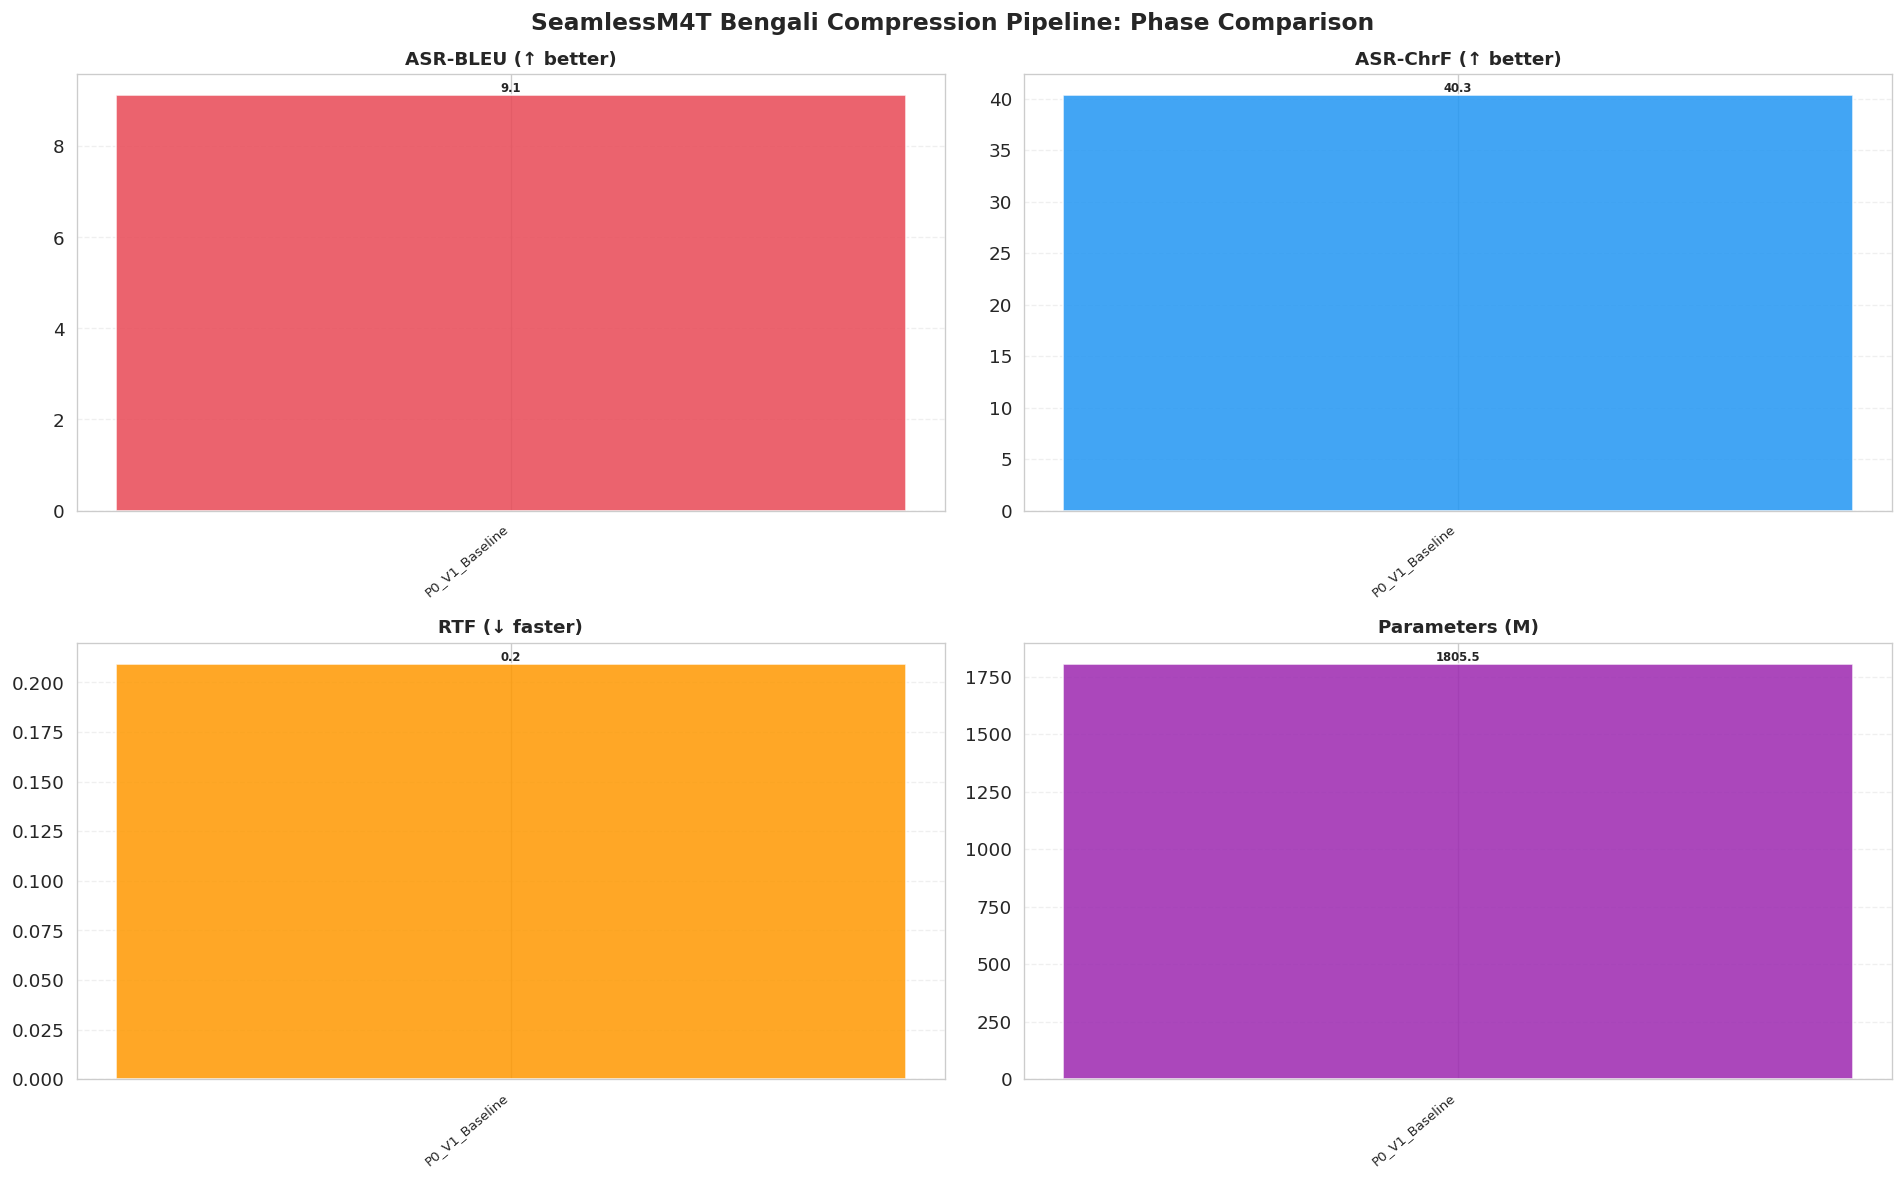

Plotting detailed comparison for 1 phases: ['P0_V1_Baseline']


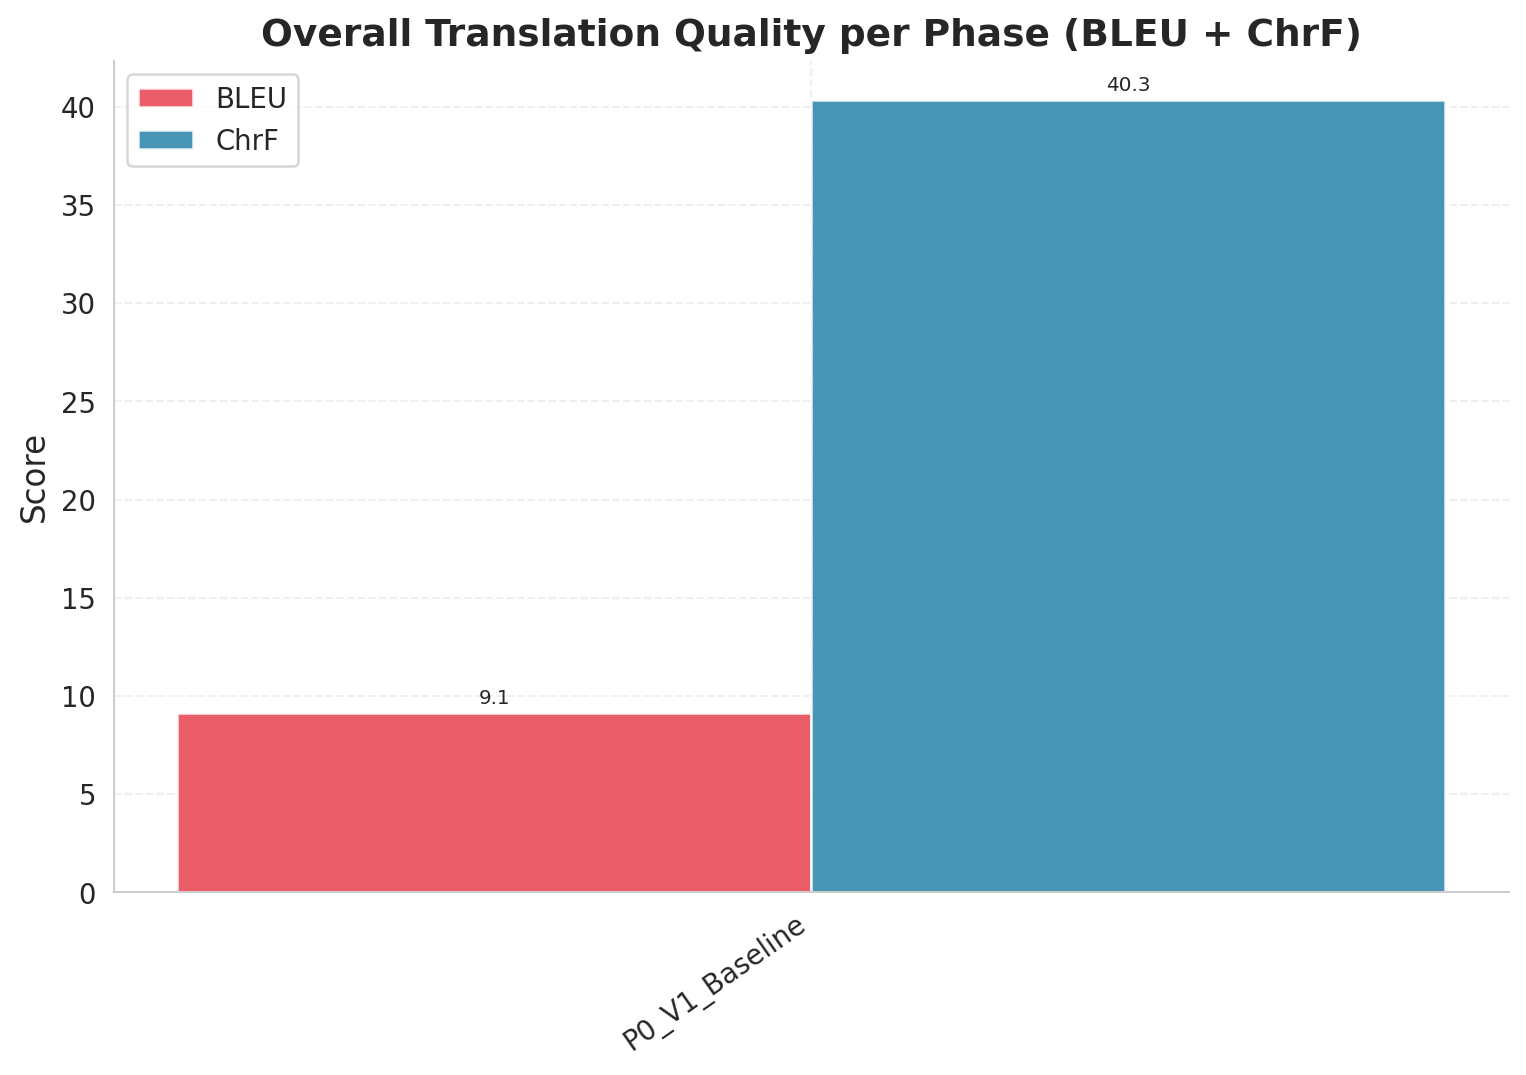

  ✓ Saved: detailed_comparison_01_overall_quality.png  [Overall Quality]


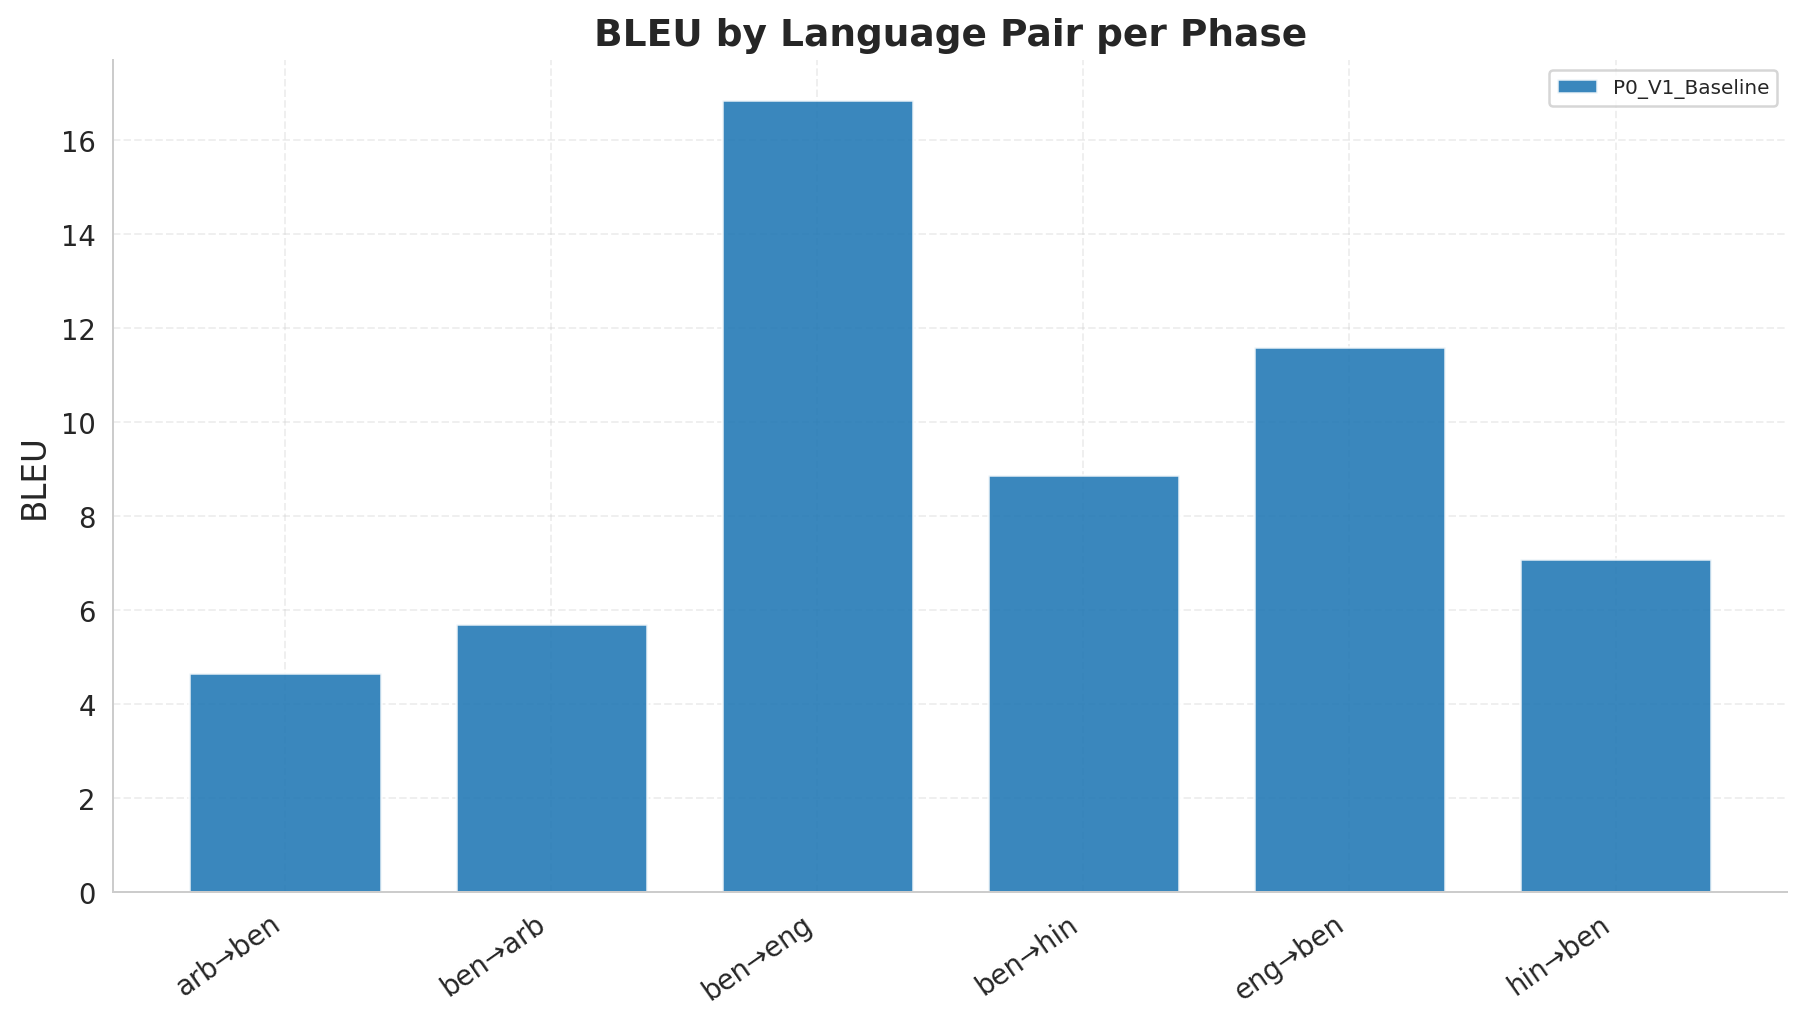

  ✓ Saved: detailed_comparison_02_bleu_by_pair.png  [BLEU by Language Pair]


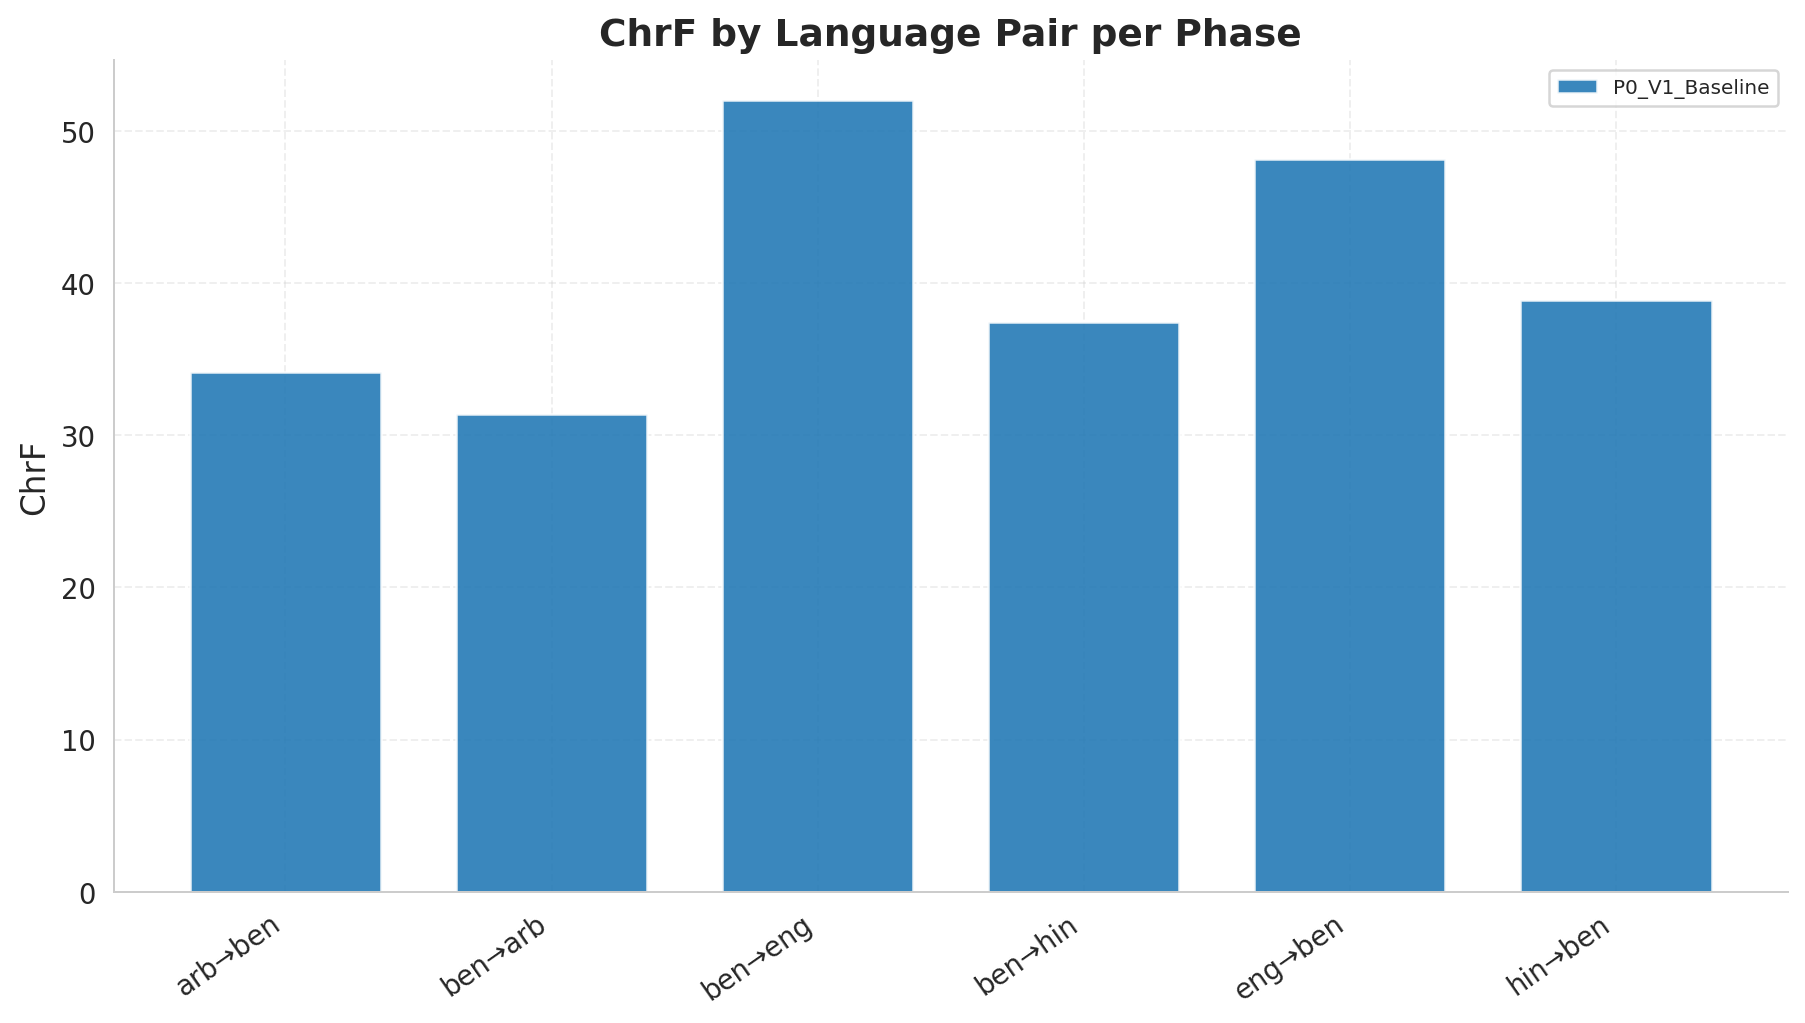

  ✓ Saved: detailed_comparison_03_chrf_by_pair.png  [ChrF by Language Pair]


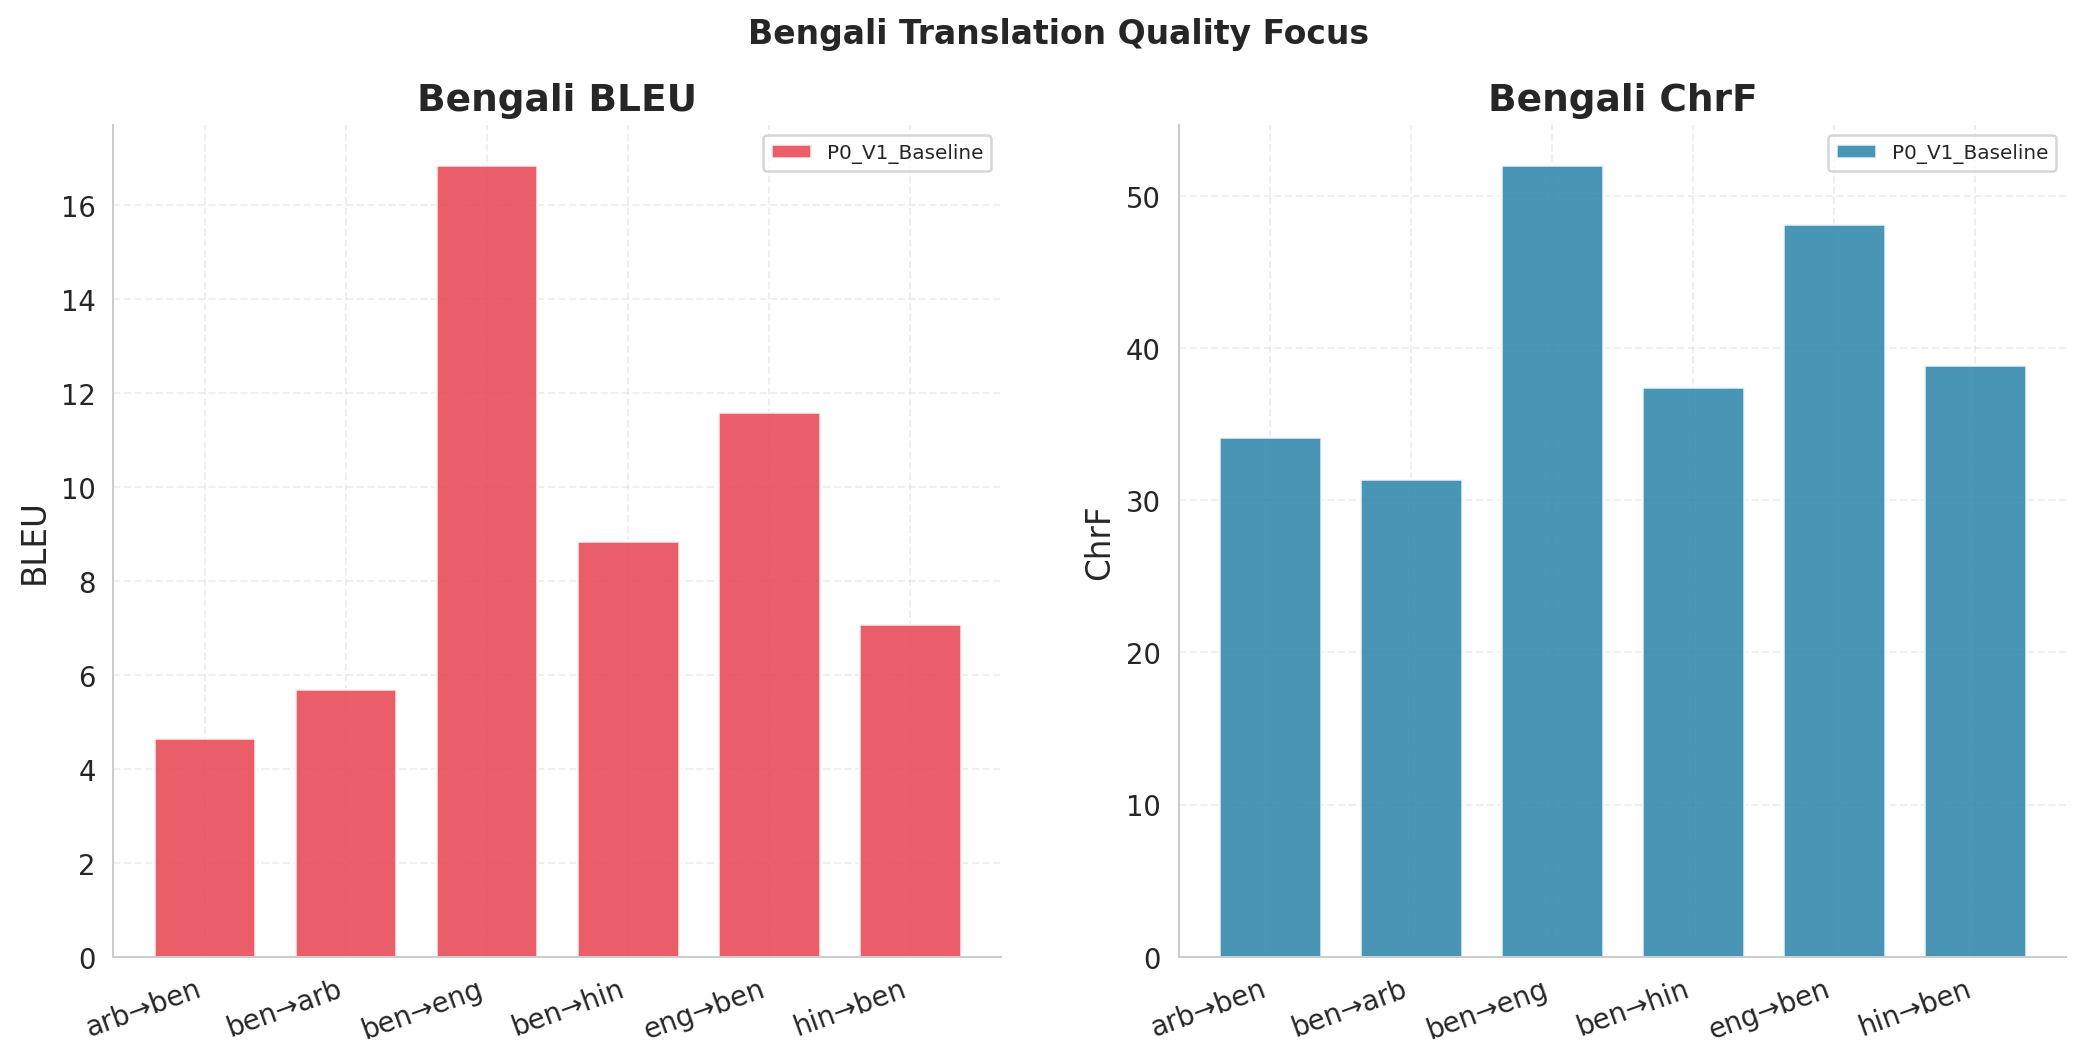

  ✓ Saved: detailed_comparison_04_bengali_focus.png  [Bengali Focus]


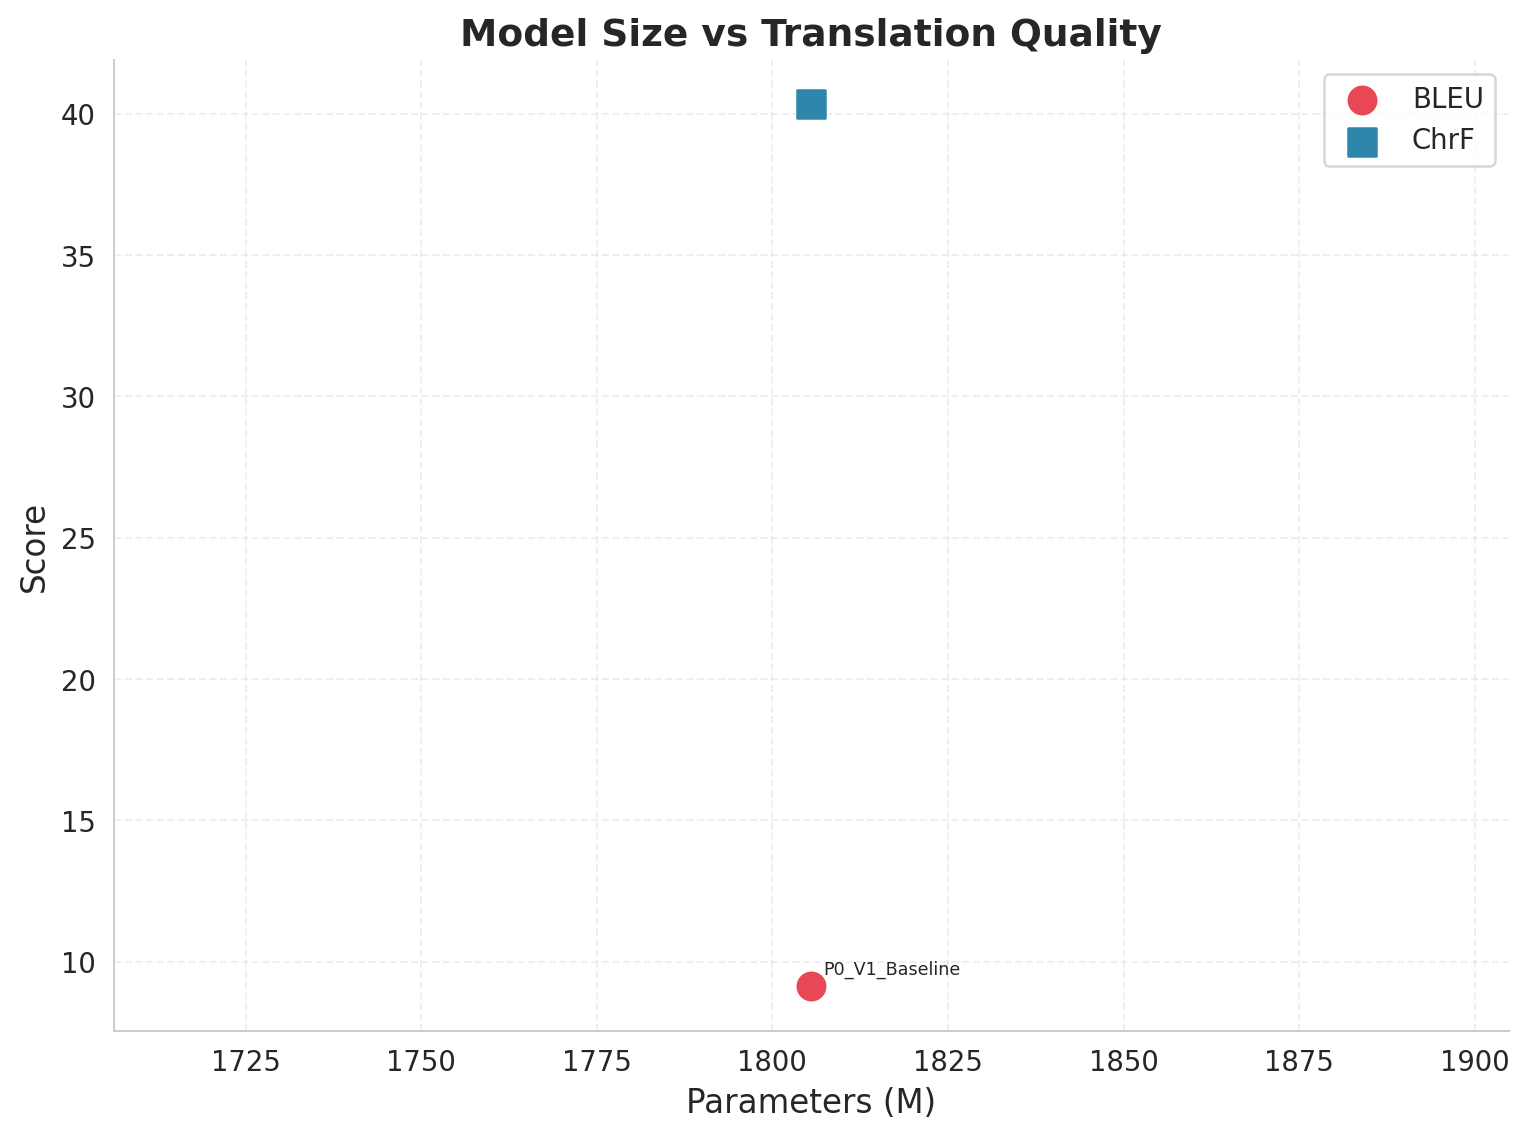

  ✓ Saved: detailed_comparison_05_size_vs_quality.png  [Size vs Quality]


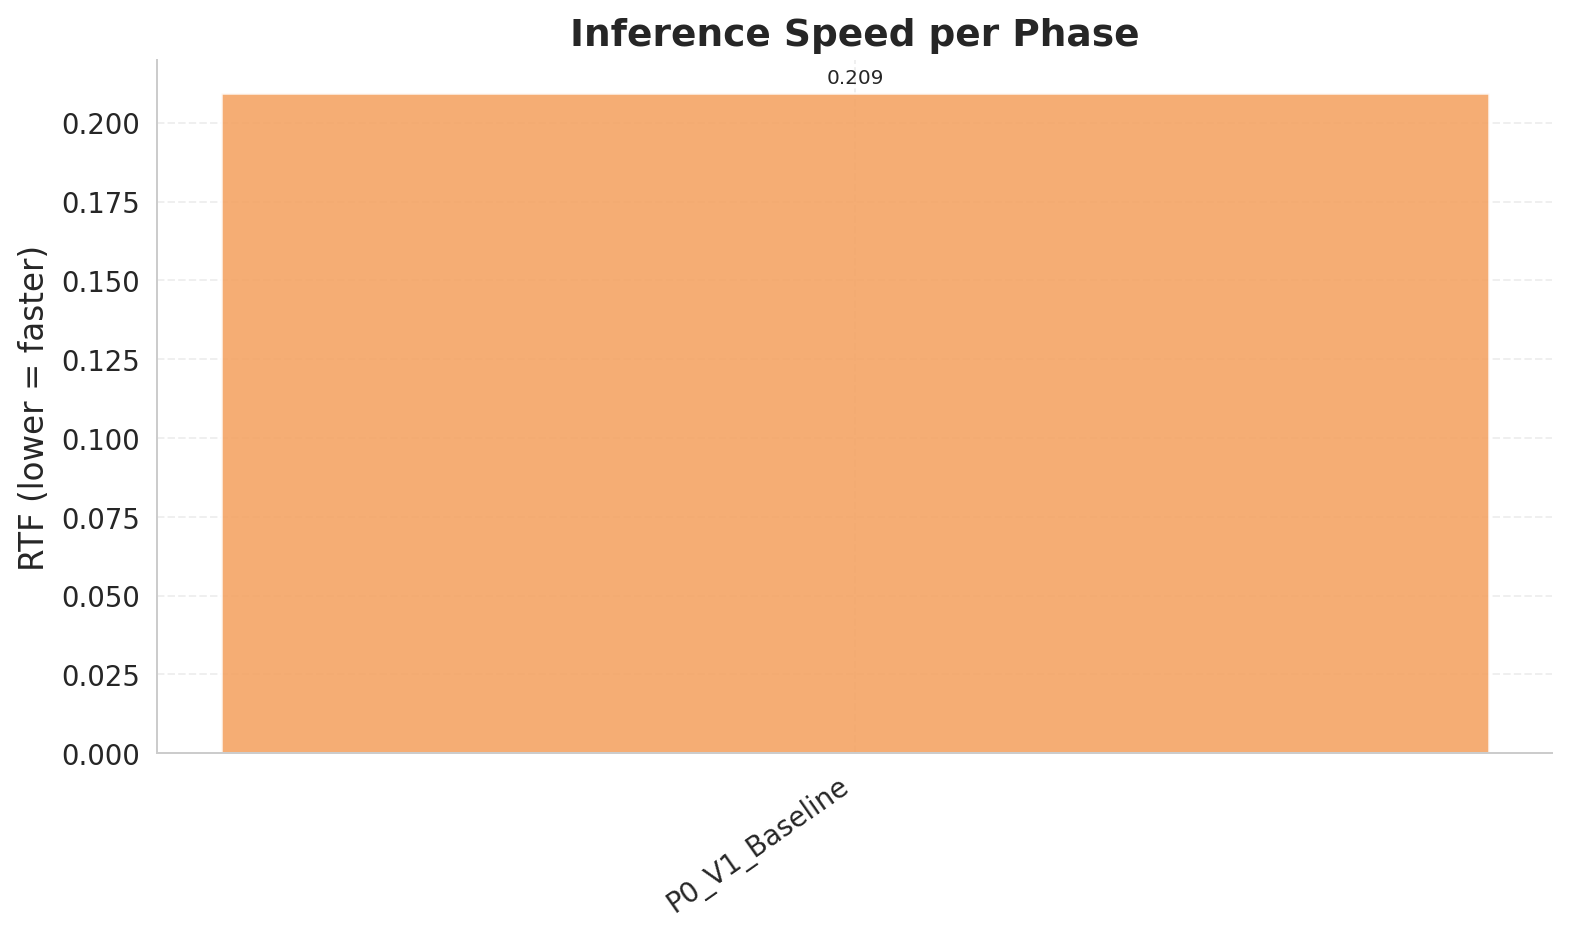

  ✓ Saved: detailed_comparison_06_rtf.png  [Inference Speed RTF]

✅ All 6 figures saved.
   📄 detailed_comparison_01_overall_quality.png
   📄 detailed_comparison_02_bleu_by_pair.png
   📄 detailed_comparison_03_chrf_by_pair.png
   📄 detailed_comparison_04_bengali_focus.png
   📄 detailed_comparison_05_size_vs_quality.png
   📄 detailed_comparison_06_rtf.png


In [28]:
p0_bench = load_latest_checkpoint('phase0_benchmark')
if p0_bench and p0_bench.get('summary', {}).get('avg_bleu', 0) > 0:
    p0_results = p0_bench['results']
    p0_summary = p0_bench['summary']
    p0_detailed = p0_bench.get('detailed_summary')
    print('Loaded Phase 0 benchmark from checkpoint.')
    if not p0_detailed:
        p0_detailed = compute_detailed_summary(p0_results, 'P0_V1_Baseline', p0_summary['params_M'])
else:
    p0_results, p0_summary = run_benchmark(model_v1, list(eval_samples), 'P0_V1_Baseline', save_n=2)
    p0_detailed = compute_detailed_summary(p0_results, 'P0_V1_Baseline', p0_summary['params_M'])
    save_checkpoint(dict(results=p0_results, summary=p0_summary, detailed_summary=p0_detailed),
                    'phase0_benchmark', 0)

store_summary(p0_summary)
store_detailed_summary(p0_detailed)
print_detailed_summary_table('P0_V1_Baseline')
plot_phase_comparison()
plot_detailed_phase_comparison()


---
## Phase 1: Vocabulary Pruning — 4 Languages (Ben, Eng, Hin, Arb)
Remove unused tokens. No Chinese tokens.

In [29]:
# # ══════════════════════════════════════════════════════════════════════════════
# # PHASE 1 — Vocabulary Pruning (Ben, Eng, Hin, Arb)
# # 
# # HOW IT WORKS
# # ─────────────────────────────────────────────────────────────────────────────
# # Sources used (all native Parquet, no loading scripts, no trust_remote_code):
# #
# #   1. wikimedia/wikipedia  (config "20231101.{lang}")
# #      • bn : 143k articles  — exhausts all Bengali BPE pieces
# #      • ar : ~1.2M articles — exhausts all Arabic BPE pieces  
# #      • hi : ~155k articles — exhausts all Hindi BPE pieces
# #      • en : 6.4M articles  — we stream only what we need
# #
# #   2. ai4bharat/sangraha   (direct parquet URLs from verified/ folder)
# #      • ben.parquet (29.9 GB) — Bengali web+news corpus, additional rare tokens
# #      • hin.parquet (37.3 GB) — Hindi
# #      (English and Arabic covered by Wikipedia alone)
# #
# # Loading method: load_dataset(..., streaming=True) — HF handles all parquet
# # URL resolution internally from the config. No scripts involved.
# #
# # Convergence guarantee: after scanning the full Wikipedia for a language,
# # the BPE token set is complete. We verify this with the OOV check below.
# # ══════════════════════════════════════════════════════════════════════════════

# import gc, time
# import torch, torch.nn as nn
# from datasets import load_dataset

# # ── Language maps ─────────────────────────────────────────────────────────────
# # Wikipedia config names for wikimedia/wikipedia (verified from HF tree)
# WIKI_CONFIGS = {
#     'ben': '20231101.bn',   # 143k articles
#     'hin': '20231101.hi',   # 155k articles
#     'arb': '20231101.ar',   # 1.2M articles
#     'eng': '20231101.en',   # 6.4M articles (we stop early)
# }

# # SeamlessM4T language control tokens that MUST survive the trim
# M4T_LANG_TOKENS = ['__ben__', '__eng__', '__hin__', '__arb__']

# # Sentence limits — Wikipedia alone is sufficient for script-complete BPE coverage.
# # For English, 200k articles gives well above 99.9% coverage; more is wasteful.
# N_WIKI_SENTENCES = {
#     'ben': 999_999_999,  # take all (143k articles, fast)
#     'hin': 999_999_999,  # take all (155k articles, fast)
#     'arb': 999_999_999,  # take all (1.2M articles, ~20 min streaming)
#     'eng': 200_000,      # English converges at ~50k; 200k is very safe
# }

# # ── Held-out sentences for OOV verification ───────────────────────────────────
# _HELD_OUT = {
#     'ben': [
#         'আমি বাংলায় কথা বলতে পারি এবং এটি একটি সুন্দর ভাষা।',
#         'বাংলাদেশের রাজধানী ঢাকা এবং পশ্চিমবঙ্গের রাজধানী কলকাতা।',
#         'তিনি বিশ্ববিদ্যালয়ে পদার্থবিজ্ঞান পড়াশোনা করেছেন।',
#         'সরকার নতুন অর্থনৈতিক নীতি ঘোষণা করেছে।',
#         'চিকিৎসক বললেন রোগীর অবস্থা এখন স্থিতিশীল।',
#     ],
#     'hin': [
#         'मैं हिंदी में बात कर सकता हूँ और यह एक सुंदर भाषा है।',
#         'भारत की राजधानी नई दिल्ली है और यहाँ की जनसंख्या बहुत अधिक है।',
#         'विश्वविद्यालय में भौतिक विज्ञान का अध्ययन बहुत महत्वपूर्ण है।',
#         'सरकार ने नई आर्थिक नीति की घोषणा की।',
#         'चिकित्सक ने कहा कि रोगी की स्थिति अब स्थिर है।',
#     ],
#     'arb': [
#         'أنا أتحدث العربية وهي لغة جميلة ومعبرة.',
#         'القاهرة هي عاصمة مصر وأكبر مدنها من حيث عدد السكان.',
#         'يدرس الطلاب في الجامعة مواضيع العلوم والرياضيات.',
#         'أعلنت الحكومة عن سياسة اقتصادية جديدة.',
#         'قال الطبيب إن حالة المريض مستقرة الآن.',
#     ],
#     'eng': [
#         'I can speak English fluently and it is a wonderful language.',
#         'The capital of Bangladesh is Dhaka and it is a very populous city.',
#         'Students at the university study physics and mathematics.',
#         'The government announced a new economic policy today.',
#         'The doctor said the patient\'s condition is now stable.',
#     ],
# }

# # ── Step 1: Collect token IDs ─────────────────────────────────────────────────

# def identify_used_tokens_v2(proc, target_langs):
#     """
#     Scan wikimedia/wikipedia (native parquet, no loading script) for all 4 langs.
#     Collects every BPE subword token ID the tokeniser would generate for those
#     languages.  Returns a sorted list of keep_ids.
#     """
#     tok  = proc.tokenizer
#     used = set()

#     # ── A. Mandatory: all special tokens ─────────────────────────────────────
#     for attr in ['pad_token_id', 'unk_token_id', 'bos_token_id',
#                  'eos_token_id', 'sep_token_id', 'cls_token_id',
#                  'mask_token_id']:
#         v = getattr(tok, attr, None)
#         if v is not None and v >= 0:
#             used.add(int(v))

#     if hasattr(tok, 'all_special_ids'):
#         used.update(int(x) for x in tok.all_special_ids)

#     # Explicit lang control tokens
#     for lt in M4T_LANG_TOKENS:
#         tid = tok.convert_tokens_to_ids(lt)
#         if tid is not None and tid != tok.unk_token_id:
#             used.add(int(tid))
#         else:
#             print(f'  [CRITICAL] lang token {lt!r} not in vocab — model WILL break!')

#     # Belt-and-suspenders: any __xxx__ token
#     for tid in range(len(tok)):
#         t = tok.convert_ids_to_tokens(tid)
#         if t and t.startswith('__') and t.endswith('__'):
#             used.add(tid)

#     n_mandatory = len(used)
#     print(f'  Mandatory special tokens locked: {n_mandatory}')
#     print(f'  Total tokenizer vocab size     : {len(tok)}')

#     # ── B. Wikipedia streaming ────────────────────────────────────────────────
#     for m4t_lang in target_langs:
#         cfg   = WIKI_CONFIGS[m4t_lang]
#         n_max = N_WIKI_SENTENCES[m4t_lang]
#         t0    = time.time()
#         count = 0
#         prev_used = len(used)

#         print(f'\n  ── {m4t_lang.upper()} : wikimedia/wikipedia  config={cfg} ──')
#         try:
#             ds = load_dataset(
#                 'wikimedia/wikipedia',
#                 cfg,
#                 split='train',
#                 streaming=True,
#             )
#             for ex in ds:
#                 text = (ex.get('text') or '').strip()
#                 if not text:
#                     continue
#                 # encode article text (no special tokens = pure subword IDs)
#                 ids = tok.encode(text, add_special_tokens=False)
#                 used.update(ids)
#                 count += 1
#                 if count % 20_000 == 0:
#                     elapsed = time.time() - t0
#                     new_this_run = len(used) - prev_used
#                     print(f'    [{m4t_lang}] {count:>7} articles | '
#                           f'{len(used):>6} total tokens | '
#                           f'+{new_this_run} new | {elapsed:.0f}s')
#                 if count >= n_max:
#                     break
#         except Exception as e:
#             print(f'  [ERROR] Wikipedia {cfg}: {e}')
#             raise   # do not silently continue — a failed source = incomplete keep set

#         new_this_lang = len(used) - prev_used
#         elapsed = time.time() - t0
#         print(f'  [{m4t_lang}] DONE: {count} articles | '
#               f'+{new_this_lang} new tokens | total={len(used)} | {elapsed:.0f}s')
#         gc.collect()

#     # ── C. ai4bharat/sangraha for Bengali + Hindi (extra rare tokens) ─────────
#     # These are direct parquet files — no loading script, gated, but public.
#     # Config-based access via load_dataset works without trust_remote_code.
#     SANGRAHA_LANGS = {
#         'ben': 'ben',
#         'hin': 'hin',
#     }
#     N_SANGRAHA = 200_000  # 200k docs from sangraha as a top-up

#     for m4t_lang, sg_lang in SANGRAHA_LANGS.items():
#         prev_used = len(used)
#         t0        = time.time()
#         count     = 0
#         print(f'\n  ── {m4t_lang.upper()} : ai4bharat/sangraha  lang={sg_lang} ──')
#         try:
#             ds = load_dataset(
#                 'ai4bharat/sangraha',
#                 data_dir=f"verified/{sg_lang}",  # Point directly to the language sub-folder
#                 split='train',                   # The data is loaded into the default 'train' split
#                 streaming=True,
#             )
#             for ex in ds:
#                 text = (ex.get('text') or '').strip()
#                 if not text:
#                     continue
#                 ids = tok.encode(text, add_special_tokens=False)
#                 used.update(ids)
#                 count += 1
#                 if count % 20_000 == 0:
#                     elapsed = time.time() - t0
#                     print(f'    [{m4t_lang}/sangraha] {count:>6} docs | '
#                           f'{len(used):>6} total tokens | {elapsed:.0f}s')
#                 if count >= N_SANGRAHA:
#                     break
#         except Exception as e:
#             # Sangraha is a top-up; if it fails, warn but continue
#             print(f'  [WARN] sangraha/{sg_lang} failed: {e} — skipping top-up')

#         new_this = len(used) - prev_used
#         print(f'  [{m4t_lang}/sangraha] +{new_this} new tokens')
#         gc.collect()

#     keep_ids = sorted(used)
#     print(f'\n  ══ Token collection complete ══')
#     print(f'  Keep : {len(keep_ids):>6} / {len(tok)} '
#           f'({len(keep_ids)/len(tok)*100:.1f}%)')
#     print(f'  Drop : {len(tok)-len(keep_ids):>6} tokens '
#           f'({(1-len(keep_ids)/len(tok))*100:.1f}% reduction)')
#     return keep_ids


# # ── Step 2: OOV verification (hard gate — must pass before trimming) ──────────

# def verify_zero_oov(proc, keep_ids_set, abort_on_fail=True):
#     """
#     Tokenise multiple held-out sentences per language and confirm zero OOV.
#     Raises AssertionError if any OOV found.
#     """
#     tok    = proc.tokenizer
#     all_ok = True
#     print('\n  OOV verification (must all PASS before trimming):')

#     for lang, sentences in _HELD_OUT.items():
#         lang_oov = []
#         for sent in sentences:
#             ids     = tok.encode(sent, add_special_tokens=False)
#             missing = [i for i in ids if i not in keep_ids_set]
#             lang_oov.extend(missing)

#         if not lang_oov:
#             print(f'    {lang.upper():<4}: ✓ PASS  (0 OOV)')
#         else:
#             oov_toks = [tok.convert_ids_to_tokens(i) for i in set(lang_oov)]
#             print(f'    {lang.upper():<4}: ✗ FAIL  '
#                   f'({len(set(lang_oov))} unique OOV IDs, e.g.: {oov_toks[:6]})')
#             all_ok = False

#     if abort_on_fail:
#         assert all_ok, (
#             'OOV check FAILED. The keep_ids set is incomplete. '
#             'This should not happen with full Wikipedia scans — '
#             'check for streaming errors above.'
#         )
#     print(f'  OOV verification: {"ALL PASS ✓" if all_ok else "FAILED ✗"}')
#     return all_ok


# # ── Step 3: Embedding trim (unchanged algebra) ────────────────────────────────

# def trim_vocabulary(mdl, proc, keep_ids):
#     """
#     Trim shared embedding matrix + lm_head to keep_ids rows.
#     Zero quality impact when keep_ids is built correctly from Step 1+2.
#     """
#     from transformers.models.seamless_m4t_v2.modeling_seamless_m4t_v2 import (
#         SeamlessM4Tv2ScaledWordEmbedding,
#     )

#     keep_t    = torch.tensor(keep_ids, dtype=torch.long)
#     old_v     = mdl.config.vocab_size
#     new_v     = len(keep_ids)
#     hidden    = mdl.config.hidden_size

#     print(f'\n  Trimming: {old_v} → {new_v} tokens '
#           f'({(1-new_v/old_v)*100:.1f}% reduction)')

#     old_shared  = mdl.shared
#     dev         = old_shared.weight.device
#     keep_t_dev  = keep_t.to(dev)
#     old_to_new  = {int(old): new for new, old in enumerate(keep_ids)}
#     old_pad     = old_shared.padding_idx
#     new_pad     = old_to_new.get(int(old_pad)) if old_pad is not None else None
#     embed_scale = getattr(mdl.text_decoder.embed_tokens, 'embed_scale', 1.0)

#     # 1. Shared embedding
#     new_shared = nn.Embedding(new_v, hidden, padding_idx=new_pad)
#     new_shared.weight.data = old_shared.weight.data[keep_t_dev].clone()
#     mdl.shared = new_shared.to(dev)

#     # 2. text_decoder.embed_tokens (must preserve embed_scale)
#     new_embed = SeamlessM4Tv2ScaledWordEmbedding(
#         new_v, hidden, padding_idx=new_pad, embed_scale=embed_scale)
#     new_embed.weight = mdl.shared.weight
#     mdl.text_decoder.embed_tokens = new_embed
#     print(f'  text_decoder.embed_tokens: embed_scale={embed_scale} ✓')

#     # 3. lm_head (tied to shared)
#     new_lm = nn.Linear(hidden, new_v, bias=False)
#     new_lm.weight = mdl.shared.weight
#     mdl.lm_head = new_lm

#     # 4. Config
#     mdl.config.vocab_size = new_v

#     # 5. generation_config.id_to_text
#     gen = mdl.generation_config
#     if hasattr(gen, 'id_to_text') and gen.id_to_text:
#         gen.id_to_text = {
#             str(old_to_new[int(k)]): v
#             for k, v in gen.id_to_text.items()
#             if int(k) in old_to_new
#         }
#         print(f'  id_to_text: {len(gen.id_to_text)} entries kept ✓')

#     # 6. Lang-code → ID maps in generation_config
#     for attr in ['text_decoder_lang_to_code_id', 'id_to_lang']:
#         m = getattr(gen, attr, None)
#         if isinstance(m, dict):
#             setattr(gen, attr, {
#                 k: (old_to_new[int(v)] if isinstance(v, int) and int(v) in old_to_new else v)
#                 for k, v in m.items()
#             })

#     saved_mb = (old_v - new_v) * hidden * 2 / 1e6   # fp16
#     print(f'  Saved ≈ {saved_mb:.0f} MB (fp16 embedding)')

#     # 7. Remap tensor — essential for decode() after trimming
#     mdl._vocab_remap_to_old = keep_t.cpu()
#     return mdl


# # ══════════════════════════════════════════════════════════════════════════════
# # PHASE 1 EXECUTION
# # ══════════════════════════════════════════════════════════════════════════════

# TARGET_4LANGS = ['ben', 'eng', 'hin', 'arb']

# # ── Try loading already-computed keep_ids ─────────────────────────────────────
# p1_ckpt = load_latest_checkpoint('phase1_vocab')

# if p1_ckpt and 'keep_ids' in p1_ckpt and len(p1_ckpt['keep_ids']) > 50_000:
#     keep_ids = p1_ckpt['keep_ids']
#     print(f'[P1] Loaded keep_ids from checkpoint: {len(keep_ids)} tokens')
#     # Still always verify OOV
#     verify_zero_oov(processor, set(keep_ids), abort_on_fail=True)
# else:
#     print('[P1] Building keep_ids from wikimedia/wikipedia + ai4bharat/sangraha...')
#     print('     Streaming — Wikipedia BN/HI scans: ~5–10 min each.')
#     print('     Wikipedia AR: ~30–40 min. EN: ~5 min (capped at 200k).')

#     keep_ids = identify_used_tokens_v2(processor, TARGET_4LANGS)
#     verify_zero_oov(processor, set(keep_ids), abort_on_fail=True)

#     # Save before touching the model
#     save_checkpoint(
#         {'keep_ids': keep_ids, 'n_langs': len(TARGET_4LANGS),
#          'vocab_before': len(processor.tokenizer),
#          'vocab_after':  len(keep_ids)},
#         'phase1_vocab', 0
#     )
#     print(f'[P1] keep_ids saved to checkpoint.')

# # ── Load or build the trimmed model ───────────────────────────────────────────
# try:
#     model_p1, processor = load_model_from_drive('phase1_vocab_4lang')
#     model_p1._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)
#     print('[P1] Loaded trimmed model from Drive.')
# except Exception as e:
#     print(f'[P1] Not on Drive ({e}), trimming baseline model...')
#     pre_params = count_params(model_v1)
#     model_p1   = trim_vocabulary(model_v1, processor, keep_ids)
#     post_params = count_params(model_p1)
#     print(f'  Params: {pre_params:.1f}M → {post_params:.1f}M '
#           f'(saved {pre_params-post_params:.1f}M from embeddings)')
#     save_model_to_drive(
#         model_p1, processor, 'phase1_vocab_4lang',
#         manifest_extra={'keep_ids_len': len(keep_ids),
#                         'vocab_reduction_pct': round((1-len(keep_ids)/len(processor.tokenizer))*100, 1)}
#     )

# print_model_breakdown(model_p1, 'After Phase 1: Vocab Trimmed (4 Languages)')

[ckpt] Loaded phase1_benchmark_step000000.pt
Loaded Phase 1 benchmark from checkpoint.
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P1_Vocab4L (2 total)
[ckpt] Saved all_detailed_summaries_step000000.pt (0.0 MB)
[detailed] Stored P1_Vocab4L

  P1_Vocab4L - 1686.3M params
Overall: BLEU=9.12  ChrF=40.33±11.80  RTF=0.1609

Per-Pair (6 pairs):
  Pair                  N     BLEU     ChrF      RTF
  arb→ben              33     4.66    34.13   0.1938
  ben→arb              33     5.69    31.39   0.1445
  ben→eng              33    16.85    52.04   0.1271
  ben→hin              33     8.86    37.45   0.1393
  eng→ben              33    11.58    48.11   0.1897
  hin→ben              33     7.08    38.87   0.1710

By Source Language:
     ARB: BLEU=  4.66  ChrF= 34.13  (n=33)
     BEN: BLEU= 10.47  ChrF= 40.29  (n=99)
     ENG: BLEU= 11.58  ChrF= 48.11  (n=33)
     HIN: BLEU=  7.08  ChrF= 38.87  (n=33)

By Target Language:
     ARB: BLEU=  5.69  ChrF= 31.39  (n=33)
     BEN

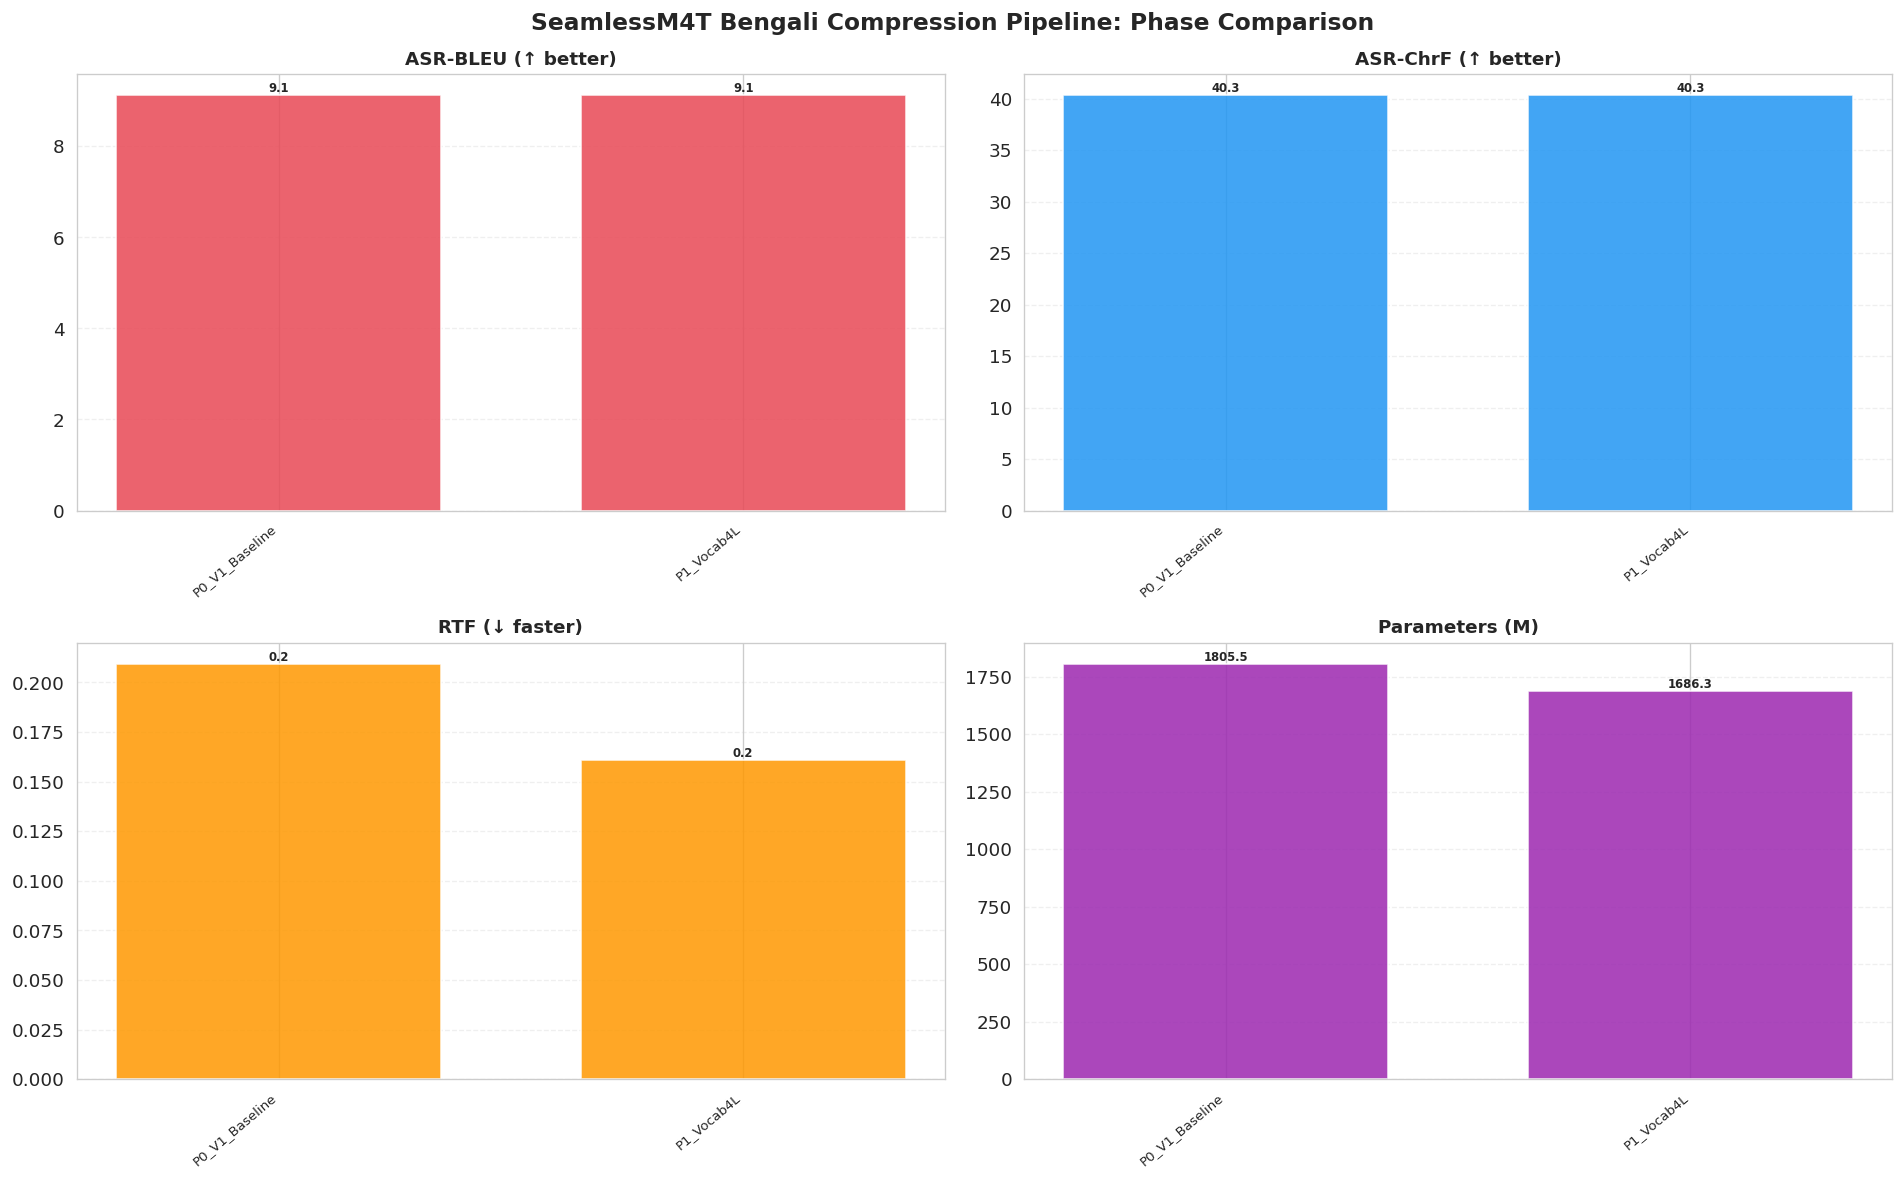

Plotting detailed comparison for 2 phases: ['P0_V1_Baseline', 'P1_Vocab4L']


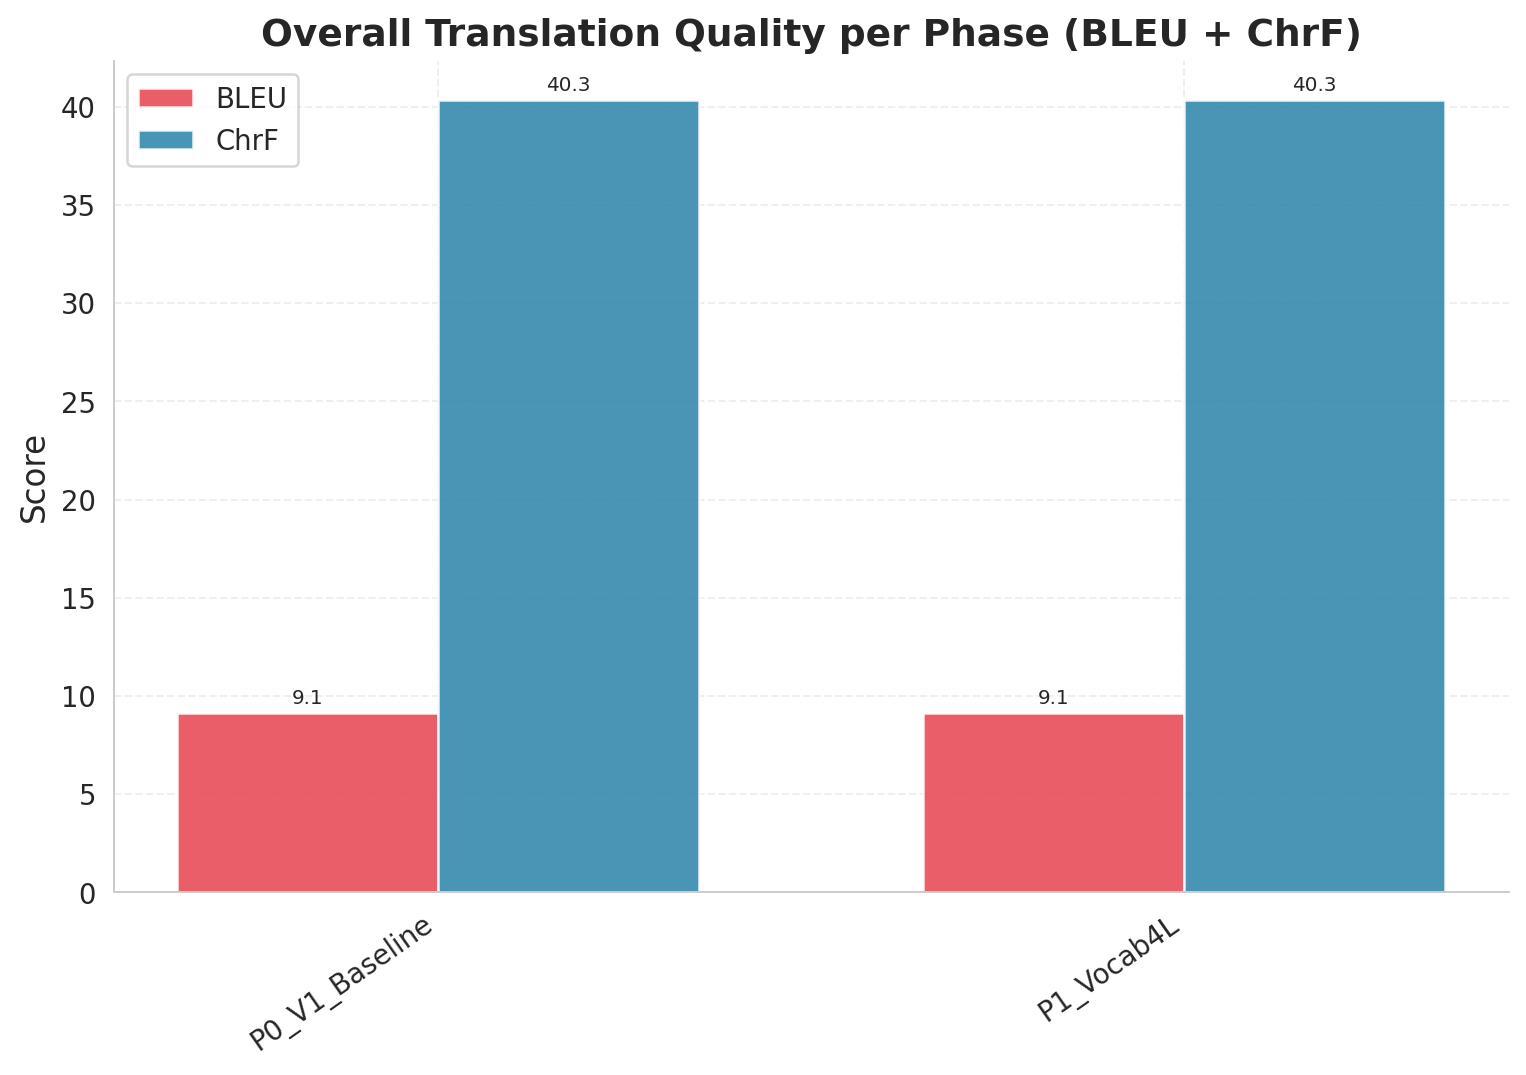

  ✓ Saved: detailed_comparison_01_overall_quality.png  [Overall Quality]


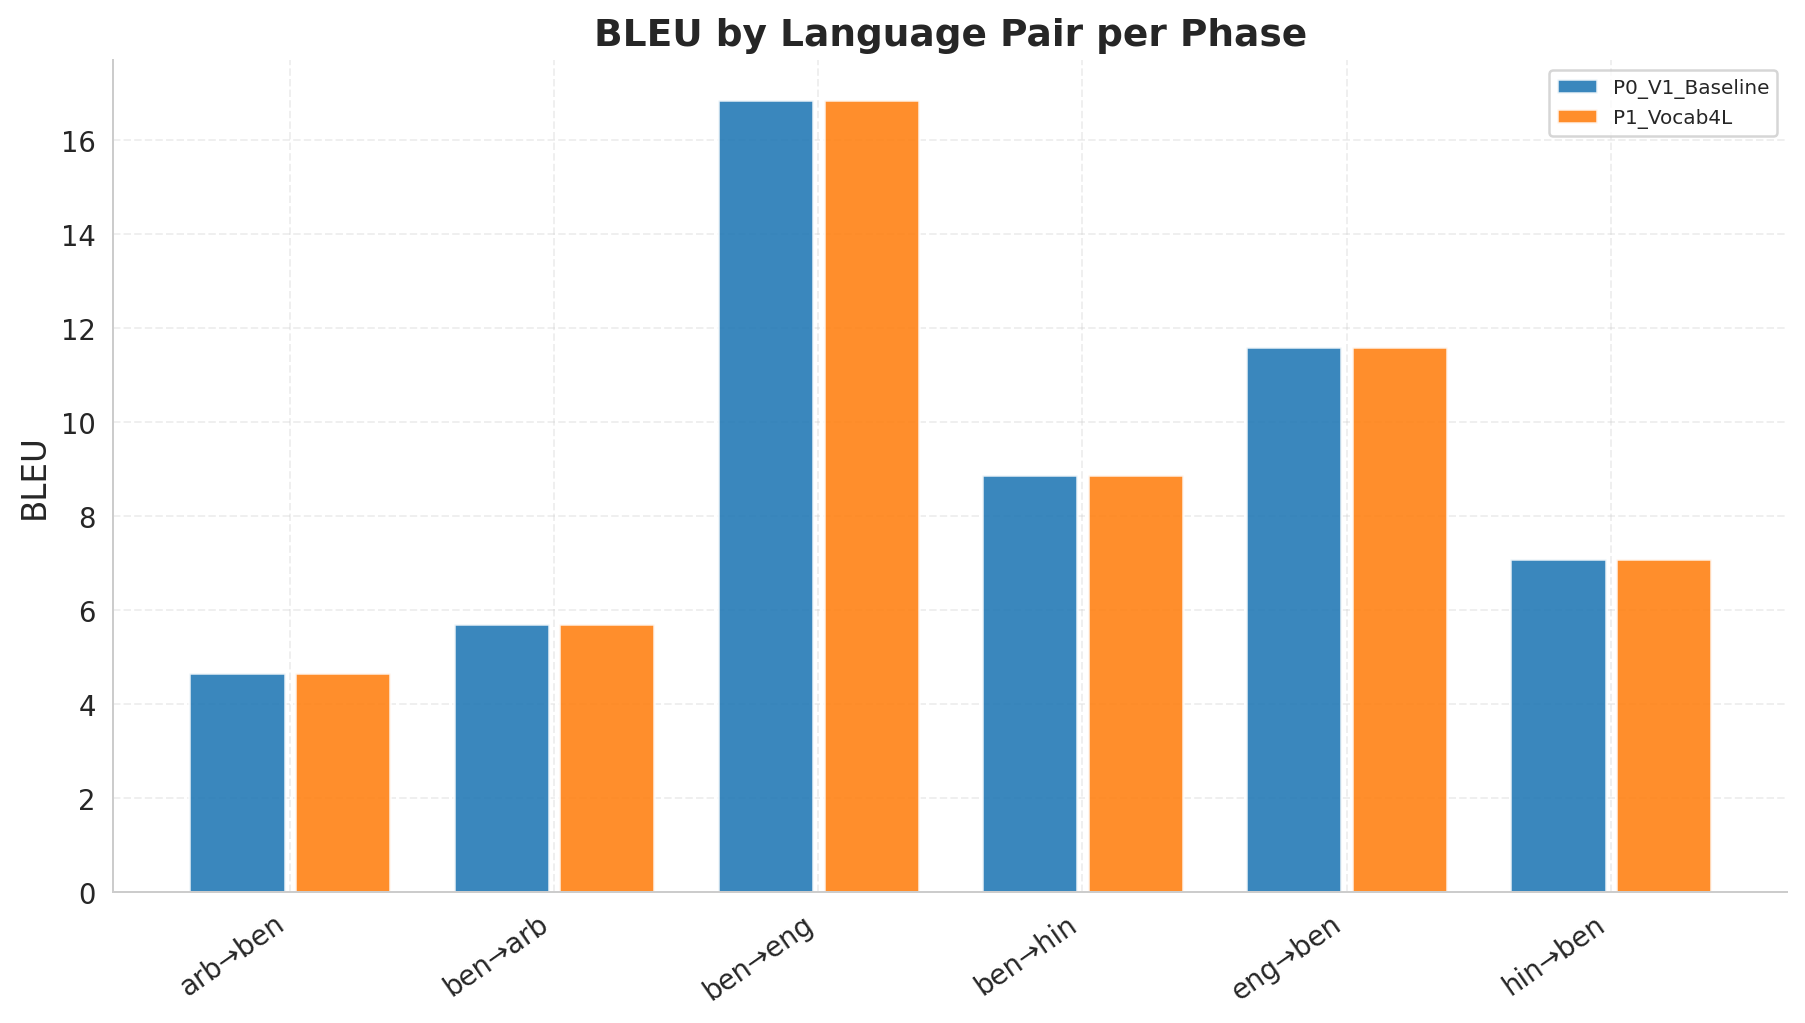

  ✓ Saved: detailed_comparison_02_bleu_by_pair.png  [BLEU by Language Pair]


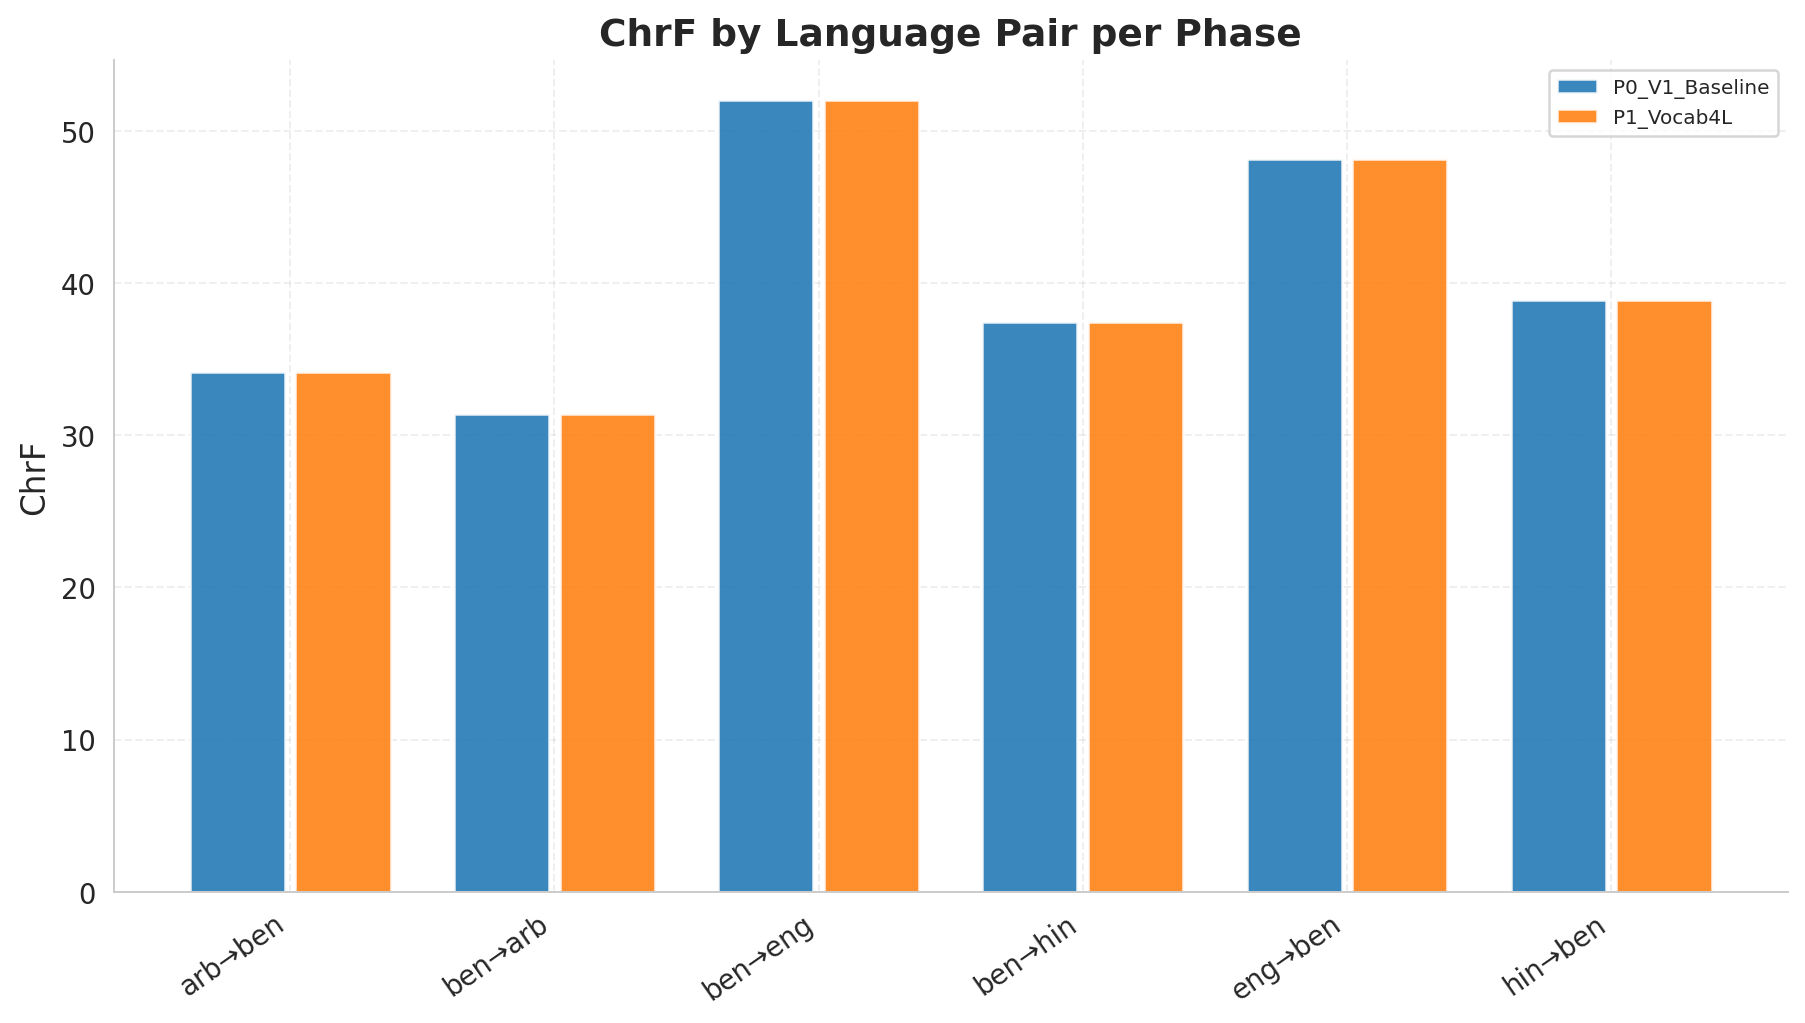

  ✓ Saved: detailed_comparison_03_chrf_by_pair.png  [ChrF by Language Pair]


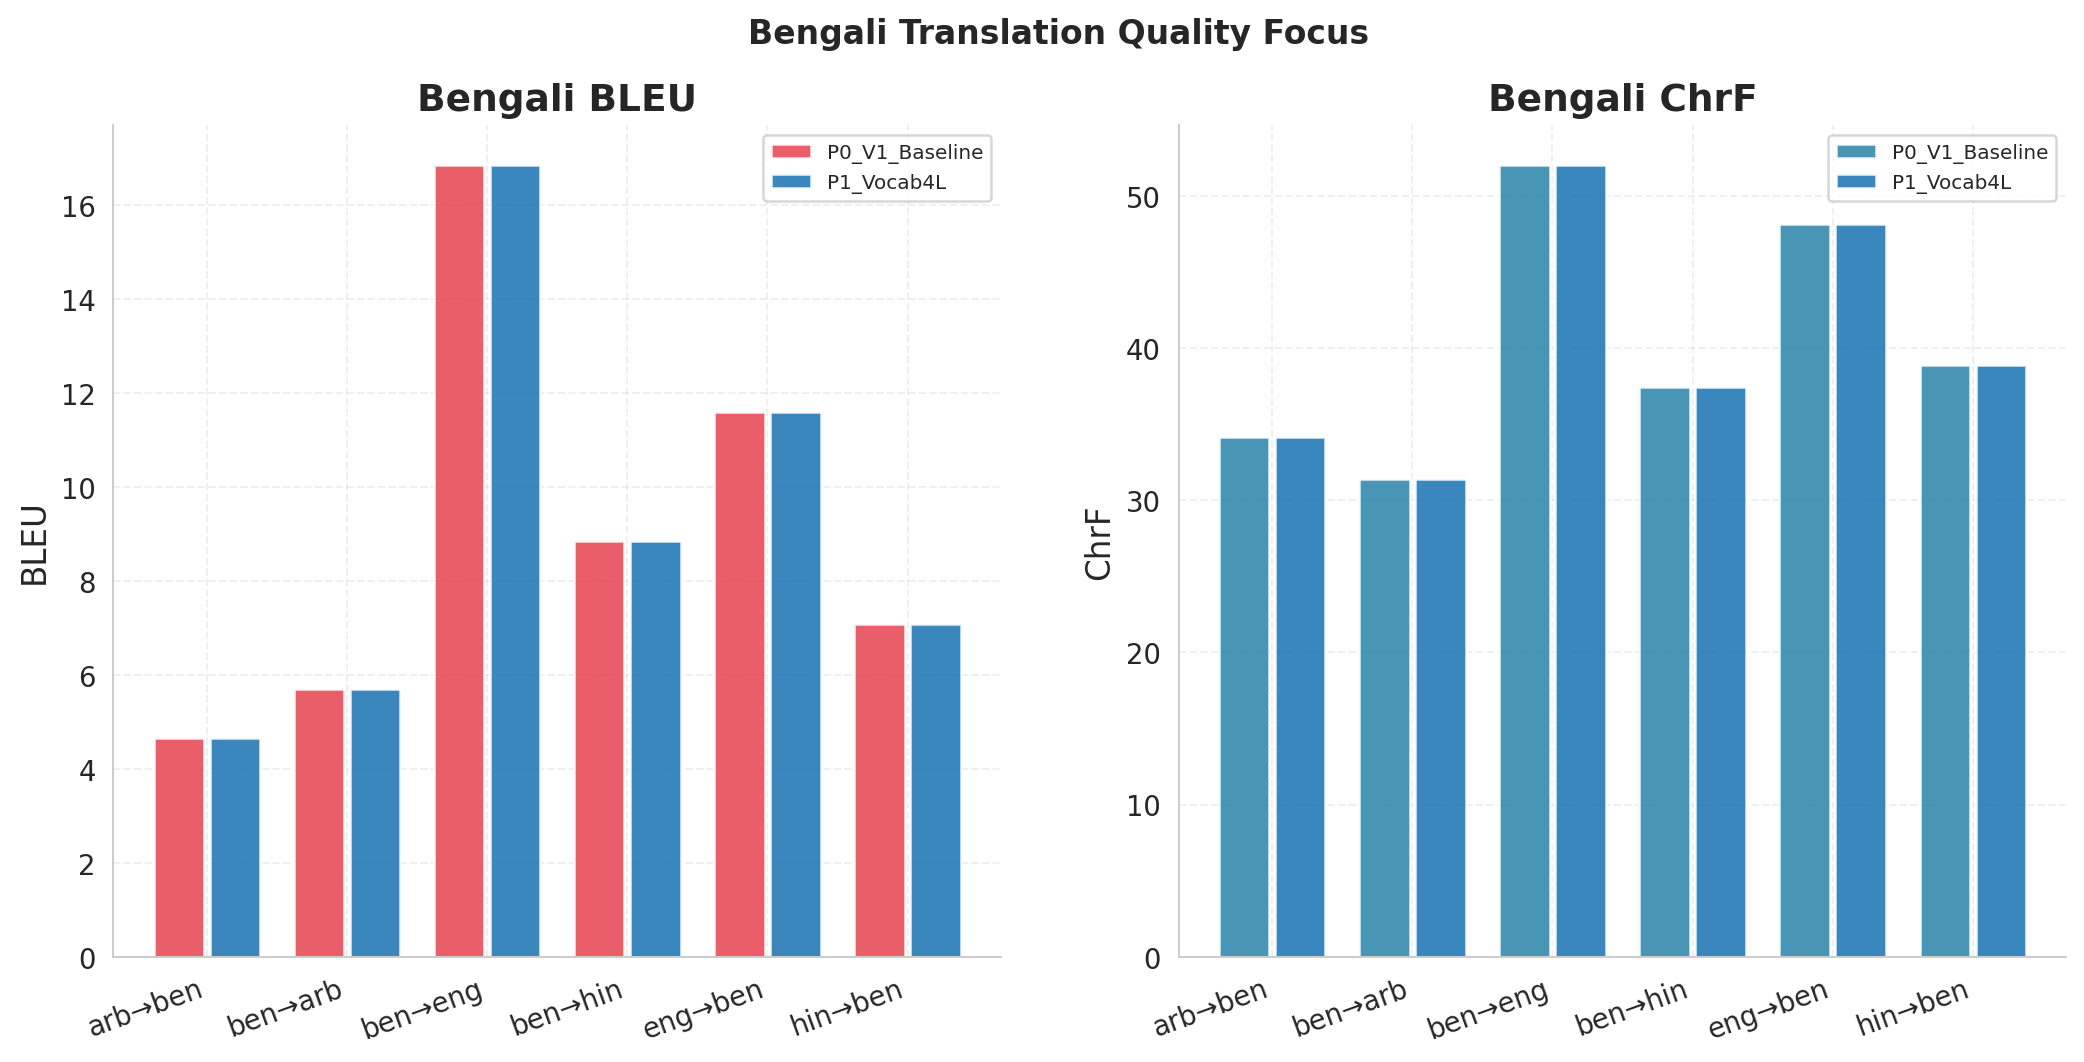

  ✓ Saved: detailed_comparison_04_bengali_focus.png  [Bengali Focus]


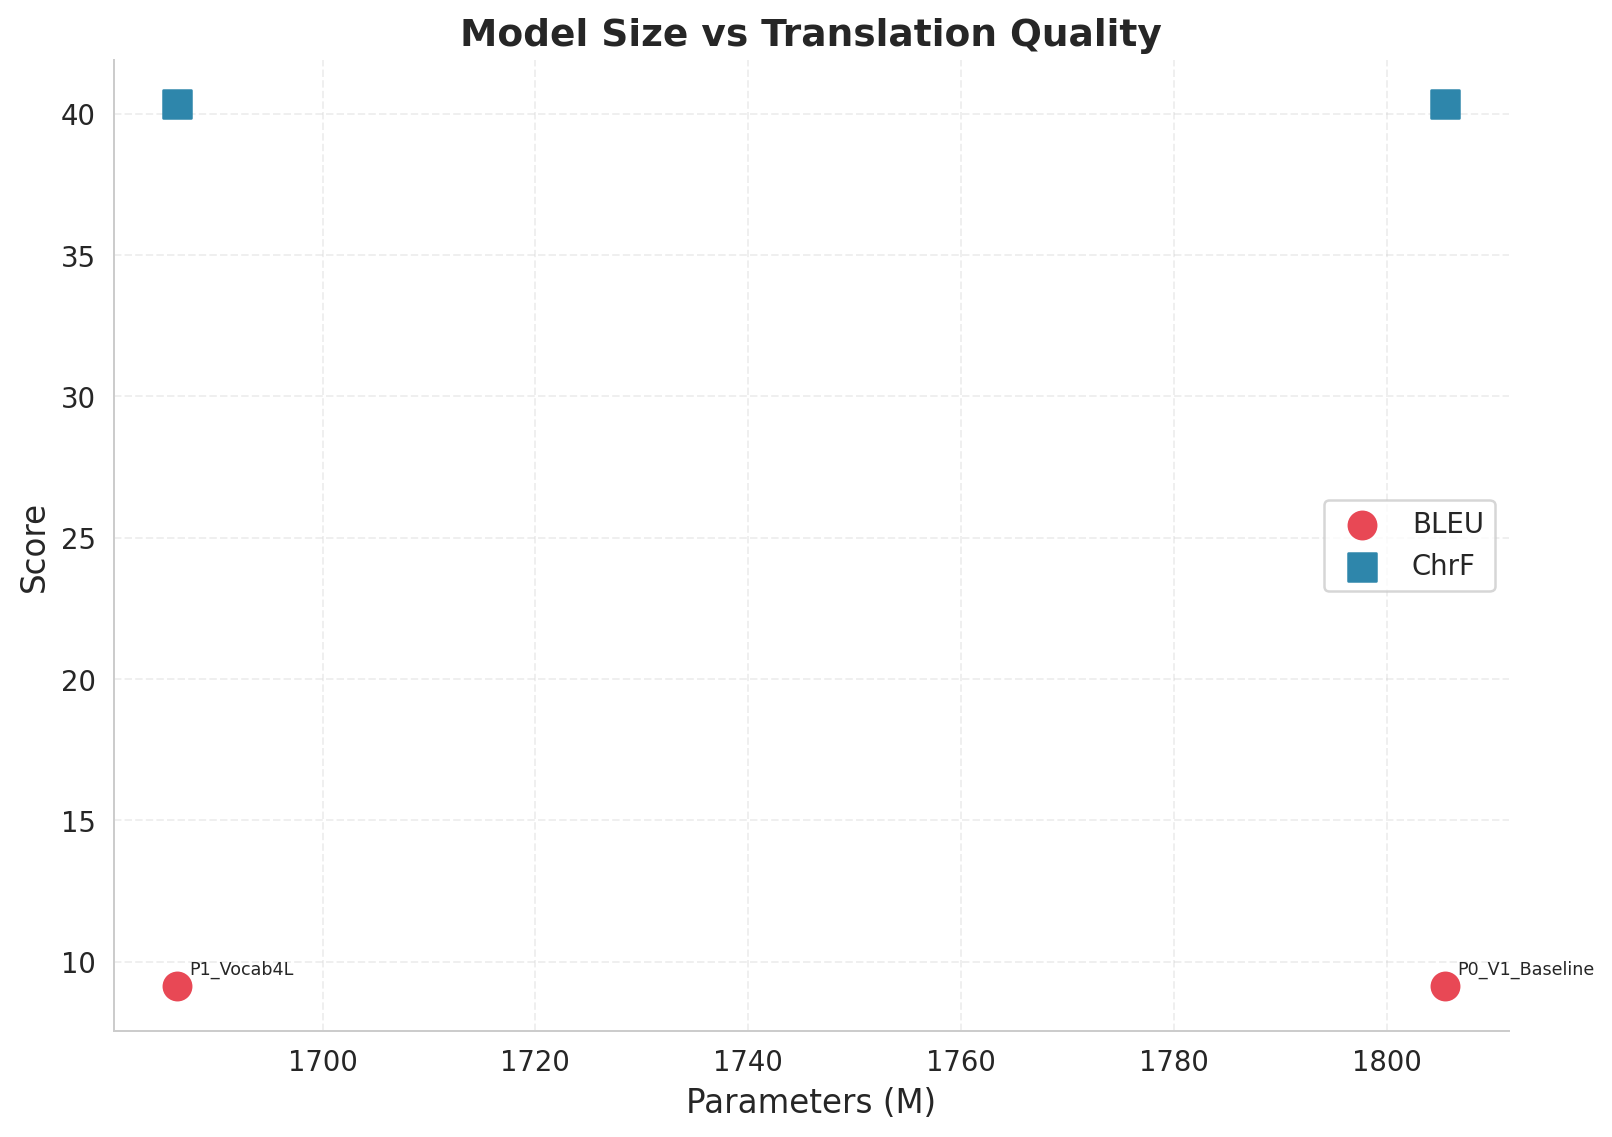

  ✓ Saved: detailed_comparison_05_size_vs_quality.png  [Size vs Quality]


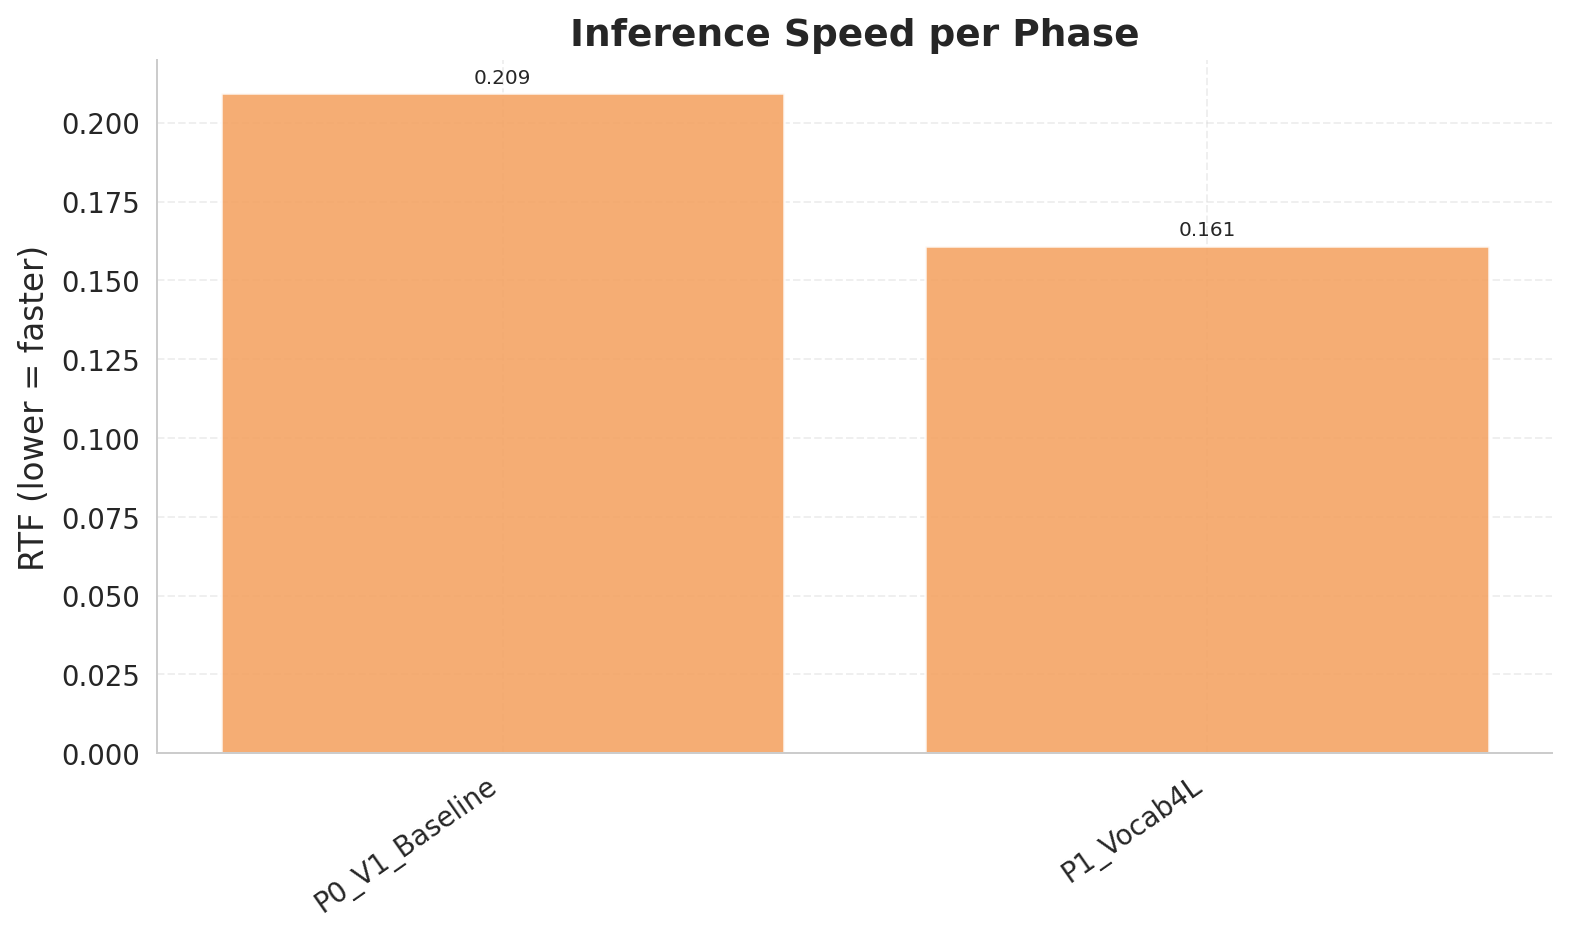

  ✓ Saved: detailed_comparison_06_rtf.png  [Inference Speed RTF]

✅ All 6 figures saved.
   📄 detailed_comparison_01_overall_quality.png
   📄 detailed_comparison_02_bleu_by_pair.png
   📄 detailed_comparison_03_chrf_by_pair.png
   📄 detailed_comparison_04_bengali_focus.png
   📄 detailed_comparison_05_size_vs_quality.png
   📄 detailed_comparison_06_rtf.png


In [30]:

# ── Benchmark immediately to confirm zero quality loss ────────────────────────
p1_bench = load_latest_checkpoint('phase1_benchmark')
if p1_bench and p1_bench.get('summary', {}).get('avg_bleu', 0) > 0:
    p1_results = p1_bench['results']
    p1_summary = p1_bench['summary']
    p1_detailed = p1_bench.get('detailed_summary')
    print('Loaded Phase 1 benchmark from checkpoint.')
    if not p1_detailed:
        p1_detailed = compute_detailed_summary(
            p1_results, 'P1_Vocab4L', p1_summary['params_M'])
else:
    p1_results, p1_summary = run_benchmark(
        model_p1, list(eval_samples), 'P1_Vocab4L', save_n=2)
    p1_detailed = compute_detailed_summary(
        p1_results, 'P1_Vocab4L', p1_summary['params_M'])
    save_checkpoint(
        dict(results=p1_results, summary=p1_summary, detailed_summary=p1_detailed),
        'phase1_benchmark', 0)

store_summary(p1_summary)
store_detailed_summary(p1_detailed)
print_detailed_summary_table('P1_Vocab4L')

# Quick sanity: Bengali ChrF should be within ±1 of Phase 0 baseline
p0_ben_chrf = ALL_DETAILED_SUMMARIES.get('P0_V1_Baseline', {}).get(
    'by_tgt_lang', {}).get('ben', {}).get('avg_chrf', 0)
p1_ben_chrf = p1_detailed['by_tgt_lang'].get('ben', {}).get('avg_chrf', 0)
delta = p1_ben_chrf - p0_ben_chrf
print(f'\n  ── Quality Gate ──')
print(f'  Bengali ChrF : P0={p0_ben_chrf:.2f}  →  P1={p1_ben_chrf:.2f}  '
      f'Δ={delta:+.2f}')
if abs(delta) <= 1.5:
    print('  ✓ Within ±1.5 — vocab trim is lossless.')
elif abs(delta) <= 3.0:
    print('  ⚠ Between ±1.5 and ±3.0 — marginal, check sangraha availability.')
else:
    print('  ✗ Δ > 3.0 — something is wrong. Check streaming errors above.')

plot_phase_comparison()
plot_detailed_phase_comparison()

---
## Phase 2: Speech Encoder Pruning — 24 → 10 layers
BI-guided iterative pruning. Remove 16 layers. Metric: text-BLEU primary, text-ChrF fallback.

In [31]:
# # Load Phase 1 model to prune
# model_p2 = _consolidate_to_single_gpu(model_p1)

# N_ENC_REMOVE_P2 = 14   # 24→10

# p2_enc_ckpt    = load_latest_checkpoint('phase2_enc_pruning')
# p2_enc_complete = p2_enc_ckpt and len(p2_enc_ckpt.get('removed', [])) >= N_ENC_REMOVE_P2

# if p2_enc_complete:
#     print(f'Phase 2 enc pruning complete: removed {p2_enc_ckpt["removed"]}')
#     try:
#         model_p2, processor = load_model_from_drive('phase2_enc_10L')
#     except:
#         print('  Rebuilding from checkpoint...')
#         parent, la = get_encoder_layers(model_p2)
#         cur = list(getattr(parent, la))
#         keep = [i for i in range(len(cur)) if i not in p2_enc_ckpt['removed']]
#         setattr(parent, la, nn.ModuleList([cur[i] for i in keep]))
#         sync_model_config(model_p2)
#         save_model_to_drive(model_p2, processor, 'phase2_enc_10L')
# else:
#     done = len(p2_enc_ckpt['removed']) if p2_enc_ckpt else 0
#     print(f'{"Resuming" if done else "Running"} Phase 2: enc pruning ({done}/{N_ENC_REMOVE_P2})...')

#     if not (p2_enc_ckpt and p2_enc_ckpt.get('bi_scores')):
#         print('Computing encoder Block Influence scores...')
#         bi_scores_enc = compute_encoder_block_influence(model_p2, list(eval_samples), max_n=30)
#         save_checkpoint(dict(removed=[], log=[], bi_scores=bi_scores_enc), 'phase2_enc_pruning', 0)
#     else:
#         bi_scores_enc = p2_enc_ckpt['bi_scores']
#         print(f'  Encoder BI scores loaded ({len(bi_scores_enc)} layers)')

#     removed_enc, p2_log = iterative_enc_prune(
#         model_p2, list(eval_samples), N_ENC_REMOVE_P2, max_eval=12,
#         ckpt_name='phase2_enc_pruning', bi_scores=bi_scores_enc)

#     sync_model_config(model_p2)
#     save_checkpoint(dict(removed=removed_enc, log=p2_log), 'phase2_enc_pruning', 0)
#     save_model_to_drive(model_p2, processor, 'phase2_enc_10L')

# print_model_breakdown(model_p2, 'After Phase 2: Enc10L')

In [32]:
# p2_bench = load_latest_checkpoint('phase2_benchmark')
# if p2_bench and p2_bench.get('summary', {}).get('avg_bleu', 0) > 0:
#     p2_results = p2_bench['results']
#     p2_summary = p2_bench['summary']
#     p2_detailed = p2_bench.get('detailed_summary')
#     if not p2_detailed:
#         p2_detailed = compute_detailed_summary(p2_results, 'P2_Enc10L', p2_summary['params_M'])
# else:
#     p2_results, p2_summary = run_benchmark(model_p2, list(eval_samples), 'P2_Enc10L', save_n=2)
#     p2_detailed = compute_detailed_summary(p2_results, 'P2_Enc10L', p2_summary['params_M'])
#     save_checkpoint(dict(results=p2_results, summary=p2_summary, detailed_summary=p2_detailed),
#                     'phase2_benchmark', 0)

# store_summary(p2_summary)
# store_detailed_summary(p2_detailed)
# print_detailed_summary_table('P2_Enc10L')
# plot_phase_comparison()
# plot_detailed_phase_comparison()


---
## Phase 3: T2U Pruning — Enc 6→5, Dec 6→5 (prune 2 layers each)
Metric: ASR-BLEU primary, ASR-ChrF fallback.

In [33]:
# model_p3 = model_p2   # continue from enc-pruned model
# model_p3 = _consolidate_to_single_gpu(model_p3)

# T2U_N_REMOVE = 1   # remove 1 from encoder + 1 from decoder

# # ── T2U Encoder pruning ───────────────────────────────────────────────────────
# p3_enc_ckpt = load_latest_checkpoint('phase3_t2u_enc_pruning')
# p3_enc_done = p3_enc_ckpt and len(p3_enc_ckpt.get('removed', [])) >= T2U_N_REMOVE

# if p3_enc_done:
#     print(f'T2U encoder pruning complete: {p3_enc_ckpt["removed"]}')
# else:
#     print(f'Running T2U encoder pruning (remove {T2U_N_REMOVE} layers)...')
#     removed_t2u_enc, log_t2u_enc = iterative_t2u_prune(
#         model_p3, list(eval_samples), T2U_N_REMOVE, which='encoder',
#         max_eval=12, ckpt_name='phase3_t2u_enc_pruning')
#     print(f'T2U encoder removed: {removed_t2u_enc}')

# # ── T2U Decoder pruning ───────────────────────────────────────────────────────
# p3_dec_ckpt = load_latest_checkpoint('phase3_t2u_dec_pruning')
# p3_dec_done = p3_dec_ckpt and len(p3_dec_ckpt.get('removed', [])) >= T2U_N_REMOVE

# if p3_dec_done:
#     print(f'T2U decoder pruning complete: {p3_dec_ckpt["removed"]}')
# else:
#     print(f'Running T2U decoder pruning (remove {T2U_N_REMOVE} layers)...')
#     removed_t2u_dec, log_t2u_dec = iterative_t2u_prune(
#         model_p3, list(eval_samples), T2U_N_REMOVE, which='decoder',
#         max_eval=12, ckpt_name='phase3_t2u_dec_pruning')
#     print(f'T2U decoder removed: {removed_t2u_dec}')

# sync_model_config(model_p3)
# save_model_to_drive(model_p3, processor, 'phase3_t2u_pruned')
# print_model_breakdown(model_p3, 'After Phase 3: T2U Pruned (5+5)')


In [34]:
# p3_bench = load_latest_checkpoint('phase3_benchmark')
# if p3_bench and p3_bench.get('summary', {}).get('avg_bleu', 0) > 0:
#     p3_results = p3_bench['results']; p3_summary = p3_bench['summary']
#     p3_detailed = p3_bench.get('detailed_summary')
#     if not p3_detailed:
#         p3_detailed = compute_detailed_summary(p3_results, 'P3_T2U4x4', p3_summary['params_M'])
# else:
#     p3_results, p3_summary = run_benchmark(model_p3, list(eval_samples), 'P3_T2U4x4', save_n=2)
#     p3_detailed = compute_detailed_summary(p3_results, 'P3_T2U4x4', p3_summary['params_M'])
#     save_checkpoint(dict(results=p3_results, summary=p3_summary, detailed_summary=p3_detailed),
#                     'phase3_benchmark', 0)

# store_summary(p3_summary)
# store_detailed_summary(p3_detailed)
# print_detailed_summary_table('P3_T2U4x4')
# plot_phase_comparison()
# plot_detailed_phase_comparison()


---
## Phase 4: Text Decoder Pruning — 24 → 14 layers (remove 10)
Metric: text-BLEU primary, text-ChrF fallback.

In [35]:
# model_p4 = model_p3
# model_p4 = _consolidate_to_single_gpu(model_p3)

# N_DEC_REMOVE = 10   # 24→14

# p4_ckpt = load_latest_checkpoint('phase4_dec_pruning')
# p4_complete = p4_ckpt and len(p4_ckpt.get('removed', [])) >= N_DEC_REMOVE

# if p4_complete:
#     print(f'Phase 4 complete: removed {p4_ckpt["removed"]}')
#     try:
#         model_p4, processor = load_model_from_drive('phase4_dec_14L')
#     except:
#         print('  Rebuilding from checkpoint...')
#         parent, la = get_text_decoder_layers(model_p4)
#         cur = list(getattr(parent, la))
#         keep = [i for i in range(len(cur)) if i not in p4_ckpt['removed']]
#         setattr(parent, la, nn.ModuleList([cur[i] for i in keep]))
#         sync_model_config(model_p4)
#         save_model_to_drive(model_p4, processor, 'phase4_dec_14L')
# else:
#     done = len(p4_ckpt['removed']) if p4_ckpt else 0
#     print(f'{"Resuming" if done else "Running"} Phase 4: dec pruning ({done}/{N_DEC_REMOVE})...')

#     if not (p4_ckpt and p4_ckpt.get('bi_scores')):
#         print('Computing decoder Block Influence scores...')
#         bi_scores_dec = compute_decoder_block_influence(model_p4, list(eval_samples), max_n=30)
#         save_checkpoint(dict(removed=[], log=[], bi_scores=bi_scores_dec), 'phase4_dec_pruning', 0)
#     else:
#         bi_scores_dec = p4_ckpt['bi_scores']
#         print(f'  Decoder BI scores loaded ({len(bi_scores_dec)} layers)')

#     parent_tmp, la_tmp = get_text_decoder_layers(model_p4)
#     n_dec = len(getattr(parent_tmp, la_tmp))
#     dec_protected = _get_protected_dec(n_dec)

#     removed_dec, p4_log = iterative_dec_prune(
#         model_p4, list(eval_samples), N_DEC_REMOVE, max_eval=12,
#         ckpt_name='phase4_dec_pruning', bi_scores=bi_scores_dec,
#         bi_candidate_ratio=0.5, protected=dec_protected)

#     sync_model_config(model_p4)
#     save_checkpoint(dict(removed=removed_dec, log=p4_log, bi_scores=bi_scores_dec),
#                     'phase4_dec_pruning', 0)
#     save_model_to_drive(model_p4, processor, 'phase4_dec_14L')

# parent_p4, la_p4 = get_text_decoder_layers(model_p4)
# n_dec_final = len(getattr(parent_p4, la_p4))
# print(f'✓ Text decoder layers: {n_dec_final}  (target = 8)')
# print_model_breakdown(model_p4, 'After Phase 4: Enc10L + Dec14L + T2U 5+5L')


In [36]:
# model_p4, processor = load_model_from_drive('phase4_dec_14L')

[ckpt] Loaded phase4_benchmark_step000000.pt
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P4_Dec14L (3 total)
[ckpt] Saved all_detailed_summaries_step000000.pt (0.0 MB)
[detailed] Stored P4_Dec14L

  P4_Dec14L - 1056.0M params
Overall: BLEU=0.58  ChrF=8.33±6.25  RTF=0.2754

Per-Pair (6 pairs):
  Pair                  N     BLEU     ChrF      RTF
  arb→ben              33     0.23     5.21   0.3273
  ben→arb              33     0.22     5.89   0.2860
  ben→eng              33     1.70    15.74   0.1019
  ben→hin              33     0.36     6.06   0.3497
  eng→ben              32     0.73     7.96   0.2600
  hin→ben              33     0.25     9.09   0.3269

By Source Language:
     ARB: BLEU=  0.23  ChrF=  5.21  (n=33)
     BEN: BLEU=  0.76  ChrF=  9.23  (n=99)
     ENG: BLEU=  0.73  ChrF=  7.96  (n=32)
     HIN: BLEU=  0.25  ChrF=  9.09  (n=33)

By Target Language:
     ARB: BLEU=  0.22  ChrF=  5.89  (n=33)
     BEN: BLEU=  0.40  ChrF=  7.42  (n=98)
     ENG: BL

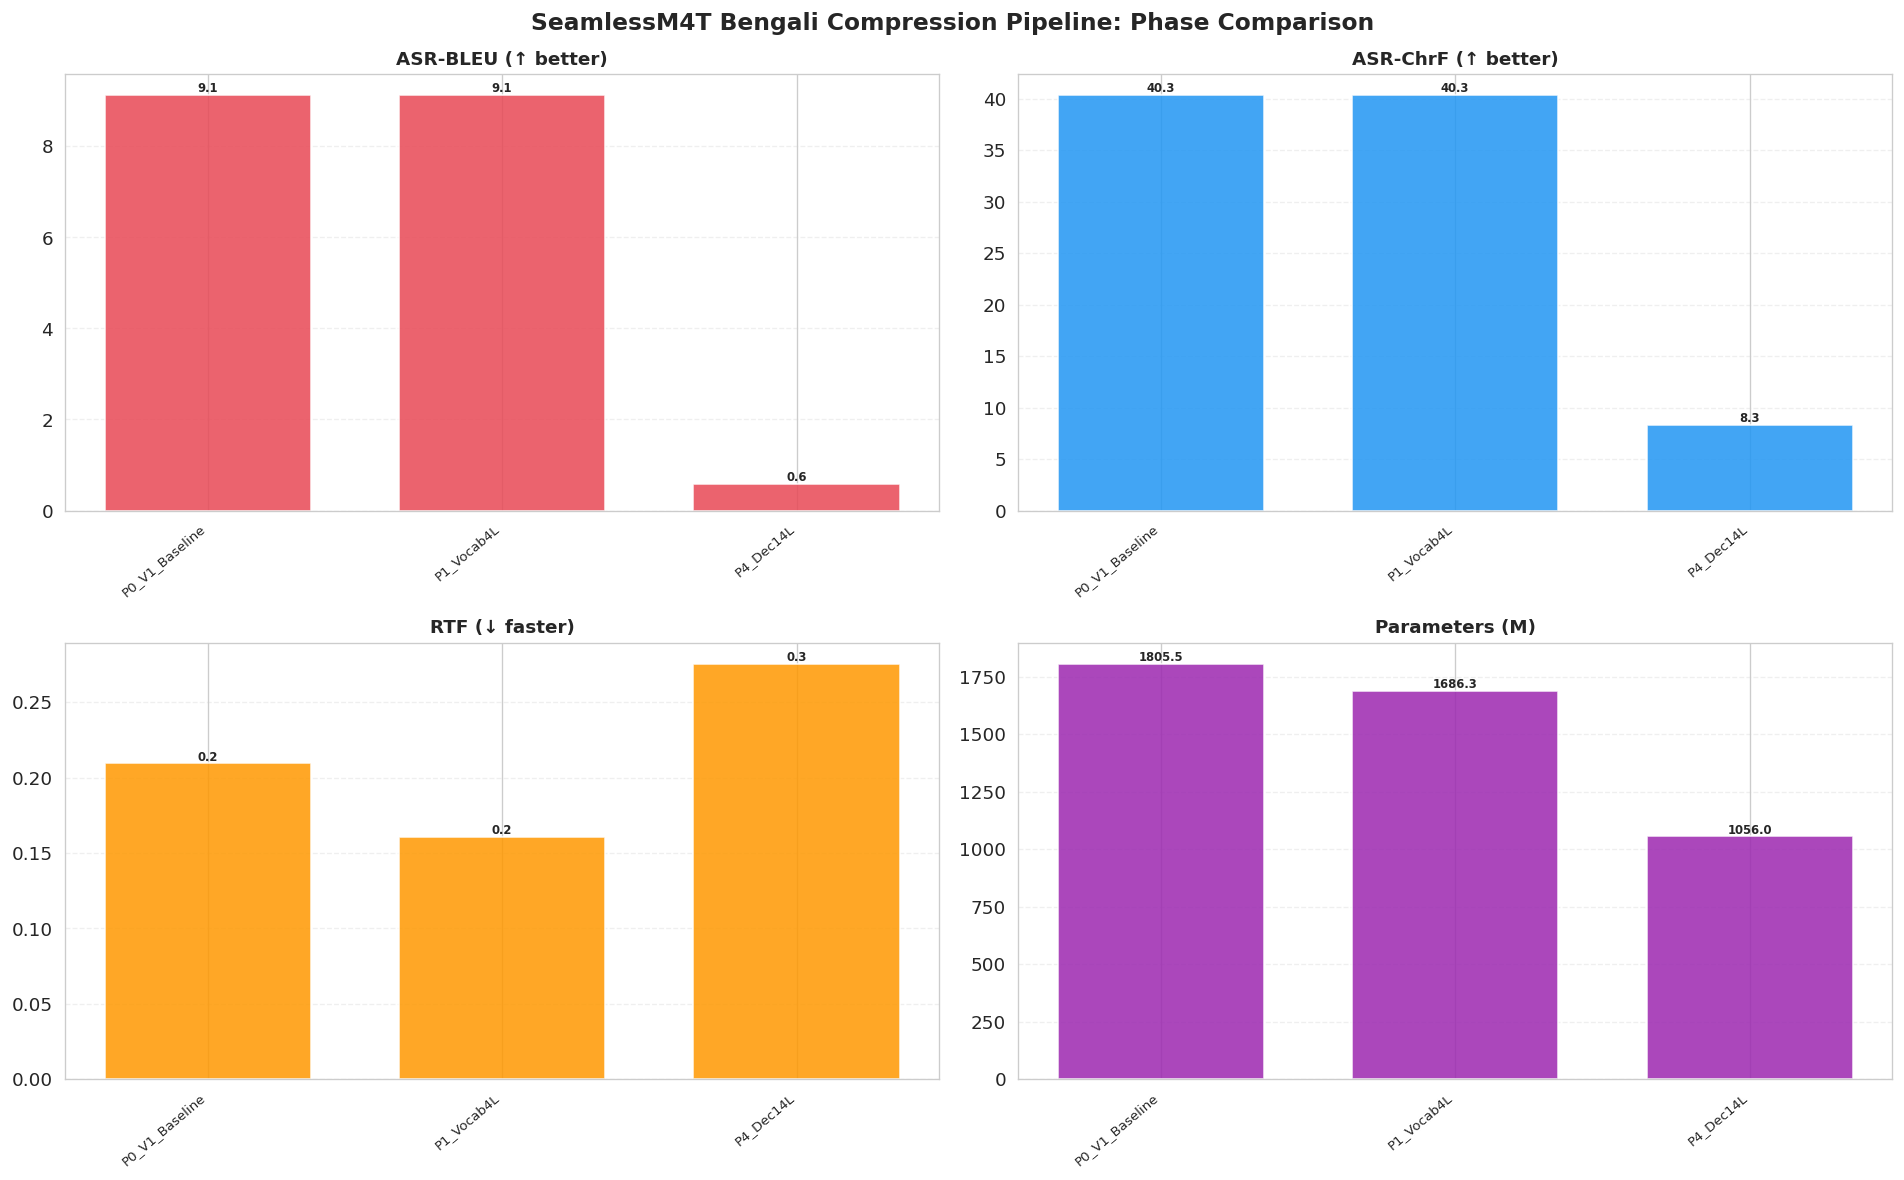

Plotting detailed comparison for 3 phases: ['P0_V1_Baseline', 'P1_Vocab4L', 'P4_Dec14L']


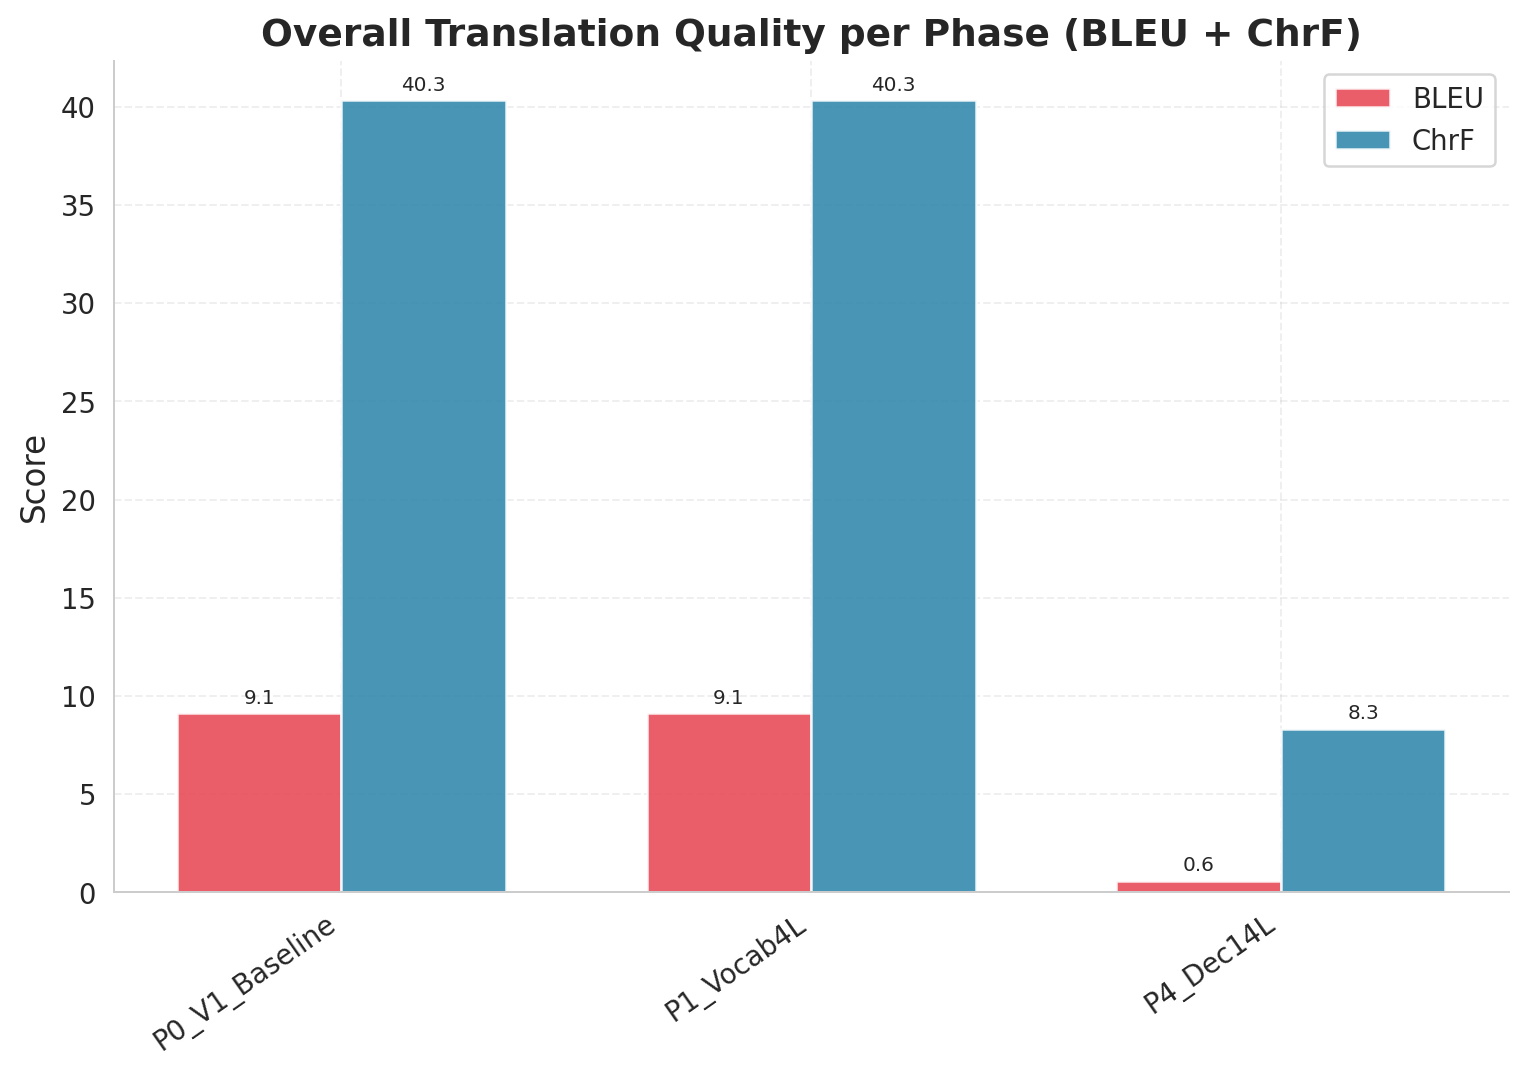

  ✓ Saved: detailed_comparison_01_overall_quality.png  [Overall Quality]


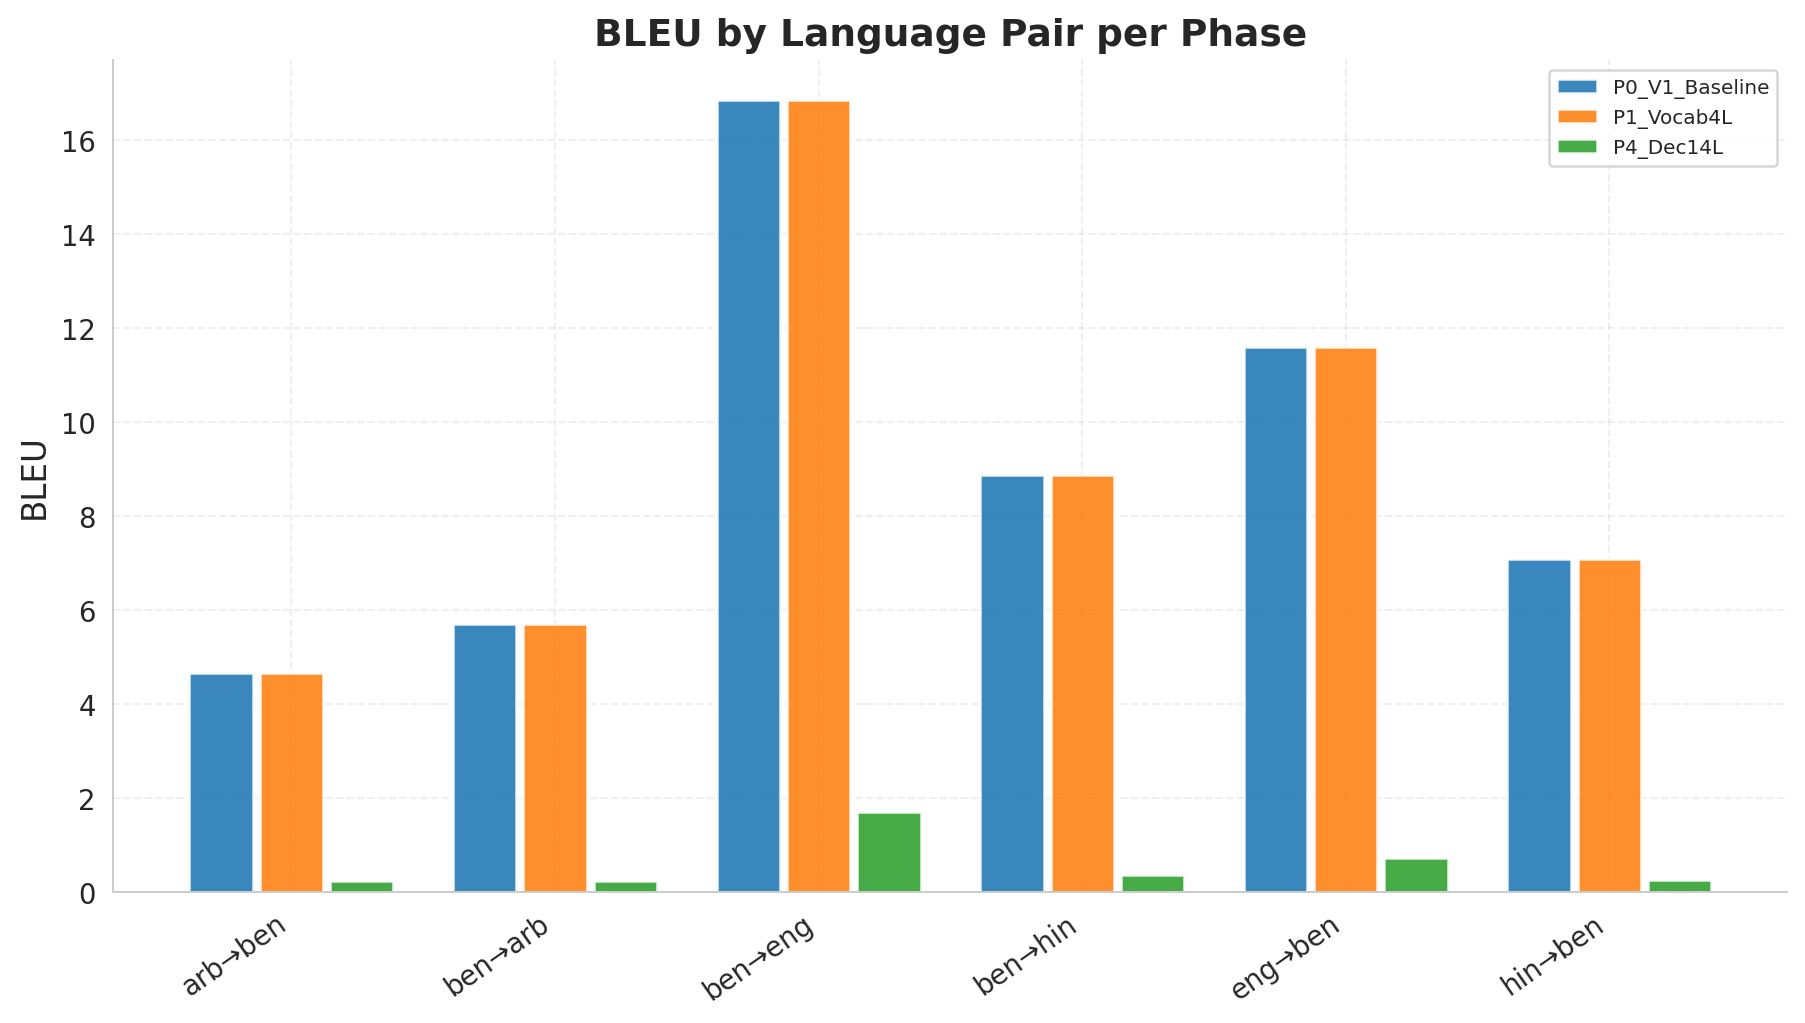

  ✓ Saved: detailed_comparison_02_bleu_by_pair.png  [BLEU by Language Pair]


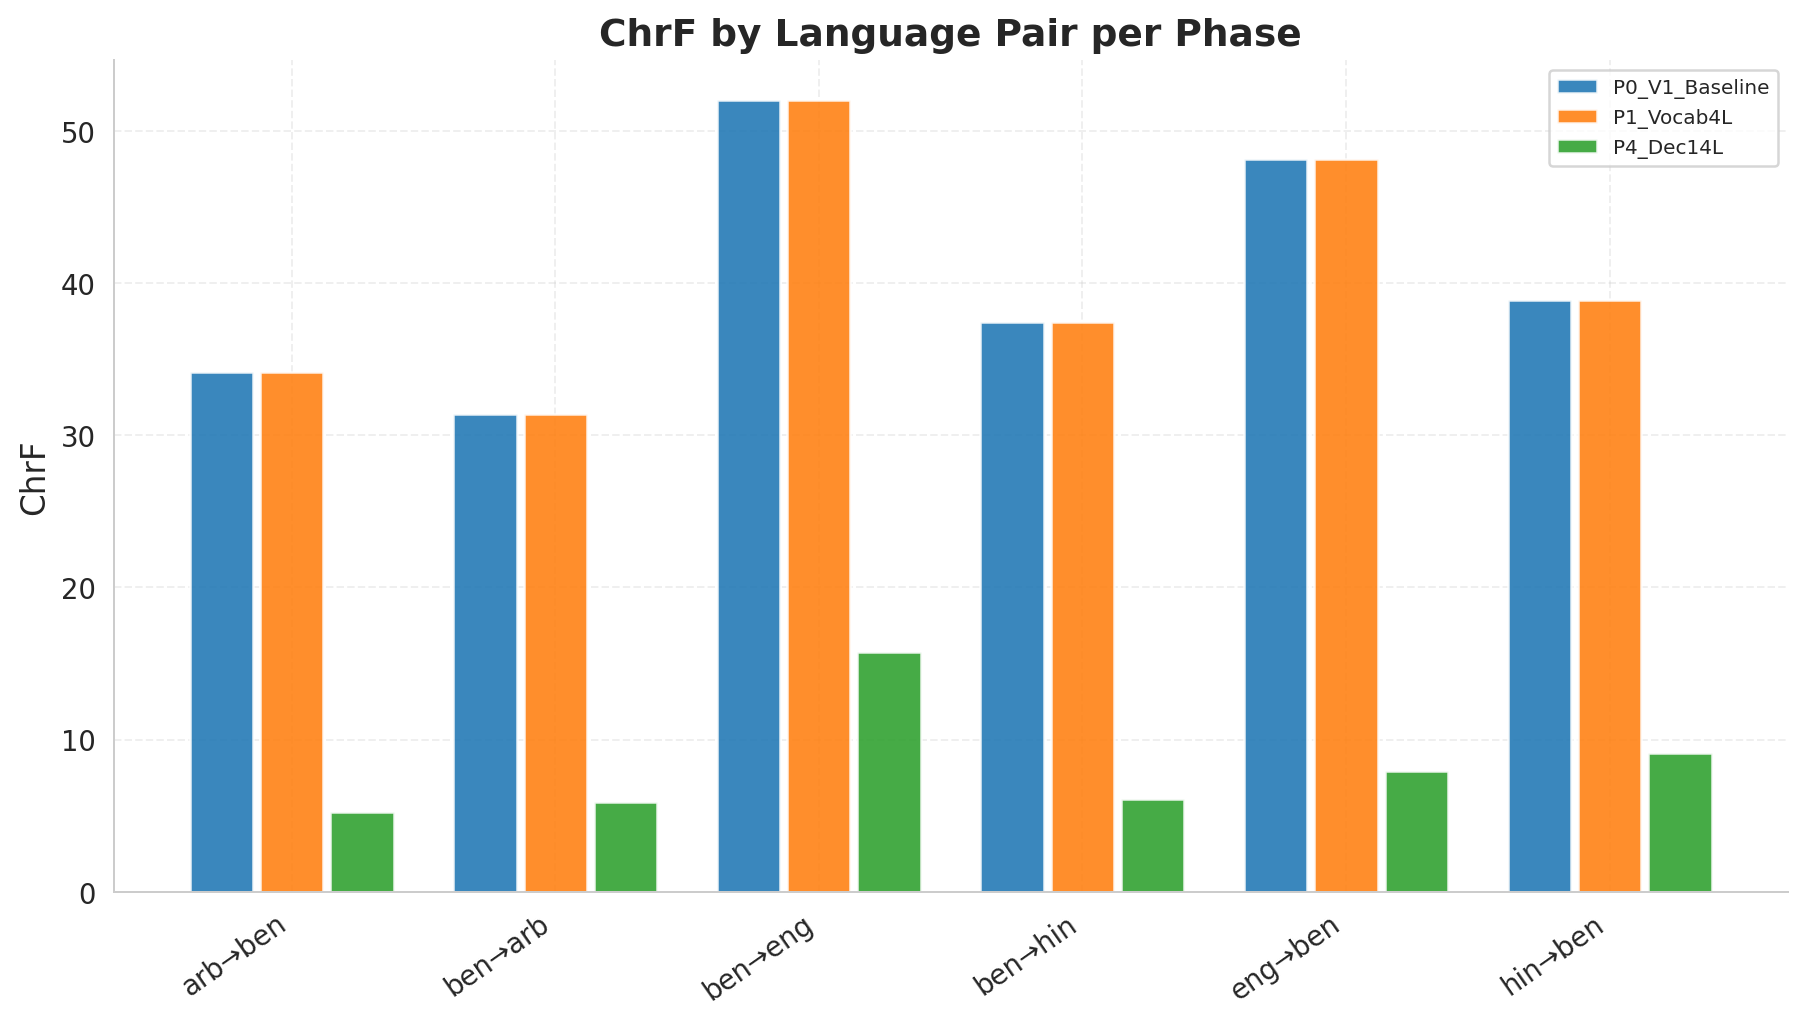

  ✓ Saved: detailed_comparison_03_chrf_by_pair.png  [ChrF by Language Pair]


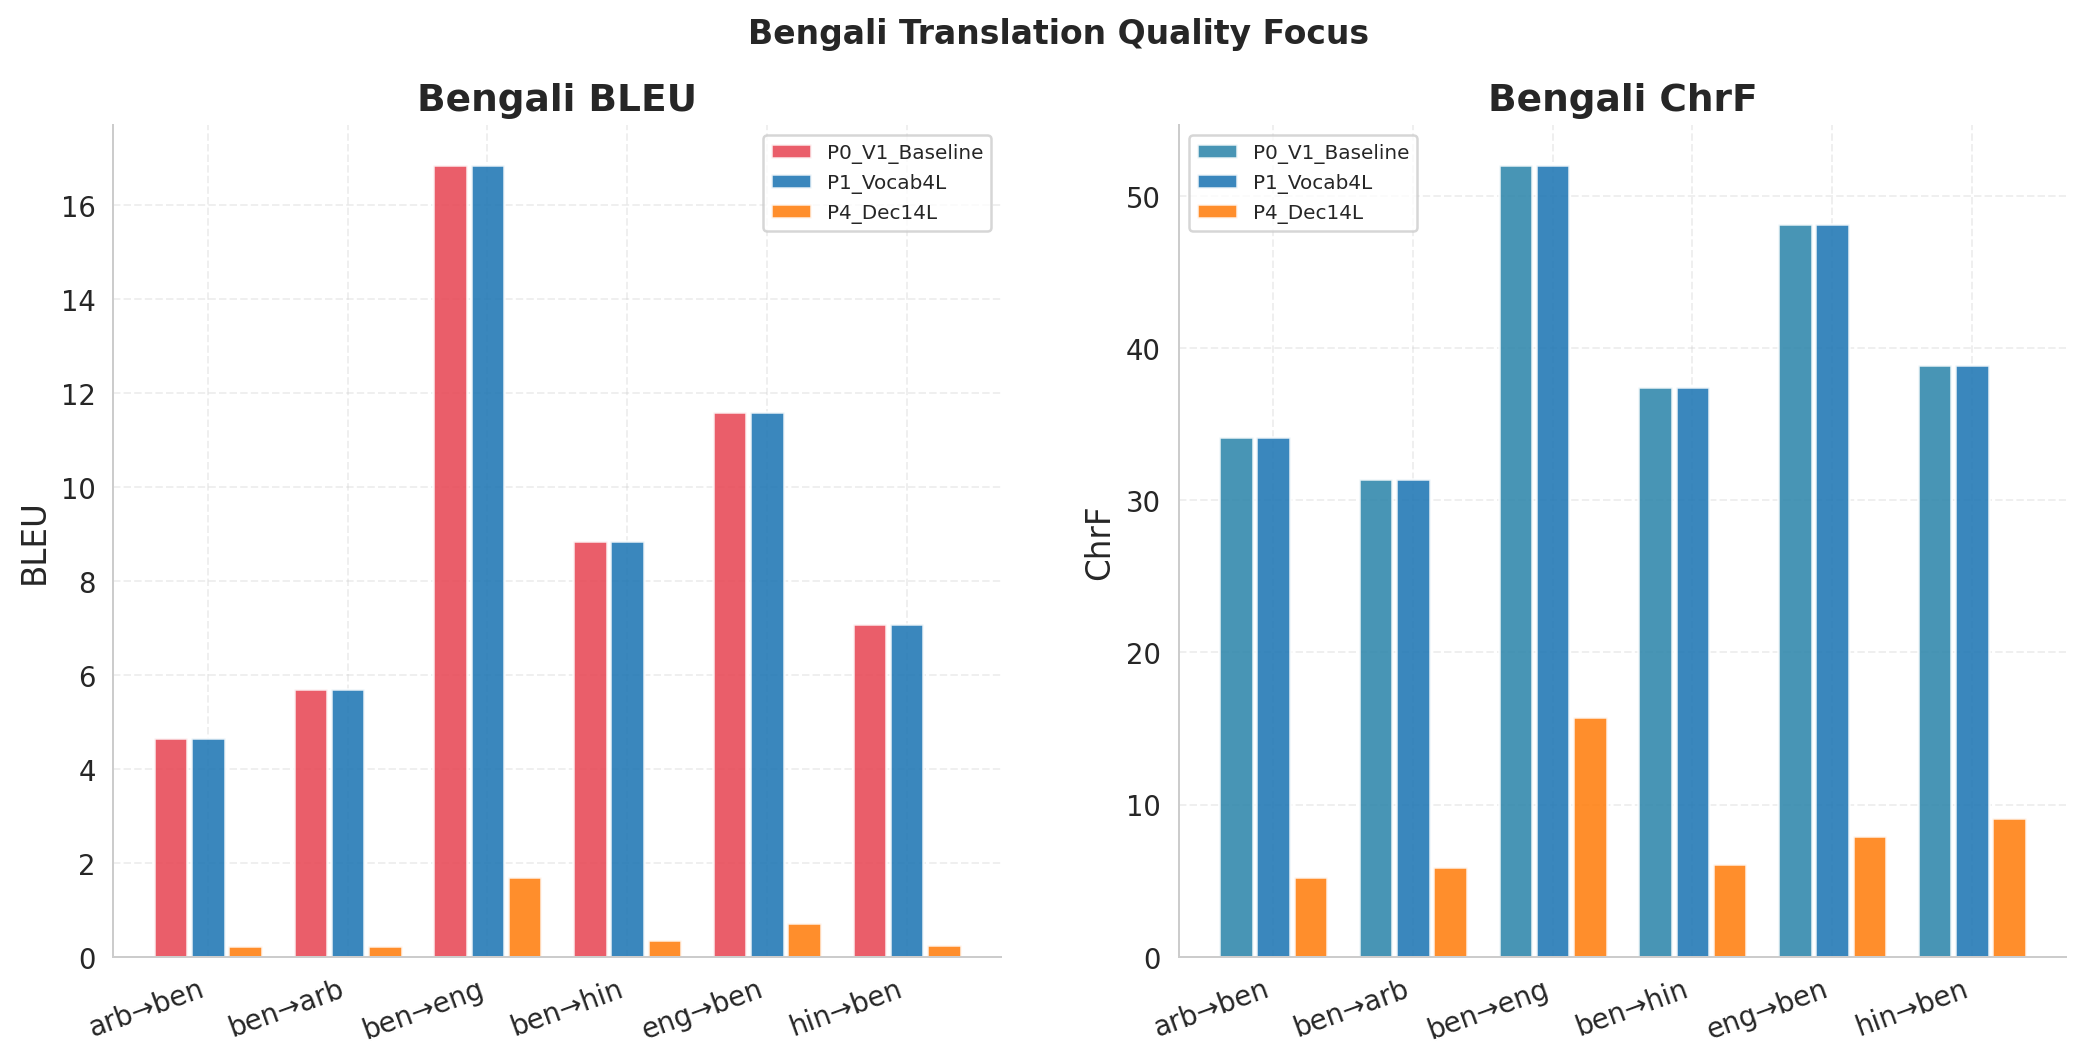

  ✓ Saved: detailed_comparison_04_bengali_focus.png  [Bengali Focus]


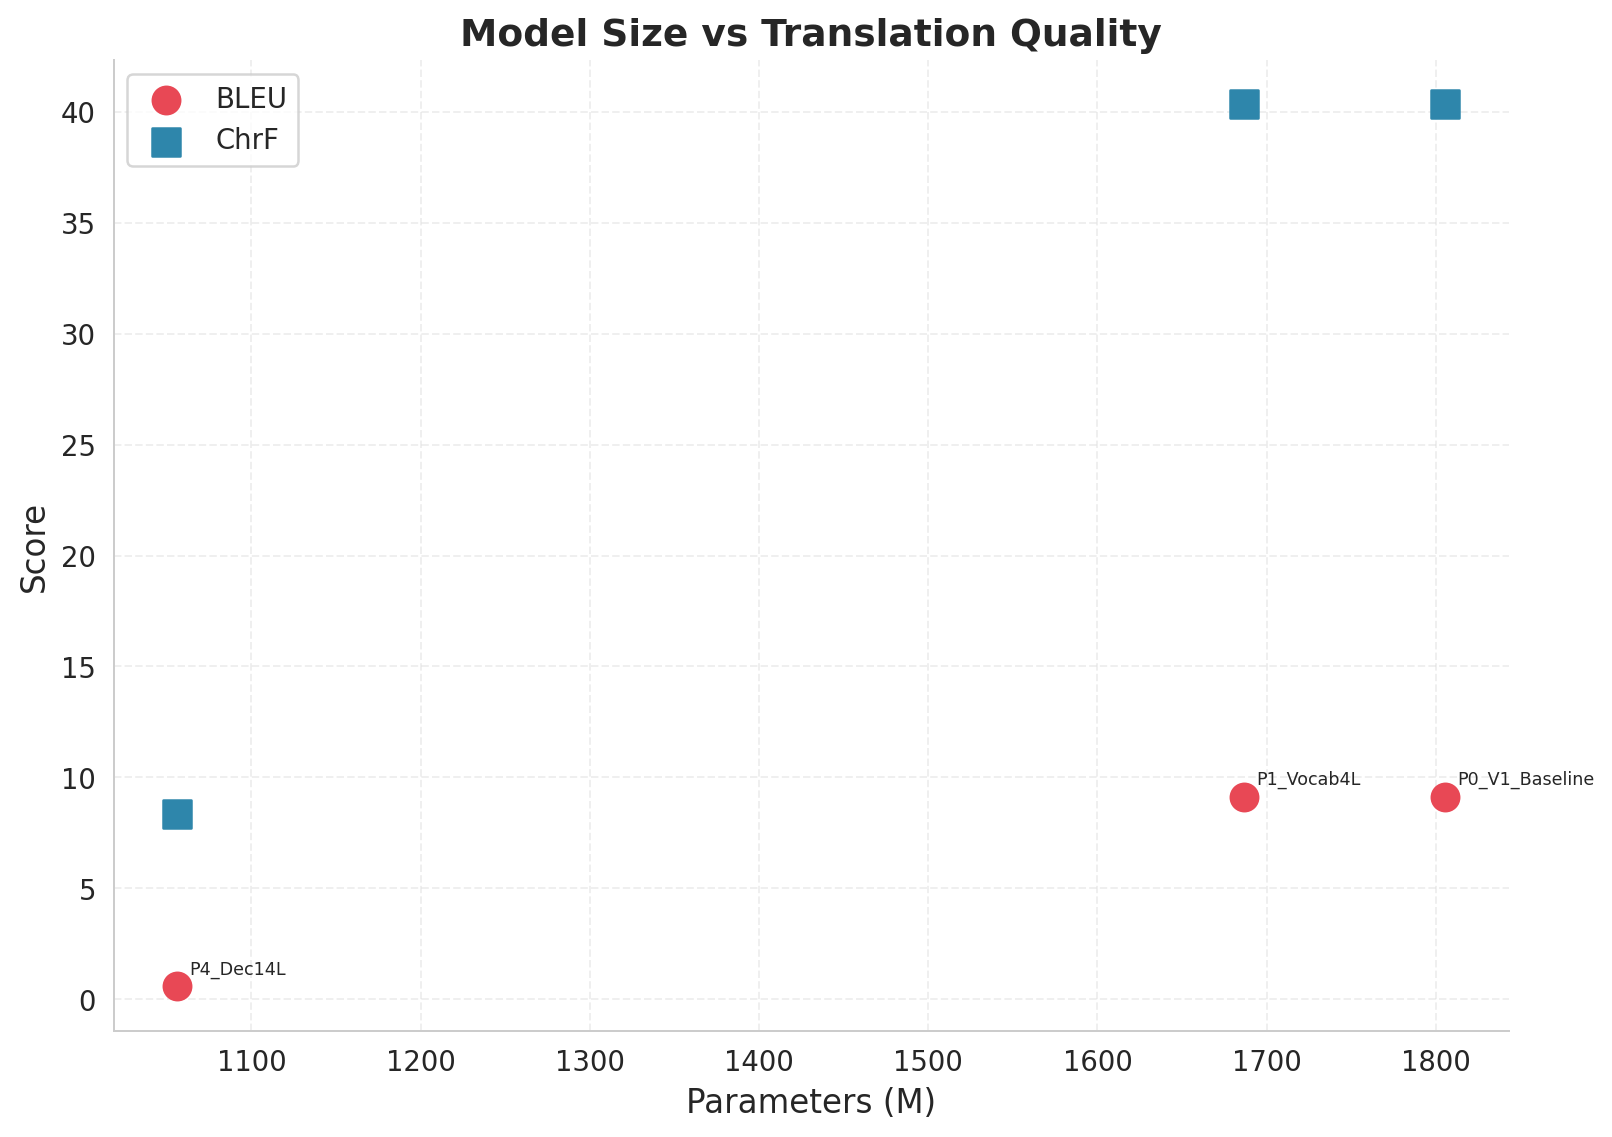

  ✓ Saved: detailed_comparison_05_size_vs_quality.png  [Size vs Quality]


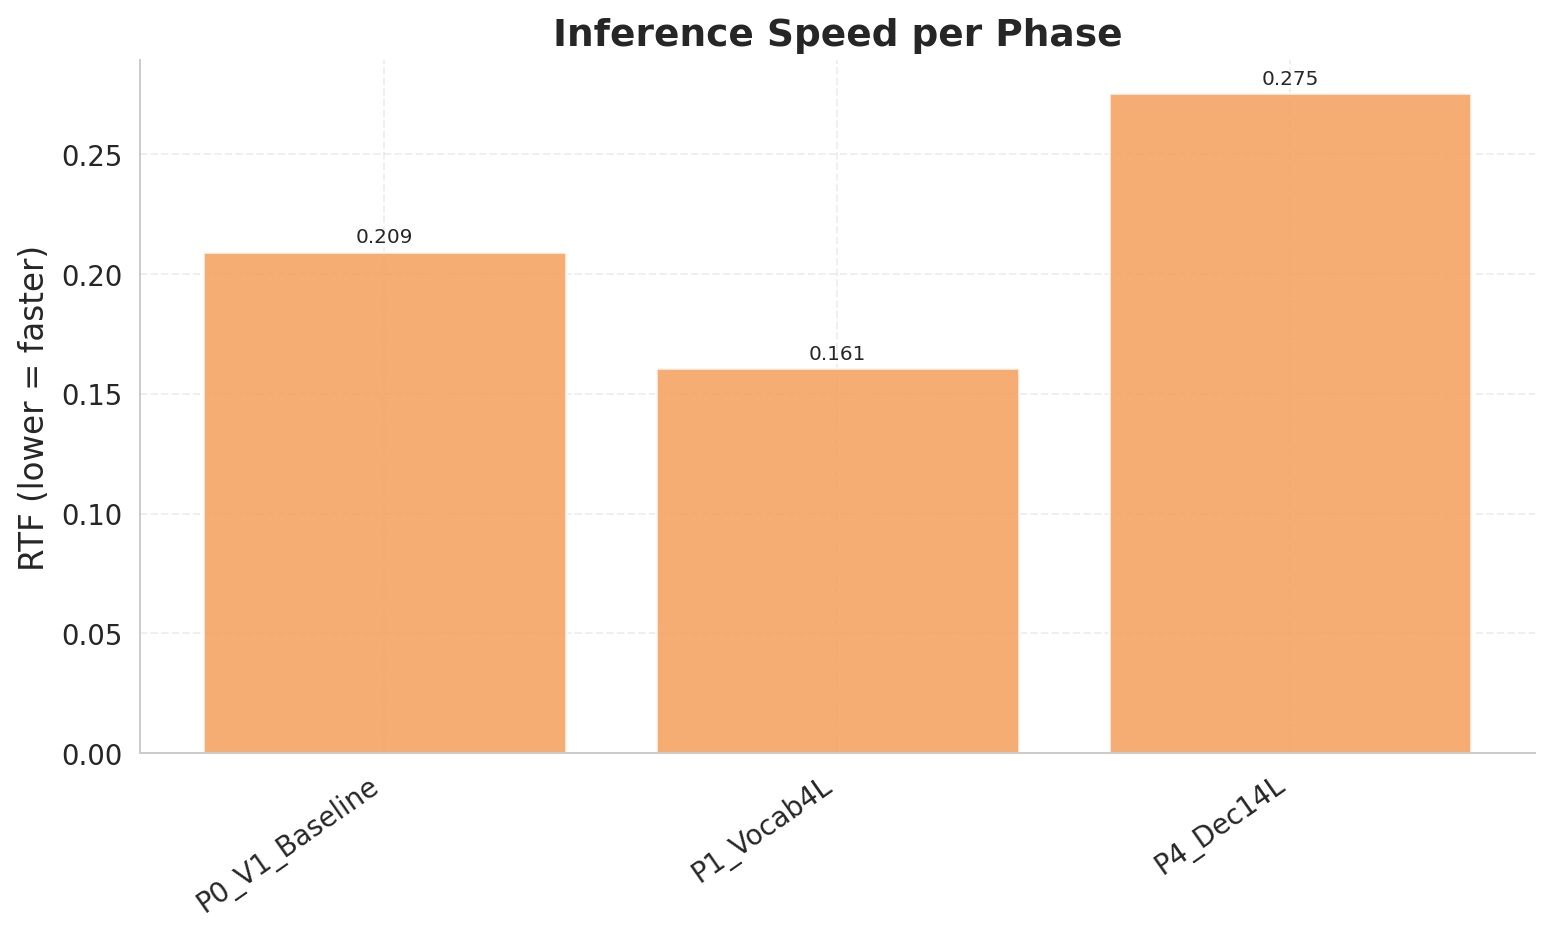

  ✓ Saved: detailed_comparison_06_rtf.png  [Inference Speed RTF]

✅ All 6 figures saved.
   📄 detailed_comparison_01_overall_quality.png
   📄 detailed_comparison_02_bleu_by_pair.png
   📄 detailed_comparison_03_chrf_by_pair.png
   📄 detailed_comparison_04_bengali_focus.png
   📄 detailed_comparison_05_size_vs_quality.png
   📄 detailed_comparison_06_rtf.png


In [37]:
p4_bench = load_latest_checkpoint('phase4_benchmark')
if p4_bench and p4_bench.get('summary', {}).get('avg_bleu', 0) > 0:
    p4_results = p4_bench['results']; p4_summary = p4_bench['summary']
    p4_detailed = p4_bench.get('detailed_summary')
    if not p4_detailed:
        p4_detailed = compute_detailed_summary(p4_results, 'P4_Dec14L', p4_summary['params_M'])
else:
    p4_results, p4_summary = run_benchmark(model_p4, list(eval_samples), 'P4_Dec14L', save_n=2)
    p4_detailed = compute_detailed_summary(p4_results, 'P4_Dec14L', p4_summary['params_M'])
    save_checkpoint(dict(results=p4_results, summary=p4_summary, detailed_summary=p4_detailed),
                    'phase4_benchmark', 0)

store_summary(p4_summary)
store_detailed_summary(p4_detailed)
print_detailed_summary_table('P4_Dec14L')
plot_phase_comparison()
plot_detailed_phase_comparison()


In [38]:
# heed

---
## Phase 5: Full Fine-Tuning — Bengali-Focused Recovery

**Objective**: Restore & surpass teacher BLEU/ChrF on Bengali pairs.

### Strategy
- **Full training** (no LoRA): all parameters unfrozen for maximum capacity.
- Unfrozen: speech encoder, text decoder, shared embeddings, lm_head,
  t2u encoder/decoder, t2u lm_head, speech adapter.
- Vocoder stays frozen (it doesn't affect text quality).
- Gradient checkpointing: speech encoder + text decoder only (largest components).
  All other components remain non-checkpointed for speed.
- AMP fp16 with GradScaler.
- Bengali-pair weighted sampling: 2× oversample ben→* and *→ben pairs.
- Knowledge distillation from teacher (fp16, cuda:1) on top-K logits.


In [39]:
# ── Cell 45: Load pruned student for full fine-tuning ──────────────────────────
import gc, torch, ctypes

def free_cpu_ram():
    gc.collect()
    try: ctypes.CDLL('libc.so.6').malloc_trim(0)
    except Exception: pass

print('Loading phase5_ft_merged for fine-tuning with Custom Device Split...')

# THE SPLIT: Speech Encoder on 0, everything else on 1
custom_device_map = {
    'speech_encoder': 0,
    'shared': 1,
    'text_decoder': 1,
    'lm_head': 1,
    't2u_model': 1,
    'vocoder': 1
}

student, processor = load_model_from_drive('phase5_ft_merged', device_map=custom_device_map)
student = student.to(torch.float16)

# ── Architecture sanity check ──────────────────────────────────────────────────
parent_chk, la_chk = get_encoder_layers(student)
n_enc_chk = len(getattr(parent_chk, la_chk))
parent_chk2, la_chk2 = get_text_decoder_layers(student)
n_dec_chk = len(getattr(parent_chk2, la_chk2))
t2u_enc_chk, t2u_dec_chk = _get_t2u_encoder_decoder(student)
n_t2u_enc = len(_find_layers(t2u_enc_chk)) if t2u_enc_chk else '?'
n_t2u_dec = len(_find_layers(t2u_dec_chk)) if t2u_dec_chk else '?'
print(f'✓ Speech encoder : {n_enc_chk}L')
print(f'✓ Text decoder   : {n_dec_chk}L')
print(f'✓ T2U encoder    : {n_t2u_enc}L')
print(f'✓ T2U decoder    : {n_t2u_dec}L')

S_VOCAB = student.shared.num_embeddings
print(f'✓ Vocab size     : {S_VOCAB}')
print_model_breakdown(student, 'Student (Pruned, Pre-FT)')
gpu_mem()

Loading phase5_ft_merged for fine-tuning with Custom Device Split...
[model] Not in local cache — pulling from remote...
[rclone] Pulled phase5_ft_merged → /kaggle/working/models/phase5_ft_merged
[model] Loading phase5_ft_merged from /kaggle/working/models/phase5_ft_merged ...


Loading weights:   0%|          | 0/1106 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
[model] Loaded phase5_ft_merged.
✓ Speech encoder : 10L
✓ Text decoder   : 14L
✓ T2U encoder    : 5L
✓ T2U decoder    : 5L
✓ Vocab size     : 139697

--- Student (Pruned, Pre-FT) ---
  text_decoder                           495.7M  ( 46.9%)
  speech_encoder                         296.5M  ( 28.1%)
  t2u_model                              221.9M  ( 21.0%)
  shared                                 143.0M  ( 13.5%)
  lm_head                                143.0M  ( 13.5%)
  vocoder                                 41.9M  (  4.0%)
  TOTAL                                 1056.0M
---
  GPU0: 0.59GB alloc / 0.61GB reserved
  GPU1: 1.54GB alloc / 1.55GB reserved


In [40]:
# ── Cell 46: Load teacher on cuda:1 ───────────────────────────────────────────
# Teacher stays in fp16, eval-only, used for KD top-K distillation.
# TOP_K=256 matches battle-tested Phase 7.

TEACHER_DEVICE = 'cuda:1' if N_GPU > 1 else 'cuda:0'
TOP_K_TEACHER  = 256   # ← was 8, now 256 (matches Phase 7 battle-tested)

print(f'Loading teacher model on {TEACHER_DEVICE}...')

from transformers import SeamlessM4Tv2ForSpeechToSpeech
teacher = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map=TEACHER_DEVICE)

# make sure to switch to float16 when training
# from transformers import SeamlessM4Tv2ForSpeechToText
# teacher = SeamlessM4Tv2ForSpeechToText.from_pretrained(
#     MODEL_NAME, torch_dtype=torch.float32, device_map=TEACHER_DEVICE)


teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)
print(f'Teacher loaded. Params: {count_params(teacher):.1f}M')
gpu_mem()

Loading teacher model on cuda:1...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Teacher loaded. Params: 1805.5M
  GPU0: 0.59GB alloc / 0.61GB reserved
  GPU1: 5.18GB alloc / 5.19GB reserved


In [41]:
# ── Cell 47: Unfreeze all except vocoder ──────────────────────────────────────
# Full finetuning: unfreeze everything except vocoder.
# Cast all trainable params to fp32 (required for GradScaler to work correctly).

student.train()

n_frozen = 0
for name, param in student.named_parameters():
    if 'vocoder' in name:
        param.requires_grad_(False)
        n_frozen += param.numel()
    else:
        param.requires_grad_(True)
        param.data = param.data.to(torch.float32)   # trainable params MUST be fp32

print(f'Frozen (vocoder): {n_frozen/1e6:.2f}M params')
all_trainable = [p for p in student.parameters() if p.requires_grad]
n_trainable   = sum(p.numel() for p in all_trainable)
n_total       = sum(p.numel() for p in student.parameters())
print(f'Trainable: {n_trainable/1e6:.1f}M / {n_total/1e6:.1f}M ({n_trainable/n_total*100:.1f}%)')

bad = [(n, p.dtype) for n, p in student.named_parameters()
       if p.requires_grad and p.dtype != torch.float32]
if bad:
    print(f'⚠ {len(bad)} trainable params not fp32 — fixing...')
    for bname, _ in bad:
        p = dict(student.named_parameters())[bname]
        p.data = p.data.to(torch.float32)
    print('  ✓ Fixed')
else:
    print('✓ All trainable params fp32 — GradScaler will work correctly')

gpu_mem()

Frozen (vocoder): 41.91M params
Trainable: 1014.1M / 1056.0M (96.0%)
✓ All trainable params fp32 — GradScaler will work correctly
  GPU0: 1.19GB alloc / 1.28GB reserved
  GPU1: 6.62GB alloc / 6.66GB reserved


In [42]:
print(student)
# heed

SeamlessM4Tv2ForSpeechToSpeech(
  (shared): Embedding(139697, 1024, padding_idx=0)
  (speech_encoder): SeamlessM4Tv2SpeechEncoder(
    (feature_projection): SeamlessM4Tv2ConformerFeatureProjection(
      (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=160, out_features=1024, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SeamlessM4Tv2ConformerEncoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): ModuleList(
        (0-9): 10 x SeamlessM4Tv2ConformerEncoderLayer(
          (ffn1_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (ffn1): SeamlessM4Tv2ConformerFeedForward(
            (intermediate_dropout): Dropout(p=0.0, inplace=False)
            (intermediate_dense): Linear(in_features=1024, out_features=4096, bias=True)
            (intermediate_act_fn): SiLU()
            (output_dense): Linear(in_features=4096, out_features=1024, bias=True)
       

In [43]:
# ── Cell 48: Gradient checkpointing strategy for full fine-tuning on 2×T4 ─────
#
# The pruned student has only 8 speech encoder layers + 8 text decoder layers.
# Full finetuning on this small model does NOT require aggressive GC.
#
# VRAM budget (2×T4, 16GB each):
#   - Student on cuda:0: ~4-5 GB weights (fp16) + fp32 optimizer states ~8-10 GB
#   - Teacher on cuda:1: ~3.6 GB (frozen, no gradients)
#   - Activations (batch=4, no GC): ~2-3 GB
#   - Total cuda:0: ~14-15 GB → fits without GC
#
# GC ON text_decoder only is a safe fallback if you see OOM.
# GC OFF = faster training (no recomputation overhead).
#
# Strategy: NO gradient checkpointing. Use batch_size=4, grad_accum=8.
# If OOM: enable text_decoder GC (uncomment block below).

import ctypes

def disable_all_gradient_checkpointing(model):
    """Kill all gradient checkpointing — needed after loading from checkpoint."""
    killed = []
    if hasattr(model, 'gradient_checkpointing_disable'):
        model.gradient_checkpointing_disable()
        killed.append('model.gradient_checkpointing_disable()')
    if hasattr(model, 'config'):
        if getattr(model.config, 'gradient_checkpointing', False):
            model.config.gradient_checkpointing = False
            killed.append('model.config.gradient_checkpointing')
            
    for name, module in model.named_modules():
        if getattr(module, 'gradient_checkpointing', False):
            module.gradient_checkpointing = False
            killed.append(f'{name}.gradient_checkpointing')
        if hasattr(module, 'config'):
            if getattr(module.config, 'gradient_checkpointing', False):
                module.config.gradient_checkpointing = False
                killed.append(f'{name}.config.gradient_checkpointing')
                
    for attr_path in [
        'text_decoder', 'speech_encoder', 'speech_encoder.encoder',
        't2u_model', 't2u_model.model',
        't2u_model.model.encoder', 't2u_model.model.decoder',
    ]:
        try:
            obj = model
            for part in attr_path.split('.'):
                obj = getattr(obj, part)
            if getattr(obj, 'gradient_checkpointing', False):
                obj.gradient_checkpointing = False
                killed.append(f'{attr_path}.gradient_checkpointing direct')
        except AttributeError:
            pass
            
    if killed:
        print(f'✓ Killed GC at {len(killed)} locations: {killed[:3]}...')
    else:
        print('✓ No gradient checkpointing found (clean)')

    # ── 15GB VRAM OPTIMIZED GC CONFIGURATION ─────────────────────
    
    enabled = []
    try:
        # 1. Speech Encoder (CRITICAL): 10 Conformer layers with long audio sequences. 
        # Checkpointing this saves the most VRAM.
        if hasattr(model, 'speech_encoder'):
            model.speech_encoder.gradient_checkpointing = True
            enabled.append('speech_encoder')
            
        # 2. Text Decoder: 14 layers. High memory footprint.
        # if hasattr(model, 'text_decoder'):
        #     model.text_decoder.gradient_checkpointing = True
        #     enabled.append('text_decoder')

        # 3. T2U Model: Left DISABLED for maximum speed. 
        # Uncomment the lines below ONLY if you still hit OOM.
        # if hasattr(model, 't2u_model'):
        #     model.t2u_model.gradient_checkpointing = True
        #     enabled.append('t2u_model')

        print(f'✓ GC selectively ENABLED for: {", ".join(enabled)}')
        
    except Exception as e:
        print(f'  Failed to enable GC: {e}')

    return killed
    

# Kill any GC that may have been saved in checkpoint
disable_all_gradient_checkpointing(student)

# Verify it's all OFF
still_on = [name for name, m in student.named_modules()
            if getattr(m, 'gradient_checkpointing', False)]

print(f'⚠ Still on: {still_on}')

# if still_on:
#     print(f'⚠ Still on: {still_on} — force-killing')
#     for name, m in student.named_modules():
#         if name in still_on:
#             m.gradient_checkpointing = False
# else:
#     print('✓ Confirmed: gradient checkpointing fully OFF')

print()
print('VRAM strategy: GC=OFF, BATCH=4, ACCUM=8, effective_batch=32')

gpu_mem()

✓ Killed GC at 1 locations: ['model.gradient_checkpointing_disable()']...
✓ GC selectively ENABLED for: speech_encoder
⚠ Still on: ['speech_encoder']

VRAM strategy: GC=OFF, BATCH=4, ACCUM=8, effective_batch=32
  GPU0: 1.19GB alloc / 1.28GB reserved
  GPU1: 6.62GB alloc / 6.66GB reserved


In [44]:
# ── Cell 49A: Vocab remap tables (exact Phase 7 / Cell 41+43+48 pattern) ──────
import torch, math, time, random
import torch.nn.functional as F
import numpy as np

_tok        = processor.tokenizer
T_VOCAB     = 256102   # teacher full vocab (facebook/seamless-m4t-v2-large)
UNK_ID_STUDENT = 3
UNMAPPED_SENTINEL = -1

# ── Build OLD_TO_NEW with clean -1 sentinel (not UNK) ─────────────────────────
# This is critical: sentinel=-1 means "unmapped, skip in KD loss"
# Using UNK=3 as sentinel would pollute the KD loss with wrong tokens.

if hasattr(student, '_vocab_remap_to_old'):
    remap_to_old = student._vocab_remap_to_old   # [S_VOCAB] → old full-vocab IDs
else:
    raise RuntimeError('student._vocab_remap_to_old not found — '
                       'load the model with load_model_from_drive first.')

old_to_new_clean = torch.full((T_VOCAB,), UNMAPPED_SENTINEL, dtype=torch.long)
for new_id, old_id in enumerate(remap_to_old.tolist()):
    if 0 <= old_id < T_VOCAB:
        old_to_new_clean[old_id] = new_id

# Sanity: EOS (token 3) must map correctly
assert old_to_new_clean[3].item() == 3, 'EOS should map to student EOS=3'

OLD_TO_NEW_CPU = old_to_new_clean   # [T_VOCAB] long CPU — used by collate
OLD_TO_NEW_GPU = old_to_new_clean.to('cuda:1')  # [T_VOCAB] long cuda:0 — used by loss

n_mapped = (OLD_TO_NEW_CPU >= 0).sum().item()
print(f'Mapped: {n_mapped}/{T_VOCAB} ({100*n_mapped/T_VOCAB:.1f}%)')
print(f'EOS (token 3) → student: {OLD_TO_NEW_CPU[3].item()}  ← must be 3')
print(f'OLD_TO_NEW_GPU: {OLD_TO_NEW_GPU.numel()*4/1e6:.1f}MB VRAM')

# ── Special token IDs in both vocab spaces ────────────────────────────────────
PAD_ID_FULL = _tok.pad_token_id if _tok.pad_token_id is not None else 1
BOS_ID_FULL = _tok.bos_token_id if _tok.bos_token_id is not None else 0
EOS_ID_FULL = _tok.eos_token_id if _tok.eos_token_id is not None else 2

def _remap_special_token(full_id):
    if full_id is None or full_id < 0: return UNK_ID_STUDENT
    mapped = OLD_TO_NEW_CPU[min(full_id, T_VOCAB - 1)].item()
    return mapped if mapped >= 0 else UNK_ID_STUDENT

PAD_ID_S = _remap_special_token(PAD_ID_FULL)
BOS_ID_S = _remap_special_token(BOS_ID_FULL)
EOS_ID_S = _remap_special_token(EOS_ID_FULL)

def remap_ids(ids_cpu: torch.Tensor) -> torch.Tensor:
    """Remap full-vocab IDs → student vocab. Unmapped → UNK_ID_STUDENT."""
    flat     = ids_cpu.reshape(-1).clamp(0, T_VOCAB - 1)
    remapped = OLD_TO_NEW_CPU[flat].reshape(ids_cpu.shape)
    remapped[remapped < 0] = UNK_ID_STUDENT
    return remapped

def _lang_token_id_student(lang_code):
    full_id = _tok.convert_tokens_to_ids(f'__{lang_code}__')
    if full_id is None or full_id == _tok.unk_token_id:
        return UNK_ID_STUDENT
    mapped = OLD_TO_NEW_CPU[min(full_id, T_VOCAB - 1)].item()
    return max(0, min(mapped if mapped >= 0 else UNK_ID_STUDENT, S_VOCAB - 1))

print(f'\nSpecial tokens: PAD_S={PAD_ID_S}  BOS_S={BOS_ID_S}  EOS_S={EOS_ID_S}')
for _l in ['eng', 'ben', 'hin', 'arb']:
    _s = _lang_token_id_student(_l)
    assert 0 <= _s < S_VOCAB, f'{_l} → {_s} out of range'
    print(f'  {_l}: student_id={_s}')
print('✓ Vocab remap ready.')

Mapped: 139697/256102 (54.5%)
EOS (token 3) → student: 3  ← must be 3
OLD_TO_NEW_GPU: 1.0MB VRAM

Special tokens: PAD_S=0  BOS_S=2  EOS_S=3
  eng: student_id=139620
  ben: student_id=139607
  hin: student_id=139631
  arb: student_id=139601
✓ Vocab remap ready.


In [45]:
# ── Cell 49B: Collation — exact Phase 7 / Cell 44 layout ──────────────────────
#
# Token layout (identical to Phase 7):
#
#   dec_full (teacher input):  [BOS_FULL | __tgt_lang___FULL | content_ids_FULL]
#   dec_s    (student input):  [BOS_S    | __tgt_lang___S    | content_ids_S   ]
#   labels_s (student target): [__tgt_lang___S | content_ids_S | EOS_S         ]
#
# dec_s[t] predicts labels_s[t] — standard autoregressive teacher-forcing.

MAX_AUDIO_SEC  = 20    # skip samples longer than this (OOM prevention)
MAX_TGT_TOKENS = 128   # truncate target sequences

def collate_s2t_batch(samples):
    """
    Exact Phase 7 collation. Returns dict with:
      feat      : processor output (input_features, attention_mask) — CPU
      dec_s     : [B, T+2] long — student decoder input
      dec_full  : [B, T+2] long — teacher decoder input (full vocab)
      labels_s  : [B, T+2] long — student labels (-100 for padding)
      tgt_langs : list[str]
    """
    valid = [s for s in samples if len(s['wav']) / 16000 <= MAX_AUDIO_SEC]
    if not valid:
        return None

    wavs      = [s['wav']      for s in valid]
    tgt_refs  = [s['ref']      for s in valid]
    tgt_langs = [s['tgt_lang'] for s in valid]

    # ── Audio features ────────────────────────────────────────────────────────
    feat_out = processor(audio=wavs, sampling_rate=16000,
                         return_tensors='pt', padding=True)

    # ── Tokenize target text (no special tokens — we add them manually) ────────
    enc_full = processor.tokenizer(
        tgt_refs, padding=True, truncation=True,
        max_length=MAX_TGT_TOKENS, return_tensors='pt',
        add_special_tokens=False
    )
    content_ids_full = enc_full['input_ids']    # [B, T]  full vocab
    content_mask     = enc_full['attention_mask']  # [B, T]  1=real 0=pad
    B, T = content_ids_full.shape

    # ── Build teacher sequence: [BOS | __tgt__ | content] ─────────────────────
    bos_full      = torch.full((B, 1), BOS_ID_FULL, dtype=torch.long)
    tgt_lang_full = torch.tensor(
        [_tok.convert_tokens_to_ids(f'__{lg}__') for lg in tgt_langs],
        dtype=torch.long).unsqueeze(1)
    dec_full = torch.cat([bos_full, tgt_lang_full, content_ids_full], dim=1)

    # ── Build student sequence (remapped vocab) ────────────────────────────────
    content_ids_s = remap_ids(content_ids_full)   # [B, T]  student vocab
    bos_s         = torch.full((B, 1), BOS_ID_S,  dtype=torch.long)
    tgt_lang_s    = torch.tensor(
        [_lang_token_id_student(lg) for lg in tgt_langs],
        dtype=torch.long).unsqueeze(1)
    dec_s = torch.cat([bos_s, tgt_lang_s, content_ids_s], dim=1).clamp(0, S_VOCAB - 1)

    # ── Build student labels: [__tgt__ | content | EOS] ──────────────────────
    eos_s        = torch.full((B, 1), EOS_ID_S, dtype=torch.long)
    labels_full  = torch.cat([tgt_lang_s, content_ids_s, eos_s], dim=1)  # [B, T+2]

    # Mask padding positions with -100 (lang token + EOS are never masked)
    prefix_mask  = torch.ones(B, 1, dtype=torch.long)   # lang token always real
    suffix_mask  = torch.ones(B, 1, dtype=torch.long)   # EOS always real
    labels_mask  = torch.cat([prefix_mask, content_mask, suffix_mask], dim=1)

    labels_s = labels_full.clone()
    labels_s[labels_mask == 0] = -100
    labels_s[labels_s >= 0] = labels_s[labels_s >= 0].clamp(0, S_VOCAB - 1)

    return dict(
        feat      = feat_out,        # processor output (CPU)
        dec_s     = dec_s,           # [B, T+2] student input
        dec_full  = dec_full,        # [B, T+2] teacher input
        labels_s  = labels_s,        # [B, T+2] student labels
        tgt_langs = tgt_langs,
    )


# def load_audio_from_meta(meta: dict) -> np.ndarray:
#     """Loads audio whether from FLEURS parquet (old format) or pseudo parquet (bytes format)."""
#     df = pd.read_parquet(meta['_src_file'], columns=['audio_bytes', 'sampling_rate'])
#     row = df.iloc[meta['_src_idx']]
#     audio = np.frombuffer(row['audio_bytes'], dtype=np.float32).copy()
#     sr    = int(row['sampling_rate'])
#     if sr != 16000:
#         import resampy
#         audio = resampy.resample(audio, sr, 16000)
#     return audio


print('✓ Collation ready (exact Phase 7 token layout)')
print(f'  dec layout: [BOS | __tgt__ | content]  length=T+2')
print(f'  lab layout: [__tgt__ | content | EOS]  length=T+2')

✓ Collation ready (exact Phase 7 token layout)
  dec layout: [BOS | __tgt__ | content]  length=T+2
  lab layout: [__tgt__ | content | EOS]  length=T+2


In [46]:
# ── Cell C: Fixed Loss Functions ──────────────────────────────────────────────
#
# Changes vs original:
#   1. KD_TEMPERATURE lowered 3.0 → 2.0  (sharper teacher signal, less noise)
#   2. Bengali position CE weighting: 2× weight on Bengali-target positions
#   3. compute_recovery_loss_gpu accepts per-call alpha (used by scheduler below)
#   4. All ops stay on cuda:1 — matching where s_logits, topk, labels all live

import torch, torch.nn.functional as F

KD_TEMPERATURE = 2.0    # was 3.0 — sharper teacher distribution
TOP_K_TEACHER  = 128    # was 256 — fewer soft targets, cleaner gradient

# Per-epoch KD alpha schedule.
# Key insight: CE must dominate (model needs to commit to correct tokens).
# KD assists regularisation only. Never exceed 0.40.
#
# Epoch 0-1: 0.30  — backbone recovery, CE leads heavily
# Epoch 2-3: 0.25  — stabilise, still CE-led
# Epoch 4-5: 0.20  — consolidation
# Epoch 6-7: 0.15  — CE almost entirely, KD just regularises

def get_kd_alpha(epoch_idx):
    schedule = [0.30, 0.30, 0.25, 0.25, 0.20, 0.20, 0.15, 0.15]
    return schedule[min(epoch_idx, len(schedule) - 1)]


def _label_smoothed_nll(logits, targets, smoothing=0.1, ignore_index=-100,
                         ben_mask=None, ben_weight=2.0):
    """
    Label-smoothed NLL with optional Bengali position upweighting.

    logits    : [N, V]  fp32  cuda:1
    targets   : [N]     long  cuda:1
    ben_mask  : [N]     bool  cuda:1  — True where this position is Bengali-target
    ben_weight: scalar  — multiply Bengali loss by this factor
    """
    V    = logits.size(-1)
    mask = targets != ignore_index
    if not mask.any():
        return logits.sum() * 0.0

    with torch.no_grad():
        smooth = torch.full_like(logits, smoothing / (V - 1))
        smooth.scatter_(-1, targets.clamp(min=0).unsqueeze(-1), 1.0 - smoothing)

    log_p   = F.log_softmax(logits, dim=-1)
    per_tok = -(smooth * log_p).sum(-1)       # [N]

    # Upweight Bengali positions
    if ben_mask is not None and ben_mask.any():
        weight = torch.ones(per_tok.shape, device=per_tok.device, dtype=per_tok.dtype)
        weight[ben_mask] = ben_weight
        per_tok = per_tok * weight

    return per_tok[mask].mean()


def sparse_kl_from_topk_gpu(s_logits, topk_vals_1, topk_idx_full_1, T=KD_TEMPERATURE):
    """
    KD loss — all tensors on cuda:1.

    s_logits        : [B, L, S_VOCAB]   fp32   cuda:1
    topk_vals_1     : [B, L, k]         fp32   cuda:1
    topk_idx_full_1 : [B, L, k]         long   cuda:1  (T_VOCAB indices)
    """
    B, L, V_s = s_logits.shape
    k = topk_vals_1.shape[-1]

    # Remap T_VOCAB → S_VOCAB using the lookup table (both on cuda:1)
    flat_full  = topk_idx_full_1.reshape(-1).clamp(0, T_VOCAB - 1)
    flat_s     = OLD_TO_NEW_GPU[flat_full]        # already on cuda:1
    topk_idx_s = flat_s.reshape(B, L, k)

    valid       = topk_idx_s >= 0
    vals_masked = topk_vals_1 * valid.float()
    denom       = vals_masked.sum(-1, keepdim=True).clamp(min=1e-9)
    topk_t      = vals_masked / denom

    idx_clamped = topk_idx_s.clamp(min=0, max=V_s - 1)
    gathered    = s_logits.gather(-1, idx_clamped)
    gathered    = gathered.masked_fill(~valid, -1e9)

    s_log    = F.log_softmax(gathered / T, dim=-1)
    has_valid = valid.any(-1)
    if not has_valid.any():
        return s_logits.sum() * 0.0

    kl = F.kl_div(
        s_log[has_valid],
        topk_t[has_valid],
        reduction='batchmean',
    ) * (T ** 2)

    return kl


def compute_recovery_loss_gpu(s_logits, labels_dev,
                               topk_vals_1, topk_idx_1,
                               alpha, smoothing=0.1,
                               tgt_langs=None):
    """
    Full loss — all on cuda:1.

    s_logits    : [B, L, S_VOCAB]   fp32   cuda:1
    labels_dev  : [B, L]            long   cuda:1
    topk_vals_1 : [B, L, k]         fp32   cuda:1
    topk_idx_1  : [B, L, k]         long   cuda:1
    alpha       : KD weight (CE weight = 1 - alpha)
    tgt_langs   : list[str] of length B  — used to upweight Bengali
    """
    B, L, V_s = s_logits.shape

    # Build Bengali mask: all token positions for Bengali-target samples get 2× CE
    ben_mask = None
    if tgt_langs is not None:
        is_ben = torch.tensor([t == 'ben' for t in tgt_langs],
                               dtype=torch.bool, device=s_logits.device)  # [B]
        if is_ben.any():
            ben_mask = is_ben.unsqueeze(1).expand(B, L).reshape(-1)       # [B*L]

    s_flat  = s_logits.contiguous().reshape(-1, V_s)
    l_flat  = labels_dev.contiguous().reshape(-1)

    ce  = _label_smoothed_nll(s_flat, l_flat, smoothing=smoothing,
                               ben_mask=ben_mask, ben_weight=2.0)
    kd  = sparse_kl_from_topk_gpu(s_logits, topk_vals_1, topk_idx_1)

    loss = (1.0 - alpha) * ce + alpha * kd
    return loss, ce.item(), kd.item()


print('✓ Fixed loss functions ready.')
print(f'  KD_TEMPERATURE={KD_TEMPERATURE}  TOP_K={TOP_K_TEACHER}')
print(f'  Alpha schedule: epoch0-1=0.30, epoch2-3=0.25, epoch4-5=0.20, epoch6-7=0.15')
print(f'  Bengali CE upweight: 2× on all Bengali-target positions')

✓ Fixed loss functions ready.
  KD_TEMPERATURE=2.0  TOP_K=128
  Alpha schedule: epoch0-1=0.30, epoch2-3=0.25, epoch4-5=0.20, epoch6-7=0.15
  Bengali CE upweight: 2× on all Bengali-target positions


In [47]:
# ── Cell D: Teacher & Student forward functions (fixed) ───────────────────────

def _to_dev(batch_dict, device, dtype=torch.float16):
    return {
        k: v.to(device=device, dtype=dtype if v.is_floating_point() else v.dtype)
        if isinstance(v, torch.Tensor) else v
        for k, v in batch_dict.items()
    }


@torch.no_grad()
def teacher_topk_direct(feat_cpu, dec_full_cpu, k=TOP_K_TEACHER, T=KD_TEMPERATURE):
    """
    Teacher forward on cuda:1.
    Returns top-k probs + indices on cuda:1.
    """
    feat1 = _to_dev(feat_cpu, 'cuda:1')
    dec1  = dec_full_cpu.to('cuda:1')

    with torch.cuda.amp.autocast(dtype=torch.float16):
        out = teacher(
            input_features    = feat1['input_features'],
            attention_mask    = feat1.get('attention_mask'),
            decoder_input_ids = dec1,
        )

    logits_1 = out.logits.float()
    probs_1  = torch.softmax(logits_1 / T, dim=-1)
    k_actual = min(k, probs_1.shape[-1])
    topk_vals_1, topk_idx_1 = torch.topk(probs_1, k=k_actual, dim=-1, sorted=False)

    del feat1, dec1, out, logits_1, probs_1
    return topk_vals_1, topk_idx_1   # both on cuda:1


def student_logits_gpu(feat_dict, dec_s_cpu):
    """
    Student forward.
    Input goes to cuda:0 (speech encoder device).
    Output is moved to cuda:1 to match teacher and labels.
    """
    dec_s          = dec_s_cpu.clamp(0, S_VOCAB - 1).to('cuda:0')
    input_features = feat_dict['input_features'].to('cuda:0')
    attention_mask = feat_dict.get('attention_mask')
    if attention_mask is not None:
        attention_mask = attention_mask.to('cuda:0')
    else:
        attention_mask = torch.ones(input_features.shape[:2], device='cuda:0')

    with torch.cuda.amp.autocast(dtype=torch.float16):
        out = student(
            input_features    = input_features,
            attention_mask    = attention_mask,
            decoder_input_ids = dec_s,
        )

    return out.logits.float().to('cuda:1')   # cuda:1 — matches teacher and labels


print('✓ teacher_topk_direct and student_logits_gpu ready (both output on cuda:1).')
print(f'  Teacher top-k={TOP_K_TEACHER}  T={KD_TEMPERATURE}')

✓ teacher_topk_direct and student_logits_gpu ready (both output on cuda:1).
  Teacher top-k=128  T=2.0


In [48]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.8 MB/s eta 0:00:00:00:0100:01


In [49]:
# # ── Cell 51: Training configuration + optimizer ────────────────────────────────
# from torch.optim import AdamW
# import bitsandbytes as bnb
# from torch.optim.lr_scheduler import OneCycleLR

# BATCH_SIZE      = 4      
# GRAD_ACCUM      = 8      
# LR_PEAK         = 6e-5   # <-- INCREASED from 3e-5 to 6e-5 for faster recovery
# WEIGHT_DECAY    = 1e-2
# MAX_EPOCHS      = 6      
# EVAL_STEPS      = 100
# LOG_STEPS       = 5
# WARMUP_FRACTION = 0.05   

# N_TRAIN         = len(ft_samples)
# STEPS_PER_EPOCH = math.ceil(N_TRAIN / (BATCH_SIZE * GRAD_ACCUM))
# TOTAL_STEPS     = STEPS_PER_EPOCH * MAX_EPOCHS

# print(f'Effective batch size : {BATCH_SIZE * GRAD_ACCUM}')
# print(f'Training samples     : {N_TRAIN}')
# print(f'Steps per epoch      : {STEPS_PER_EPOCH}')
# print(f'Total steps          : {TOTAL_STEPS}')

# # Verify all trainable are fp32 before building optimizer
# for name, param in student.named_parameters():
#     if param.requires_grad and param.dtype != torch.float32:
#         param.data = param.data.to(torch.float32)

# trainable_params_grouped = [
#     {
#         'params': [p for n, p in student.named_parameters()
#                    if p.requires_grad and any(x in n for x in ['lm_head', 'shared'])],
#         'lr': LR_PEAK * 0.3,
#         'name': 'output_layers',
#     },
#     {
#         'params': [p for n, p in student.named_parameters()
#                    if p.requires_grad and not any(x in n for x in ['lm_head', 'shared'])],
#         'lr': LR_PEAK,
#         'name': 'core_layers',
#     },
# ]

# # USE 8-BIT ADAMW
# optimizer = bnb.optim.AdamW8bit(
#     trainable_params_grouped,
#     weight_decay = WEIGHT_DECAY,
#     betas        = (0.9, 0.98),
#     eps          = 1e-6,
# )

# scheduler = OneCycleLR(
#     optimizer,
#     max_lr           = [g['lr'] for g in trainable_params_grouped],
#     total_steps      = TOTAL_STEPS,
#     pct_start        = WARMUP_FRACTION,
#     anneal_strategy  = 'cos',
#     div_factor       = 25.0,
#     final_div_factor = 1e4,
# )
# scaler = torch.cuda.amp.GradScaler()

# all_trainable_params = [p for p in student.parameters() if p.requires_grad]
# print(f'\n✓ Optimizer ready with LR_PEAK = {LR_PEAK}')

In [50]:
# ── Cell 51B: Quick eval helper ────────────────────────────────────────────────
# Uses ChrF (more robust than BLEU for morphologically rich languages).

# ASR_EVAL_EXCLUDE_LANGS = {'cmn'}

# Global cache for the filtered evaluation list
_P5_BEN_EVAL_SAMPLES = None

def _eval_quick_p5(n_samples=18):
    global _P5_BEN_EVAL_SAMPLES
    
    # 1. Build the filtered list EXACTLY ONCE. 
    # Because it is cached globally, its id() will remain constant across eval calls!
    if _P5_BEN_EVAL_SAMPLES is None:
        ben_target = [s for s in eval_samples if s.get('tgt_lang', '') == 'ben']
        _P5_BEN_EVAL_SAMPLES = ben_target if len(ben_target) > 0 else list(eval_samples)

    student.eval()
    try:
        # VRAM OPTIMIZATION: Only ONE ASR model (MMS) gets loaded.
        # CACHE OPTIMIZATION: quick_eval_chrf will recognize id(_P5_BEN_EVAL_SAMPLES)
        text_chrf, asr_chrf = quick_eval_chrf(
            student, _P5_BEN_EVAL_SAMPLES, max_samples=n_samples)
            
    except Exception as e:
        print(f'  [Critical Eval Failure] {e}')
        text_chrf, asr_chrf = 0.0, 0.0
    finally:
        # CRITICAL VRAM FIX: Kick the ASR model back to the CPU
        try:
            offload_asr_models()
        except NameError:
            pass 

        student.train()
        # Re-verify gradient checkpointing strategy for training mode
        disable_all_gradient_checkpointing(student)

    return text_chrf, asr_chrf

print('✓ _eval_quick_p5 ready with persistent list and dictionary caching.')

✓ _eval_quick_p5 ready with persistent list and dictionary caching.


In [51]:
# heed

In [52]:
# print("Student: ")
# print(_eval_quick_p5(n_samples=18))

# print ("Teacher: ")
# print(quick_eval_chrf(teacher, _P5_BEN_EVAL_SAMPLES, max_samples=18))

In [53]:
# s   = eval_samples[2]
# tgt = s.get('tgt_lang', 'ben')
# mdl = student
# text_pred, wav_out = run_s2st(mdl, s['wav'], tgt_lang=tgt)
# print("hi")
# asr_pred           = asr_transcribe(wav_out, tgt)
# print(compute_chrf(text_pred, s['ref']))
# print(compute_chrf(asr_pred,  s['ref']))

In [54]:
# # ── Cell 52: Training loop — Phase 7 battle-tested flow ───────────────────────

# CHUNK_SIZE = 4000   

# def run_phase5_training():
#     best_chrf      = 0.0
#     best_chrf_step = 0
#     patience_left  = 25   
#     opt_step       = 0
#     epoch_seeds    = {}
    
#     # Trackers for plotting later (using native python floats to prevent leaks)
#     train_history = {
#         'step': [], 'ce': [], 'kd': [], 'lr': [],
#         'eval_step': [], 'eval_text': [], 'eval_asr': []
#     }

#     # ── Resume from checkpoint ─────────────────────────────────────────────────
#     ckpt = load_latest_checkpoint('phase5_ft')
#     if ckpt:
#         try:
#             student.load_state_dict(ckpt['model_state'], strict=False)
#             optimizer.load_state_dict(ckpt['optimizer_state'])
#             opt_step       = ckpt.get('opt_step', 0)
#             best_chrf      = ckpt.get('best_chrf', 0.0)
#             best_chrf_step = ckpt.get('best_chrf_step', 0)
#             epoch_seeds    = ckpt.get('epoch_seeds', {})
            
#             # Safely load history if it exists in the checkpoint
#             if 'train_history' in ckpt:
#                 train_history = ckpt['train_history']
                
#             print(f'[resume] step={opt_step}  best_chrf={best_chrf:.2f}')
            
#             for name, param in student.named_parameters():
#                 if param.requires_grad and param.dtype != torch.float32:
#                     param.data = param.data.to(torch.float32)
#             disable_all_gradient_checkpointing(student)
            
#         except Exception as e:
#             print(f'[resume failed] {e}')
#         finally:
#             del ckpt
#             free_cpu_ram()

#     # ── Compute start position ─────────────────────────────────────────────────
#     start_epoch               = opt_step // STEPS_PER_EPOCH
#     steps_done_in_start_epoch = opt_step  % STEPS_PER_EPOCH
#     batches_to_skip           = steps_done_in_start_epoch * GRAD_ACCUM

#     print(f'\n{"="*65}')
#     print(f'  PHASE 5 — Full Fine-Tuning (no LoRA), Bengali-Focused Recovery')
#     print(f'  Teacher: cuda:1  |  Student: cuda:0')
#     print(f'  Loss: CE+KD, all on cuda:0 (no CPU middleman)')
#     print(f'  Gradient checkpointing: OFF (fast training)')
#     print(f'  Trainable: {sum(p.numel() for p in all_trainable_params)/1e6:.1f}M')
#     print(f'  BATCH={BATCH_SIZE}  ACCUM={GRAD_ACCUM}  LR={LR_PEAK:.1e}  KD_ALPHA={KD_ALPHA}')
#     print(f'  TOTAL_STEPS={TOTAL_STEPS}')
#     print(f'{"="*65}\n')

#     step_times = []

#     for epoch in range(start_epoch, MAX_EPOCHS):
#         ep_ce = ep_kd = ep_n = 0
#         optimizer.zero_grad(set_to_none=True)
#         accum = 0

#         if epoch not in epoch_seeds:
#             epoch_seeds[epoch] = random.randint(0, 2**31)
#         seed = epoch_seeds[epoch]
#         random.seed(seed)
#         all_idx = chunk_friendly_shuffle(len(ft_samples), CHUNK_SIZE, BATCH_SIZE)
#         random.seed(42)  

#         print(f'  Epoch {epoch+1}/{MAX_EPOCHS} | seed={seed}')
#         t_epoch = time.time()

#         for batch_idx, batch_start in enumerate(range(0, len(all_idx), BATCH_SIZE)):
#             if epoch == start_epoch and batch_idx < batches_to_skip:
#                 continue
#             if opt_step >= TOTAL_STEPS:
#                 break

#             t0 = time.time()

#             raw   = [ft_samples[i] for i in all_idx[batch_start:batch_start + BATCH_SIZE]]
#             batch = collate_s2t_batch(raw)
#             del raw
#             if batch is None:
#                 continue

#             try:
#                 topk_vals, topk_idx = teacher_topk_direct(batch['feat'], batch['dec_full'])
#                 L         = batch['labels_s'].shape[1]
#                 topk_vals = topk_vals[:, :L, :].contiguous()
#                 topk_idx  = topk_idx[:, :L, :].contiguous()
#             except Exception as e:
#                 print(f'  [teacher skip] {e}')
#                 continue

#             try:
#                 s_log = student_logits_gpu(batch['feat'], batch['dec_s'])
#                 s_log = s_log[:, :L, :]
#             except torch.cuda.OutOfMemoryError:
#                 torch.cuda.empty_cache()
#                 free_cpu_ram()
#                 print(f'  [OOM] step {opt_step} — skipping batch')
#                 continue

#             labels_dev = batch['labels_s'].to('cuda:1')

#             try:
#                 loss, ce_v, kd_v = compute_recovery_loss_gpu(s_log, labels_dev, topk_vals, topk_idx)
#             except Exception as e:
#                 print(f'  [loss error] {e}')
#                 continue

#             scaler.scale(loss / GRAD_ACCUM).backward()
            
#             del batch, topk_vals, topk_idx, s_log, labels_dev, loss
            
#             accum += 1
#             ep_ce += ce_v
#             ep_kd += kd_v
#             ep_n  += 1
            
#             if accum >= GRAD_ACCUM:
#                 scaler.unscale_(optimizer)
#                 torch.nn.utils.clip_grad_norm_(all_trainable_params, 1.0)
#                 scaler.step(optimizer)
#                 scaler.update()
#                 scheduler.step()
#                 optimizer.zero_grad(set_to_none=True)
#                 accum    = 0
#                 opt_step += 1

#                 # ── Logging & History Tracking ─────────────────────────────────
#                 if opt_step % LOG_STEPS == 0:
#                     step_t = time.time() - t0
#                     step_times.append(step_t)
#                     lr_now = scheduler.get_last_lr()[-1]
                    
#                     avg_ce = float(ep_ce / ep_n)
#                     avg_kd = float(ep_kd / ep_n)
                    
#                     # Save to RAM history
#                     train_history['step'].append(opt_step)
#                     train_history['ce'].append(avg_ce)
#                     train_history['kd'].append(avg_kd)
#                     train_history['lr'].append(float(lr_now))
                    
#                     eta_min = (TOTAL_STEPS - opt_step) * (sum(step_times[-20:]) / len(step_times[-20:])) / 60
#                     print(f'  E{epoch+1:02d} | step {opt_step:>5} | '
#                           f'CE={avg_ce:.4f}  KD={avg_kd:.4f}  '
#                           f'lr={lr_now:.2e}  {step_t:.1f}s/step  ETA={eta_min:.0f}min')
#                     gpu_mem()
#                     ep_ce = ep_kd = ep_n = 0

#                 # ── Periodic eval + checkpoint ─────────────────────────────────
#                 if opt_step % EVAL_STEPS == 0:
#                     text_chrf, asr_chrf = _eval_quick_p5(n_samples=18)
#                     print(f'\n  ★ EVAL step {opt_step}: Text={text_chrf:.2f} | ASR={asr_chrf:.2f}')
                    
#                     train_history['eval_step'].append(opt_step)
#                     train_history['eval_text'].append(float(text_chrf))
#                     train_history['eval_asr'].append(float(asr_chrf))
                    
#                     gpu_mem()

#                     # Save everything, including the new history dictionary
#                     save_checkpoint(dict(
#                         model_state     = student.state_dict(),
#                         optimizer_state = optimizer.state_dict(),
#                         opt_step        = opt_step,
#                         best_chrf       = best_chrf,
#                         best_chrf_step  = best_chrf_step,
#                         epoch_seeds     = epoch_seeds,
#                         train_history   = train_history,  # <--- HISTORY SAVED HERE
#                     ), 'phase5_ft', opt_step, keep=1)

#                     if asr_chrf > best_chrf:
#                         best_chrf      = asr_chrf
#                         best_chrf_step = opt_step
#                         patience_left  = 25
#                         print(f'  ✓ NEW BEST {best_chrf:.2f} @ step {best_chrf_step}')
#                     else:
#                         patience_left -= 1
#                         print(f'  Patience {25 - patience_left}/25  (best={best_chrf:.2f} @ {best_chrf_step})')
#                         if patience_left <= 0:
#                             print(f'\n  Early stop: no improvement for 25 evals.')
#                             return opt_step, best_chrf, train_history

#         epoch_t = (time.time() - t_epoch) / 60
#         print(f'  Epoch {epoch+1} done | time={epoch_t:.1f}min')
#         free_cpu_ram()

#     print(f'\n✓ Training complete. best_chrf={best_chrf:.2f} @ step {best_chrf_step}')
#     return opt_step, best_chrf, train_history


# # ── Run training ───────────────────────────────────────────────────────────────
# final_step, final_chrf, final_history = run_phase5_training()
# print(f'\nFinal: step={final_step}  best_chrf={final_chrf:.2f}')

In [55]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# def plot_learning_curves(history):
#     if not history or not history.get('step'):
#         print("No history data to plot.")
#         return

#     sns.set_style('whitegrid')
#     fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    
#     # 1. Losses (CE and KD)
#     axes[0].plot(history['step'], history['ce'], label='CE Loss', color='#E84855', linewidth=2)
#     axes[0].plot(history['step'], history['kd'], label='KD Loss', color='#2E86AB', linewidth=2)
#     axes[0].set_ylabel('Loss')
#     axes[0].set_title('Training Losses (Cross Entropy & Knowledge Distillation)', fontweight='bold')
#     axes[0].legend()

#     # 2. Learning Rate
#     axes[1].plot(history['step'], history['lr'], label='Learning Rate', color='#F4A261', linewidth=2)
#     axes[1].set_ylabel('Learning Rate')
#     axes[1].set_title('OneCycleLR Schedule', fontweight='bold')
#     axes[1].set_yscale('log')
#     axes[1].legend()

#     # 3. Evaluation Metrics
#     if history.get('eval_step'):
#         axes[2].plot(history['eval_step'], history['eval_text'], marker='o', label='Text ChrF', color='#8ECAE6', linewidth=2)
#         axes[2].plot(history['eval_step'], history['eval_asr'], marker='s', label='ASR ChrF', color='#219EBC', linewidth=2)
#     axes[2].set_xlabel('Training Steps')
#     axes[2].set_ylabel('ChrF Score')
#     axes[2].set_title('Evaluation Metrics (Bengali Target)', fontweight='bold')
#     axes[2].legend()

#     plt.tight_layout()
#     plt.show()

# # If you just finished training, you can plot it directly:
# plot_learning_curves(final_history)

# # If you are analyzing a checkpoint later, you can load it like this:
# # ckpt = load_latest_checkpoint('phase5_ft')
# # plot_learning_curves(ckpt['train_history'])

In [56]:
# # ── Cell 53: Load best checkpoint and save merged model ───────────────────────

# print('Loading best Phase 5 checkpoint...')
# best_ckpt = load_latest_checkpoint('phase5_ft')
# if best_ckpt:
#     student.load_state_dict(best_ckpt['model_state'], strict=False)
#     print(f'  Best step : {best_ckpt.get("best_chrf_step", "?")}')
#     print(f'  Best ChrF : {best_ckpt.get("best_chrf", 0.0):.2f}')
#     del best_ckpt
#     free_cpu_ram()

# student.eval()
# save_model_to_drive(student, processor, 'phase5_ft_merged')
# print('✓ Saved phase5_ft_merged')

[ckpt] Loaded phase5_benchmark_step000000.pt
Loaded Phase 5 benchmark from checkpoint.
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P5_FullFT (4 total)
[ckpt] Saved all_detailed_summaries_step000000.pt (0.0 MB)
[detailed] Stored P5_FullFT

  P5_FullFT - 1056.0M params
Overall: BLEU=3.95  ChrF=25.95±9.28  RTF=0.1631

Per-Pair (6 pairs):
  Pair                  N     BLEU     ChrF      RTF
  arb→ben              33     2.28    20.72   0.1809
  ben→arb              33     1.94    18.72   0.1491
  ben→eng              33     5.01    29.76   0.1299
  ben→hin              33     6.56    27.97   0.1607
  eng→ben              33     3.99    29.40   0.1932
  hin→ben              33     3.91    29.12   0.1649

By Source Language:
     ARB: BLEU=  2.28  ChrF= 20.72  (n=33)
     BEN: BLEU=  4.50  ChrF= 25.49  (n=99)
     ENG: BLEU=  3.99  ChrF= 29.40  (n=33)
     HIN: BLEU=  3.91  ChrF= 29.12  (n=33)

By Target Language:
     ARB: BLEU=  1.94  ChrF= 18.72  (n=33)
     BEN: BL

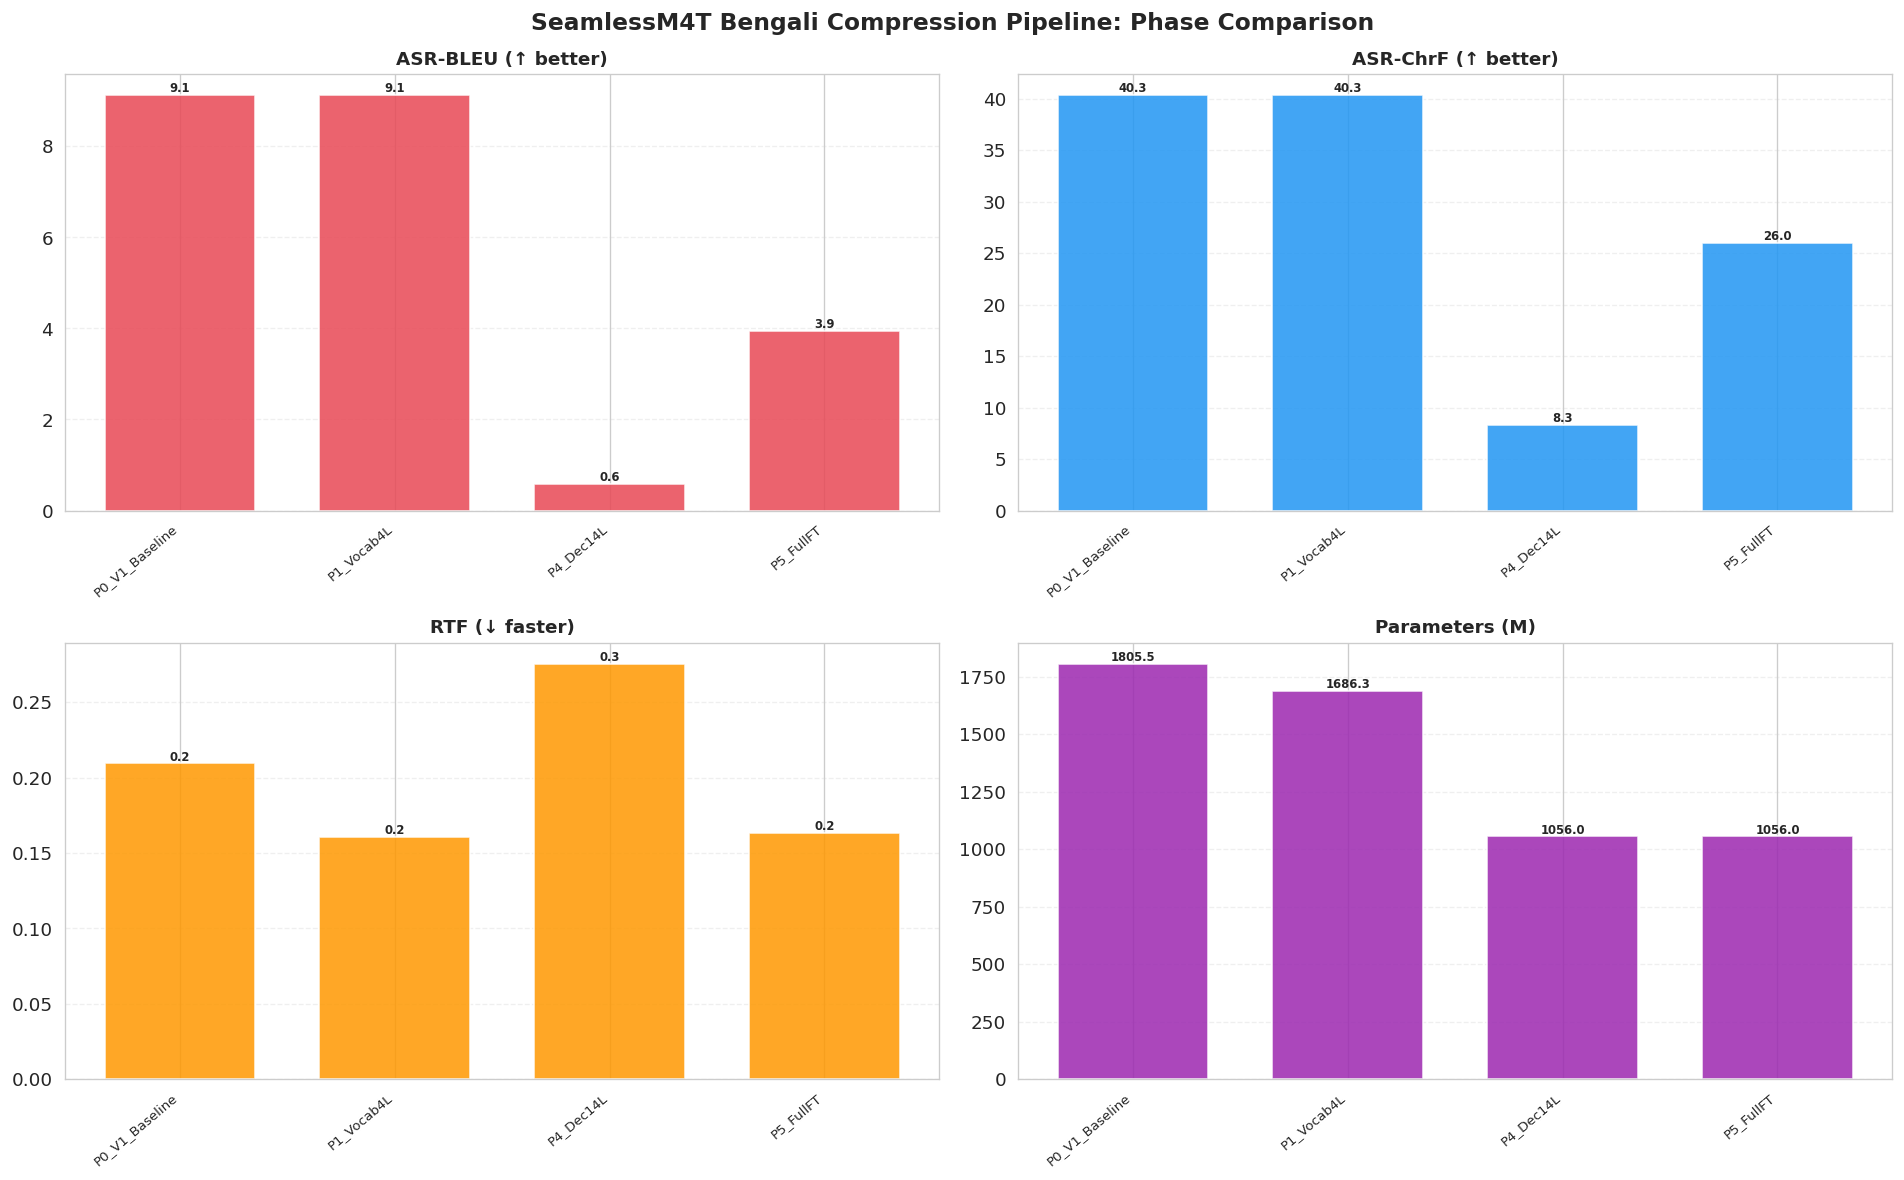

Plotting detailed comparison for 4 phases: ['P0_V1_Baseline', 'P1_Vocab4L', 'P4_Dec14L', 'P5_FullFT']


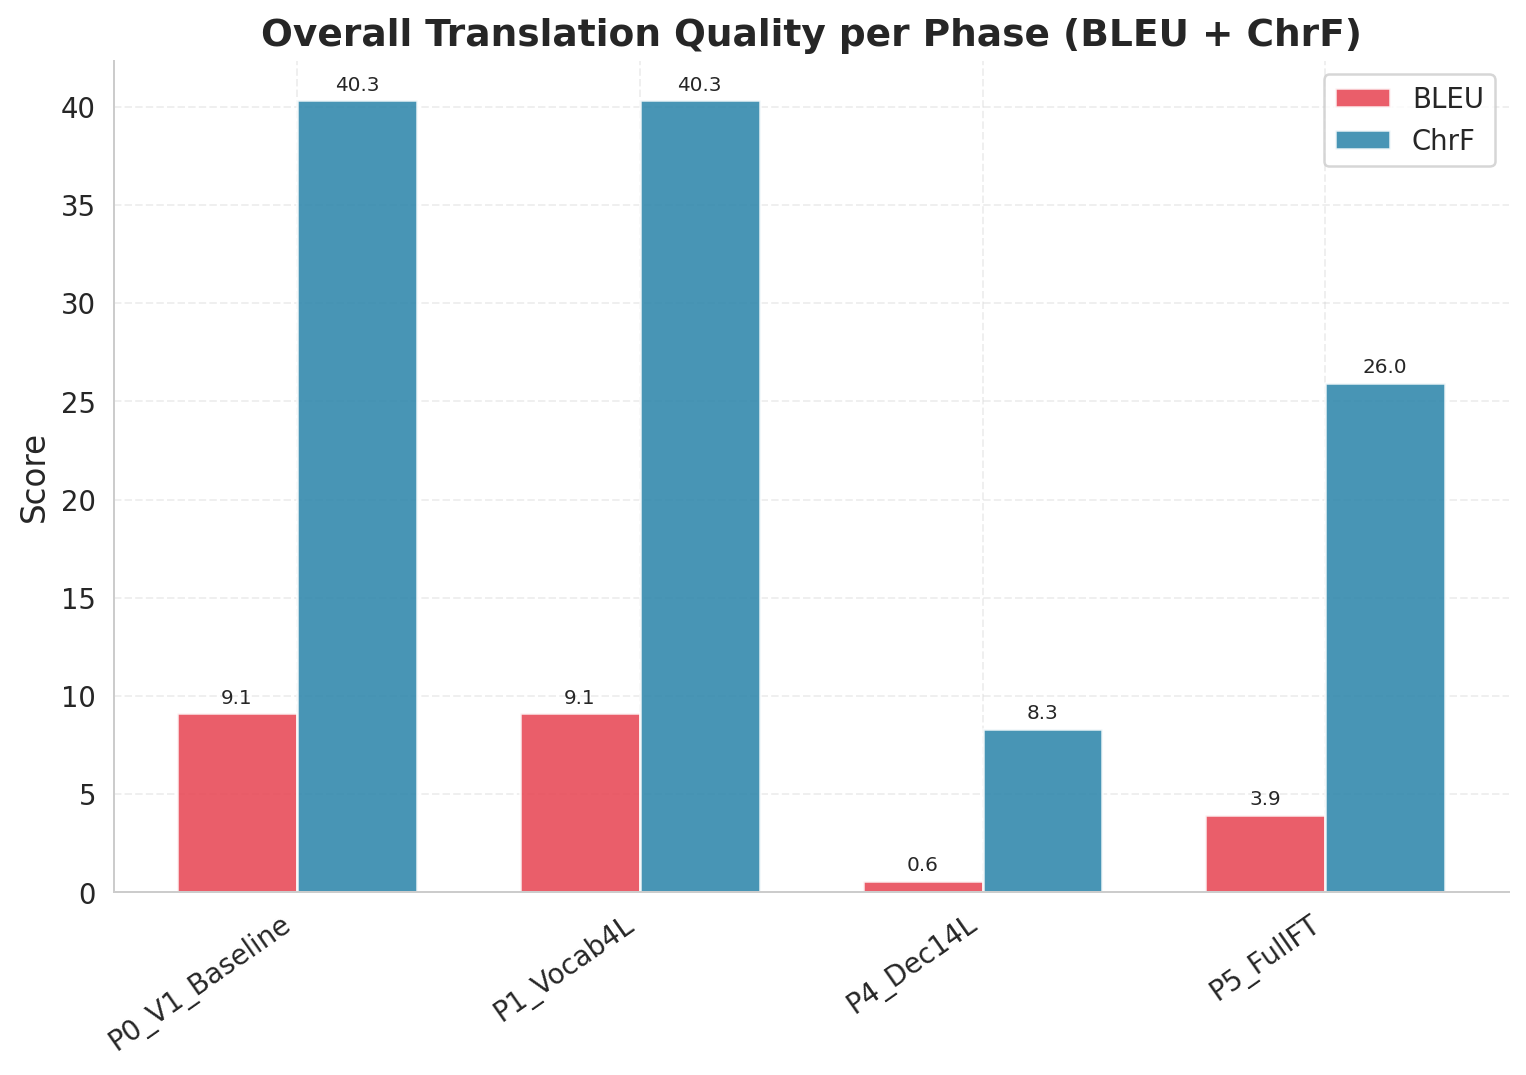

  ✓ Saved: detailed_comparison_01_overall_quality.png  [Overall Quality]


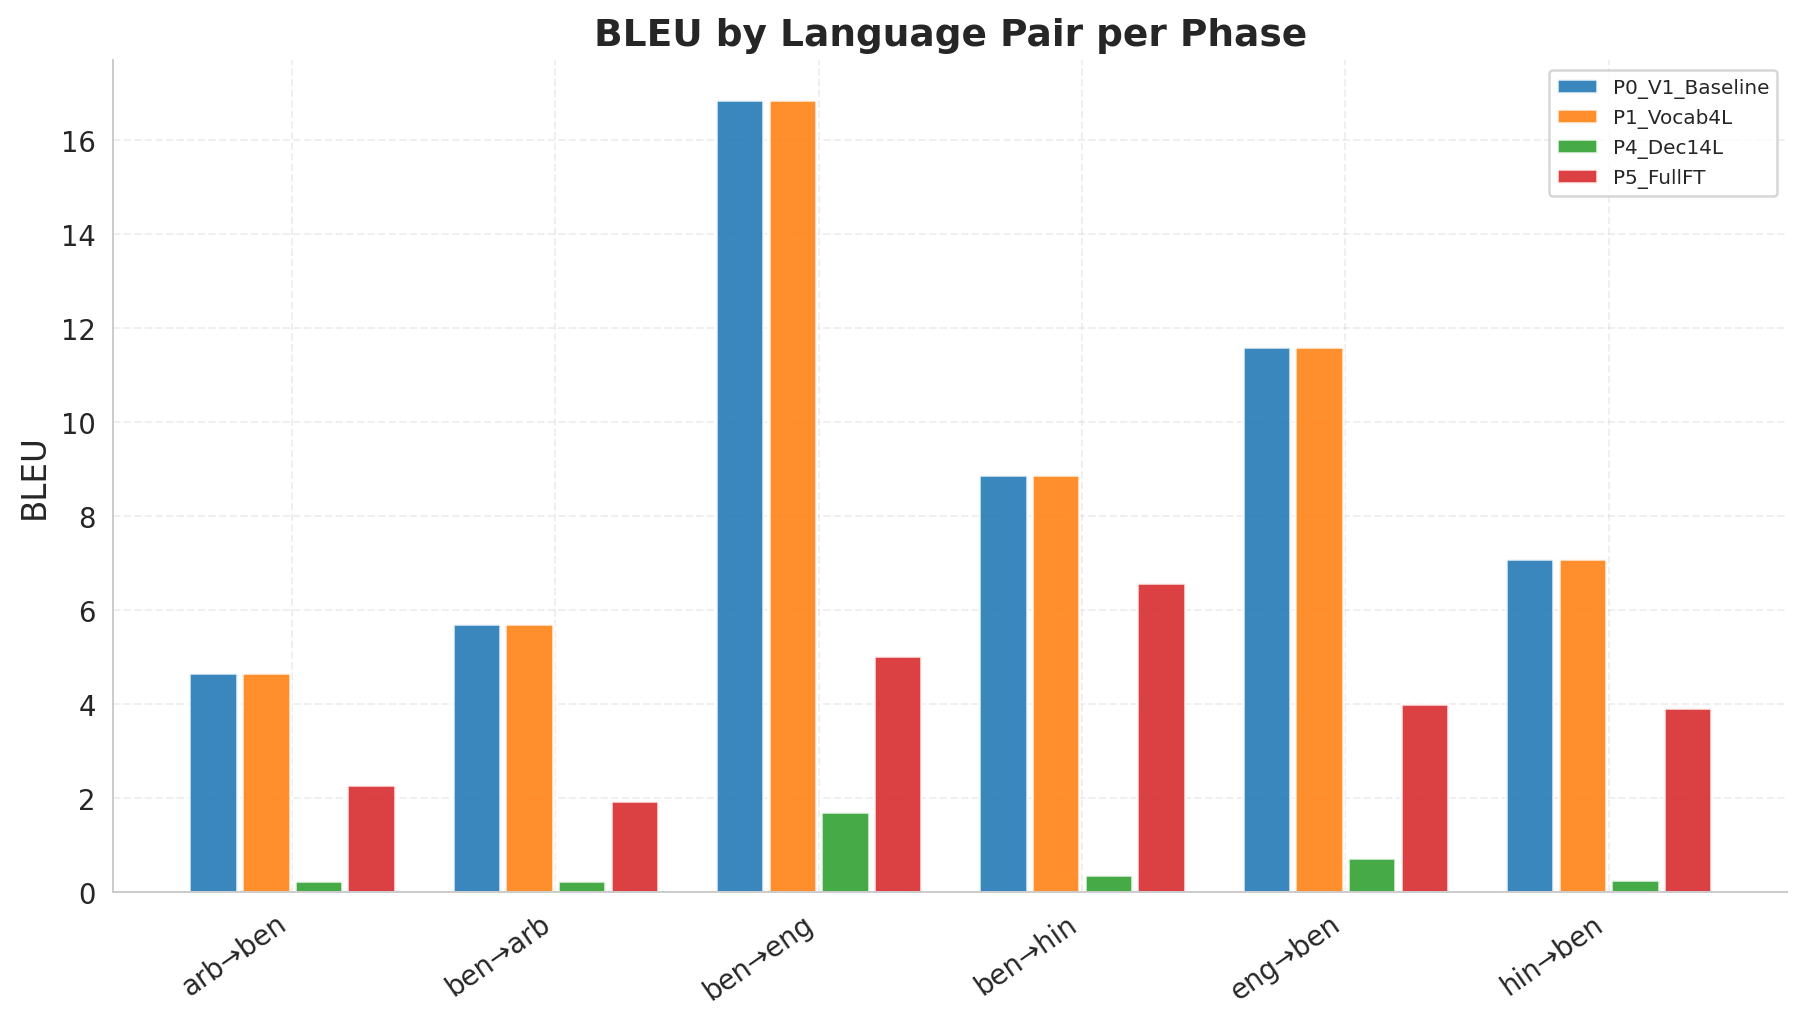

  ✓ Saved: detailed_comparison_02_bleu_by_pair.png  [BLEU by Language Pair]


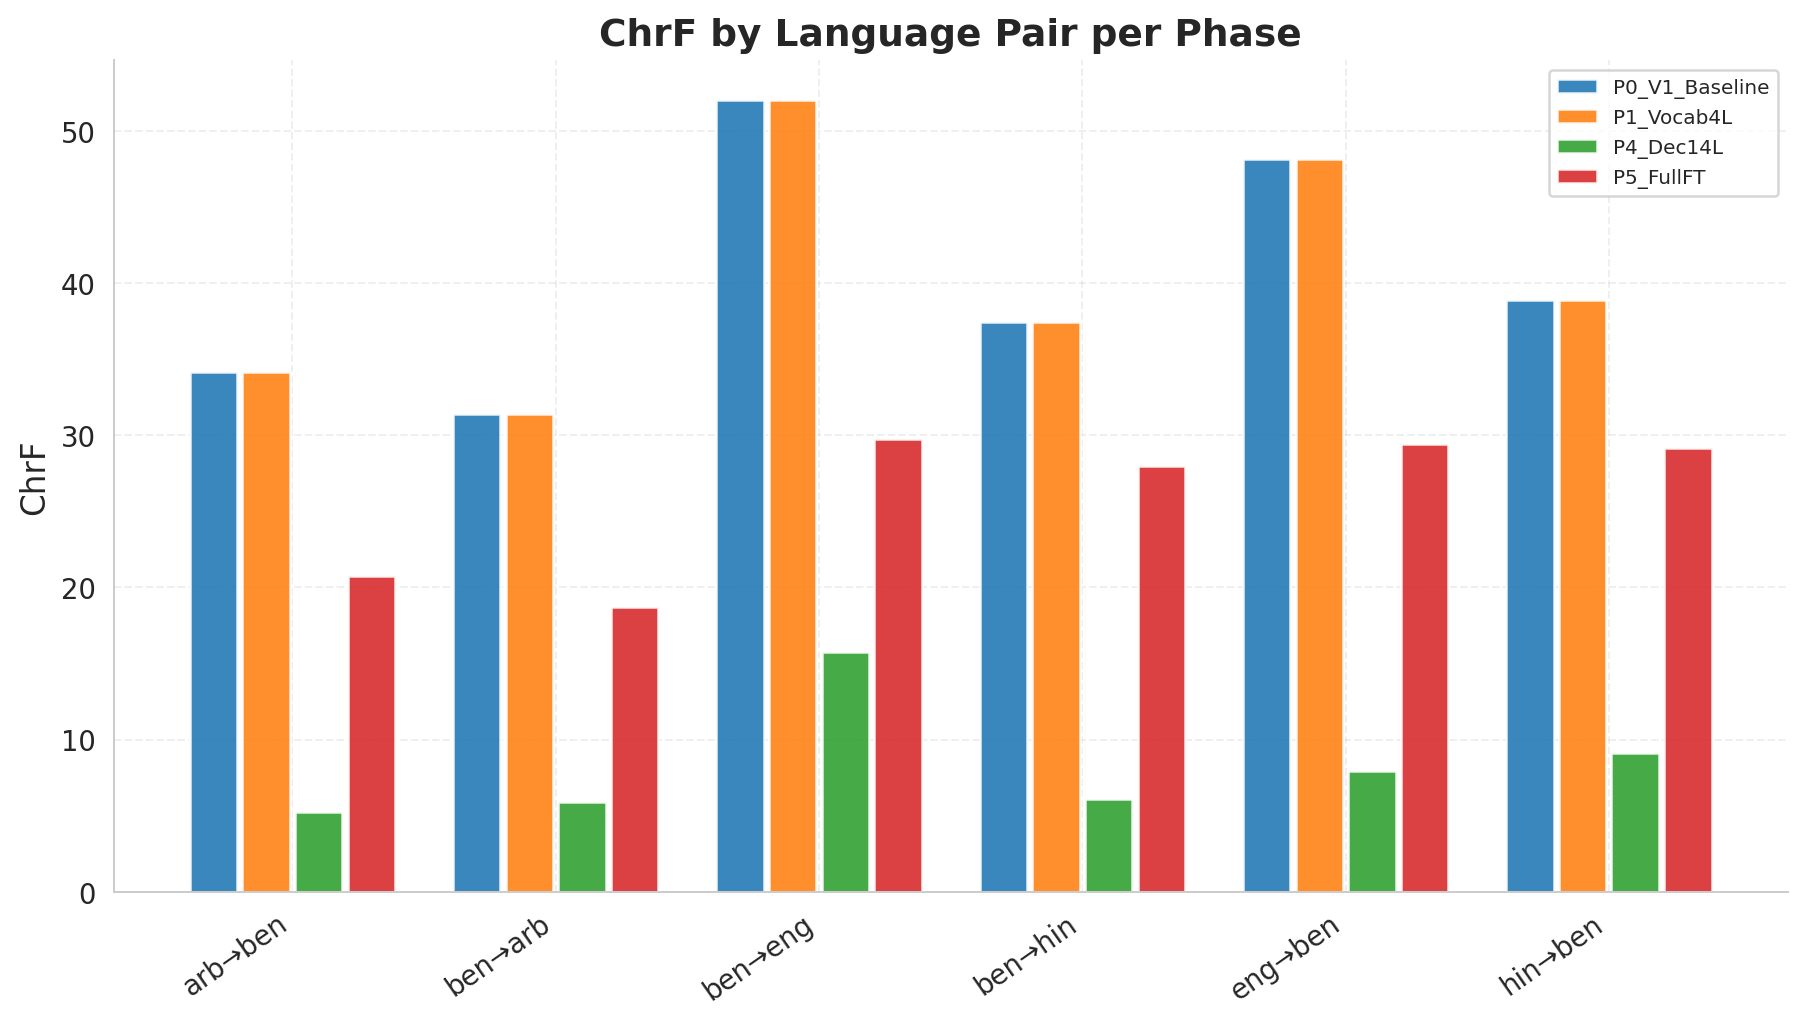

  ✓ Saved: detailed_comparison_03_chrf_by_pair.png  [ChrF by Language Pair]


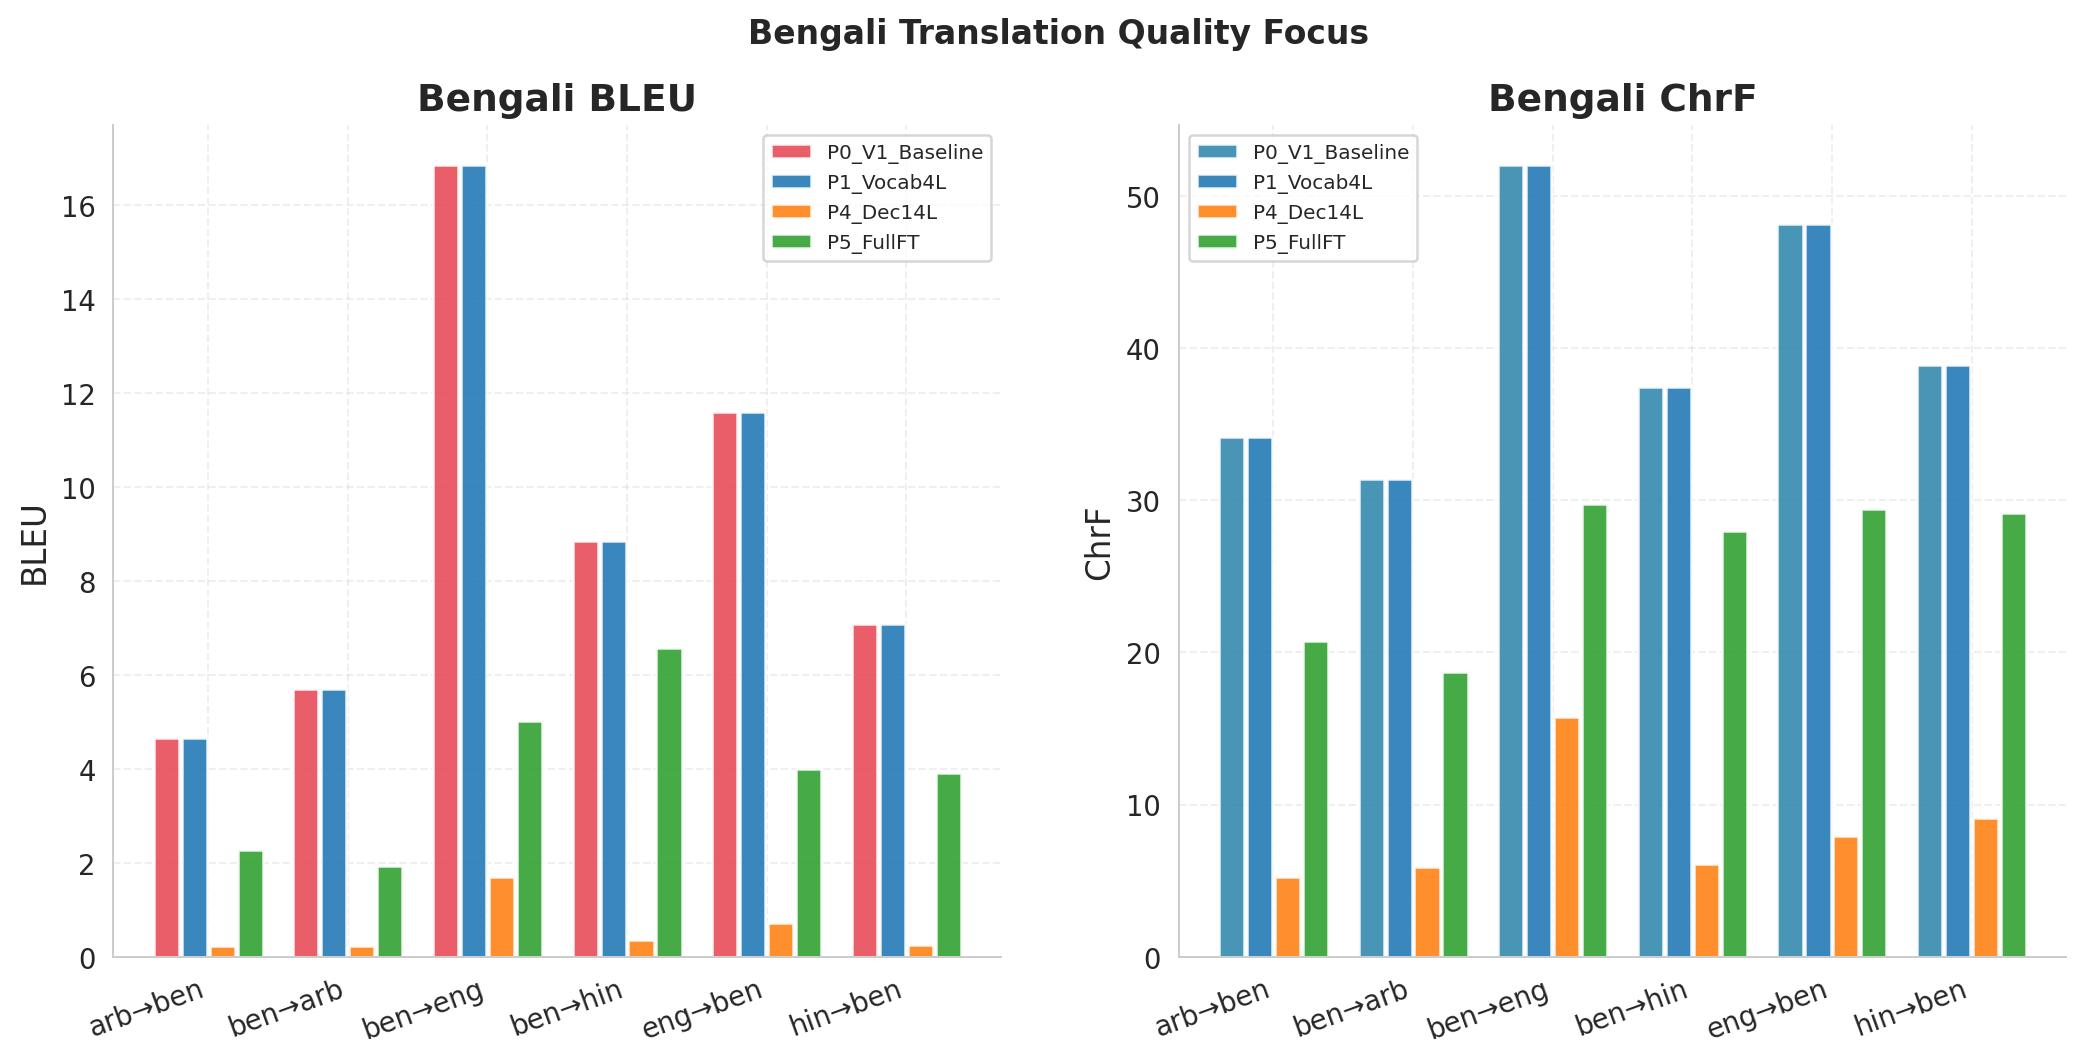

  ✓ Saved: detailed_comparison_04_bengali_focus.png  [Bengali Focus]


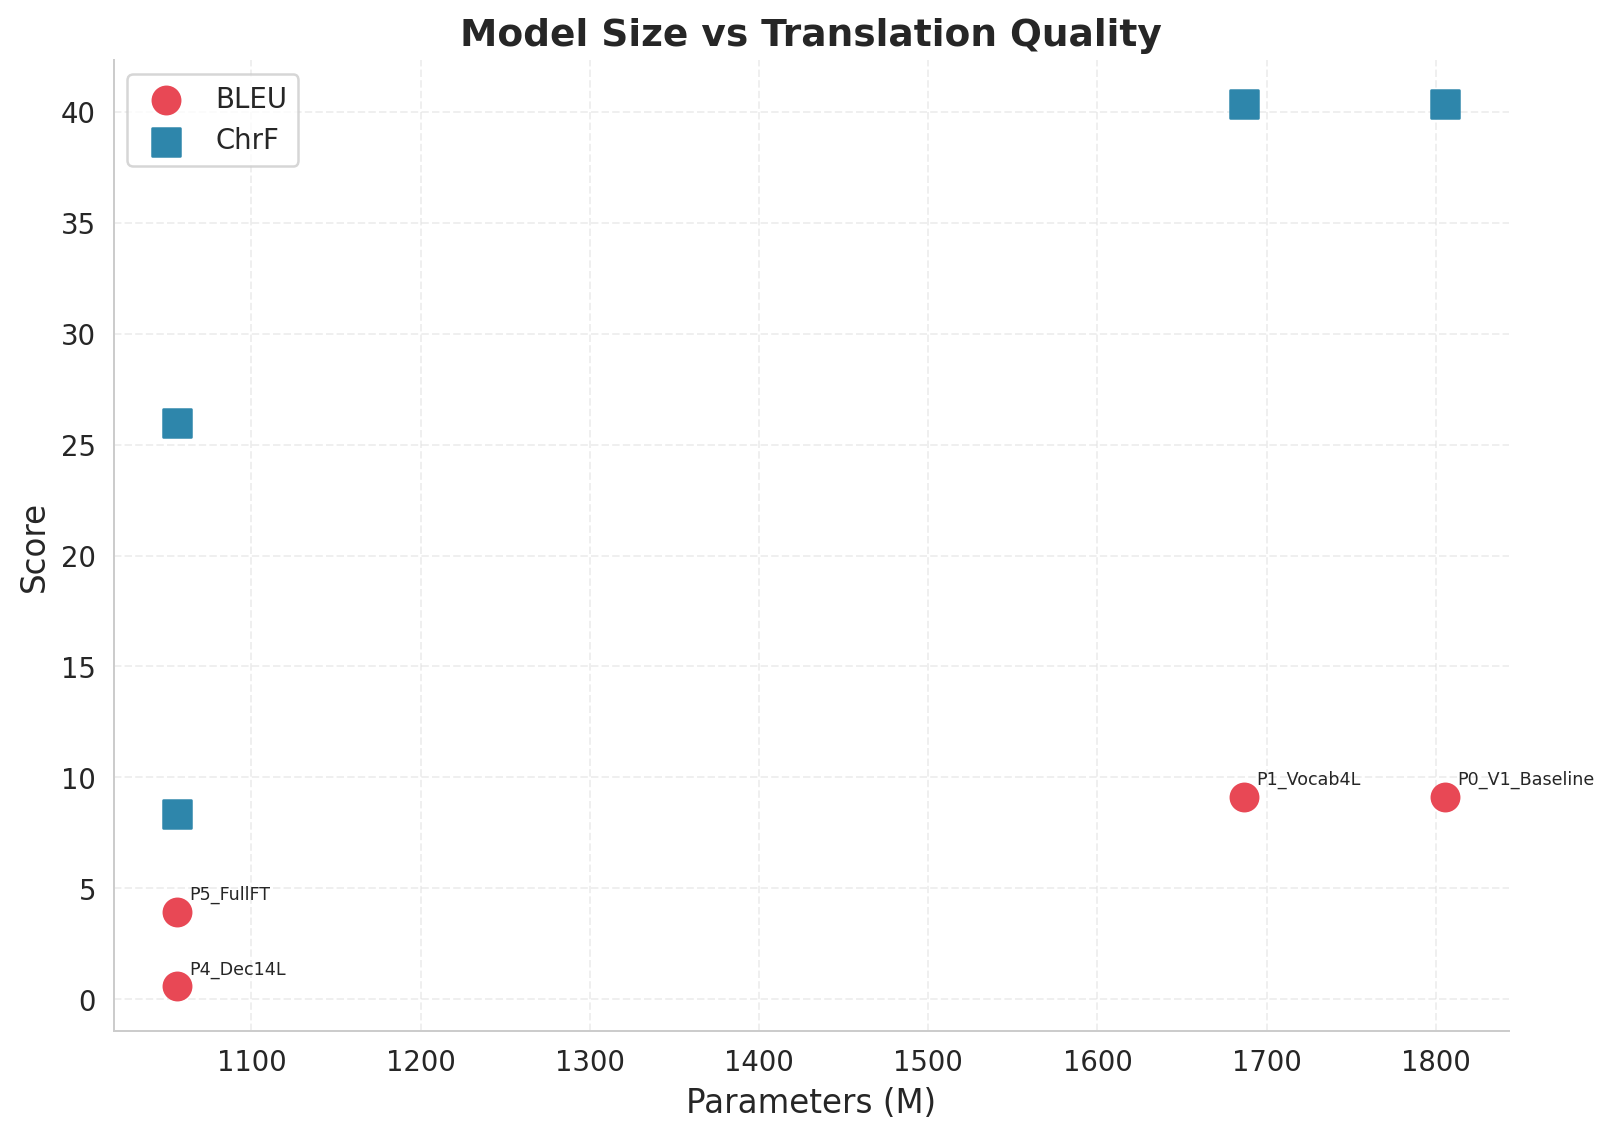

  ✓ Saved: detailed_comparison_05_size_vs_quality.png  [Size vs Quality]


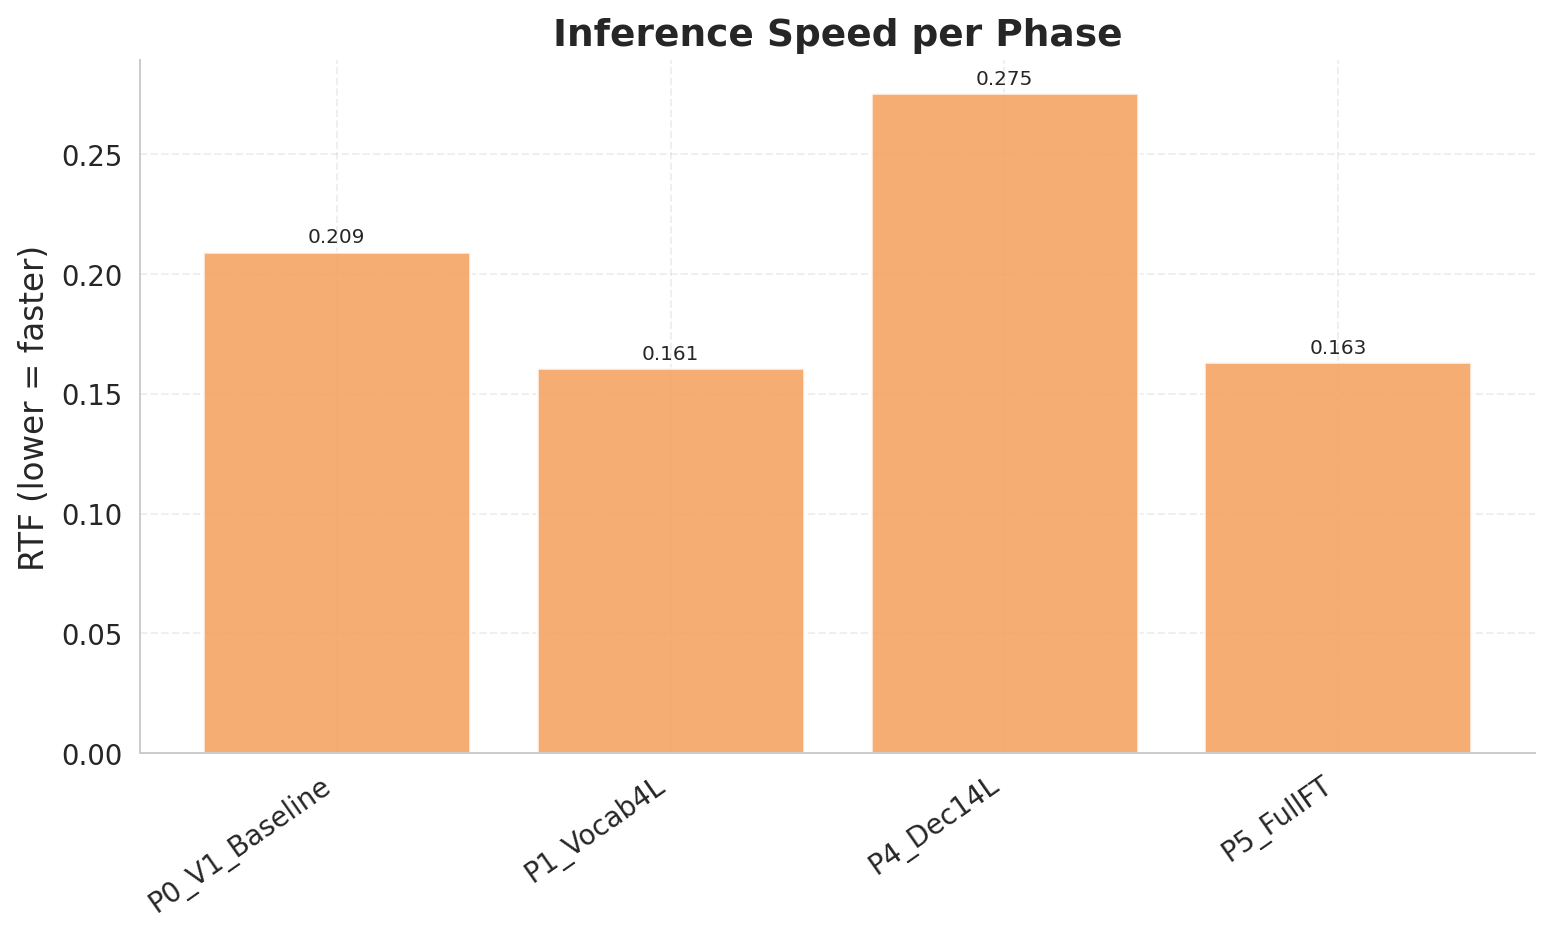

  ✓ Saved: detailed_comparison_06_rtf.png  [Inference Speed RTF]

✅ All 6 figures saved.
   📄 detailed_comparison_01_overall_quality.png
   📄 detailed_comparison_02_bleu_by_pair.png
   📄 detailed_comparison_03_chrf_by_pair.png
   📄 detailed_comparison_04_bengali_focus.png
   📄 detailed_comparison_05_size_vs_quality.png
   📄 detailed_comparison_06_rtf.png


In [57]:
# ── Final benchmark ───────────────────────────────────────────────────────────

p5_bench = load_latest_checkpoint('phase5_benchmark')
if p5_bench and p5_bench.get('summary', {}).get('avg_bleu', 0) > 0:
    results  = p5_bench['results']
    summary  = p5_bench['summary']
    detailed = p5_bench.get('detailed_summary')
    print('Loaded Phase 5 benchmark from checkpoint.')
    if not detailed:
        detailed = compute_detailed_summary(results, 'P5_FullFT', summary['params_M'])
else:
    results, summary = run_benchmark(student, list(eval_samples), 'P5_FullFT', save_n=4)
    detailed = compute_detailed_summary(results, 'P5_FullFT', summary['params_M'])
    save_checkpoint(dict(results=results, summary=summary, detailed_summary=detailed),
                    'phase5_benchmark', 0)

store_summary(summary)
store_detailed_summary(detailed)
print_detailed_summary_table('P5_FullFT')

# Compare against teacher
p0_detail = ALL_DETAILED_SUMMARIES.get('P0_V1_Baseline')
p5_detail = ALL_DETAILED_SUMMARIES.get('P5_FullFT')
if p0_detail and p5_detail:
    print('\n' + '='*50)
    print('  TEACHER vs STUDENT (Bengali pairs):')
    print('='*50)
    for pk in sorted(p5_detail['pair_stats']):
        if 'ben' not in pk: continue
        t_b = p0_detail['pair_stats'].get(pk, {}).get('avg_bleu', 0)
        t_c = p0_detail['pair_stats'].get(pk, {}).get('avg_chrf', 0)
        s_b = p5_detail['pair_stats'][pk]['avg_bleu']
        s_c = p5_detail['pair_stats'][pk]['avg_chrf']
        delta_b = s_b - t_b; delta_c = s_c - t_c
        star_b = '★' if delta_b > 0 else ' '
        star_c = '★' if delta_c > 0 else ' '
        print(f'  {pk:<18}  BLEU: Teacher={t_b:.2f}  Student={s_b:.2f}  Δ={delta_b:+.2f}{star_b}'
              f'  |  ChrF: Teacher={t_c:.2f}  Student={s_c:.2f}  Δ={delta_c:+.2f}{star_c}')
    print('='*50)

plot_phase_comparison()
plot_detailed_phase_comparison()


In [58]:
# ═══════════════════════════════════════════════════════════════════════════════
# ── Cell 70A: Config & IDs (paste your confirmed IDs here) ───────────────────
# ═══════════════════════════════════════════════════════════════════════════════

MDC_DATASET_IDS = {
    'bn': 'cmn3ipo8b00ejmi079e8upl2k',   # CV Scripted Speech 25.0 - Bengali
    'hi': 'cmn2cxzy701iumm077t5ayw0e',   # CV Scripted Speech 25.0 - Hindi
    'ar': 'cmn2g7uu701fqo1072r5na25l',   # CV Scripted Speech 25.0 - Arabic
    'en': 'cmndapwry02jnmh07dyo46mot',   # CV Scripted Speech 25.0 - English
}

CV_TO_M4T = {
    'bn': 'ben',
    'hi': 'hin',
    'ar': 'arb',
    'en': 'eng',
}

MDC_API_KEY  = _get_secret('MDC_API_KEY')
MDC_BASE_URL = 'https://mozilladatacollective.com/api'

# Where pseudo-label parquets accumulate before Kaggle push
PSEUDO_DIR = f'{WORK_DIR}/pseudo_cv25'
os.makedirs(PSEUDO_DIR, exist_ok=True)

# How many validated clips to pseudo-label per language
# Bengali is priority — do it first and give it the most clips
LANG_CLIP_BUDGET = {
    'bn': 30000,   # ~4-5 GB of audio streamed, ~600MB of Parquet output
    'hi': 15000,
    'ar': 15000,
    'en': 15000,
}

# How many clips to process before saving a Parquet chunk and (optionally) pushing
CHUNK_SAVE_EVERY = 2000    # save Parquet every N pseudo-labels
STREAM_WINDOW_MB = 384     # how many MB of tar.gz to pull per Range request

print(f'[Config] PSEUDO_DIR={PSEUDO_DIR}')
print(f'[Config] MDC API key loaded: {"YES" if MDC_API_KEY else "NO — check your Kaggle secret!"}')

[Config] PSEUDO_DIR=/kaggle/working/pseudo_cv25
[Config] MDC API key loaded: YES


In [59]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # ── Cell 70B: MDC Presigned URL Fetcher (unchanged from before — keep as-is)
# # ═══════════════════════════════════════════════════════════════════════════════
# import requests, json, time as _time

# _mdc_url_cache = {}

# def mdc_get_presigned_url(dataset_id: str, force_refresh: bool = False) -> dict:
#     """
#     POST to MDC /datasets/:datasetId/download to get a presigned S3 URL.
#     Caches result for up to 11h (URLs expire in 12h per MDC API docs).
#     Counts against the 30 downloads/day rate limit per the MDC API docs.
#     """
#     cached = _mdc_url_cache.get(dataset_id)
#     if cached and not force_refresh:
#         if _time.time() < cached.get('_expires_ts', 0) - 1800:
#             return cached

#     headers = {
#         'Authorization': f'Bearer {MDC_API_KEY}',
#         'Content-Type':  'application/json',
#     }
#     resp = requests.post(
#         f'{MDC_BASE_URL}/datasets/{dataset_id}/download',
#         headers=headers, timeout=30,
#     )
#     if resp.status_code == 403:
#         raise RuntimeError(
#             f"\n[MDC] 403 for {dataset_id}.\n"
#             f"Accept terms at: https://datacollective.mozillafoundation.org/datasets/{dataset_id}"
#         )
#     if resp.status_code == 429:
#         raise RuntimeError("[MDC] Rate limit: 30 presigned URLs/day. Wait until midnight UTC.")
#     resp.raise_for_status()

#     info = resp.json()
#     # MDC API docs: expiresAt in ISO 8601, presigned URLs valid 12 hours
#     from datetime import datetime, timezone
#     try:
#         dt = datetime.fromisoformat(info['expiresAt'].replace('Z', '+00:00'))
#         info['_expires_ts'] = dt.timestamp()
#     except Exception:
#         info['_expires_ts'] = _time.time() + 11 * 3600
#     _mdc_url_cache[dataset_id] = info

#     size_gb = int(info.get('sizeBytes', 0)) / 1e9
#     print(f"[MDC] Presigned URL for {dataset_id[:20]}... | {size_gb:.2f} GB | expires {info.get('expiresAt','?')}")
#     return info


# print('MDC URL fetcher ready.')

In [60]:
# ═══════════════════════════════════════════════════════════════════════════════
# ── Cell 70C: FAST + RELIABLE CV25 Downloader + Pseudo-Labeler
#
# STRATEGY: Download the tar.gz in one shot using wget (far more reliable than
# requests for 26 GB files — handles retries, stalls, and reconnects natively).
# Since Bengali is 26 GB and we have 19.5 GB free, we download in two Range
# passes of ~13 GB each, extract what we need, then delete before next pass.
#
# Each "chunk download" cycle:
#   1. wget Range request → partial .tar.gz saved to disk (up to 10 GB)
#   2. tarfile streaming read of that partial file → extract MP3s + TSV
#   3. Teacher inference on extracted MP3s → Parquet
#   4. Delete partial tar.gz → free space → next Range pass
#
# This gives us:
#   - wget reliability (auto-retry, resume, no Python timeout issues)
#   - Fast I/O (disk read >> network stream for tarfile parsing)
#   - 10 GB disk budget respected
# ═══════════════════════════════════════════════════════════════════════════════

# import tarfile, io, csv, os, subprocess, pathlib, time as _time
# import numpy as np
# import soundfile as sf
# import requests, json
# import torch, torchaudio
# import pyarrow as pa
# import pyarrow.parquet as pq

# # ── Tunables ──────────────────────────────────────────────────────────────────
# DOWNLOAD_CHUNK_GB  = 9          # GB per Range download (stays under 10 GB budget)
# CHUNK_SAVE_EVERY   = 1500       # save Parquet after this many pseudo-labels
# PUSH_EVERY_CHUNKS  = 3          # push to Kaggle after this many saved Parquet chunks
# RAW_DIR            = f'{WORK_DIR}/cv25_raw'
# os.makedirs(RAW_DIR,    exist_ok=True)
# os.makedirs(PSEUDO_DIR, exist_ok=True)

# # ── Parquet schema (MUST match FLEURS exactly) ────────────────────────────────
# # _load_wav expects: audio_cell = {'bytes': <wav_bytes>, 'path': <str>}
# # ChunkedStreamingDataset reads: pq.read_table(f, columns=['audio'])
# _AUDIO_STRUCT_TYPE = pa.struct([
#     pa.field('bytes', pa.large_binary()),
#     pa.field('path',  pa.string()),
# ])
# _PARQUET_SCHEMA = pa.schema([
#     pa.field('id',            pa.string()),
#     pa.field('transcription', pa.string()),
#     pa.field('audio',         _AUDIO_STRUCT_TYPE),
# ])


# # ═══════════════════════════════════════════════════════════════════════════════
# # Helpers
# # ═══════════════════════════════════════════════════════════════════════════════

# def _is_validated_tsv(member_name: str) -> bool:
#     """Exact match — never catches invalidated.tsv or other.tsv."""
#     return member_name.split('/')[-1] == 'validated.tsv'


# def _audio_to_wav_bytes(audio: np.ndarray, sr: int = 16000) -> bytes:
#     """float32 numpy → WAV bytes (what soundfile.read / _load_wav expects)."""
#     buf = io.BytesIO()
#     sf.write(buf, audio.astype(np.float32), sr, format='WAV', subtype='PCM_16')
#     return buf.getvalue()


# def _save_pseudo_parquet(records: list, lang_cv: str, tgt_m4t: str, chunk_idx: int) -> str:
#     """Save records as Parquet with the same schema as FLEURS parquets."""
#     path = f'{PSEUDO_DIR}/pseudo_{lang_cv}2{tgt_m4t}_chunk{chunk_idx:04d}.parquet'
#     ids   = pa.array([r['id']            for r in records], type=pa.string())
#     trans = pa.array([r['transcription'] for r in records], type=pa.string())
#     audio_col = pa.StructArray.from_arrays(
#         [
#             pa.array([r['wav_bytes']        for r in records], type=pa.large_binary()),
#             pa.array([r['id'] + '.wav'      for r in records], type=pa.string()),
#         ],
#         fields=[pa.field('bytes', pa.large_binary()), pa.field('path', pa.string())],
#     )
#     table = pa.Table.from_arrays([ids, trans, audio_col], schema=_PARQUET_SCHEMA)
#     pq.write_table(table, path, compression='snappy')
#     mb = os.path.getsize(path) / 1e6
#     print(f"  [Parquet] chunk{chunk_idx:04d} → {len(records)} samples, {mb:.1f} MB")
#     return path


# def _push_kaggle_and_cleanup(message: str, lang_cv: str) -> bool:
#     """Push new Kaggle dataset version, then delete local Parquet files for this lang."""
#     if not ON_KAGGLE:
#         print('[Kaggle] Not on Kaggle — skip push.')
#         return False
#     try:
#         kag_json = _get_secret('KAGGLE_API_TOKEN')
#         kag_path = pathlib.Path.home() / '.kaggle/kaggle.json'
#         kag_path.parent.mkdir(parents=True, exist_ok=True)
#         kag_path.write_text(kag_json); kag_path.chmod(0o600)
#         username = json.loads(kag_json).get('username', 'rayedriasat')
#     except Exception as e:
#         print(f'[Kaggle] API key error: {e}'); return False

#     with open(f'{PSEUDO_DIR}/dataset-metadata.json', 'w') as f:
#         json.dump({'title': 'fleurs5', 'id': f'{username}/fleurs5',
#                    'licenses': [{'name': 'CC0-1.0'}]}, f)

#     r = subprocess.run(
#         ['kaggle', 'datasets', 'version', '-p', PSEUDO_DIR,
#          '-m', message, '--dir-mode', 'tar'],
#         capture_output=True, text=True, timeout=600)

#     if r.returncode == 0:
#         print(f'[Kaggle] ✓ Pushed: {message}')
#         freed = 0
#         for f in pathlib.Path(PSEUDO_DIR).glob(f'pseudo_{lang_cv}2*.parquet'):
#             freed += f.stat().st_size / 1e6; f.unlink()
#         print(f'[Kaggle] Freed {freed:.0f} MB local Parquet.')
#         return True
#     else:
#         print(f'[Kaggle] ❌ Push failed:\n{r.stderr[:400]}')
#         return False


# # ═══════════════════════════════════════════════════════════════════════════════
# # Core: Download a Range of the tar.gz with wget, then parse it
# # ═══════════════════════════════════════════════════════════════════════════════

# def _wget_range(url: str, dest: str, start: int, end: int, retries: int = 5) -> bool:
#     """
#     Download bytes[start:end] into dest using wget.
#     Completely silent wget (no progress bar) — we print our own
#     concise progress line every 10 seconds via a background thread.
#     Prevents the thousands of dot-lines that hang Jupyter notebooks.
#     """
#     expected = end - start + 1

#     for attempt in range(retries):
#         if os.path.exists(dest):
#             os.remove(dest)

#         cmd = [
#             'wget',
#             '--quiet',              # NO progress bar — this was the flood source
#             '--no-verbose',         # suppress all non-error output
#             f'--header=Range: bytes={start}-{end}',
#             '--tries=1',
#             '--timeout=300',
#             '--read-timeout=120',
#             '-O', dest, url,
#         ]

#         # ── Background progress printer ───────────────────────────────────────
#         # Reads the file size on disk every 10s and prints one clean line.
#         # Total output for a 9 GB download: ~90 lines. Notebook stays responsive.
#         _stop_progress = [False]
#         def _progress_printer():
#             t_start = _time.time()
#             while not _stop_progress[0]:
#                 _time.sleep(10)
#                 if _stop_progress[0]:
#                     break
#                 try:
#                     current = os.path.getsize(dest) if os.path.exists(dest) else 0
#                     elapsed = (_time.time() - t_start) / 60
#                     speed   = current / max(_time.time() - t_start, 1) / 1e6  # MB/s
#                     pct     = current / expected * 100 if expected > 0 else 0
#                     print(f"  [wget] {current/1e9:.2f}/{expected/1e9:.2f} GB "
#                           f"({pct:.0f}%) | {speed:.0f} MB/s | {elapsed:.1f} min",
#                           flush=True)
#                 except Exception:
#                     pass

#         import threading
#         t = threading.Thread(target=_progress_printer, daemon=True)
#         t.start()

#         proc = subprocess.run(cmd)   # blocks until wget finishes or fails

#         _stop_progress[0] = True     # signal printer to stop
#         t.join(timeout=1)

#         if proc.returncode == 0 and os.path.exists(dest):
#             actual = os.path.getsize(dest)
#             if actual >= expected * 0.99:
#                 print(f"  [wget] ✓ Done: {actual/1e9:.2f} GB", flush=True)
#                 return True
#             print(f"  [wget] Size mismatch: got {actual/1e9:.2f} GB, "
#                   f"expected {expected/1e9:.2f} GB. Retry {attempt+1}...")
#         else:
#             print(f"  [wget] Failed rc={proc.returncode}. Retry {attempt+1}...")

#         _time.sleep(10 * (attempt + 1))

#     return False


# def _extract_tsv_from_partial(partial_path: str) -> dict:
#     """
#     Extract validated.tsv from a partial tar.gz downloaded from the START of the
#     archive. CV archives put TSVs before clips/, so the TSV is always in the
#     first ~200 MB. Returns {bare_mp3_filename: sentence}.
#     """
#     tsv_map = {}
#     try:
#         with tarfile.open(partial_path, mode='r:gz') as tf:
#             for member in tf:
#                 if member.isfile() and _is_validated_tsv(member.name):
#                     print(f"  [TSV] Found {member.name} ({member.size/1024:.0f} KB)")
#                     f = tf.extractfile(member)
#                     if f:
#                         content = f.read().decode('utf-8', errors='replace')
#                         reader  = csv.DictReader(io.StringIO(content), delimiter='\t')
#                         for row in reader:
#                             p = row.get('path', '').strip()
#                             s = row.get('sentence', '').strip()
#                             if p and s:
#                                 tsv_map[p.split('/')[-1]] = s
#                     print(f"  [TSV] {len(tsv_map)} validated entries.")
#                     return tsv_map
#                 elif member.isfile() and member.name.endswith('.mp3'):
#                     # Reached audio before finding TSV — archive is non-standard
#                     print(f"  [TSV] WARNING: hit MP3s before validated.tsv. Only got {len(tsv_map)} entries.")
#                     return tsv_map
#     except tarfile.ReadError as e:
#         # Expected: partial file ends mid-archive. TSV should already be extracted.
#         if tsv_map:
#             print(f"  [TSV] Partial read ended (expected). Got {len(tsv_map)} entries.")
#             return tsv_map
#         print(f"  [TSV] ERROR: {e}")
#     return tsv_map


# def _extract_mp3s_from_partial(partial_path: str, tsv_map: dict,
#                                 skip_n: int, max_n: int):
#     """
#     Generator. Reads a partial tar.gz (covering a Range of the archive),
#     yields (audio_np, 16000, transcription) for validated MP3s.

#     partial_path : path to the downloaded partial .tar.gz
#     tsv_map      : {mp3_filename: transcription} from validated.tsv
#     skip_n       : how many validated clips to skip (resume support)
#     max_n        : stop after yielding this many clips
#     """
#     skipped = 0
#     yielded = 0

#     try:
#         with tarfile.open(partial_path, mode='r:gz') as tf:
#             for member in tf:
#                 if yielded >= max_n:
#                     break
#                 if not member.isfile() or not member.name.endswith('.mp3'):
#                     continue
#                 bare = member.name.split('/')[-1]
#                 if bare not in tsv_map:
#                     continue   # not validated

#                 if skipped < skip_n:
#                     skipped += 1
#                     continue

#                 try:
#                     mp3_bytes = tf.extractfile(member).read()
#                     audio, sr = sf.read(io.BytesIO(mp3_bytes), dtype='float32')
#                     if audio.ndim > 1:
#                         audio = audio.mean(axis=1)
#                     if sr != 16000:
#                         audio = torchaudio.functional.resample(
#                             torch.from_numpy(audio), sr, 16000).numpy()
#                         sr = 16000
#                     dur = len(audio) / sr
#                     if dur < 0.3 or dur > 20.0:
#                         continue
#                     yield audio.astype(np.float32), 16000, tsv_map[bare]
#                     yielded += 1
#                 except Exception:
#                     continue

#     except tarfile.ReadError:
#         # Normal: partial file ends mid-block. We've already yielded what we can.
#         pass

#     print(f"  [Extract] Yielded {yielded} clips from this Range chunk "
#           f"(skipped {skipped} already-done).")


# ═══════════════════════════════════════════════════════════════════════════════
# Main runner
# ═══════════════════════════════════════════════════════════════════════════════

# def run_streaming_pseudo_labeler(lang_cv: str, max_clips: int = 20000):
#     """
#     Full pipeline:
#       Phase A — Download first ~200 MB → extract validated.tsv
#       Phase B — Download archive in DOWNLOAD_CHUNK_GB slices → extract MP3s
#                 → teacher inference → Parquet → Kaggle push → delete → next slice
#     """
#     tgt_m4t    = CV_TO_M4T[lang_cv]
#     dataset_id = MDC_DATASET_IDS[lang_cv]

#     # ── Resume state ──────────────────────────────────────────────────────────
#     state_file = pathlib.Path(PSEUDO_DIR) / f'.state_{lang_cv}.json'
#     state = json.loads(state_file.read_text()) if state_file.exists() else {}
#     already_done   = state.get('clips_done', 0)
#     next_chunk_idx = state.get('next_chunk_idx', 0)
#     # byte_offset: where in the archive to start the next Range download
#     # (so we don't re-download already-processed slices)
#     byte_offset    = state.get('byte_offset', 0)

#     print(f'\n{"="*70}')
#     print(f'[Phase6] {lang_cv} → {tgt_m4t} | target={max_clips} | done={already_done} | '
#           f'byte_offset={byte_offset/1e9:.2f} GB')
#     print(f'{"="*70}')

#     if already_done >= max_clips:
#         print(f'[Phase6] Already complete.'); return

#     teacher.eval()
#     t_device = next(teacher.text_decoder.parameters()).device

#     # ── Get presigned URL (1 API call, valid 12h per MDC API docs) ────────────
#     url_info   = mdc_get_presigned_url(dataset_id)
#     url        = url_info['downloadUrl']
#     total_bytes = int(url_info.get('sizeBytes', 0))
#     expires_ts  = url_info.get('_expires_ts', _time.time() + 11 * 3600)
#     print(f'[Phase6] Archive: {total_bytes/1e9:.2f} GB | expires in '
#           f'{(expires_ts - _time.time())/3600:.1f}h')

#     def _fresh_url():
#         nonlocal url, expires_ts
#         if _time.time() > expires_ts - 1800:
#             info = mdc_get_presigned_url(dataset_id, force_refresh=True)
#             url  = info['downloadUrl']
#             expires_ts = info.get('_expires_ts', _time.time() + 11 * 3600)
#         return url

#     # ── Phase A: Get validated.tsv from the first 300 MB ─────────────────────
#     # (Only needed if we don't have it cached from a previous run)
#     tsv_cache = pathlib.Path(PSEUDO_DIR) / f'.tsv_{lang_cv}.json'
#     if tsv_cache.exists():
#         tsv_map = json.loads(tsv_cache.read_text())
#         print(f'[Phase6] Loaded cached TSV: {len(tsv_map)} entries.')
#     else:
#         tsv_path = f'{RAW_DIR}/{lang_cv}_tsv_head.tar.gz'
#         tsv_end  = min(300 * 1024 * 1024, total_bytes) - 1  # first 300 MB
#         print(f'[Phase6] Phase A: downloading first 300 MB for validated.tsv...')
#         ok = _wget_range(_fresh_url(), tsv_path, 0, tsv_end)
#         if not ok:
#             raise RuntimeError(f'[Phase6] wget failed for TSV extraction on {lang_cv}')
#         tsv_map = _extract_tsv_from_partial(tsv_path)
#         os.remove(tsv_path)
#         if not tsv_map:
#             raise RuntimeError(f'[Phase6] validated.tsv not found in first 300 MB for {lang_cv}')
#         tsv_cache.write_text(json.dumps(tsv_map))
#         print(f'[Phase6] Phase A done. {len(tsv_map)} validated clips.')

#     # ── Phase B: Download in DOWNLOAD_CHUNK_GB slices, pseudo-label each ──────
#     chunk_bytes   = int(DOWNLOAD_CHUNK_GB * 1024 ** 3)
#     buffer        = []
#     total_saved   = already_done
#     chunks_pushed = 0
#     t0            = _time.time()

#     # Start from saved byte_offset (resume support)
#     current_offset = byte_offset

#     while current_offset < total_bytes and total_saved < max_clips:
#         slice_end   = min(current_offset + chunk_bytes - 1, total_bytes - 1)
#         slice_gb    = (slice_end - current_offset + 1) / 1e9
#         part_path   = f'{RAW_DIR}/{lang_cv}_part.tar.gz'

#         print(f'\n[Phase6] Downloading slice {current_offset/1e9:.2f}–{slice_end/1e9:.2f} GB '
#               f'({slice_gb:.2f} GB)...')
#         t_dl = _time.time()
#         ok = _wget_range(_fresh_url(), part_path, current_offset, slice_end)
#         if not ok:
#             print(f'[Phase6] wget failed for slice. Retrying with fresh URL...')
#             ok = _wget_range(_fresh_url(), part_path, current_offset, slice_end)
#         if not ok:
#             raise RuntimeError(f'[Phase6] Download failed after retries at offset {current_offset}')
#         dl_gb   = os.path.getsize(part_path) / 1e9
#         dl_time = (_time.time() - t_dl) / 60
#         print(f'[Phase6] Downloaded {dl_gb:.2f} GB in {dl_time:.1f} min. Extracting...')

#         # How many validated clips to skip in this slice (for resume)
#         # We skip clips from previous SLICES via already_done; within current
#         # slice we track via skip_in_slice
#         skip_in_slice = max(0, already_done - total_saved)

#         clips_this_slice = 0
#         for audio, sr, ref_text in _extract_mp3s_from_partial(
#                 part_path, tsv_map,
#                 skip_n=skip_in_slice,
#                 max_n=max_clips - total_saved):

#             # Teacher inference
#             try:
#                 inputs = processor(audio=audio, sampling_rate=sr, return_tensors='pt')
#                 inputs = {k: v.to(t_device) for k, v in inputs.items()}
#                 with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
#                     out = teacher.generate(**inputs, tgt_lang=tgt_m4t)
#                 text_ids    = _remap_ids_for_decode(teacher, out.sequences.cpu())
#                 pseudo_text = processor.batch_decode(text_ids, skip_special_tokens=True)[0].strip()
#                 if not pseudo_text:
#                     continue
#             except torch.cuda.OutOfMemoryError:
#                 torch.cuda.empty_cache(); continue
#             except Exception:
#                 continue

#             buffer.append({
#                 'id':            f'p6_{lang_cv}2{tgt_m4t}_{total_saved:06d}',
#                 'transcription': pseudo_text,
#                 'wav_bytes':     _audio_to_wav_bytes(audio, 16000),
#             })
#             total_saved      += 1
#             clips_this_slice += 1

#             if total_saved % 200 == 0:
#                 elapsed = (_time.time() - t0) / 60
#                 rate    = (total_saved - already_done) / max(elapsed, 0.01)
#                 eta     = (max_clips - total_saved) / max(rate, 0.01)
#                 disk_gb = sum(f.stat().st_size for f in pathlib.Path(RAW_DIR).glob('*.tar.gz')
#                               ) / 1e9 if pathlib.Path(RAW_DIR).exists() else 0
#                 print(f'  [{lang_cv}] {total_saved}/{max_clips} | '
#                       f'{rate:.1f} clips/min | ETA {eta:.0f} min | '
#                       f'raw disk {disk_gb:.1f} GB')

#             if len(buffer) >= CHUNK_SAVE_EVERY:
#                 _save_pseudo_parquet(buffer, lang_cv, tgt_m4t, next_chunk_idx)
#                 buffer          = []; next_chunk_idx += 1; chunks_pushed += 1
#                 state = {'clips_done': total_saved, 'next_chunk_idx': next_chunk_idx,
#                          'byte_offset': current_offset}
#                 state_file.write_text(json.dumps(state))
#                 if chunks_pushed % PUSH_EVERY_CHUNKS == 0:
#                     _push_kaggle_and_cleanup(
#                         f'Phase6 {lang_cv}2{tgt_m4t} step {total_saved}', lang_cv)

#         print(f'[Phase6] Slice done: {clips_this_slice} clips extracted.')

#         # Delete the raw slice immediately to free disk
#         if os.path.exists(part_path):
#             os.remove(part_path)
#             print(f'[Phase6] Deleted {lang_cv}_part.tar.gz')

#         # Advance to next slice
#         current_offset = slice_end + 1
#         state = {'clips_done': total_saved, 'next_chunk_idx': next_chunk_idx,
#                  'byte_offset': current_offset}
#         state_file.write_text(json.dumps(state))

#         if total_saved >= max_clips:
#             print(f'[Phase6] Reached target {max_clips} clips.'); break

#     # Save any leftover buffer
#     if buffer:
#         _save_pseudo_parquet(buffer, lang_cv, tgt_m4t, next_chunk_idx)
#         next_chunk_idx += 1
#         state = {'clips_done': total_saved, 'next_chunk_idx': next_chunk_idx,
#                  'byte_offset': current_offset}
#         state_file.write_text(json.dumps(state))

#     _push_kaggle_and_cleanup(
#         f'Phase6 {lang_cv}2{tgt_m4t} FINAL {total_saved} clips', lang_cv)

#     elapsed = (_time.time() - t0) / 60
#     print(f'\n✓ [{lang_cv}] Complete: {total_saved} pseudo-labels in {elapsed:.1f} min.')


# print('Fast + reliable pseudo-labeler ready.')
# print(f'Download chunk size: {DOWNLOAD_CHUNK_GB} GB per slice')

In [61]:
# ═══════════════════════════════════════════════════════════════════════════════
# ── Cell 71 (FIXED): ALL-IN-ONE GDrive Sync + WAV/ZSTD + 100% Safe Disk Mgmt
#
# FIX 1 — Parquets not being deleted:
#   The old code pulled ALL parquets from GDrive at the start of every
#   run_pseudo_labeler() call (including already-completed pairs like en2ben,
#   bn2eng). Those re-downloaded files were never deleted again because
#   "Complete" pairs return early, skipping _rclone_sync_backup().
#   Fix: rclone copy now pulls ONLY the state/tsv files for the current pair,
#   not the entire GDrive parquet folder. Completed pairs therefore never
#   re-materialize their parquets locally.
#
# FIX 2 — wget progress resets (fluctuating numbers):
#   wget was called with --tries=1 but _wget_range() looped retries itself,
#   deleting and rewriting the dest file on every attempt. The progress printer
#   thread saw the file shrink to 0 and reclimb each time.
#   Fix: The progress printer now tracks which attempt is active and labels
#   each attempt separately. Also added attempt number to output so retries
#   are visible instead of looking like corrupt progress.
# ═══════════════════════════════════════════════════════════════════════════════

import tarfile, io, csv, os, subprocess, pathlib, time as _time
import numpy as np, soundfile as sf, requests, json
import torch, torchaudio
import pyarrow as pa, pyarrow.parquet as pq

DOWNLOAD_CHUNK_GB  = 9
RAW_DIR            = f'{WORK_DIR}/cv25_raw'
PSEUDO_DIR         = f'{WORK_DIR}/pseudo_cv25'
GDRIVE_RAW_CACHE   = f'{GDRIVE_ROOT}/cv25_raw'
GDRIVE_PARQUET_DIR = f'{GDRIVE_ROOT}/pseudo_cv25'
for _d in [RAW_DIR, PSEUDO_DIR]: os.makedirs(_d, exist_ok=True)

_AUDIO_TYPE = pa.struct([pa.field('bytes', pa.binary()), pa.field('path', pa.string())])
_PQ_SCHEMA  = pa.schema([
    pa.field('id',            pa.string()),
    pa.field('transcription', pa.string()),
    pa.field('audio',         _AUDIO_TYPE),
])

def _is_validated_tsv(name: str) -> bool:
    return name.split('/')[-1] == 'validated.tsv'

def _to_wav_bytes(audio: np.ndarray, sr: int = 16000) -> bytes:
    buf = io.BytesIO()
    sf.write(buf, audio.astype(np.float32), sr, format='WAV', subtype='PCM_16')
    return buf.getvalue()

def _save_parquet(records: list, src_cv: str, tgt_m4t: str, chunk_idx: int) -> str:
    if not records: return ""
    path = f'{PSEUDO_DIR}/pseudo_{src_cv}2{tgt_m4t}_chunk{chunk_idx:04d}.parquet'
    audio_col = pa.StructArray.from_arrays(
        [pa.array([r['wav_bytes'] for r in records], type=pa.binary()),
         pa.array([r['id'] + '.wav' for r in records], type=pa.string())],
        fields=[pa.field('bytes', pa.binary()), pa.field('path', pa.string())])
    table = pa.Table.from_arrays(
        [pa.array([r['id']            for r in records], type=pa.string()),
         pa.array([r['transcription'] for r in records], type=pa.string()),
         audio_col],
        schema=_PQ_SCHEMA)
    pq.write_table(table, path, compression='zstd')
    print(f"  [Parquet] chunk{chunk_idx:04d} — {len(records)} samples, "
          f"{os.path.getsize(path)/1e6:.1f} MB", flush=True)
    return path


# ── FIX 1: Targeted GDrive sync — pull only state/tsv for THIS pair ──────────
def _gdrive_pull_state_for_pair(src_cv: str, tgt_m4t: str):
    """
    Pull ONLY the state file, tsv cache, and parquet files for this specific
    src_cv→tgt_m4t pair from GDrive. Do NOT pull all parquets — that was the
    root cause of the 'deleted files reappearing' bug.
    """
    if not ON_KAGGLE:
        return
    print(f"[GDrive] Syncing state for {src_cv}→{tgt_m4t} from GDrive...", flush=True)
    # Pull state file (.state_src2tgt.json)
    subprocess.run(
        f'rclone copy "{GDRIVE_PARQUET_DIR}/.state_{src_cv}2{tgt_m4t}.json" "{PSEUDO_DIR}/" --transfers=4',
        shell=True, capture_output=True)
    # Pull tsv cache (.tsv_src.json) — shared across tgt langs for same src
    subprocess.run(
        f'rclone copy "{GDRIVE_PARQUET_DIR}/.tsv_{src_cv}.json" "{PSEUDO_DIR}/" --transfers=4',
        shell=True, capture_output=True)
    # Pull only parquets for this pair (needed for row-count state recovery)
    subprocess.run(
        f'rclone copy "{GDRIVE_PARQUET_DIR}/" "{PSEUDO_DIR}/" '
        f'--transfers=8 --include "pseudo_{src_cv}2{tgt_m4t}_chunk*.parquet"',
        shell=True, capture_output=True)


def _rclone_sync_backup(src_cv: str, tgt_m4t: str):
    """
    Back up all local parquets to GDrive, then delete ONLY the parquets for
    this specific pair. Parquets from other pairs are never re-downloaded and
    therefore never need to be cleaned up here.
    """
    if not ON_KAGGLE:
        return
    print(f"  [GDrive] Backing up local parquets to GDrive...", flush=True)
    r = subprocess.run(
        f'rclone copy "{PSEUDO_DIR}/" "{GDRIVE_PARQUET_DIR}/" --transfers=8',
        shell=True)
    if r.returncode == 0:
        freed = 0
        # Only delete parquets that belong to THIS pair — we didn't touch others
        pattern = f'pseudo_{src_cv}2{tgt_m4t}_chunk*.parquet'
        for f in pathlib.Path(PSEUDO_DIR).glob(pattern):
            freed += f.stat().st_size / 1e6
            f.unlink()
        if freed > 0:
            print(f"  [Local] ✓ Safely deleted {freed:.1f} MB of "
                  f"{src_cv}→{tgt_m4t} parquets to prevent OOM.", flush=True)
        # Also sweep any stray parquets from OTHER pairs that might have been
        # pulled accidentally in a previous (buggy) run
        stray_freed = 0
        for f in pathlib.Path(PSEUDO_DIR).glob('pseudo_*.parquet'):
            stray_freed += f.stat().st_size / 1e6
            f.unlink()
        if stray_freed > 0:
            print(f"  [Local] ✓ Also removed {stray_freed:.1f} MB of "
                  f"stray parquets from other pairs.", flush=True)
    else:
        print("  [GDrive] ⚠ Backup failed — keeping local files to prevent data loss.")


# ── FIX 2: wget progress now shows attempt number; no more confusing resets ───
def _wget_range(url: str, dest: str, start: int, end: int, retries: int = 3) -> bool:
    expected = end - start + 1
    for attempt in range(retries):
        if os.path.exists(dest): os.remove(dest)
        cmd = [
            'wget', '--quiet', '--no-verbose',
            f'--header=Range: bytes={start}-{end}',
            '--tries=1',
            '--timeout=60',          # connection timeout only (was 300 — irrelevant for established connections)
            '--read-timeout=300',    # allow 5 min of silence before declaring stall (was 120 — too short for large files)
            '-O', dest, url,
        ]
        _stop_progress = [False]
        def _progress_printer(attempt=attempt):
            t_start = _time.time()
            while not _stop_progress[0]:
                _time.sleep(10)
                if _stop_progress[0]: break
                try:
                    current = os.path.getsize(dest) if os.path.exists(dest) else 0
                    print(f"  [wget|try {attempt+1}] {current/1e9:.2f}/{expected/1e9:.2f} GB "
                          f"({current/expected*100:.0f}%)", flush=True)
                except: pass
        import threading
        t = threading.Thread(target=_progress_printer, daemon=True)
        t.start()
        proc = subprocess.run(cmd)
        _stop_progress[0] = True
        t.join(timeout=2)
        if proc.returncode == 0 and os.path.exists(dest) and os.path.getsize(dest) >= expected * 0.99:
            return True
        actual = os.path.getsize(dest) if os.path.exists(dest) else 0
        print(f"  [wget|try {attempt+1}] Failed. Got {actual/1e9:.2f}/{expected/1e9:.2f} GB "
              f"(rc={proc.returncode}). {'Retrying...' if attempt+1 < retries else 'Giving up.'}", flush=True)
        _time.sleep(15 * (attempt + 1))
    return False


# ── Unchanged helpers ─────────────────────────────────────────────────────────

def publish_kaggle_dataset(dataset_title='fleurs5', message='Added structured pseudo-labels'):
    if not ON_KAGGLE: return False
    try:
        kag_json = _get_secret('KAGGLE_API_TOKEN')
        if not kag_json: kag_json = ""
        kp = pathlib.Path.home() / '.kaggle/kaggle.json'
        kp.parent.mkdir(parents=True, exist_ok=True)
        kp.write_text(kag_json); kp.chmod(0o600)
    except Exception: return False
    try: user = json.loads(kag_json).get('username', 'rayedriasat')
    except: user = 'rayedriasat'
    EXPORT_DIR = f"{WORK_DIR}/kaggle_dataset_export"
    os.makedirs(f"{EXPORT_DIR}/fleurs", exist_ok=True)
    os.makedirs(f"{EXPORT_DIR}/pseudo_cv25", exist_ok=True)
    subprocess.run(f'rclone sync "{GDRIVE_ROOT}/fleurs_parquet/" "{EXPORT_DIR}/fleurs/" --transfers=8', shell=True)
    subprocess.run(f'rclone sync "{GDRIVE_PARQUET_DIR}/" "{EXPORT_DIR}/pseudo_cv25/" --transfers=8', shell=True)
    meta_path = os.path.join(EXPORT_DIR, 'dataset-metadata.json')
    with open(meta_path, 'w') as f:
        json.dump({'title': dataset_title, 'id': f'{user}/{dataset_title}',
                   'licenses': [{'name': 'CC0-1.0'}]}, f, indent=2)
    print(f'[Kaggle] Pushing structured dataset to {user}/{dataset_title}...')
    r = subprocess.run(['kaggle', 'datasets', 'version', '-p', EXPORT_DIR,
                        '-m', message, '--dir-mode', 'tar'],
                       text=True, capture_output=True)
    import shutil; shutil.rmtree(EXPORT_DIR, ignore_errors=True)
    if r.returncode == 0:
        print(f'[Kaggle] ✓ Version updated successfully!'); return True
    print(f'[Kaggle] Update failed. Trying to create new dataset...')
    r2 = subprocess.run(['kaggle', 'datasets', 'create', '-p', EXPORT_DIR, '--dir-mode', 'tar'],
                        text=True, capture_output=True)
    if r2.returncode == 0:
        print(f'[Kaggle] ✓ Dataset created: {user}/{dataset_title}'); return True
    print(f'[Kaggle] ❌ Push failed.\nError:\n{r.stderr[:400] if r.stderr else r2.stderr[:400]}')
    return False

_mdc_url_cache = {}

def mdc_get_presigned_url(dataset_id: str, force_refresh: bool = False) -> dict:
    global _mdc_url_cache
    cached = _mdc_url_cache.get(dataset_id)
    if cached and not force_refresh:
        if _time.time() < cached.get('_expires_ts', 0) - 1800: return cached
    MDC_API_KEY  = _get_secret('MDC_API_KEY')
    MDC_BASE_URL = 'https://mozilladatacollective.com/api'
    headers = {'Authorization': f'Bearer {MDC_API_KEY}', 'Content-Type': 'application/json'}
    resp = requests.post(f'{MDC_BASE_URL}/datasets/{dataset_id}/download',
                         headers=headers, timeout=30)
    if resp.status_code == 403: raise RuntimeError(f"\n[MDC] 403 for {dataset_id}. Accept terms on MDC website.")
    if resp.status_code == 429: raise RuntimeError("[MDC] Rate limit: 30 presigned URLs/day.")
    resp.raise_for_status()
    info = resp.json()
    try:
        from datetime import datetime
        dt = datetime.fromisoformat(info['expiresAt'].replace('Z', '+00:00'))
        info['_expires_ts'] = dt.timestamp()
    except Exception:
        info['_expires_ts'] = _time.time() + 11 * 3600
    _mdc_url_cache[dataset_id] = info
    return info

def _rclone_check_exists(remote_dir, filename):
    if not ON_KAGGLE: return False
    r = subprocess.run(f'rclone lsjson "{remote_dir}/{filename}"',
                       shell=True, capture_output=True, text=True)
    if r.returncode == 0:
        try: return len(json.loads(r.stdout)) > 0
        except: pass
    return False

def _rclone_copy_to_local(remote_dir, filename, local_dir):
    print(f"  [GDrive] Pulling {filename} from Google Drive cache...", flush=True)
    r = subprocess.run(
        f'rclone copy "{remote_dir}/{filename}" "{local_dir}/" '
        f'--transfers=8 --drive-chunk-size=64M',
        shell=True, capture_output=True, text=True)
    return r.returncode == 0

def _rclone_copy_to_remote(local_path, remote_dir):
    if not ON_KAGGLE: return
    print(f"  [GDrive] Backing up {os.path.basename(local_path)} to Google Drive...", flush=True)
    subprocess.run(
        f'rclone copy "{local_path}" "{remote_dir}/" --transfers=8 --drive-chunk-size=64M',
        shell=True, capture_output=True, text=True)

def _extract_tsv(partial_path: str) -> dict:
    tsv_map = {}
    try:
        with tarfile.open(partial_path, mode='r:gz') as tf:
            for member in tf:
                if member.isfile() and _is_validated_tsv(member.name):
                    print(f"  [TSV] Found {member.name} ({member.size/1e6:.1f} MB)", flush=True)
                    f = tf.extractfile(member)
                    raw_bytes = bytearray()
                    try:
                        while True:
                            chunk = f.read(10 * 1024 * 1024)
                            if not chunk: break
                            raw_bytes.extend(chunk)
                    except (EOFError, tarfile.ReadError):
                        print(f"  [TSV] Partial read stopped (expected). Rescuing rows...", flush=True)
                    raw = raw_bytes.decode('utf-8', errors='ignore')
                    for row in csv.DictReader(io.StringIO(raw), delimiter='\t'):
                        if row.get('path') and row.get('sentence'):
                            tsv_map[row['path'].strip().split('/')[-1]] = row['sentence'].strip()
                    print(f"  [TSV] Extracted {len(tsv_map)} validated entries.", flush=True)
                    return tsv_map
    except (tarfile.ReadError, EOFError, Exception): pass
    return tsv_map

def _extract_all_mp3s_to_ram(partial_path: str, tsv_map: dict, max_n: int) -> list:
    clips, t0 = [], _time.time()
    print(f"  [RAM] Decompressing {partial_path} → RAM...", flush=True)
    try:
        with tarfile.open(partial_path, mode='r:gz') as tf:
            for member in tf:
                if len(clips) >= max_n: break
                if not (member.isfile() and member.name.endswith('.mp3')): continue
                bare = member.name.split('/')[-1]
                if bare not in tsv_map: continue
                try:
                    audio, sr = sf.read(io.BytesIO(tf.extractfile(member).read()), dtype='float32')
                    if audio.ndim > 1: audio = audio.mean(axis=1)
                    if sr != 16000:
                        audio = torchaudio.functional.resample(
                            torch.from_numpy(audio), sr, 16000).numpy()
                    dur = len(audio) / 16000
                    if 0.3 <= dur <= 20.0:
                        clips.append((audio.astype(np.float32), tsv_map[bare]))
                except: continue
                if len(clips) % 2000 == 0:
                    print(f"  [RAM] {len(clips)} clips decoded | "
                          f"{(_time.time()-t0)/60:.1f} min", flush=True)
    except tarfile.ReadError: pass
    return clips

INFERENCE_BATCH_SIZE = 24
LOG_EVERY_SECONDS    = 30

def _inference_on_ram_clips(clips: list, src_cv: str, tgt_m4t: str,
                             already_saved: int, max_clips: int,
                             t_dev, buffer_out: list) -> int:
    total_saved, saved_this_call, failed = already_saved, 0, 0
    t0, last_log_t = _time.time(), 0
    print(f"  [INF] Starting batched inference: {len(clips)} clips | "
          f"batch={INFERENCE_BATCH_SIZE}", flush=True)

    for batch_start in range(0, len(clips), INFERENCE_BATCH_SIZE):
        if total_saved >= max_clips: break
        batch_clips = clips[batch_start: batch_start + INFERENCE_BATCH_SIZE]
        batch_clips = batch_clips[:max_clips - total_saved]
        if not batch_clips: break
        audios, refs = [c[0] for c in batch_clips], [c[1] for c in batch_clips]

        try:
            inputs = processor(audio=audios, sampling_rate=16000,
                               return_tensors='pt', padding=True,
                               pad_to_multiple_of=2)
            inputs_gpu = {k: v.to(t_dev) for k, v in inputs.items()}
            with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
                out = teacher.generate(**inputs_gpu, tgt_lang=tgt_m4t)
            del inputs, inputs_gpu; torch.cuda.empty_cache()
            seqs = out.sequences if hasattr(out, 'sequences') else out
            if isinstance(seqs, tuple): seqs = seqs[0]
            remapped = _remap_ids_for_decode(teacher, seqs.cpu())
            texts    = processor.batch_decode(remapped, skip_special_tokens=True)
            for audio_np, ref, txt in zip(audios, refs, texts):
                txt = txt.strip()
                if txt:
                    buffer_out.append({
                        'id':            f'p6_{src_cv}2{tgt_m4t}_{total_saved:06d}',
                        'transcription': txt,
                        'wav_bytes':     _to_wav_bytes(audio_np, 16000),
                    })
                    total_saved += 1; saved_this_call += 1

        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache(); gc.collect()
            half = len(batch_clips) // 2
            if half < 1: failed += len(batch_clips); continue
            for sub_start in [0, half]:
                sub = batch_clips[sub_start: sub_start + half]
                if not sub: continue
                sub_audios, sub_refs = [c[0] for c in sub], [c[1] for c in sub]
                try:
                    sub_inp     = processor(audio=sub_audios, sampling_rate=16000,
                                            return_tensors='pt', padding=True)
                    sub_inp_gpu = {k: v.to(t_dev) for k, v in sub_inp.items()}
                    with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
                        sub_out = teacher.generate(**sub_inp_gpu, tgt_lang=tgt_m4t)
                    del sub_inp, sub_inp_gpu; torch.cuda.empty_cache()
                    sub_seqs = sub_out.sequences if hasattr(sub_out, 'sequences') else sub_out
                    if isinstance(sub_seqs, tuple): sub_seqs = sub_seqs[0]
                    sub_remapped = _remap_ids_for_decode(teacher, sub_seqs.cpu())
                    sub_texts    = processor.batch_decode(sub_remapped, skip_special_tokens=True)
                    for audio_np, ref, txt in zip(sub_audios, sub_refs, sub_texts):
                        txt = txt.strip()
                        if txt:
                            buffer_out.append({
                                'id':            f'p6_{src_cv}2{tgt_m4t}_{total_saved:06d}',
                                'transcription': txt,
                                'wav_bytes':     _to_wav_bytes(audio_np, 16000),
                            })
                            total_saved += 1; saved_this_call += 1
                except Exception as e2:
                    print(f"  [INF Error - Sub-batch] {e2}", flush=True)
                    failed += len(sub)

        except Exception as e:
            print(f"  [INF Error - Generation] {e}", flush=True)
            failed += len(batch_clips); continue

        if _time.time() - last_log_t >= LOG_EVERY_SECONDS:
            rate = saved_this_call / max((_time.time() - t0) / 60, 0.01)
            print(f"  [{src_cv}->{tgt_m4t}] {total_saved}/{max_clips} | "
                  f"{rate:.1f}/min | fail={failed}", flush=True)
            last_log_t = _time.time()

    return saved_this_call


def run_pseudo_labeler(src_cv: str, tgt_m4t: str, max_clips: int = 20000):
    dataset_id = MDC_DATASET_IDS[src_cv]
    state_file = pathlib.Path(PSEUDO_DIR) / f'.state_{src_cv}2{tgt_m4t}.json'

    # FIX 1: Pull ONLY the state/tsv/parquets for this specific pair.
    # Do NOT pull everything — that caused completed pairs' parquets to
    # re-download and then never get cleaned up.
    _gdrive_pull_state_for_pair(src_cv, tgt_m4t)

    state          = json.loads(state_file.read_text()) if state_file.exists() else {}
    already_done   = state.get('clips_done', 0)
    next_chunk_idx = state.get('next_chunk_idx', 0)
    byte_offset    = state.get('byte_offset', 0)

    # Bulletproof state recovery from parquet row counts
    actual_clips = 0
    max_idx      = -1
    for f in pathlib.Path(PSEUDO_DIR).glob(f'pseudo_{src_cv}2{tgt_m4t}_chunk*.parquet'):
        try:
            actual_clips += pq.read_metadata(f).num_rows
            idx = int(f.stem.split('chunk')[-1])
            max_idx = max(max_idx, idx)
        except Exception:
            pass
    if actual_clips > already_done:
        print(f"  [State Recovery] Recovered true progress: {actual_clips} clips.")
        already_done   = actual_clips
        next_chunk_idx = max_idx + 1 if max_idx >= 0 else 0

    print(f'\n{"="*65}\n'
          f'[PL] {src_cv} Audio → {tgt_m4t} Text | target={max_clips} | '
          f'done={already_done} | resume={byte_offset/1e9:.2f} GB\n'
          f'{"="*65}', flush=True)

    if already_done >= max_clips:
        print('[PL] Complete.')
        return

    teacher.eval()
    t_dev = next(teacher.text_decoder.parameters()).device

    info         = mdc_get_presigned_url(dataset_id)
    url          = info['downloadUrl']
    expires_ts   = info.get('_expires_ts', _time.time() + 11*3600)
    total_bytes  = int(info.get('sizeBytes', 0))

    def fresh_url():
        nonlocal url, expires_ts
        if _time.time() > expires_ts - 1800:
            i = mdc_get_presigned_url(dataset_id, force_refresh=True)
            url, expires_ts = i['downloadUrl'], i.get('_expires_ts', _time.time() + 11*3600)
        return url

    tsv_cache = pathlib.Path(PSEUDO_DIR) / f'.tsv_{src_cv}.json'
    if tsv_cache.exists():
        tsv_map = json.loads(tsv_cache.read_text())
    else:
        head_path = f'{RAW_DIR}/{src_cv}_head.tar.gz'
        _wget_range(fresh_url(), head_path, 0, min(1536 * 1024 * 1024, total_bytes) - 1)
        tsv_map = _extract_tsv(head_path)
        os.remove(head_path)
        tsv_cache.write_text(json.dumps(tsv_map))

    chunk_bytes = int(DOWNLOAD_CHUNK_GB * 1024**3)
    total_saved = already_done
    cur_offset  = byte_offset

    while cur_offset < total_bytes and total_saved < max_clips:
        slice_end = min(cur_offset + chunk_bytes - 1, total_bytes - 1)
        part_name = f'{src_cv}_slice_{cur_offset}.tar.gz'
        part_path = f'{RAW_DIR}/{part_name}'
        needs_download = True

        if (os.path.exists(part_path)
                and os.path.getsize(part_path) >= (slice_end - cur_offset + 1) * 0.99):
            print(f'\n[PL] Slice {cur_offset/1e9:.2f} GB exists locally.', flush=True)
            needs_download = False

        if needs_download and _rclone_check_exists(GDRIVE_RAW_CACHE, part_name):
            if _rclone_copy_to_local(GDRIVE_RAW_CACHE, part_name, RAW_DIR):
                needs_download = False

        if needs_download:
            print(f'\n[PL] Downloading {cur_offset/1e9:.2f}–{slice_end/1e9:.2f} GB '
                  f'from MDC...', flush=True)
            if not _wget_range(fresh_url(), part_path, cur_offset, slice_end):
                raise RuntimeError('Download failed.')
            _rclone_copy_to_remote(part_path, GDRIVE_RAW_CACHE)

        clips_in_ram = _extract_all_mp3s_to_ram(
            part_path, tsv_map, max_n=max_clips - total_saved)
        os.remove(part_path)   # free raw disk immediately after extraction

        ram_buffer = []
        n_saved    = _inference_on_ram_clips(
            clips_in_ram, src_cv, tgt_m4t, total_saved, max_clips, t_dev, ram_buffer)
        del clips_in_ram; gc.collect(); torch.cuda.empty_cache()

        total_saved += n_saved
        cur_offset   = slice_end + 1

        if ram_buffer:
            CHUNK_SAVE_EVERY = 5000
            for i in range(0, len(ram_buffer), CHUNK_SAVE_EVERY):
                chunk = ram_buffer[i : i + CHUNK_SAVE_EVERY]
                _save_parquet(chunk, src_cv, tgt_m4t, next_chunk_idx)
                next_chunk_idx += 1

            state_file.write_text(json.dumps({
                'clips_done':    total_saved,
                'next_chunk_idx': next_chunk_idx,
                'byte_offset':   cur_offset,
            }))
            # FIX 1: pass pair info so only THIS pair's parquets are deleted locally
            _rclone_sync_backup(src_cv, tgt_m4t)

    _rclone_sync_backup(src_cv, tgt_m4t)
    print(f'\n✓ [{src_cv}->{tgt_m4t}] {total_saved} pseudo-labels generated '
          f'and synced safely to GDrive.')


print('Cross-Lingual Pseudo-Labeler Ready with 100% Safe Disk Management.')
print('  Fix 1: Targeted GDrive sync (no stale parquet re-downloads)')
print('  Fix 2: wget progress labels each attempt (no more confusing resets)')

Cross-Lingual Pseudo-Labeler Ready with 100% Safe Disk Management.
  Fix 1: Targeted GDrive sync (no stale parquet re-downloads)
  Fix 2: wget progress labels each attempt (no more confusing resets)


In [62]:
# # ── TEST CELL: Prove Pipeline Integrity (WAV + ZSTD) ──
# import os, glob, tarfile, io, json
# import numpy as np, soundfile as sf, pyarrow.parquet as pq
# import torch, torchaudio

# def test_data_pipeline():
#     print("=== STARTING DATA INTEGRITY TEST ===")
    
#     gdrive_cache = f'{GDRIVE_ROOT}/cv25_raw'
#     r = subprocess.run(f'rclone lsjson "{gdrive_cache}"', shell=True, capture_output=True, text=True)
#     files = [f['Path'] for f in json.loads(r.stdout) if f['Path'].endswith('.tar.gz') and 'head' not in f['Path']]
#     if not files:
#         print("❌ No raw archives found in GDrive. Run the downloader first.")
#         return
        
#     test_file = files[2]
#     local_test_path = f'/kaggle/working/{test_file}'
    
#     if not os.path.exists(local_test_path):
#         print(f"Pulling {test_file} for testing...")
#         subprocess.run(f'rclone copy "{gdrive_cache}/{test_file}" "/kaggle/working/"', shell=True)

#     print("Extracting 24 MP3s...")
#     clips = []
#     with tarfile.open(local_test_path, mode='r:gz') as tf:
#         for member in tf:
#             if member.isfile() and member.name.endswith('.mp3'):
#                 try:
#                     mp3_bytes = tf.extractfile(member).read()
#                     audio, sr = sf.read(io.BytesIO(mp3_bytes), dtype='float32')
#                     if audio.ndim > 1: audio = audio.mean(axis=1)
#                     if sr != 16000: audio = torchaudio.functional.resample(torch.from_numpy(audio), sr, 16000).numpy()
#                     clips.append((audio.astype(np.float32), "dummy_ref"))
#                     if len(clips) >= 24: break
#                 except: continue

#     print("Running Inference and Packing Parquet...")
#     buffer_out = []
#     teacher.eval()
#     t_dev = next(teacher.text_decoder.parameters()).device
    
#     _inference_on_ram_clips(clips, 'en', 'ben', 0, 24, t_dev, buffer_out)
    
#     if not buffer_out:
#         print("❌ FAILED: Inference outputted 0 clips. Check the red error logs above.")
#         return
        
#     test_pq_path = _save_parquet(buffer_out, 'en', 'ben', 9999)
    
#     print("\n=== VERIFICATION RESULTS ===")
#     table = pq.read_table(test_pq_path, columns=['audio', 'transcription'])
#     df_audio = table.column('audio')
#     df_text = table.column('transcription')
    
#     corrupted = 0
#     for i in range(len(df_audio)):
#         cell = df_audio[i].as_py()
#         wav_bytes = cell['bytes']
        
#         audio_array, sr = sf.read(io.BytesIO(wav_bytes))
#         audio_array = np.array(audio_array, dtype=np.float32)
#         signal_strength = np.sum(np.abs(audio_array))
        
#         print(f"Sample {i}: Length: {len(audio_array)} | Signal Strength: {signal_strength:.2f} | Text: {df_text[i].as_py()[:30]}...")

#         play(audio_array, 16000, label=f'_s{i+1}in.wav')
#         # save_audio(audio_array, 16000, f'{label}_{pair_key}_s{i+1}in.wav')
#         # play(wav_out, 16000, label=f'{label}_{pair_key}_s{i+1}out.wav')
#         # save_audio(wav_out, 16000, f'{label}_{pair_key}_s{i+1}out.wav')
        
#         if signal_strength == 0.0:
#             corrupted += 1
            
#     if corrupted == 0:
#         print("\n✅ SUCCESS: 0 Corrupted Files. The ZSTD/WAV pipeline is 100% mathematically safe.")
#     else:
#         print(f"\n❌ FAILED: {corrupted} files are silent.")

# test_data_pipeline()

In [63]:
!ls pseudo_cv25

In [64]:
# # ── Cell 73: EXECUTE CROSS-LINGUAL Pseudo-Labeling ───────────────────────────

# # 1. Translate INTO Bengali (X Audio -> Bengali Text)
# run_pseudo_labeler(src_cv='en', tgt_m4t='ben', max_clips=30000)
# run_pseudo_labeler(src_cv='hi', tgt_m4t='ben', max_clips=25000)
# run_pseudo_labeler(src_cv='ar', tgt_m4t='ben', max_clips=25000)

# # 2. Translate FROM Bengali (Bengali Audio -> X Text)
# # We set Bengali to have a larger budget since it is our primary focus.
# run_pseudo_labeler(src_cv='bn', tgt_m4t='eng', max_clips=20000)
# run_pseudo_labeler(src_cv='bn', tgt_m4t='hin', max_clips=15000)
# run_pseudo_labeler(src_cv='bn', tgt_m4t='arb', max_clips=15000)

In [65]:
# !rclone copy gdrive:seamTL_bengali/pseudo_cv25 /kaggle/working/pseudo_cv25

In [66]:
# ── Cell 74: Load Combined Dataset (FLEURS + CV25 Pseudo) ──────────
import pandas as pd, pathlib, os

# If you mount both datasets, they will appear here:
KAGGLE_FLEURS_ROOT = '/kaggle/input/datasets/rayedriasat/fleurs-original-zstd'
KAGGLE_PSEUDO_ROOT = '/kaggle/input/datasets/rayedriasat/cv25-pseudo-labels'

# Fallback auto-detection for local testing
ACTIVE_FLEURS_PATH = KAGGLE_FLEURS_ROOT if os.path.exists(KAGGLE_FLEURS_ROOT) else LOCAL_PARQUET_CACHE
ACTIVE_PSEUDO_PATH = KAGGLE_PSEUDO_ROOT if os.path.exists(KAGGLE_PSEUDO_ROOT) else f"{GDRIVE_ROOT}/pseudo_cv25_parquets"

def _build_pseudo_metadata(path: str) -> list:
    meta = []
    print(f'Loading pseudo-label metadata from {path}...')
    
    # If path is GDrive, rclone copy it locally first for speed
    if "gdrive:" in path:
        print("  [GDrive] Pulling parquets locally for fast loading...")
        subprocess.run(f'rclone sync "{path}/" "{PSEUDO_DIR}/" --transfers=8', shell=True)
        path = PSEUDO_DIR

    parquet_files = list(pathlib.Path(path).glob('pseudo_*.parquet'))
    if not parquet_files:
        print(f"  [Warning] No parquets found in {path}!")
        return meta
        
    for f in sorted(parquet_files):
        try: lang_pair = f.stem.split('_')[1]     
        except IndexError: continue
        if '2' not in lang_pair: continue
        
        src_cv, tgt_m4t = lang_pair.split('2', 1)
        src_m4t = CV_TO_M4T.get(src_cv, src_cv)
        
        try: df = pd.read_parquet(str(f), columns=['id','transcription'])
        except Exception as e: print(f'  [skip] {f.name}: {e}'); continue
        
        for i, row in enumerate(df.itertuples(index=False)):
            meta.append({
                'id': row.id, 'src_lang': src_m4t, 'tgt_lang': tgt_m4t,
                'ref': row.transcription, '_src_file': str(f), '_src_idx': i
            })
    print(f'  [Pseudo] Successfully loaded {len(meta)} entries.')
    return meta

def load_all_metadata_combined(max_fleurs: int = 4000) -> list:
    all_meta = []
    print(f'Loading original FLEURS metadata from {ACTIVE_FLEURS_PATH}...')
    for src, tgt in EVAL_LANG_PAIRS:
        ds = ParquetStreamingDataset(ACTIVE_FLEURS_PATH, src, tgt, 'train', max_fleurs)
        all_meta.extend(ds.samples)
    
    pseudo = _build_pseudo_metadata(ACTIVE_PSEUDO_PATH)
    all_meta.extend(pseudo)
    
    from collections import Counter
    counts = Counter(f"{s['src_lang']}→{s['tgt_lang']}" for s in all_meta)
    print(f'\n✓ Combined: {len(all_meta)} total training samples')
    for pair, n in sorted(counts.items()):
        print(f'  {pair}: {n}{"  ★ Bengali" if "ben" in pair else ""}')
    return all_meta

combined_metadata = load_all_metadata_combined(max_fleurs=4000)
ft_samples = ChunkedStreamingDataset(combined_metadata, chunk_size=CHUNK_SIZE, prefetch=True)
N_TRAIN = len(ft_samples)
print(f'\n✓ ft_samples Phase 6: {N_TRAIN} samples ready for Massive KD Training.')

Loading original FLEURS metadata from /kaggle/input/datasets/rayedriasat/fleurs-original-zstd...
  Indexed 1449 samples from ben→eng
  Indexed 1449 samples from eng→ben
  Indexed 1288 samples from ben→hin
  Indexed 1288 samples from hin→ben
  Indexed 1250 samples from ben→arb
  Indexed 1250 samples from arb→ben
Loading pseudo-label metadata from /kaggle/input/datasets/rayedriasat/cv25-pseudo-labels...
  [Pseudo] Successfully loaded 116107 entries.

✓ Combined: 124081 total training samples
  arb→ben: 26249  ★ Bengali
  ben→arb: 16250  ★ Bengali
  ben→eng: 21449  ★ Bengali
  ben→hin: 16288  ★ Bengali
  eng→ben: 31449  ★ Bengali
  hin→ben: 12396  ★ Bengali
  ChunkedStreamingDataset: 124081 samples | chunk=2000

✓ ft_samples Phase 6: 124081 samples ready for Massive KD Training.


In [67]:
# heed

In [68]:
# from transformers import SeamlessM4Tv2ForSpeechToSpeech
# teacher = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
#     MODEL_NAME, torch_dtype=torch.float16, device_map=TEACHER_DEVICE)

In [69]:
for i in range(40000, 40003):
    print(f"{ft_samples[i]}")

{'id': 'p6_bn2arb_007027', 'src_lang': 'ben', 'tgt_lang': 'arb', 'ref': 'من بين المحررين والمساهمين السابقين محمود شام، ناصر ناجي، وشفي آكيل.', 'wav': array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        0.0000000e+00, -3.0517578e-05, -6.1035156e-05], dtype=float32)}
{'id': 'p6_bn2arb_007028', 'src_lang': 'ben', 'tgt_lang': 'arb', 'ref': 'أساسا كلمة "شخص" من اللغة السنسكريتية.', 'wav': array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
       -3.0517578e-05,  0.0000000e+00, -3.0517578e-05], dtype=float32)}
{'id': 'p6_bn2arb_007029', 'src_lang': 'ben', 'tgt_lang': 'arb', 'ref': 'هذا يعني: الرب، المالك، الحُسّامي، الحاكم، الملك.', 'wav': array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
       -3.0517578e-05, -3.0517578e-05, -3.0517578e-05], dtype=float32)}


In [70]:
mdl = teacher
for i in range(40000, 40003):
    s = ft_samples[i]
    print(f"{s['wav'][325:345]}")
    
    dur = len(s['wav']) / 16000
    t0  = time.time()
    _, wav_out = run_s2st(mdl, s['wav'], tgt_lang=s['tgt_lang'])
    rtf  = (time.time() - t0) / max(dur, 0.01)
    pred = asr_transcribe(wav_out, s['tgt_lang'])
    bleu = compute_bleu(pred, s['ref'])
    chrf = compute_chrf(pred, s['ref'])
    print(f'  [{i}] BLEU={bleu:5.1f} ChrF={chrf:5.1f} RTF={rtf:.3f}')
    print(f'              pred: {pred[:80]}')

    play(s['wav'], 16000, label=f'_s{i+1}in.wav')

[-3.0517578e-05 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05
 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05
 -3.0517578e-05  0.0000000e+00 -3.0517578e-05 -3.0517578e-05
  0.0000000e+00  0.0000000e+00 -3.0517578e-05 -3.0517578e-05
 -3.0517578e-05 -3.0517578e-05  0.0000000e+00  0.0000000e+00]
[MMS-ASR] Loading lang=ara...


preprocessor_config.json:   0%|          | 0.00/254 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

adapter.ara.safetensors:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

  [40000] BLEU= 17.4 ChrF= 78.6 RTF=0.727
              pred: من بين المحرين والمساهمين السابقين محمود شام ناصر ناجي وشفي آكل
  _s40001in.wav  (8.9s | sr=16000)


[-3.0517578e-05 -3.0517578e-05 -3.0517578e-05  0.0000000e+00
  0.0000000e+00 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05
 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05
 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05
 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05 -3.0517578e-05]
  [40001] BLEU=  7.0 ChrF= 58.0 RTF=0.395
              pred: أساساً من كلمة شخص  من اللوغة السنسكريتية
  _s40002in.wav  (5.0s | sr=16000)


[-3.0517578e-05  0.0000000e+00 -3.0517578e-05 -3.0517578e-05
  0.0000000e+00  0.0000000e+00 -3.0517578e-05  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00 -3.0517578e-05
  0.0000000e+00 -3.0517578e-05 -3.0517578e-05  0.0000000e+00
 -3.0517578e-05  0.0000000e+00  0.0000000e+00 -3.0517578e-05]
  [40002] BLEU= 10.9 ChrF= 43.7 RTF=0.259
              pred: هذا يعني الرب المالك الحسام الحاكم الملك
  _s40003in.wav  (6.8s | sr=16000)


In [71]:
# !rclone copy /kaggle/working/ gdrive:seamTL_bengali/

In [72]:
# publish_kaggle_dataset(message='Restored FLEURS and added structured Pseudo-Labels')

In [73]:
# subprocess.run(
#     'rm -rf /kaggle/working/*',
#     shell=True
# )

In [74]:
# publish_kaggle_dataset(message='Fixed wav having all zeros, used zstd compression, previous error was bfloat16 silent crash on kaggle T4')

In [75]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # ── DEDICATED KAGGLE PUBLISHER (The "Two Dataset" Strategy)
# # Run this once after your generation is complete to publish to Kaggle.
# # ═══════════════════════════════════════════════════════════════════════════════
# import os, subprocess, json, pathlib, shutil

# def safe_kaggle_push(export_dir, dataset_name, title, message):
#     if not ON_KAGGLE: return False
    
#     try:
#         kag_json = _get_secret('KAGGLE_API_TOKEN')
#         kp = pathlib.Path.home() / '.kaggle/kaggle.json'
#         kp.parent.mkdir(parents=True, exist_ok=True)
#         kp.write_text(kag_json); kp.chmod(0o600)
#         user = json.loads(kag_json).get('username', 'rayedriasat')
#     except: user = 'rayedriasat'

#     meta_path = os.path.join(export_dir, 'dataset-metadata.json')
#     with open(meta_path, 'w') as f:
#         json.dump({'title': title, 'id': f'{user}/{dataset_name}', 'licenses': [{'name': 'CC0-1.0'}]}, f, indent=2)

#     print(f'[Kaggle] Pushing {dataset_name}...')
#     r = subprocess.run(['kaggle', 'datasets', 'version', '-p', export_dir, '-m', message, '--dir-mode', 'tar'], text=True, capture_output=True)
#     if r.returncode == 0:
#         print(f'[Kaggle] ✓ Version updated successfully!')
#         return True
        
#     print(f'[Kaggle] Update failed. Trying to create new dataset...')
#     r2 = subprocess.run(['kaggle', 'datasets', 'create', '-p', export_dir, '--dir-mode', 'tar'], text=True, capture_output=True)
#     if r2.returncode == 0:
#         print(f'[Kaggle] ✓ Dataset created: {user}/{dataset_name}')
#         return True
        
#     print(f'[Kaggle] ❌ Push failed.\nError:\n{r.stderr[:400] if r.stderr else r2.stderr[:400]}')
#     return False

# def publish_split_datasets():
#     print("=== PUBLISHING KAGGLE DATASETS ===")
    
#     # ── Dataset 1: FLEURS Original ──
#     print("\n1. Preparing Original FLEURS Dataset (~12 GB)")
#     EXP_FLEURS = f"{WORK_DIR}/export_fleurs"
#     os.makedirs(EXP_FLEURS, exist_ok=True)
#     subprocess.run(f'rclone sync "{GDRIVE_ROOT}/fleurs_parquet/" "{EXP_FLEURS}/" --transfers=8', shell=True)
    
#     safe_kaggle_push(EXP_FLEURS, 'fleurs-original-zstd', 'Fleurs Original ZSTD', 'Initial upload')
#     shutil.rmtree(EXP_FLEURS, ignore_errors=True)
#     print("✓ Freed local disk space from FLEURS.")

#     # ── Dataset 2: CV25 Pseudo Labels ──
#     print("\n2. Preparing Pseudo-Label Dataset (~13 GB)")
#     EXP_PSEUDO = f"{WORK_DIR}/export_pseudo"
#     os.makedirs(EXP_PSEUDO, exist_ok=True)
#     subprocess.run(f'rclone sync "{GDRIVE_PARQUET_DIR}/" "{EXP_PSEUDO}/" --transfers=8', shell=True)
    
#     safe_kaggle_push(EXP_PSEUDO, 'cv25-pseudo-labels', 'Common Voice 25 Pseudo Labels', 'Added all translations')
#     shutil.rmtree(EXP_PSEUDO, ignore_errors=True)
#     print("✓ Freed local disk space from Pseudo-Labels.")
    
#     print("\n🎉 ALL DATASETS PUBLISHED SECURELY WITHOUT OOM!")
#     print("For Phase 6 training, click 'Add Data' in Kaggle and mount BOTH datasets!")

# # Uncomment this and run it ONLY when all generation is complete!
# publish_split_datasets()

In [76]:
# heed

In [77]:
text_chrf, asr_chrf = _eval_quick_p5(n_samples=18)
print(f"pre p6 eval → Text ChrF: {text_chrf:.2f} | ASR ChrF: {asr_chrf:.2f}")

  [Eval] Selected 18 samples across 3 pairs (arb→ben: 6, eng→ben: 6, hin→ben: 6)
[MMS-ASR] Loading lang=ben...


Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

adapter.ben.safetensors:   0%|          | 0.00/9.34M [00:00<?, ?B/s]

  [ASR] Offloaded models to CPU to clear VRAM for training.
✓ Killed GC at 1 locations: ['model.gradient_checkpointing_disable()']...
✓ GC selectively ENABLED for: speech_encoder
pre p6 eval → Text ChrF: 26.74 | ASR ChrF: 26.22


In [78]:
# ── Cell A: Bridge Definitions (NOT injected yet) ─────────────────────────────
# We keep the architecture code here so nothing downstream breaks,
# but inject_bridges() is NOT called during Phase 6 backbone recovery.
# Bridges will only be used in the optional Cell F fine-control phase.

import torch.nn as nn, torch.nn.functional as F
import torch

class AcousticDilatedBridge(nn.Module):
    def __init__(self, d_model=1024, bottleneck=256, kernel=11, dilation=2):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.down = nn.Linear(d_model, bottleneck, bias=False)
        pad = (kernel - 1) * dilation // 2
        self.conv = nn.Conv1d(bottleneck, bottleneck, kernel_size=kernel,
                              stride=1, padding=pad, dilation=dilation,
                              groups=bottleneck, bias=False)
        self.up   = nn.Linear(bottleneck, d_model, bias=False)
        nn.init.zeros_(self.up.weight)
        self.scale = nn.Parameter(torch.tensor(1e-4))

    def forward(self, x):
        h = self.norm(x)
        h = F.silu(self.down(h))
        h = h.transpose(1, 2)
        h = self.conv(h)
        h = h.transpose(1, 2)
        h = F.silu(h)
        return x + self.scale * self.up(h)


class SemanticSwiGLUBridge(nn.Module):
    def __init__(self, d_model=1024, bottleneck=256):
        super().__init__()
        self.norm      = nn.LayerNorm(d_model)
        self.down_gate = nn.Linear(d_model, bottleneck, bias=False)
        self.down_val  = nn.Linear(d_model, bottleneck, bias=False)
        self.up        = nn.Linear(bottleneck, d_model, bias=False)
        nn.init.zeros_(self.up.weight)
        self.scale = nn.Parameter(torch.tensor(1e-4))

    def forward(self, x):
        h    = self.norm(x)
        gate = F.silu(self.down_gate(h))
        val  = self.down_val(h)
        return x + self.scale * self.up(gate * val)


class _BridgeWrapper(nn.Module):
    def __init__(self, base_layer, bridge):
        super().__init__()
        self.base_layer = base_layer
        self.bridge     = bridge

    def forward(self, hidden_states, *args, **kwargs):
        out = self.base_layer(hidden_states, *args, **kwargs)
        if isinstance(out, tuple):
            return (self.bridge(out[0]),) + out[1:]
        return self.bridge(out)


def inject_bridges(student_model, enc_d_model=1024, dec_d_model=1024, bottleneck=256):
    enc    = student_model.speech_encoder
    parent = enc.encoder if hasattr(enc, 'encoder') else enc
    if hasattr(parent, 'layers'):
        new_layers = nn.ModuleList()
        for layer in parent.layers:
            dev    = next(layer.parameters()).device
            bridge = AcousticDilatedBridge(enc_d_model, bottleneck).to(device=dev, dtype=torch.float32)
            new_layers.append(_BridgeWrapper(layer, bridge))
        parent.layers = new_layers
        print(f'  [DTB] Injected {len(new_layers)} Dilated Acoustic Bridges.')

    dec = student_model.text_decoder
    dec_layers = None
    for attr in ['layers', 'inner_layers']:
        mod = getattr(dec, attr, None)
        if isinstance(mod, nn.ModuleList):
            dec_layers = mod; break
    if dec_layers is not None:
        new_layers = nn.ModuleList()
        for layer in dec_layers:
            dev    = next(layer.parameters()).device
            bridge = SemanticSwiGLUBridge(dec_d_model, bottleneck).to(device=dev, dtype=torch.float32)
            new_layers.append(_BridgeWrapper(layer, bridge))
        setattr(dec, attr, new_layers)
        print(f'  [SSB] Injected {len(new_layers)} SwiGLU Semantic Bridges.')

    total = sum(p.numel() for n, p in student_model.named_parameters() if 'bridge' in n)
    print(f'  [Architecture] Total bridge params: {total/1e6:.2f}M')
    return student_model


# Confirm bridges are NOT yet in the student
already_injected = any('bridge' in n for n, _ in student.named_parameters())
if already_injected:
    print("⚠  Bridges already injected from a previous run.")
    print("   If you want a clean Phase 6, reload the student from phase5_ft checkpoint.")
else:
    print("✓  Bridge definitions loaded. Bridges NOT injected — backbone trains clean.")
    print("   Bridges will be added in the optional Cell F (after backbone recovers).")

✓  Bridge definitions loaded. Bridges NOT injected — backbone trains clean.
   Bridges will be added in the optional Cell F (after backbone recovers).


In [79]:
# ── Cell B: Bridge injection guard ────────────────────────────────────────────
# INTENTIONALLY SKIPPED for Phase 6 backbone recovery.
# The bridges will be injected in Cell F after ≥2 epochs of backbone fine-tuning.
print("✓  Skipping bridge injection. Backbone will train without adapters.")
print("   This is intentional — see analysis in Cell A.")

✓  Skipping bridge injection. Backbone will train without adapters.
   This is intentional — see analysis in Cell A.


In [ ]:
# ── Cell E: Phase 6 — Bengali Recovery Training (Fixed) ──────────────────────
import bitsandbytes as bnb
from transformers import get_cosine_schedule_with_warmup
import math, time, random, gc, queue, threading
import concurrent.futures

# ── Hyperparameters ────────────────────────────────────────────────────────────
BATCH_SIZE    = 4
GRAD_ACCUM    = 8       # effective batch = 32
LR_BACKBONE   = 3e-5   # conservative — avoids destabilising the pruned backbone
WEIGHT_DECAY  = 1e-2
MAX_EPOCHS    = 8
EVAL_STEPS    = 500
LOG_STEPS     = 20

STEPS_PER_EPOCH = math.ceil(len(ft_samples) / (BATCH_SIZE * GRAD_ACCUM))
TOTAL_STEPS     = STEPS_PER_EPOCH * MAX_EPOCHS
WARMUP_STEPS    = min(500, int(TOTAL_STEPS * 0.03))   # short warmup, fast start

print(f"Samples       : {len(ft_samples)}")
print(f"Steps/epoch   : {STEPS_PER_EPOCH}")
print(f"Total steps   : {TOTAL_STEPS}")
print(f"Warmup steps  : {WARMUP_STEPS}")
print(f"Effective batch: {BATCH_SIZE * GRAD_ACCUM}")

# ── Confirm no bridges are present ────────────────────────────────────────────
if any('bridge' in n for n, _ in student.named_parameters()):
    raise RuntimeError(
        "Bridges are injected! Phase 6 must run WITHOUT bridges.\n"
        "Reload student from phase5_ft checkpoint and re-run Cells A and B."
    )

# ── Load pristine Phase 5 weights ─────────────────────────────────────────────
print("\nLoading Phase 5 weights...")
ckpt = load_latest_checkpoint('phase5_ft')
if ckpt:
    missing, unexpected = student.load_state_dict(ckpt['model_state'], strict=False)
    if missing:
        print(f"  [WARN] Missing keys: {missing[:5]}")
    print(f"  ✓ Phase 5 weights loaded.")
    del ckpt; free_cpu_ram()
else:
    print("  [WARN] No phase5_ft checkpoint found — training from current student state.")
    print("         This is risky. Ideally, load the Phase 5 model explicitly first.")

# ── Cast all trainable params to fp32 for optimizer stability ─────────────────
for name, param in student.named_parameters():
    param.requires_grad = True
    if param.dtype != torch.float32:
        param.data = param.data.to(torch.float32)

disable_all_gradient_checkpointing(student)

# ── Grouped optimizer: lm_head + shared get 0.3× LR (they generalise easily) ──
lm_keys       = ['lm_head', 'shared']
lm_params     = [p for n, p in student.named_parameters()
                 if p.requires_grad and any(k in n for k in lm_keys)]
other_params  = [p for n, p in student.named_parameters()
                 if p.requires_grad and not any(k in n for k in lm_keys)]

param_groups = [
    {'params': lm_params,    'lr': LR_BACKBONE * 0.3, 'name': 'lm_head'},
    {'params': other_params, 'lr': LR_BACKBONE,        'name': 'backbone'},
]

optimizer = bnb.optim.AdamW8bit(
    param_groups,
    weight_decay = WEIGHT_DECAY,
    betas        = (0.9, 0.98),
    eps          = 1e-6,
)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps    = WARMUP_STEPS,
    num_training_steps  = TOTAL_STEPS,
)
scaler = torch.cuda.amp.GradScaler()

all_trainable = [p for g in param_groups for p in g['params']]
total_trainable_M = sum(p.numel() for p in all_trainable) / 1e6
print(f"\n{'='*60}")
print(f"Phase 6 — Bengali Recovery Training (No Bridges)")
print(f"Total steps: {TOTAL_STEPS}  |  Trainable: {total_trainable_M:.1f}M")
print(f"LR backbone: {LR_BACKBONE:.1e}  |  LR lm_head: {LR_BACKBONE*0.3:.1e}")
print(f"{'='*60}\n")

# ── Background batch prefetcher ────────────────────────────────────────────────
class BatchPrefetcher:
    def __init__(self, dataset, indices, batch_size, collate_fn, prefetch_size=4):
        self.dataset     = dataset
        self.indices     = indices
        self.batch_size  = batch_size
        self.collate_fn  = collate_fn
        self.queue       = queue.Queue(maxsize=prefetch_size)
        self.stop_event  = threading.Event()
        self.thread      = threading.Thread(target=self._worker, daemon=True)
        self.thread.start()

    def _worker(self):
        for batch_start in range(0, len(self.indices), self.batch_size):
            if self.stop_event.is_set(): break
            chunk = self.indices[batch_start : batch_start + self.batch_size]
            try:
                self.queue.put(self.collate_fn([self.dataset[i] for i in chunk]))
            except Exception:
                self.queue.put(None)
        self.queue.put("DONE")

    def __iter__(self): return self
    def __next__(self):
        item = self.queue.get()
        if item == "DONE": raise StopIteration
        return item

    def stop(self):
        self.stop_event.set()
        while not self.queue.empty():
            try: self.queue.get_nowait()
            except: pass


def _save_p6(opt_step, best_chrf, history, is_best=False):
    state = dict(
        model_state     = student.state_dict(),
        optimizer_state = optimizer.state_dict(),
        scheduler_state = scheduler.state_dict(),
        opt_step        = opt_step,
        best_chrf       = best_chrf,
        train_history   = history,
    )
    name = 'phase6_best' if is_best else 'phase6_ft'
    save_checkpoint(state, name, opt_step, keep=1)


def run_phase6():
    best_chrf     = 0.0
    patience_left = 30           # more patience — eval every 500 steps
    opt_step      = 0
    train_history = {
        'step': [], 'ce': [], 'kd': [], 'lr': [],
        'eval_step': [], 'eval_text': [], 'eval_asr': [],
    }

    # Resume from checkpoint if available
    p6_ckpt = load_latest_checkpoint('phase6_ft')
    if p6_ckpt:
        student.load_state_dict(p6_ckpt['model_state'], strict=False)
        try:
            optimizer.load_state_dict(p6_ckpt['optimizer_state'])
            scheduler.load_state_dict(p6_ckpt['scheduler_state'])
        except Exception as e:
            print(f"  [WARN] Could not restore optimizer/scheduler: {e}")
        opt_step  = p6_ckpt.get('opt_step', 0)
        best_chrf = p6_ckpt.get('best_chrf', 0.0)
        if 'train_history' in p6_ckpt:
            train_history = p6_ckpt['train_history']
        print(f"  ✓ Resumed Phase 6 at step {opt_step}  best_chrf={best_chrf:.2f}")
        del p6_ckpt; free_cpu_ram()

    start_epoch      = opt_step // STEPS_PER_EPOCH
    batches_to_skip  = (opt_step % STEPS_PER_EPOCH) * GRAD_ACCUM
    step_times       = []
    executor         = concurrent.futures.ThreadPoolExecutor(max_workers=2)

    for epoch in range(start_epoch, MAX_EPOCHS):
        current_alpha = get_kd_alpha(epoch)
        ep_ce = ep_kd = ep_n = 0.0
        accum = 0
        optimizer.zero_grad(set_to_none=True)

        random.seed(epoch + 300)
        all_idx = chunk_friendly_shuffle(len(ft_samples), CHUNK_SIZE, BATCH_SIZE)
        random.seed(42)

        if epoch == start_epoch and batches_to_skip > 0:
            all_idx = all_idx[batches_to_skip * BATCH_SIZE:]

        print(f"\n  Phase 6 — Epoch {epoch+1}/{MAX_EPOCHS}"
              f"  |  KD_alpha={current_alpha:.2f}  |  LR_peak={LR_BACKBONE:.1e}")
        t_epoch = time.time()
        prefetcher = BatchPrefetcher(ft_samples, all_idx, BATCH_SIZE, collate_s2t_batch)

        for batch_idx, batch in enumerate(prefetcher):
            if opt_step >= TOTAL_STEPS:
                prefetcher.stop(); break
            if batch is None:
                continue

            t0 = time.time()

            # ── Parallel teacher + student forward ────────────────────────────
            res_t, res_s = {}, {}

            def _t_task():
                try:
                    res_t['v'], res_t['i'] = teacher_topk_direct(
                        batch['feat'], batch['dec_full'])
                except Exception as e:
                    res_t['e'] = str(e)

            def _s_task():
                try:
                    res_s['s'] = student_logits_gpu(batch['feat'], batch['dec_s'])
                except Exception as e:
                    res_s['e'] = str(e)

            future_t = executor.submit(_t_task)
            future_s = executor.submit(_s_task)
            concurrent.futures.wait([future_t, future_s])

            if 'e' in res_t or 'e' in res_s:
                print(f"  [Skip] T:{res_t.get('e')}  S:{res_s.get('e')}")
                del batch, res_t, res_s
                torch.cuda.empty_cache(); gc.collect()
                continue

            topk_vals, topk_idx, s_log = res_t['v'], res_t['i'], res_s['s']
            L = batch['labels_s'].shape[1]

            # Align sequence lengths
            topk_vals = topk_vals[:, :L, :].contiguous()
            topk_idx  = topk_idx[:, :L, :].contiguous()
            s_log     = s_log[:, :L, :].contiguous()

            # Labels and tgt_langs for Bengali weighting
            labels_dev = batch['labels_s'].to('cuda:1', non_blocking=True)
            tgt_langs  = batch.get('tgt_langs', None)

            try:
                loss, ce_v, kd_v = compute_recovery_loss_gpu(
                    s_log, labels_dev,
                    topk_vals, topk_idx,
                    alpha     = current_alpha,
                    tgt_langs = tgt_langs,
                )
                scaler.scale(loss / GRAD_ACCUM).backward()

            except torch.cuda.OutOfMemoryError:
                print("  [OOM] Skipping batch")
                del batch, res_t, res_s, topk_vals, topk_idx, s_log, labels_dev
                torch.cuda.empty_cache(); gc.collect(); free_cpu_ram()
                continue
            except Exception as e:
                print(f"  [Loss error] {e}")
                del batch, res_t, res_s, topk_vals, topk_idx, s_log, labels_dev
                torch.cuda.empty_cache(); gc.collect()
                continue

            del res_t, res_s, topk_vals, topk_idx, s_log, labels_dev, loss
            ep_ce += ce_v; ep_kd += kd_v; ep_n += 1; accum += 1

            # ── Gradient step ─────────────────────────────────────────────────
            if accum >= GRAD_ACCUM:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(all_trainable, 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                accum = 0; opt_step += 1

                # ── Logging ───────────────────────────────────────────────────
                if opt_step % LOG_STEPS == 0:
                    step_times.append(time.time() - t0)
                    lrs     = scheduler.get_last_lr()
                    lr_now  = lrs[1] if len(lrs) > 1 else lrs[0]
                    avg_ce  = ep_ce / max(ep_n, 1)
                    avg_kd  = ep_kd / max(ep_n, 1)
                    eta_min = (TOTAL_STEPS - opt_step) * \
                              (sum(step_times[-20:]) / max(len(step_times[-20:]), 1)) / 60
                    train_history['step'].append(opt_step)
                    train_history['ce'].append(avg_ce)
                    train_history['kd'].append(avg_kd)
                    train_history['lr'].append(float(lr_now))
                    print(f"  P6 step {opt_step:>5}/{TOTAL_STEPS}"
                          f" | CE={avg_ce:.4f} KD={avg_kd:.4f}"
                          f" | α={current_alpha:.2f} | lr={lr_now:.1e}"
                          f" | ETA={eta_min:.0f}min")
                    ep_ce = ep_kd = ep_n = 0.0
                    free_cpu_ram()

                # ── Evaluation ────────────────────────────────────────────────
                if opt_step % EVAL_STEPS == 0:
                    prefetcher.stop()

                    text_chrf, asr_chrf = _eval_quick_p5(n_samples=18)

                    # Compute a combined score that prioritises ASR (real quality)
                    # but uses text as tiebreaker early in training when ASR=0
                    if asr_chrf > 1.0:
                        eval_score = asr_chrf
                    else:
                        eval_score = text_chrf * 0.3   # text only as fallback signal

                    print(f"\n  ★ P6 step {opt_step}"
                          f" → Text={text_chrf:.2f}  ASR={asr_chrf:.2f}"
                          f"  [score={eval_score:.2f}]")

                    train_history['eval_step'].append(opt_step)
                    train_history['eval_text'].append(float(text_chrf))
                    train_history['eval_asr'].append(float(asr_chrf))

                    if eval_score > best_chrf:
                        best_chrf     = eval_score
                        patience_left = 30
                        _save_p6(opt_step, best_chrf, train_history, is_best=True)
                        print(f"  ✓ NEW BEST score={best_chrf:.2f} — saved phase6_best")
                    else:
                        patience_left -= 1
                        _save_p6(opt_step, best_chrf, train_history, is_best=False)
                        print(f"  patience={patience_left}/30")
                        if patience_left <= 0:
                            print("\n  Early stop triggered.")
                            executor.shutdown(wait=False)
                            return opt_step, best_chrf, train_history

                    # Restart prefetcher for remaining batches in this epoch
                    current_idx_start = (batch_idx + 1) * BATCH_SIZE
                    prefetcher = BatchPrefetcher(
                        ft_samples, all_idx[current_idx_start:],
                        BATCH_SIZE, collate_s2t_batch)

            del batch

        prefetcher.stop()
        print(f"  Epoch {epoch+1} done | {(time.time()-t_epoch)/60:.1f} min")

    executor.shutdown(wait=False)
    return opt_step, best_chrf, train_history


# ── Run Phase 6 ────────────────────────────────────────────────────────────────
final_step, final_score, p6_history = run_phase6()
print(f"\n✓ Phase 6 complete. Best score: {final_score:.2f} at step {final_step}")

Samples       : 124081
Steps/epoch   : 3878
Total steps   : 31024
Warmup steps  : 500
Effective batch: 32

Loading Phase 5 weights...
[ckpt] Loaded phase5_ft_step001400.pt
  ✓ Phase 5 weights loaded.
✓ Killed GC at 1 locations: ['model.gradient_checkpointing_disable()']...
✓ GC selectively ENABLED for: speech_encoder

Phase 6 — Bengali Recovery Training (No Bridges)
Total steps: 31024  |  Trainable: 1056.0M
LR backbone: 3.0e-05  |  LR lm_head: 9.0e-06

[ckpt] No checkpoint for 'phase6_ft'

  Phase 6 — Epoch 1/8  |  KD_alpha=0.30  |  LR_peak=3.0e-05
  P6 step    20/31024 | CE=8.1650 KD=1.5522 | α=0.30 | lr=1.2e-06 | ETA=703min
  P6 step    40/31024 | CE=8.1141 KD=1.5360 | α=0.30 | lr=2.4e-06 | ETA=684min
  P6 step    60/31024 | CE=7.9421 KD=1.4848 | α=0.30 | lr=3.6e-06 | ETA=704min
  P6 step    80/31024 | CE=4.5621 KD=1.6999 | α=0.30 | lr=4.8e-06 | ETA=647min


In [ ]:
# ── Cell 78: Plot Training History ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

def plot_learning_curves(history):
    if not history or not history.get('step'):
        print("No history data to plot.")
        return

    sns.set_style('whitegrid')
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    
    # 1. Losses
    axes[0].plot(history['step'], history['ce'], label='CE Loss (Hard Labels)', color='#E84855', linewidth=2, alpha=0.8)
    axes[0].plot(history['step'], history['kd'], label='KD Loss (Teacher Distillation)', color='#2E86AB', linewidth=2, alpha=0.8)
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Phase 6 Training Losses', fontweight='bold')
    axes[0].legend()

    # 2. Learning Rate
    axes[1].plot(history['step'], history['lr'], label='Learning Rate', color='#F4A261', linewidth=2)
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_title('Cosine Annealing Schedule with Warmup', fontweight='bold')
    axes[1].set_yscale('log')
    axes[1].legend()

    # 3. Evaluation Metrics
    if history.get('eval_step'):
        axes[2].plot(history['eval_step'], history['eval_text'], marker='o', label='Text ChrF', color='#8ECAE6', linewidth=2)
        axes[2].plot(history['eval_step'], history['eval_asr'], marker='s', label='ASR ChrF', color='#219EBC', linewidth=2)
    axes[2].set_xlabel('Training Steps')
    axes[2].set_ylabel('ChrF Score')
    axes[2].set_title('Evaluation Metrics (Bengali Target)', fontweight='bold')
    axes[2].legend()

    plt.tight_layout()
    save_figure(fig, 'phase6_learning_curve.png')
    plt.show()

# Extract history directly from memory or load it if the kernel restarted
if 'p6_history' in locals():
    plot_learning_curves(p6_history)
else:
    ckpt = load_latest_checkpoint('phase6_massive_ft') or load_latest_checkpoint('phase6_massive_best')
    if ckpt and 'train_history' in ckpt:
        plot_learning_curves(ckpt['train_history'])

In [ ]:
# # ── Cell F: Bridge Fine-Control Phase (run AFTER Phase 6 backbone recovery) ───
# #
# # Strategy:
# #   Step 1 (300 steps): Bridge-only warm-up — backbone frozen, bridges learn
# #   Step 2 (1000 steps): Joint fine-tune at 5e-6 LR — very conservative
# #
# # Only run this if Phase 6 (Cell E) achieved ASR ChrF ≥ 15.
# # If ASR ChrF is still near 0, the backbone isn't recovered — run more Cell E first.

# import bitsandbytes as bnb
# from transformers import get_cosine_schedule_with_warmup

# # ── 0. Load the best Phase 6 backbone ─────────────────────────────────────────
# print("Loading best Phase 6 checkpoint...")
# best_ckpt = load_latest_checkpoint('phase6_best')
# if best_ckpt:
#     student.load_state_dict(best_ckpt['model_state'], strict=False)
#     print(f"  ✓ Loaded phase6_best  (score={best_ckpt.get('best_chrf',0):.2f})")
#     del best_ckpt; free_cpu_ram()
# else:
#     raise RuntimeError("No phase6_best found. Run Cell E first.")

# # Check the ASR score before proceeding
# print("\nRunning quick eval to check backbone quality...")
# text_chrf, asr_chrf = _eval_quick_p5(n_samples=18)
# print(f"  Backbone: Text={text_chrf:.2f}  ASR={asr_chrf:.2f}")
# if asr_chrf < 10.0:
#     raise RuntimeError(
#         f"ASR ChrF={asr_chrf:.2f} is too low for bridge fine-tuning.\n"
#         "Continue running Cell E (more epochs) before attempting bridges."
#     )

# # ── 1. Inject bridges (only if not already present) ───────────────────────────
# already_injected = any('bridge' in n for n, _ in student.named_parameters())
# if not already_injected:
#     student = inject_bridges(student, enc_d_model=1024, dec_d_model=1024, bottleneck=128)
#     # Note: bottleneck=128 (not 256) — smaller bridges, less disturbance
# else:
#     print("Bridges already injected.")

# bridge_params  = [p for n, p in student.named_parameters() if 'bridge' in n]
# backbone_params = [p for n, p in student.named_parameters()
#                    if 'bridge' not in n and p.requires_grad]

# total_bridge_M = sum(p.numel() for p in bridge_params) / 1e6
# print(f"  Bridge params: {total_bridge_M:.2f}M")

# # Cast all to fp32
# for p in bridge_params + backbone_params:
#     if p.requires_grad and p.dtype != torch.float32:
#         p.data = p.data.to(torch.float32)

# # ── Step 1: Bridge-only warm-up (300 steps) ───────────────────────────────────
# print("\n" + "="*55)
# print("  Step 1: Bridge Warm-Up (300 steps, backbone FROZEN)")
# print("="*55)

# # Freeze backbone
# for p in backbone_params:
#     p.requires_grad = False

# F_STEPS   = 300
# F_LR      = 5e-5
# F_BATCH   = 4
# F_ACCUM   = 4
# F_ALPHA   = 0.20    # moderate KD to give bridges good soft targets

# f_opt = bnb.optim.AdamW8bit(bridge_params, lr=F_LR, weight_decay=1e-2)
# f_sch = get_cosine_schedule_with_warmup(f_opt, num_warmup_steps=30,
#                                          num_training_steps=F_STEPS)
# f_scaler = torch.cuda.amp.GradScaler()

# random.seed(999)
# idx_f = chunk_friendly_shuffle(len(ft_samples), CHUNK_SIZE, F_BATCH)
# random.seed(42)

# student.train(); teacher.eval()
# f_step = f_accum = 0
# f_ce = f_kd = f_n = 0.0
# f_opt.zero_grad(set_to_none=True)
# t_f = time.time()

# for batch_start in range(0, len(idx_f), F_BATCH):
#     if f_step >= F_STEPS: break
#     raw   = [ft_samples[i] for i in idx_f[batch_start : batch_start + F_BATCH]]
#     batch = collate_s2t_batch(raw)
#     del raw
#     if batch is None: continue

#     try:
#         topk_vals, topk_idx = teacher_topk_direct(batch['feat'], batch['dec_full'])
#         L = batch['labels_s'].shape[1]
#         topk_vals = topk_vals[:, :L, :].contiguous()
#         topk_idx  = topk_idx[:, :L, :].contiguous()

#         s_log = student_logits_gpu(batch['feat'], batch['dec_s'])
#         s_log = s_log[:, :L, :].contiguous()

#         labels_dev = batch['labels_s'].to('cuda:1', non_blocking=True)
#         tgt_langs  = batch.get('tgt_langs', None)

#         loss, ce_v, kd_v = compute_recovery_loss_gpu(
#             s_log, labels_dev, topk_vals, topk_idx,
#             alpha=F_ALPHA, tgt_langs=tgt_langs)

#         f_scaler.scale(loss / F_ACCUM).backward()

#     except Exception as e:
#         print(f"  [Error] {e}")
#         del batch; torch.cuda.empty_cache(); gc.collect()
#         continue

#     del batch, topk_vals, topk_idx, s_log, labels_dev, loss
#     f_ce += ce_v; f_kd += kd_v; f_n += 1; f_accum += 1

#     if f_accum >= F_ACCUM:
#         f_scaler.unscale_(f_opt)
#         torch.nn.utils.clip_grad_norm_(bridge_params, 0.5)   # tight clipping for bridges
#         f_scaler.step(f_opt)
#         f_scaler.update()
#         f_sch.step()
#         f_opt.zero_grad(set_to_none=True)
#         f_accum = 0; f_step += 1

#         if f_step % 50 == 0:
#             lr_now = f_sch.get_last_lr()[-1]
#             print(f"  BridgeWarmup step {f_step:>3}/{F_STEPS}"
#                   f" | CE={f_ce/f_n:.4f} KD={f_kd/f_n:.4f} | lr={lr_now:.2e}")
#             f_ce = f_kd = f_n = 0.0; free_cpu_ram()

# print(f"\n  ✓ Bridge warm-up done in {(time.time()-t_f)/60:.1f} min")
# text_chrf, asr_chrf = _eval_quick_p5(n_samples=18)
# print(f"  Post bridge warmup → Text={text_chrf:.2f}  ASR={asr_chrf:.2f}")

# # ── Step 2: Joint fine-tune (1000 steps, very low LR) ─────────────────────────
# print("\n" + "="*55)
# print("  Step 2: Joint Fine-Tune (1000 steps, LR=5e-6)")
# print("="*55)

# # Unfreeze backbone
# for p in backbone_params:
#     p.requires_grad = True

# J_STEPS  = 1000
# J_LR     = 5e-6     # very conservative — don't disturb what backbone learned
# J_BATCH  = 4
# J_ACCUM  = 8
# J_ALPHA  = 0.15     # CE dominates

# j_groups = [
#     {'params': backbone_params, 'lr': J_LR},
#     {'params': bridge_params,   'lr': J_LR * 2.0},  # 2× not 3× — conservative
# ]
# j_opt    = bnb.optim.AdamW8bit(j_groups, weight_decay=1e-2, betas=(0.9, 0.98), eps=1e-6)
# j_sch    = get_cosine_schedule_with_warmup(j_opt, num_warmup_steps=50,
#                                             num_training_steps=J_STEPS)
# j_scaler = torch.cuda.amp.GradScaler()

# j_all = backbone_params + bridge_params
# best_joint_chrf = asr_chrf
# best_joint_state = None

# random.seed(1111)
# idx_j = chunk_friendly_shuffle(len(ft_samples), CHUNK_SIZE, J_BATCH)
# random.seed(42)

# j_step = j_accum = 0
# j_ce = j_kd = j_n = 0.0
# j_opt.zero_grad(set_to_none=True)
# t_j = time.time()

# for batch_start in range(0, len(idx_j), J_BATCH):
#     if j_step >= J_STEPS: break
#     raw   = [ft_samples[i] for i in idx_j[batch_start : batch_start + J_BATCH]]
#     batch = collate_s2t_batch(raw)
#     del raw
#     if batch is None: continue

#     try:
#         topk_vals, topk_idx = teacher_topk_direct(batch['feat'], batch['dec_full'])
#         L = batch['labels_s'].shape[1]
#         topk_vals = topk_vals[:, :L, :].contiguous()
#         topk_idx  = topk_idx[:, :L, :].contiguous()

#         s_log = student_logits_gpu(batch['feat'], batch['dec_s'])
#         s_log = s_log[:, :L, :].contiguous()

#         labels_dev = batch['labels_s'].to('cuda:1', non_blocking=True)
#         tgt_langs  = batch.get('tgt_langs', None)

#         loss, ce_v, kd_v = compute_recovery_loss_gpu(
#             s_log, labels_dev, topk_vals, topk_idx,
#             alpha=J_ALPHA, tgt_langs=tgt_langs)

#         j_scaler.scale(loss / J_ACCUM).backward()

#     except Exception as e:
#         print(f"  [Error] {e}")
#         del batch; torch.cuda.empty_cache(); gc.collect()
#         continue

#     del batch, topk_vals, topk_idx, s_log, labels_dev, loss
#     j_ce += ce_v; j_kd += kd_v; j_n += 1; j_accum += 1

#     if j_accum >= J_ACCUM:
#         j_scaler.unscale_(j_opt)
#         torch.nn.utils.clip_grad_norm_(j_all, 1.0)
#         j_scaler.step(j_opt)
#         j_scaler.update()
#         j_sch.step()
#         j_opt.zero_grad(set_to_none=True)
#         j_accum = 0; j_step += 1

#         if j_step % 100 == 0:
#             lr_now = j_sch.get_last_lr()[-1]
#             print(f"  Joint step {j_step:>4}/{J_STEPS}"
#                   f" | CE={j_ce/j_n:.4f} KD={j_kd/j_n:.4f} | lr={lr_now:.2e}")
#             j_ce = j_kd = j_n = 0.0; free_cpu_ram()

#         if j_step % 200 == 0:
#             text_chrf, asr_chrf = _eval_quick_p5(n_samples=18)
#             print(f"\n  ★ Joint step {j_step} → Text={text_chrf:.2f}  ASR={asr_chrf:.2f}")
#             if asr_chrf > best_joint_chrf:
#                 best_joint_chrf  = asr_chrf
#                 best_joint_state = {k: v.clone().cpu()
#                                     for k, v in student.state_dict().items()}
#                 print(f"  ✓ NEW BEST ASR ChrF={best_joint_chrf:.2f}")

# print(f"\n  ✓ Joint fine-tune done in {(time.time()-t_j)/60:.1f} min")

# # Load best joint state
# if best_joint_state is not None:
#     student.load_state_dict(best_joint_state, strict=True)
#     print(f"  Restored best joint state: ASR ChrF={best_joint_chrf:.2f}")
#     del best_joint_state; free_cpu_ram()

# # Final eval and save
# text_chrf, asr_chrf = _eval_quick_p5(n_samples=18)
# print(f"\n  ★ Final → Text={text_chrf:.2f}  ASR={asr_chrf:.2f}")
# save_checkpoint(dict(model_state=student.state_dict(),
#                      best_chrf=asr_chrf),
#                 'phase6_with_bridges', 0, keep=1)
# print("  ✓ Saved phase6_with_bridges")

In [ ]:
# ── Cell 79: Load Best Checkpoint and Save Final Model ───────────────────────

print('Loading best Phase 6 checkpoint for final export...')
best_ckpt = load_latest_checkpoint('phase6_massive_best')

if best_ckpt:
    student.load_state_dict(best_ckpt['model_state'], strict=False)
    print(f'  Best step : {best_ckpt.get("opt_step", "?")}')
    print(f'  Best ChrF : {best_ckpt.get("best_chrf", 0.0):.2f}')
    del best_ckpt
    free_cpu_ram()
else:
    print('  ⚠ No best checkpoint found, exporting current weights.')

student.eval()
save_model_to_drive(student, processor, 'phase6_massive_ft_merged')
print('✓ Saved final model to Google Drive as `phase6_massive_ft_merged`')

In [ ]:
# ── Cell 80: Final Comprehensive Benchmark ───────────────────────────────────

p6_bench = load_latest_checkpoint('phase6_benchmark')
if p6_bench and p6_bench.get('summary', {}).get('avg_bleu', 0) > 0:
    results  = p6_bench['results']
    summary  = p6_bench['summary']
    detailed = p6_bench.get('detailed_summary')
    print('Loaded Phase 6 benchmark from checkpoint.')
    if not detailed:
        detailed = compute_detailed_summary(results, 'P6_MassiveData', summary['params_M'])
else:
    results, summary = run_benchmark(student, list(eval_samples), 'P6_MassiveData', save_n=4)
    detailed = compute_detailed_summary(results, 'P6_MassiveData', summary['params_M'])
    save_checkpoint(dict(results=results, summary=summary, detailed_summary=detailed),
                    'phase6_benchmark', 0)

store_summary(summary)
store_detailed_summary(detailed)
print_detailed_summary_table('P6_MassiveData')

# The Ultimate Test: Did we beat the Teacher?
p0_detail = ALL_DETAILED_SUMMARIES.get('P0_V1_Baseline')
p6_detail = ALL_DETAILED_SUMMARIES.get('P6_MassiveData')

if p0_detail and p6_detail:
    print('\n' + '='*50)
    print('  FINAL SHOWDOWN: TEACHER vs STUDENT (Bengali pairs)')
    print('='*50)
    for pk in sorted(p6_detail['pair_stats']):
        if 'ben' not in pk: continue
        t_b = p0_detail['pair_stats'].get(pk, {}).get('avg_bleu', 0)
        t_c = p0_detail['pair_stats'].get(pk, {}).get('avg_chrf', 0)
        s_b = p6_detail['pair_stats'][pk]['avg_bleu']
        s_c = p6_detail['pair_stats'][pk]['avg_chrf']
        delta_b = s_b - t_b; delta_c = s_c - t_c
        
        # Add visual celebration if the student beats the teacher!
        star_b = ' 🏆' if delta_b > 0 else ' '
        star_c = ' 🏆' if delta_c > 0 else ' '
        
        print(f'  {pk:<18}  BLEU: Teacher={t_b:.2f}  Student={s_b:.2f}  Δ={delta_b:+.2f}{star_b}')
        print(f'                      ChrF: Teacher={t_c:.2f}  Student={s_c:.2f}  Δ={delta_c:+.2f}{star_c}\n')
    print('='*50)

plot_phase_comparison()
plot_detailed_phase_comparison()

print("\n🎉 PIPELINE COMPLETE! 🎉")

## Summary

| Phase | Description | Enc | Dec | T2U | Metric |
|---|---|---|---|---|---|
| P0 | Teacher baseline | 24 | 24 | 6+6 | BLEU+ChrF |
| P1 | Vocab trim 4L | 24 | 24 | 6+6 | BLEU+ChrF |
| P2 | Enc prune 24→10 | 10 | 24 | 6+6 | text-BLEU→ChrF |
| P3 | T2U prune 6→5 enc/dec | 10 | 24 | 5+5 | ASR-BLEU→ChrF |
| P4 | Dec prune 24→14 | **10** | **14** | 5+5 | text-BLEU→ChrF |
| P5 | Full fine-tune | 10 | 14 | 5+5 | Bengali-BLEU/ChrF |

**Target**: P5 Bengali BLEU + ChrF ≥ P0 (teacher).
